## Imports

In [1]:
import csv
import cv2
import numpy as np
import time
import uuid
import json

from datetime import datetime
from matplotlib import pyplot as plt
from skimage.io import imshow, show
from LPIQE.src.LPIQE_reconstruction_executor import  LpiqeReconstructionExecutor as recon
from LPIQE.src.LPIQE_qiskit_implementation import  LpiqeQiskit
from PDU.src.PDU_function_creator import PDUFunctionCreator
from PDU.src.PDU_statistics_helper import PDUStatisticsHelper

## Class setup

In [2]:
lpique_impl=LpiqeQiskit()
backend = 'ibm_kyiv'
api_key = '634a567fdd43f08aa7dcc192b4aa09ed3a7af2ed038820b2b11df9b51e0255a4d8b129932cc2607b081d010860fadd6794a6da609e2015dabf7fe5ecfceabe87'
hub = 'ibm-q'
group = 'open'
project = 'main'
params = [True, api_key, hub, group, project, backend]

image_shape = (16,16)
executor=recon(lpique_impl, image_shape, params)
pdu_function_creator = PDUFunctionCreator(True, image_shape, executor, 32000)
pdu_statistics_helper = PDUStatisticsHelper()

## Helper functions

In [3]:
def save_results(data):
    with open('experiment_results.csv', mode='a', newline='') as results:
        results_writer = csv.writer(results, delimiter=';', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        results_writer.writerow(data)
        results.close()

## Calibration PDU function

In [4]:

calibration_granularity = 5

pdu_function_creator.create_empty_function()
pdu_function_creator.calibrate_function(calibration_granularity)
time_of_calibrating_pdu = datetime.now().replace(tzinfo=None)

Calibrating PDU function


KeyboardInterrupt: 

## EDGE DETECTION

### Image

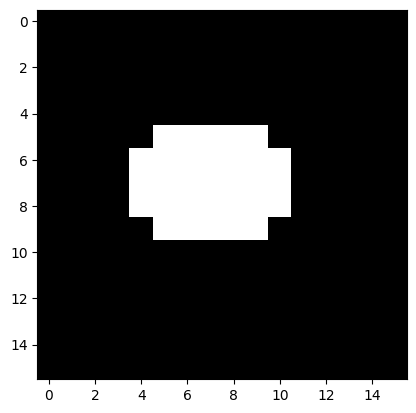

In [17]:
# image = np.array([[0, 0, 0, 0, 0, 0, 0, 0],
#                   [0, 1, 1, 1, 1, 1, 0, 0],
#                   [0, 1, 1, 1, 1, 1, 1, 0],
#                   [0, 1, 1, 1, 1, 1, 1, 0],
#                   [0, 1, 1, 1, 1, 1, 1, 0],
#                   [0, 0, 0, 1, 1, 1, 1, 0],
#                   [0, 0, 0, 1, 1, 1, 1, 0],
#                   [0, 0, 0, 0, 0, 0, 0, 0]])

# image = np.array([
#     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#     [0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0],
#     [0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
#     [0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
#     [0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0],
#     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#     [0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0],
#     [0,0,1,1,1,1,1,0,0,0,0,0,1,1,1,0],
#     [0,1,1,1,1,1,1,1,1,0,0,1,1,1,1,0],
#     [0,1,1,1,1,0,0,0,1,1,1,1,1,1,1,0],
#     [0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0],
#     [0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0],
#     [0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0],
#     [0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0],
#     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
# ])


image = np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0],
    [0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
])

plt.imshow(image, cmap='gray')
plt.show()

# image norm v
# image norm h
# jako lpiqe i odczyt

## Image as probability amplitudes

In [18]:
# Convert the raw pixel values to probability amplitudes
def amplitude_encode(img_data):
    
    # Calculate the RMS value
    rms = np.sqrt(np.sum(np.sum(img_data**2, axis=1)))
    
    # Create normalized image
    image_norm = []
    for arr in img_data:
        for ele in arr:
            image_norm.append(ele / rms)
        
    # Return the normalized image as a numpy array
    return np.array(image_norm)

# Get the amplitude ancoded pixel values
# Horizontal: Original image
image_norm_h = amplitude_encode(image)

# Vertical: Transpose of Original image
image_norm_v = amplitude_encode(image.T)

## Encode images as circuits

In [28]:
total_qb = 8

# D2n_1 = np.roll(np.identity(2**total_qb), 1, axis=1)


# executor.create_circuit(image)
# executor.execute(10000)
# executor.reconstructed_image
# circuit_h = executor.circuit
# circuit_h.h(0)
# circuit_h.unitary(D2n_1, range(total_qb))
# circuit_h.h(0)
# circuit_h = executor.define_measurement_ext(circuit_h)
#print(circuit_h)
#circuit_h = executor.define_measurement_ext(circuit_h)

# executor.create_circuit(image.T)
# circuit_v = executor.circuit
# circuit_v.h(0)
# circuit_v.unitary(D2n_1, range(total_qb))
# circuit_v.h(0)
# circuit_v = executor.define_measurement_ext(circuit_v)
#print(circuit_v)
#circuit_v = executor.define_measurement_ext(circuit_v)

# print(circuit_h)
# print(circuit_v)
# circ_list = [circuit_h, circuit_v]

     ┌───┐┌──────┐┌───┐┌──────────┐┌───┐
p_0: ┤ H ├┤0     ├┤ H ├┤0         ├┤ H ├
     ├───┤│      │└───┘│          │└───┘
p_1: ┤ H ├┤1     ├─────┤1         ├─────
     ├───┤│      │     │          │     
p_2: ┤ H ├┤2     ├─────┤2         ├─────
     ├───┤│      │     │          │     
p_3: ┤ H ├┤3     ├─────┤3         ├─────
     ├───┤│      │     │  Unitary │     
p_4: ┤ H ├┤4 img ├─────┤4         ├─────
     ├───┤│      │     │          │     
p_5: ┤ H ├┤5     ├─────┤5         ├─────
     ├───┤│      │     │          │     
p_6: ┤ H ├┤6     ├─────┤6         ├─────
     ├───┤│      │     │          │     
p_7: ┤ H ├┤7     ├─────┤7         ├─────
     └───┘│      │┌───┐└──────────┘     
p_8: ─────┤8     ├┤ H ├─────────────────
          └──────┘└───┘                 
c: 9/═══════════════════════════════════
                                        
     ┌───┐┌──────┐┌───┐┌──────────┐┌───┐
p_0: ┤ H ├┤0     ├┤ H ├┤0         ├┤ H ├
     ├───┤│      │└───┘│          │└───┘
p_1: ┤ H ├┤1    

## Simulate and show

In [29]:
# Simulating the cirucits
# from qiskit_aer import Aer
# back = Aer.get_backend('statevector_simulator')
# results = back.run(circ_list).result()
# sv_h = results.get_statevector(circuit_h)
# sv_v = results.get_statevector(circuit_v)

executor.create_circuit(image)
executor.execute(100000)
edge_scan_h_gradient = executor.reconstructed_image
plt.imshow(executor.reconstructed_image, cmap='gray')
plt.show()

executor.create_circuit(image.T)
executor.execute(10000)
edge_scan_v_gradient = executor.reconstructed_image
plt.imshow(executor.reconstructed_image, cmap='gray')
plt.show()

# print(a)
# imshow(a)
# plt.show()
# print("  ")
# c, d = executor.execute_ext(10000, circuit_v)
# print(c)
# imshow(c)
# plt.show()
# print(a)
# print(c)
# from qiskit.visualization import array_to_latex
# print('Horizontal scan statevector:')
# display(array_to_latex(sv_h[:30], max_size=30))
# print()
# print('Vertical scan statevector:')
# display(array_to_latex(sv_v[:30], max_size=30))

## Combine the results

In [36]:

def get_correct_image(image, ):
    im = np.zeros([16,16])
    im2_ready = np.zeros([8,8])
    im3_ready = np.zeros([8,8])
    im4_ready = np.zeros([8,8])
    im1 = image[0:8,0:8]
    im2 = image[0:8,8:16]
    im3 = image[8:16,0:8]
    im4 = image[8:16,8:16]

    # im2_ready = [i[::-1] for i in im2[::-1]]
    # im3_ready = [i[:-1:] for i in im3[:-1:]]
    # im4_ready = [i[:-1:-1] for i in im4[:-1:-1]]

    for i in range(0,8):
        for j in range(0,8):
            im2_ready[i, j] = im2[i,7-j]
            im3_ready[i, j] = im3[7-i,j]
            im4_ready[i, j] = im4[7-i,7-j]


    imshow(image)
    plt.show()
    # imshow(im2_ready)
    # plt.show()
    # imshow(im3_ready)
    # plt.show()
    # imshow(im4_ready)
    # plt.show()


    for i in range(16):
        for j in range(16):
            if i < 8:
                if j < 8:
                    im[i, j] = im1[i,j]
                else:
                    im[i, j] = im2_ready[i,j-8]
            else:
                if j < 8:
                    im[i, j] = im3_ready[i-8,j]
                else:
                    im[i, j] = im4_ready[i-8,j-8]

    
    imshow(im)
    plt.show()

    return im

_________________________________________


c:\git\prv\LPIQE-and-PDU\.venv\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


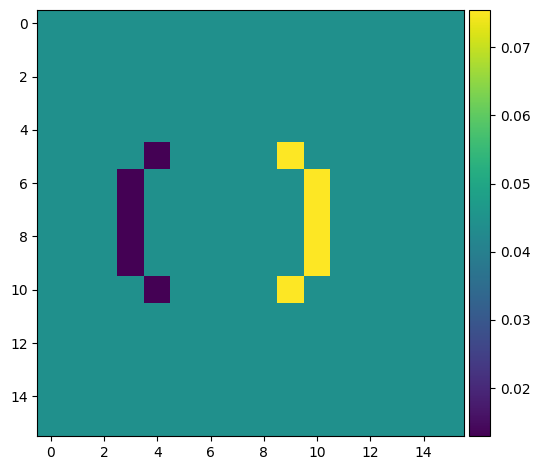

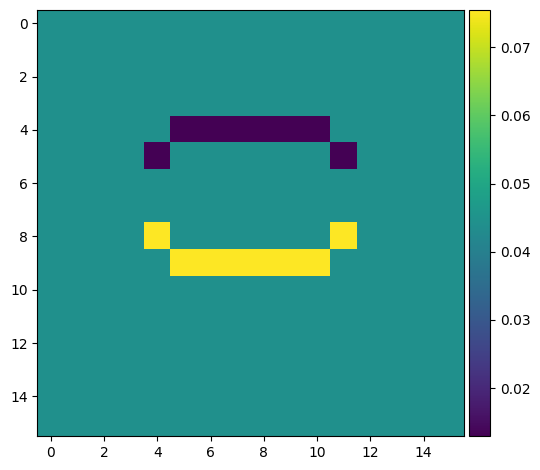

In [55]:
# Classical postprocessing for plotting the output

# Defining a lambda function for
# thresholding to binary values
threshold = lambda amp: (amp > 0.05 or amp < -0.05)

# Selecting odd states from the raw statevector and
# reshaping column vector of size 64 to an 8x8 matrix
# edge_scan_h = np.abs(np.array([1 if threshold(sv_h[2*i+1].real) else 0 for i in range(2**8)])).reshape(16, 16)
# edge_scan_v = np.abs(np.array([1 if threshold(sv_v[2*i+1].real) else 0 for i in range(2**8)])).reshape(16, 16).T


# imshow(sv_h)
# plt.show()
# print("  ")
# imshow(sv_v)
# plt.show()

# print(sv_h)

edge_scan_h_gradient = np.abs(np.array([sv_h[2*i+1].real for i in range(2**8)])).reshape(16, 16)
edge_scan_v_gradient = np.abs(np.array([sv_v[2*i+1].real for i in range(2**8)])).reshape(16, 16)

# edge_scan_h_gradient2 = np.zeros([16,16])
# edge_scan_v_gradient2 = np.zeros([16,16])
# print("_________________________________________")
# imshow(edge_scan_h_gradient)
# plt.show()
# print("  ")
# imshow(edge_scan_v_gradient)
# plt.show()

# for i in range(16):
#     for j in range(16):
#         if i < 8:
#             edge_scan_h_gradient2[i,j] = edge_scan_h_gradient[i,j]
#             edge_scan_v_gradient2[i,j] = edge_scan_v_gradient[i,j]
#         else:
#             # print[i]
#             # print()
#             edge_scan_h_gradient2[i,j] = edge_scan_h_gradient[16-i,j]
#             edge_scan_v_gradient2[i,j] = edge_scan_v_gradient[16-i,j]

    
# edge_scan_v_gradient3 = edge_scan_v_gradient2.T       



midpoint = int(edge_scan_h_gradient.shape[0]/2)

a = edge_scan_h_gradient[:midpoint]
b = np.flip(edge_scan_h_gradient[midpoint:], 0)

edge_scan_h_gradient2 = np.vstack((a, b))

midpoint = int(edge_scan_v_gradient.shape[0]/2)

a = edge_scan_v_gradient[:midpoint]
b = np.flip(edge_scan_v_gradient[midpoint:], 0)

edge_scan_v_gradient3 = np.vstack((a, b)).T



# edge_scan_v_gradient3

# for i in range(16):
#     for j in range(16):
#         if i < 8:
#             edge_scan_h_gradient2[i,j] = edge_scan_h_gradient[i,j]
#         else:
#             edge_scan_h_gradient2[i,j] = edge_scan_h_gradient[8-i,j]


# edge_scan_h_gradient = np.zeros([16,16])
# edge_scan_v_gradient = np.zeros([16,16])
# for i in range(16):
#     for j in range(16):
#         edge_scan_h_gradient[i,j] = sv_h[i+(j*i)].real
#         edge_scan_v_gradient[i,j] = sv_v[i+(j*i)].real

# print("_________________________________________")
# imshow(edge_scan_h_gradient)
# plt.show()
# print("  ")
# imshow(edge_scan_v_gradient)
# plt.show()

# edge_scan_h_gradient2 = (edge_scan_h_gradient)
# edge_scan_v_gradient2 = (edge_scan_v_gradient)

# print(edge_scan_h)
# print(edge_scan_v)
# Plotting the Horizontal and vertical scans

print("_________________________________________")
imshow(edge_scan_h_gradient2)
plt.show()
print("  ")
imshow(edge_scan_v_gradient3)
plt.show()

In [56]:
# Combining the horizontal and vertical component of the result
# edge_scan_sim = edge_scan_h | edge_scan_v
edge_scan_sim_gradient = edge_scan_h_gradient2 | edge_scan_v_gradient3

# Plotting the original and edge-detected images
# imshow(image)
# imshow(edge_scan_sim)
# plt.show()

imshow(edge_scan_sim_gradient)
plt.show()

plt.imshow(image, cmap='gray')
plt.show()



# II = edge_scan_sim | image

# imshow(II)
# plt.show()

# III = edge_scan_sim & image
# plt.imshow(III, cmap='gray')
# plt.show()

TypeError: ufunc 'bitwise_or' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

## Experiment made for every image

In [25]:
def make_experiment(img_path, img_name):
    
    img_read = cv2.imread(img_path, 0)
    img = img_read / 255.0

    plt.imshow(img, cmap='gray')
    now = datetime.now().replace(tzinfo=None)
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")
    title = "res_images/" + img_name + "_before_" + date_time + "_" + backend + ".png"
    plt.savefig(title, bbox_inches='tight')
    plt.show()

    executor.create_circuit(img)

WZIĄĆ CIRCUIT I DODAĆ TAM TO COŚ XD

    executor.execute(32000, False)
    pdu_function_creator.apply(executor.reconstructed_image, img)
    pdu_statistics_helper.calculate(img, executor.reconstructed_image)

    res_as_json = json.dumps(executor.computation_results, indent = 4).replace(" ", "").replace("\n", "")
    
    
    plt.imshow(executor.reconstructed_image, cmap='gray')
    title = "res_images/" + img_name + "_in_progres_" + date_time + "_" + backend + ".png"
    plt.savefig(title, bbox_inches='tight')
    plt.show()
    
    mse_before = pdu_statistics_helper.mse
    stdev_before = pdu_statistics_helper.std_dev

    pdu_statistics_helper.calculate(img, pdu_function_creator.corrected_image)

    
    plt.imshow(pdu_function_creator.corrected_image, cmap='gray')
    title = "res_images/" + img_name + "_after_" + date_time + "_" + backend + ".png"
    plt.savefig(title, bbox_inches='tight')
    plt.show()
    
    mse_after = pdu_statistics_helper.mse
    st_dev_after = pdu_statistics_helper.std_dev

    now = datetime.now().replace(tzinfo=None)
    results_to_save = [images_run_uuid, group_uuid, backend, img_name, now, time_of_calibrating_pdu, calibration_granularity+1, mse_before, mse_after, stdev_before, st_dev_after, res_as_json]

    save_results(results_to_save)

## For every image do experiment 10 times

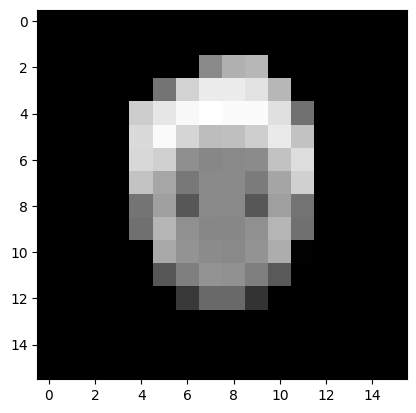

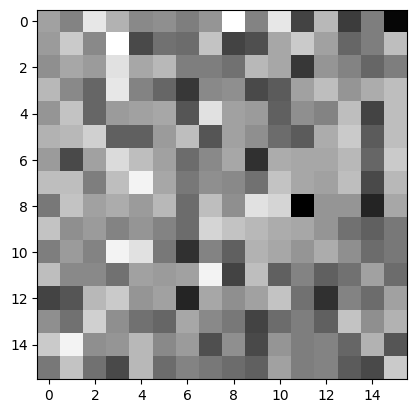

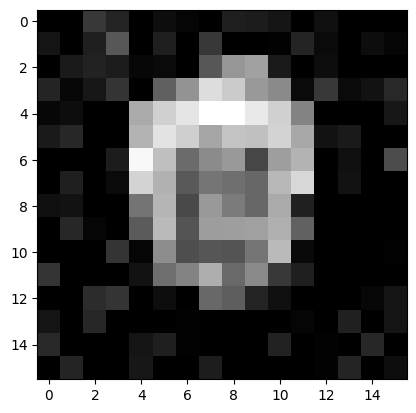

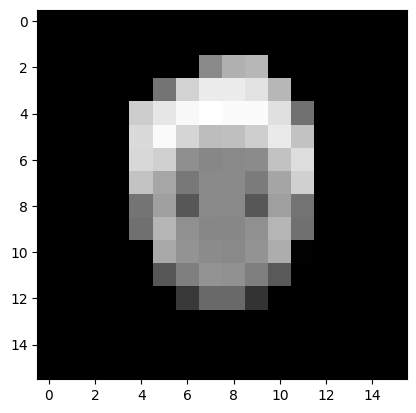

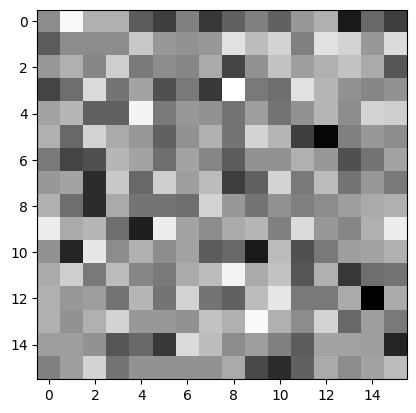

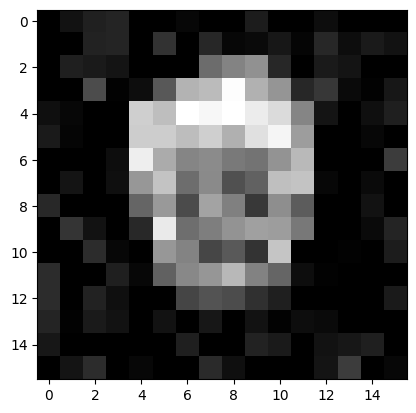

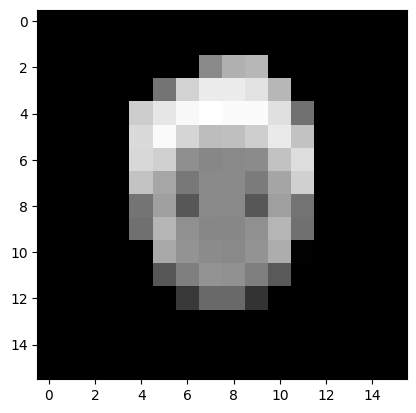

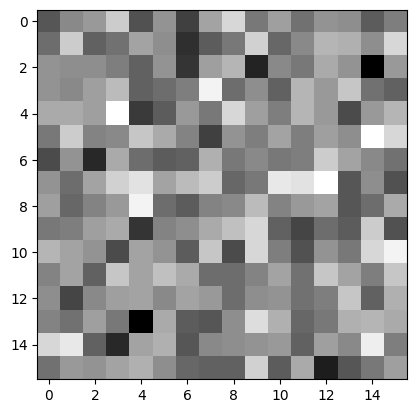

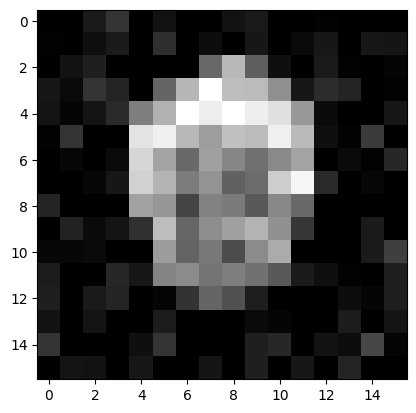

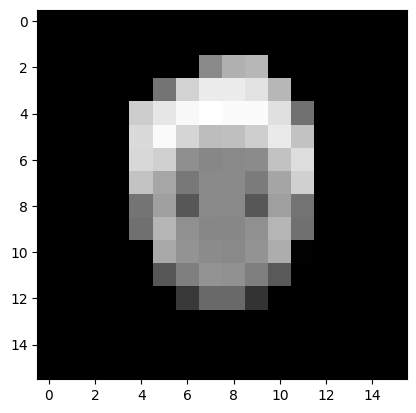

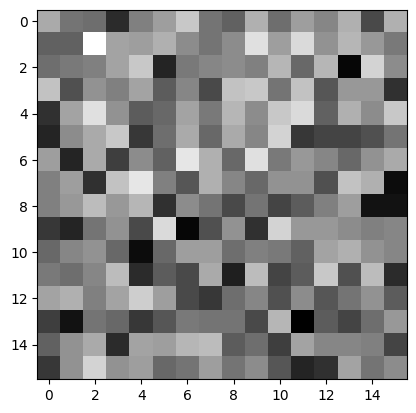

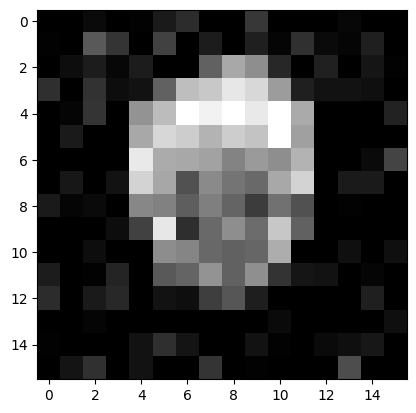

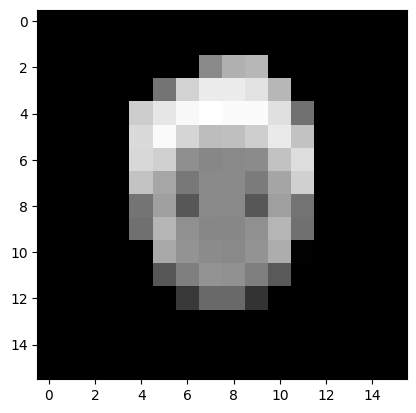

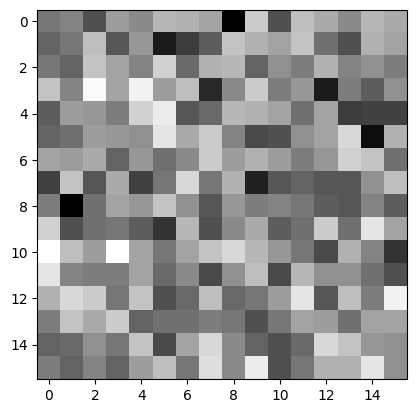

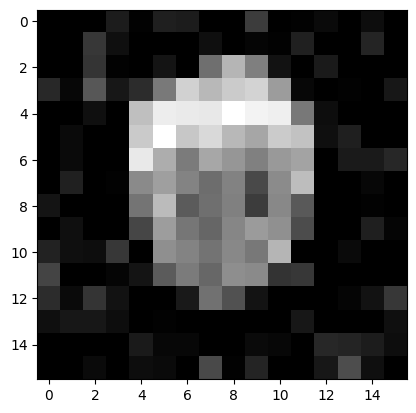

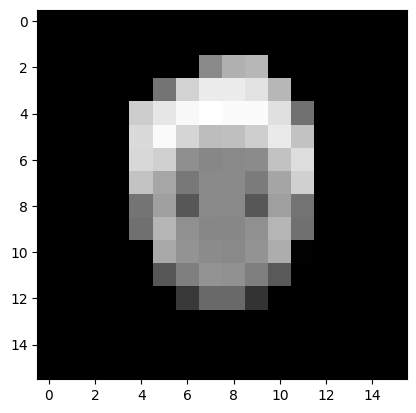

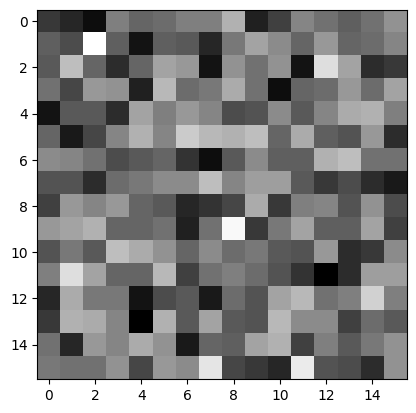

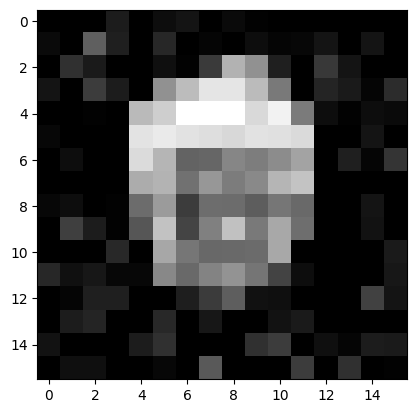

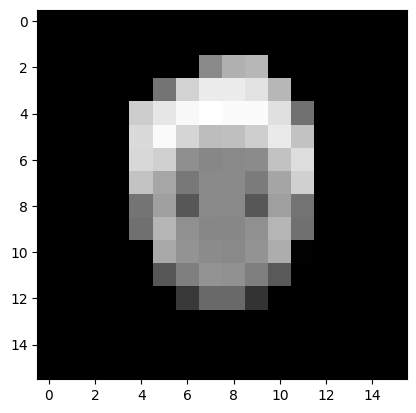

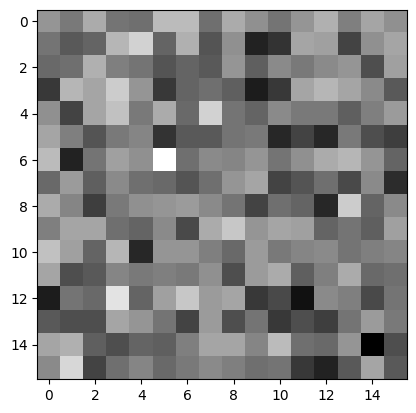

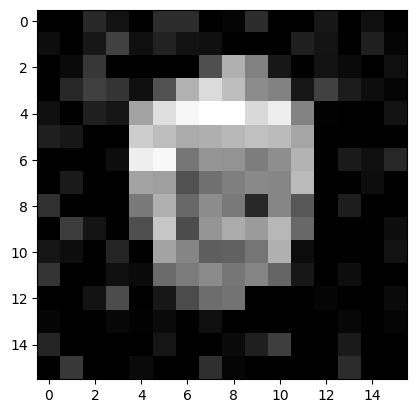

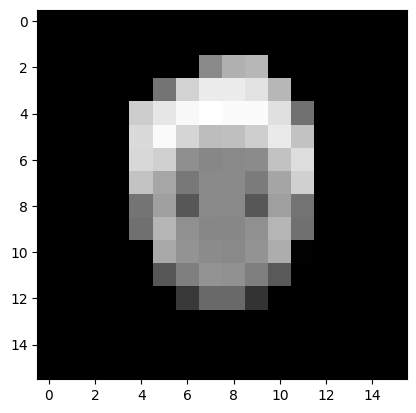

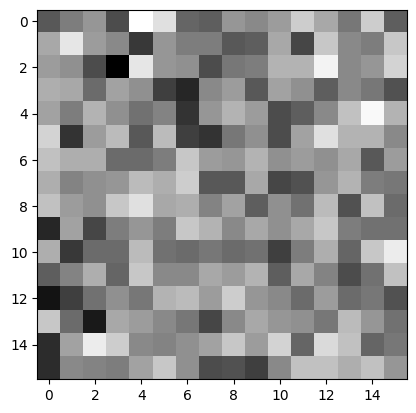

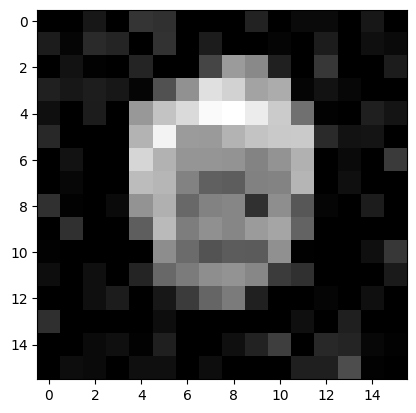

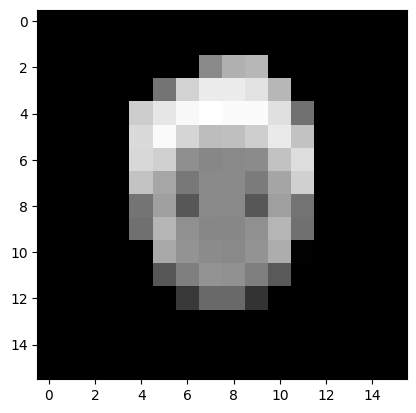

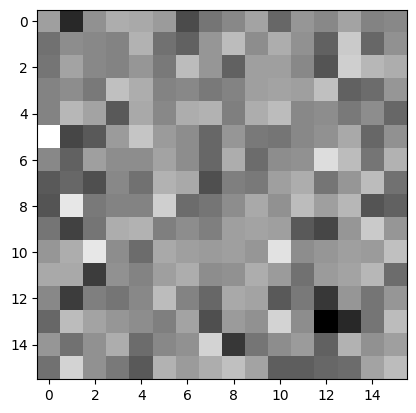

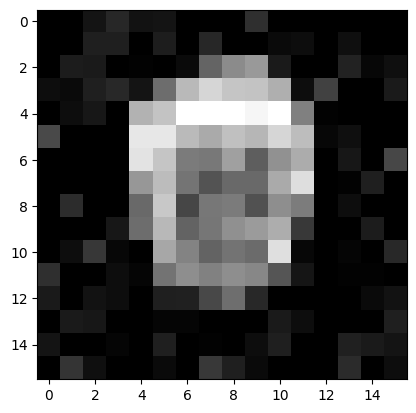

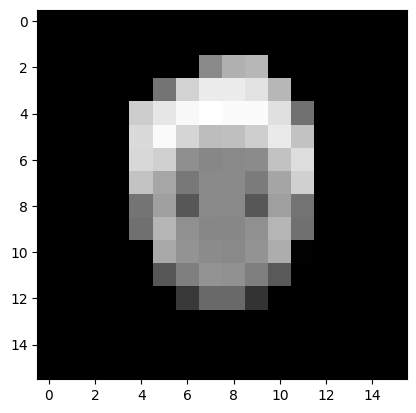

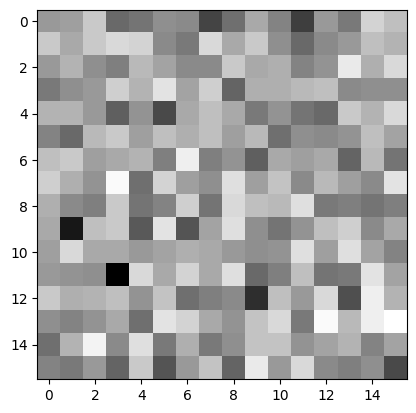

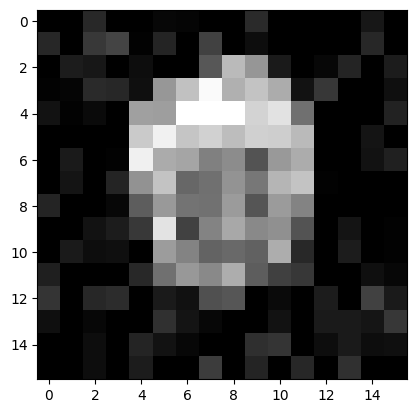

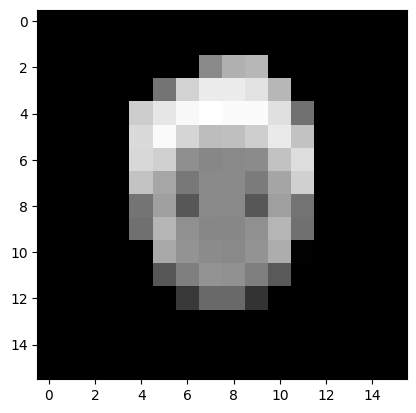

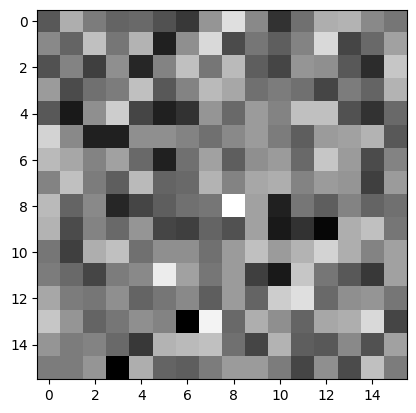

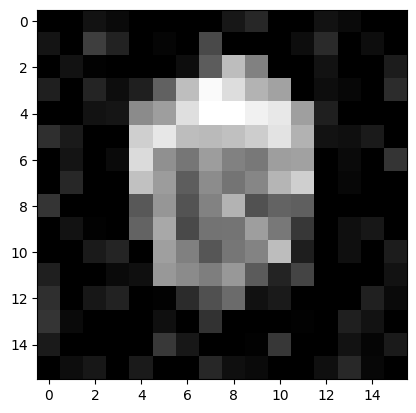

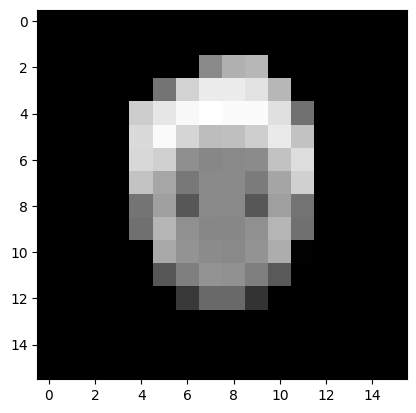

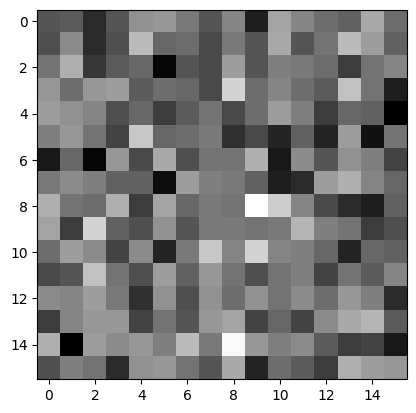

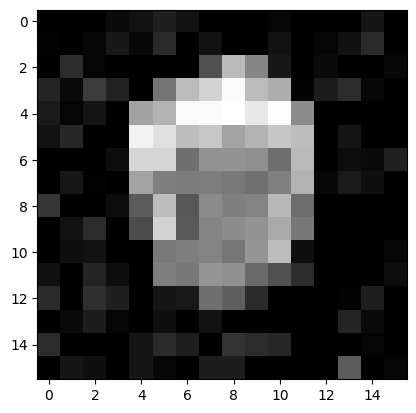

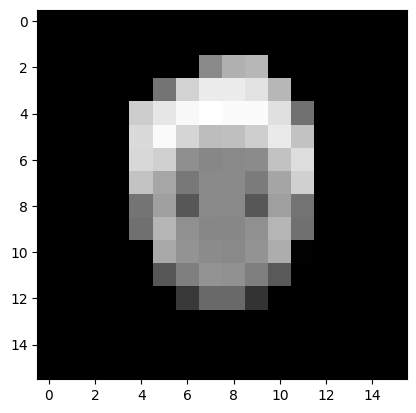

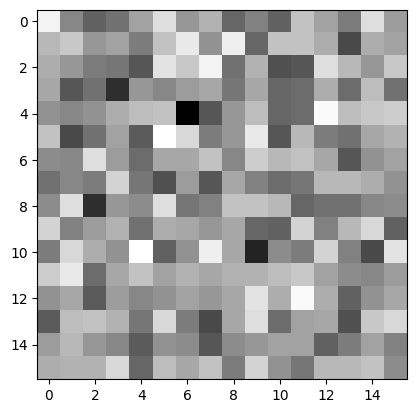

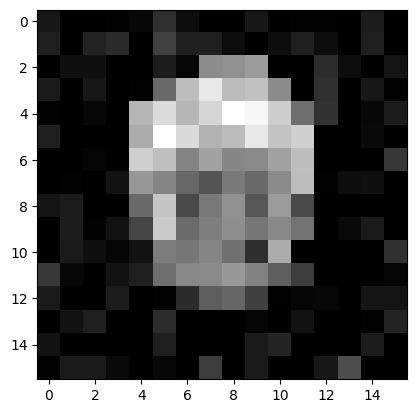

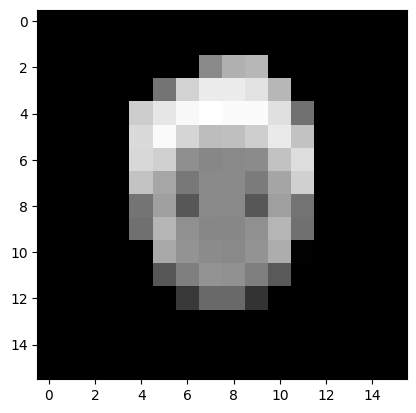

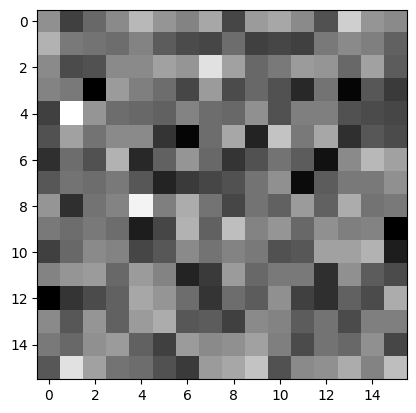

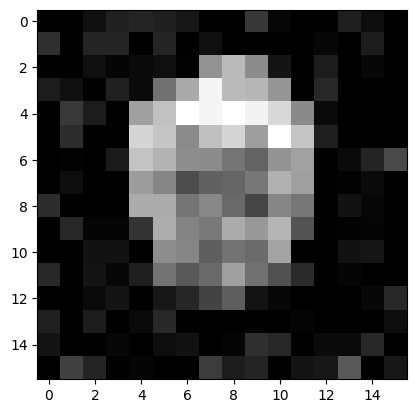

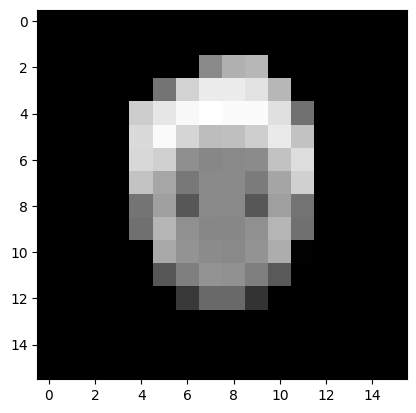

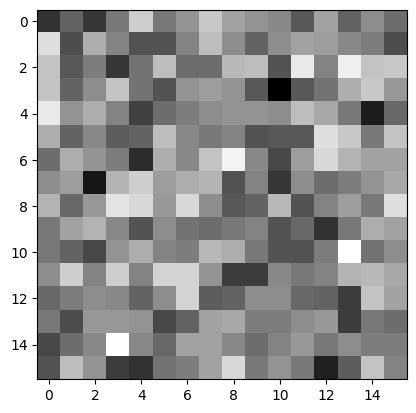

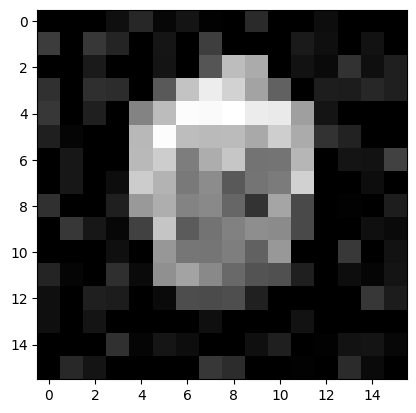

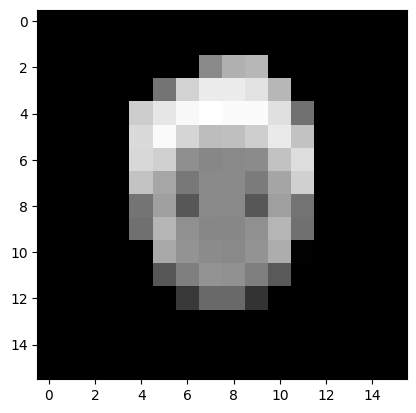

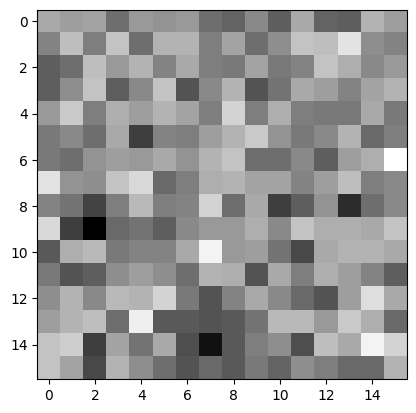

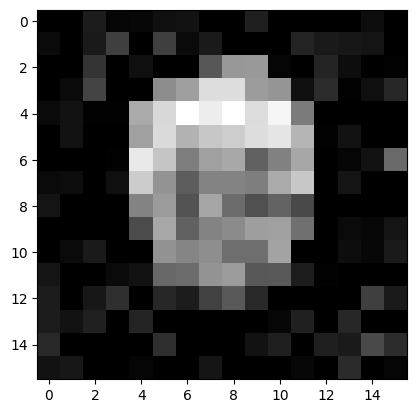

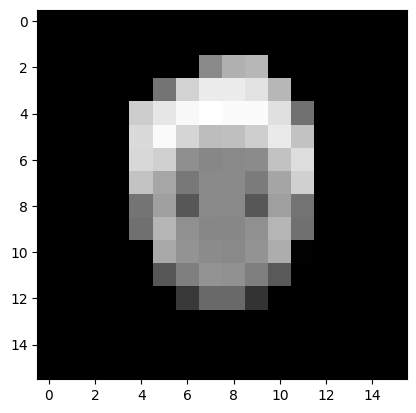

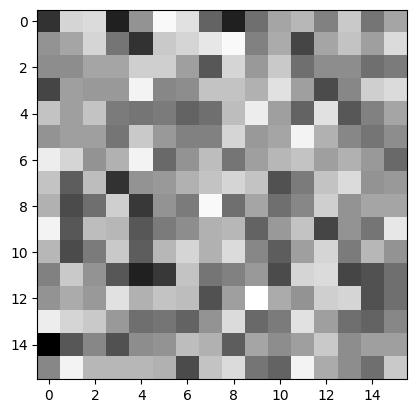

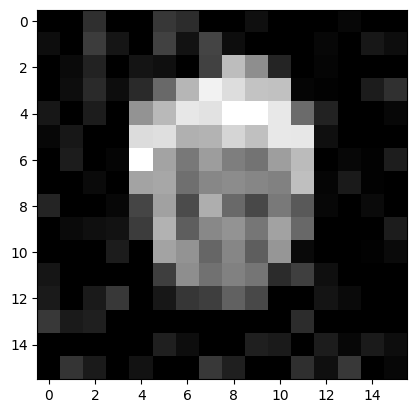

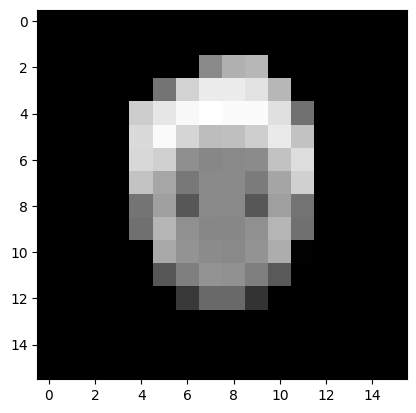

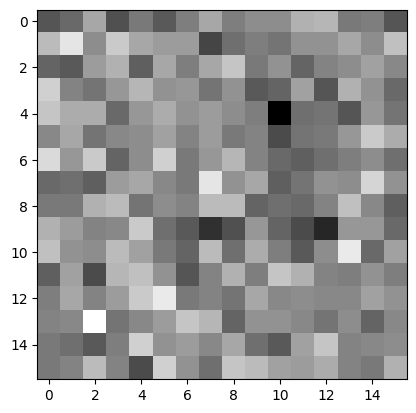

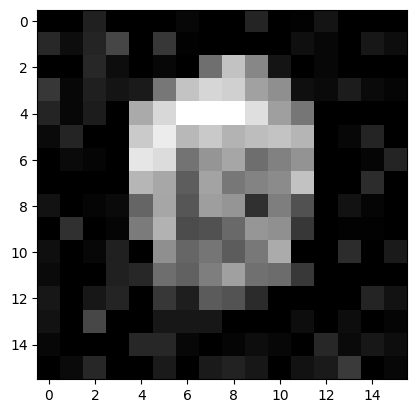

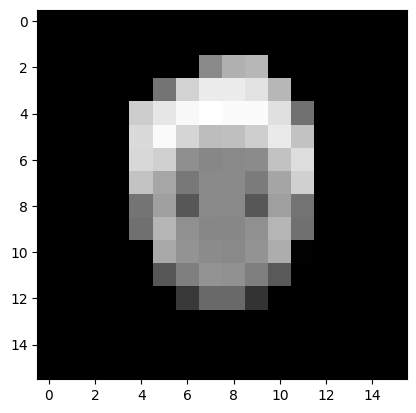

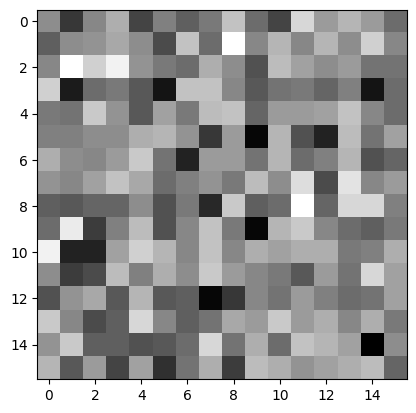

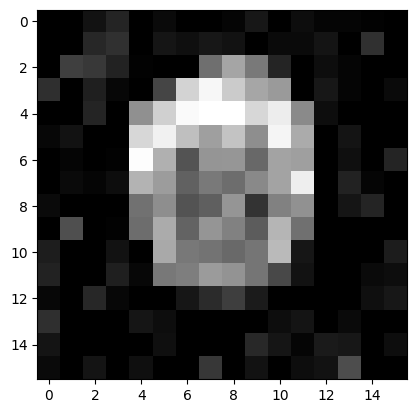

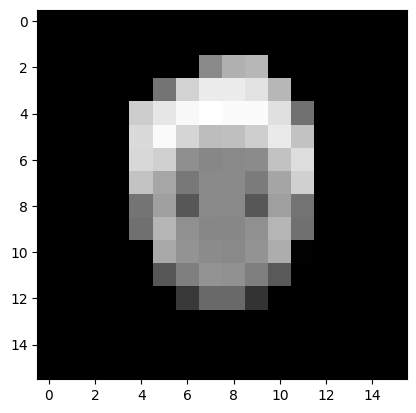

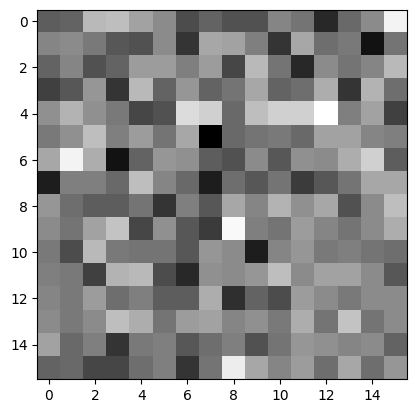

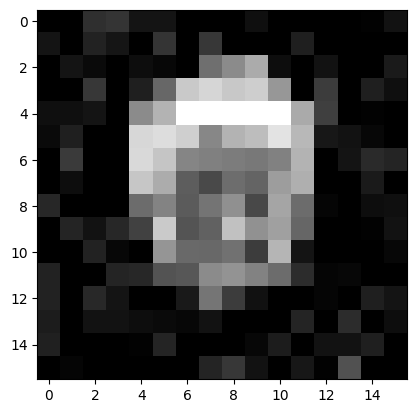

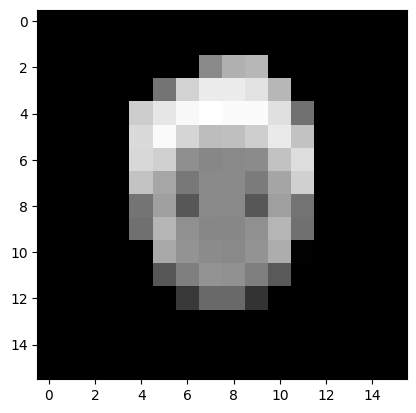

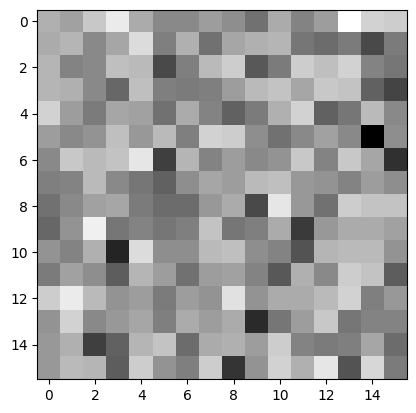

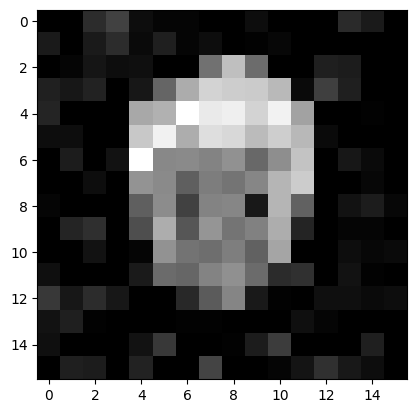

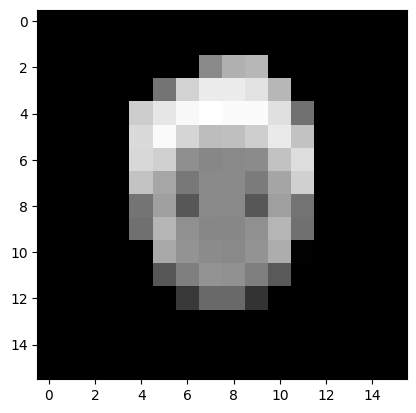

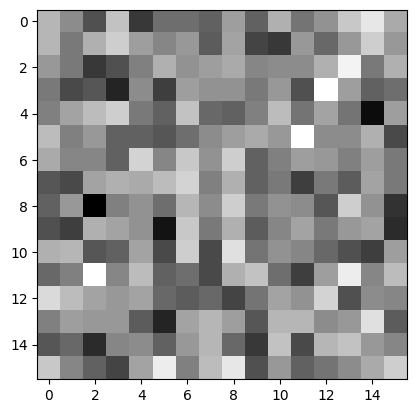

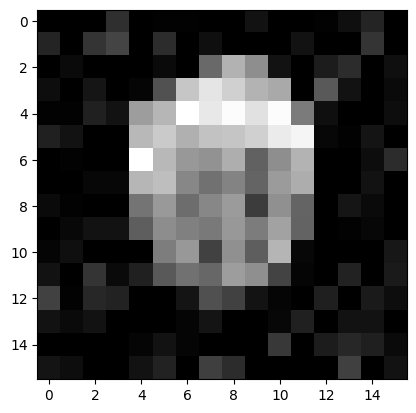

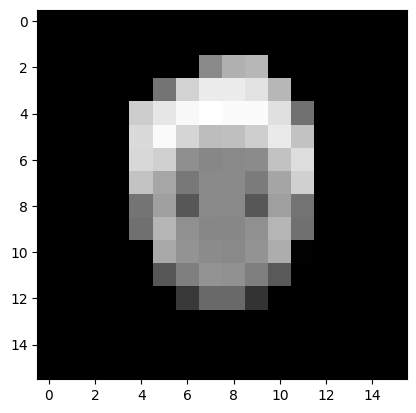

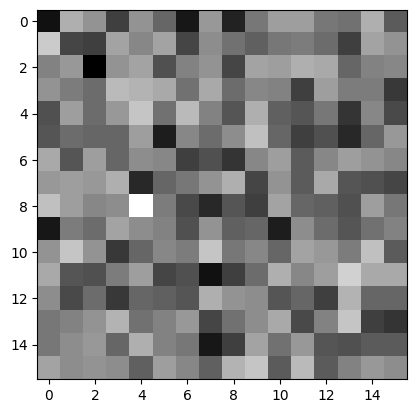

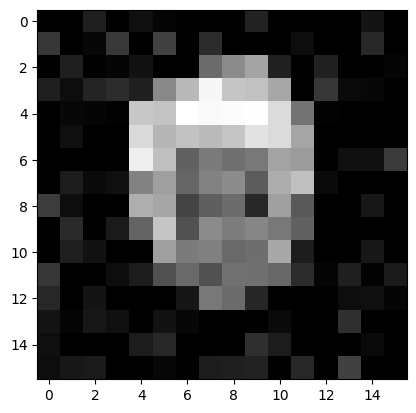

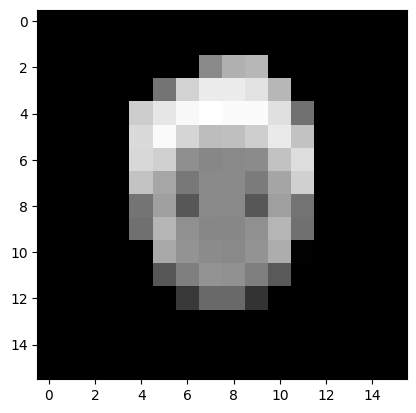

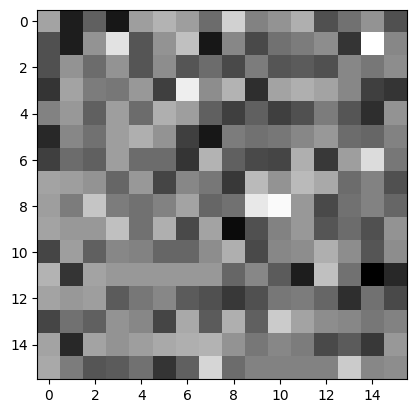

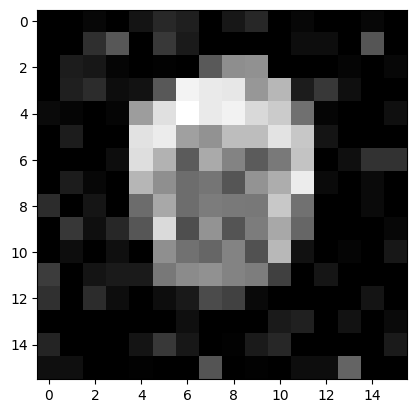

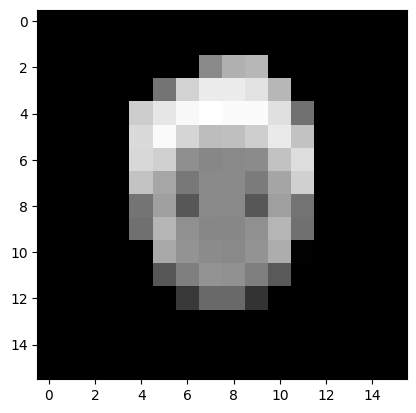

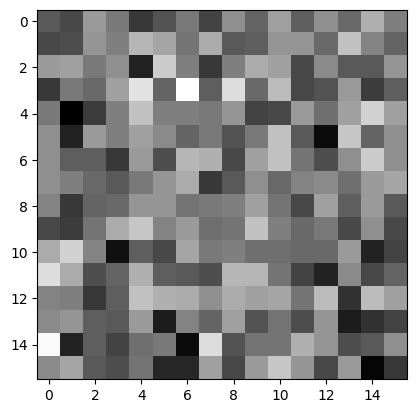

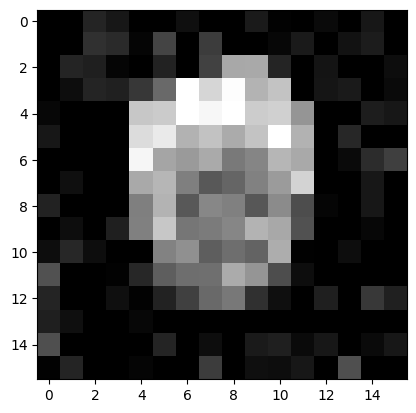

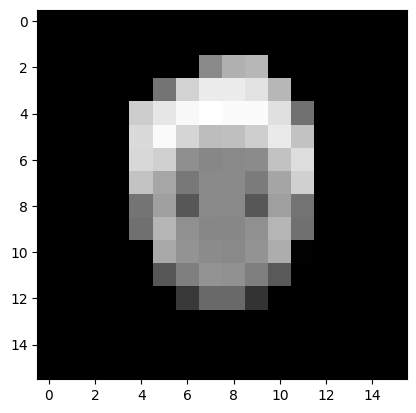

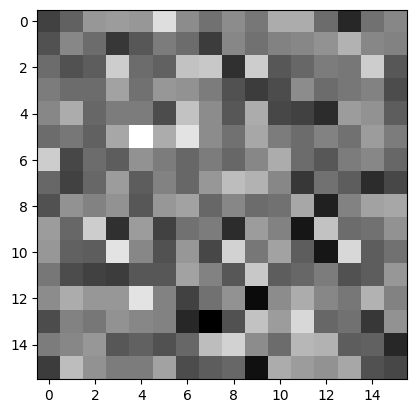

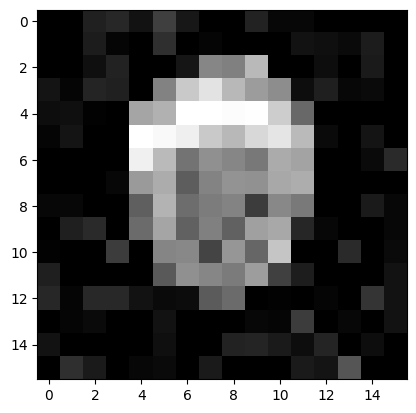

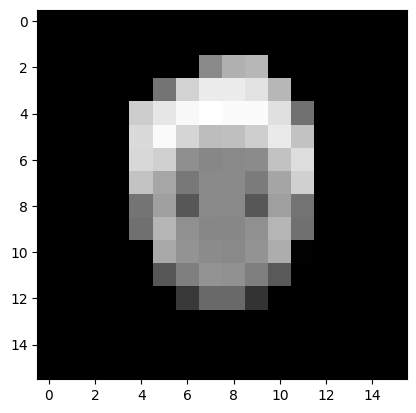

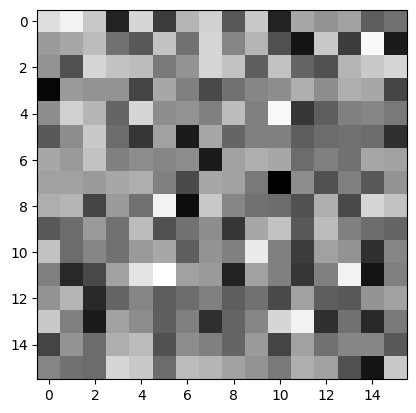

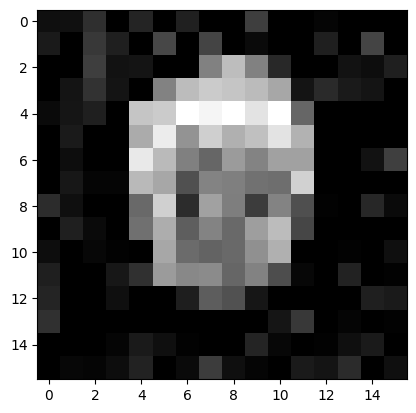

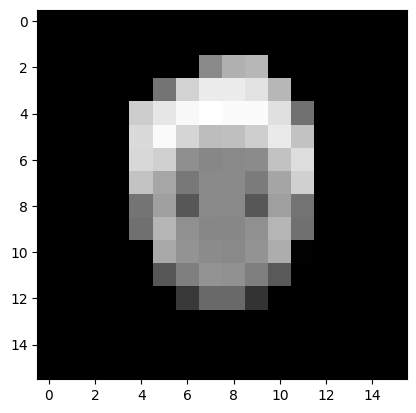

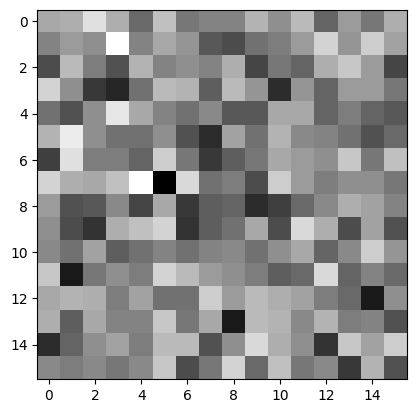

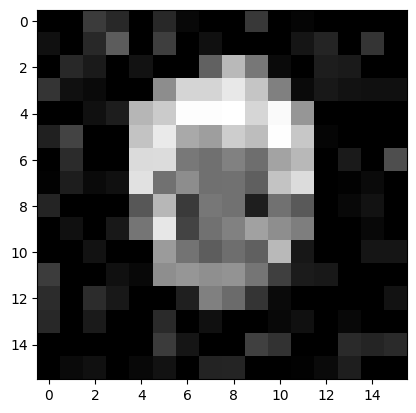

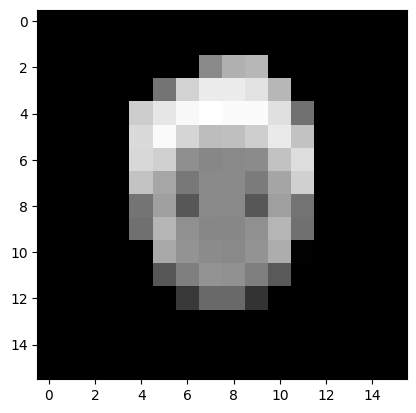

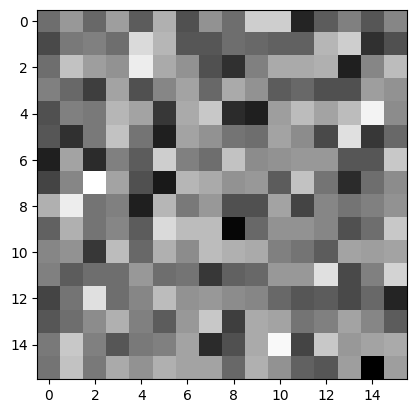

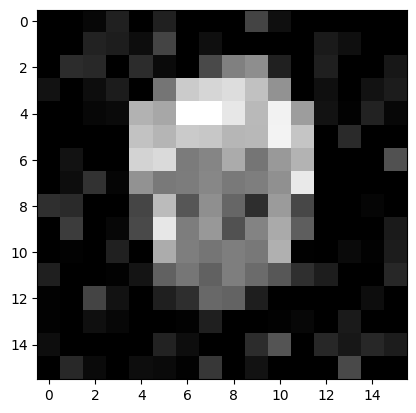

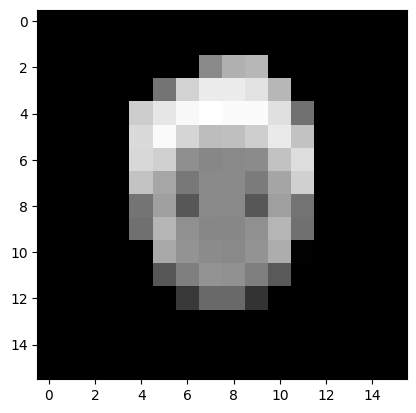

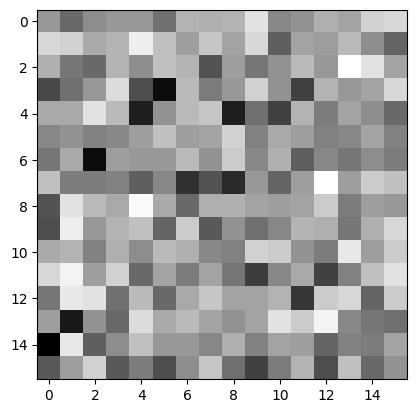

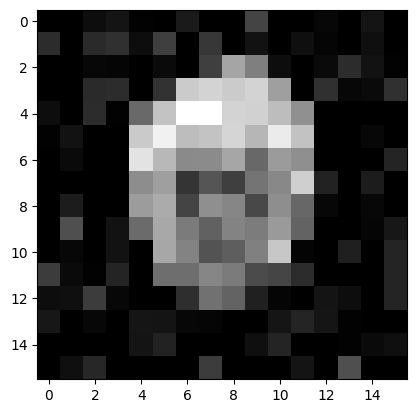

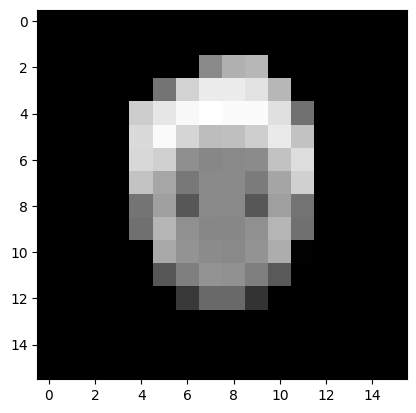

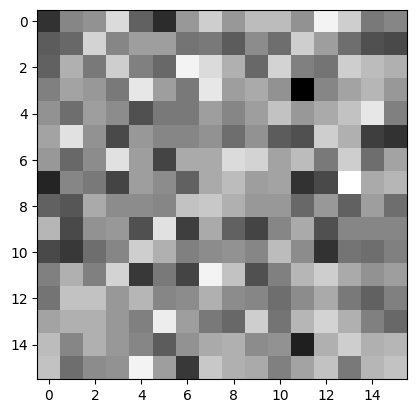

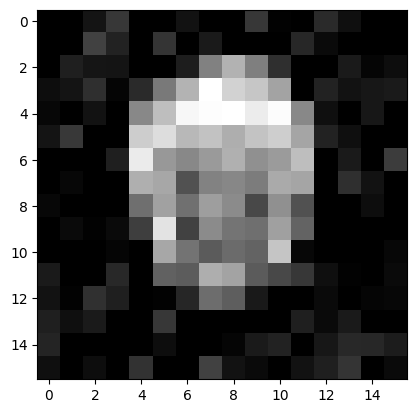

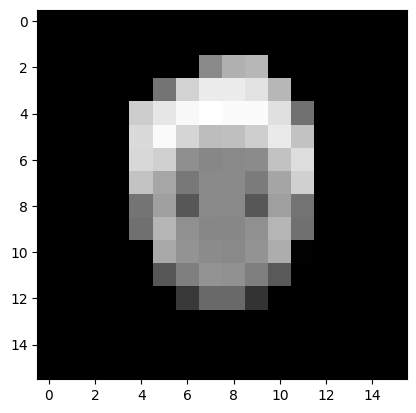

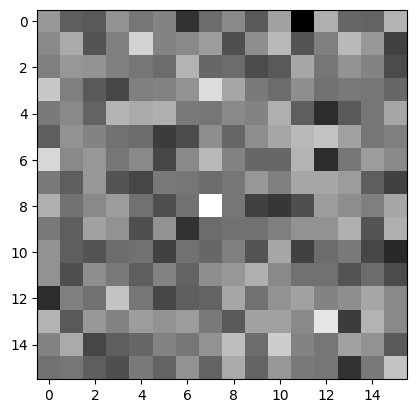

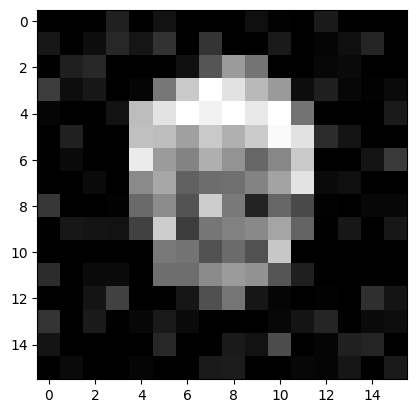

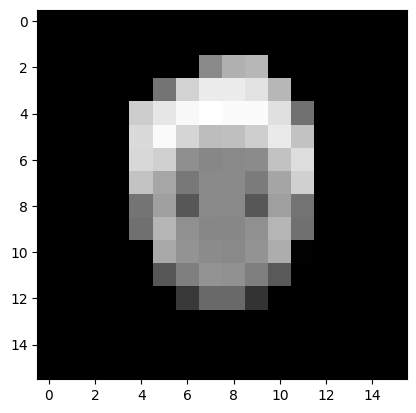

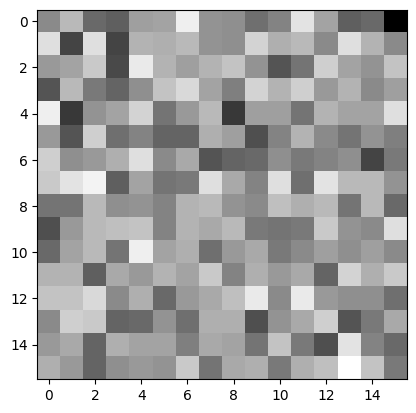

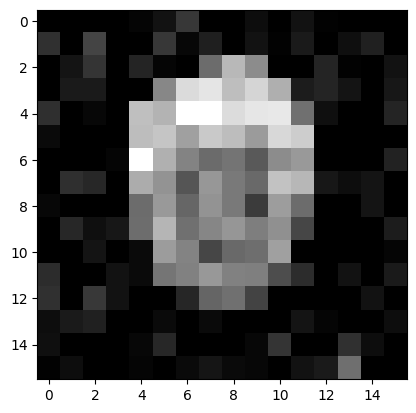

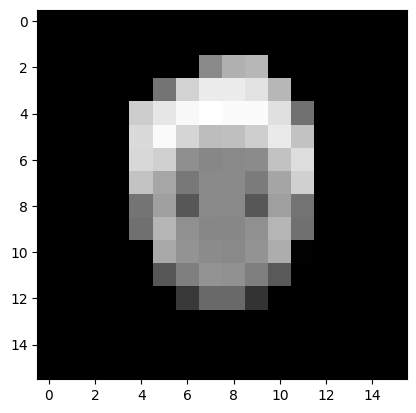

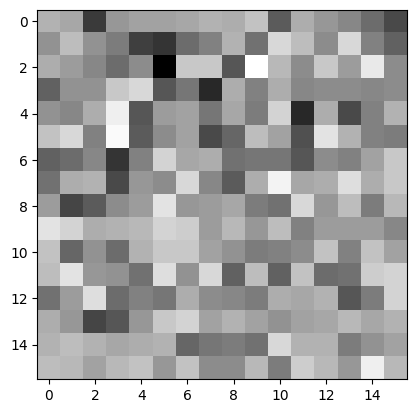

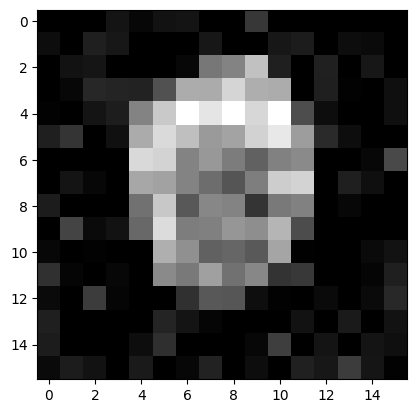

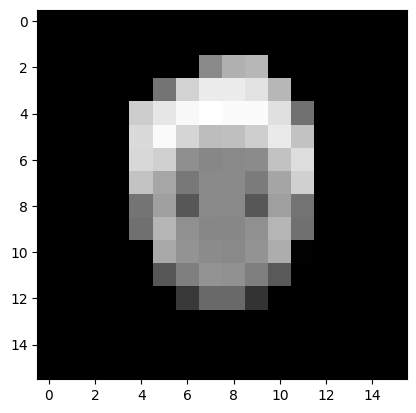

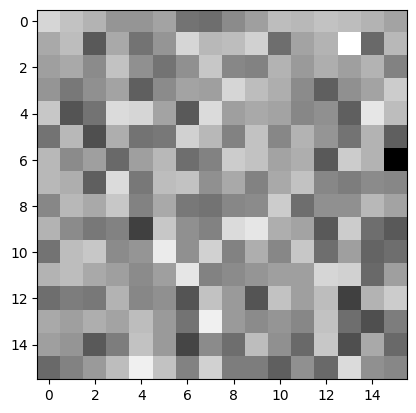

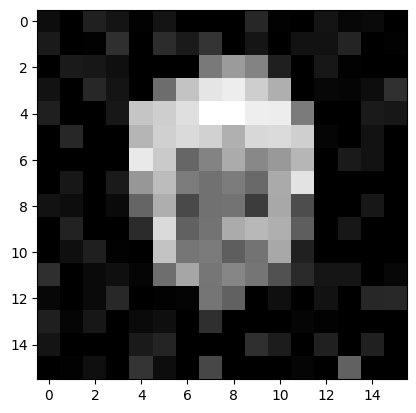

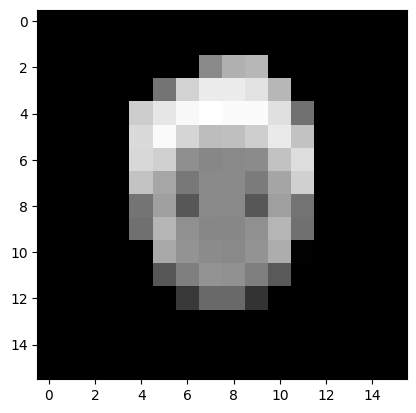

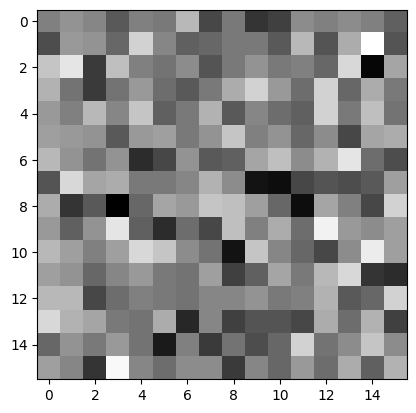

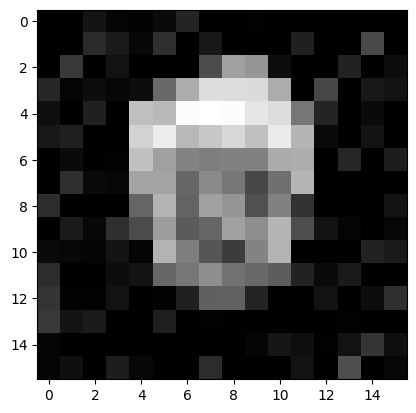

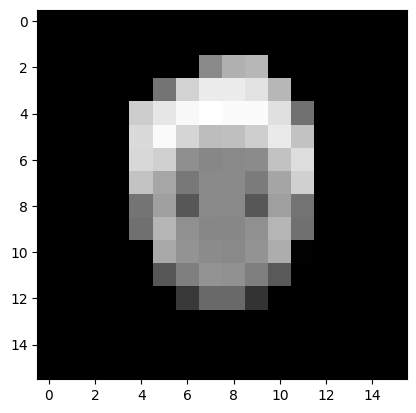

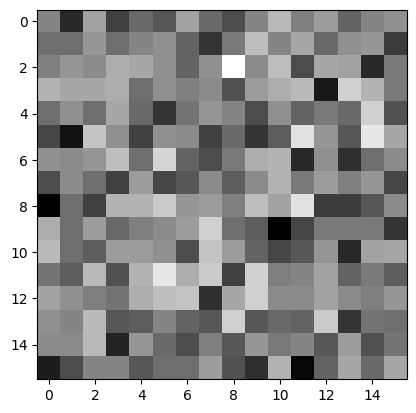

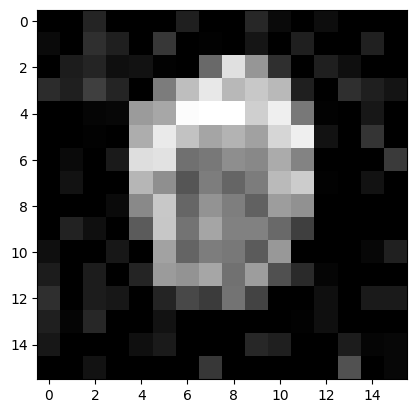

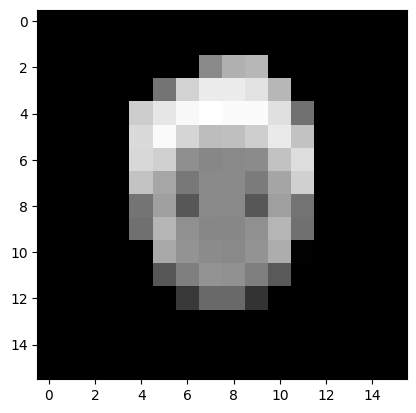

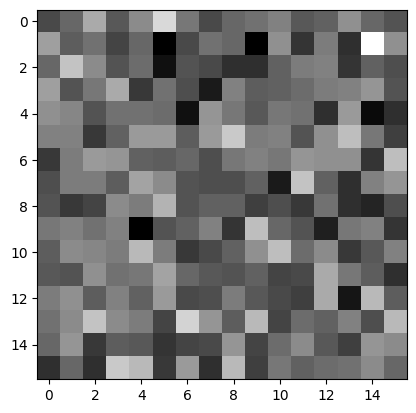

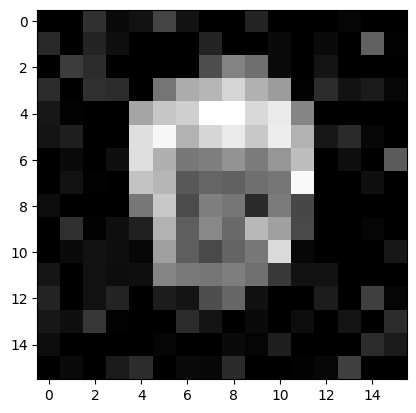

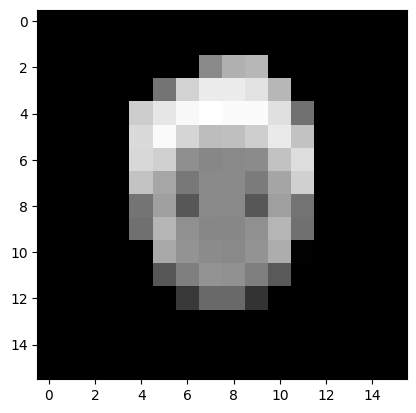

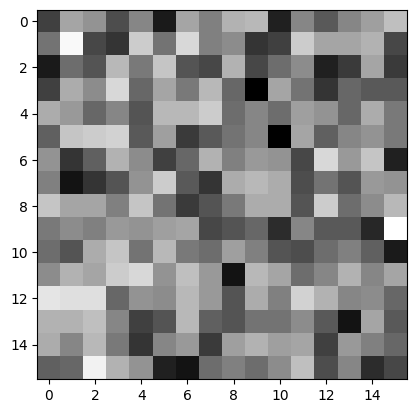

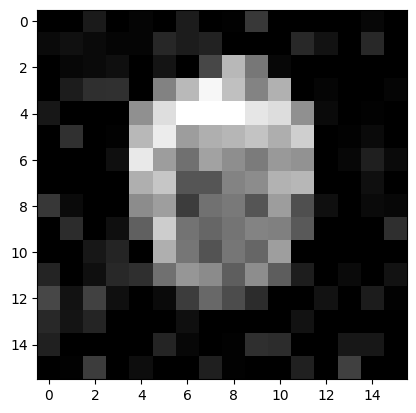

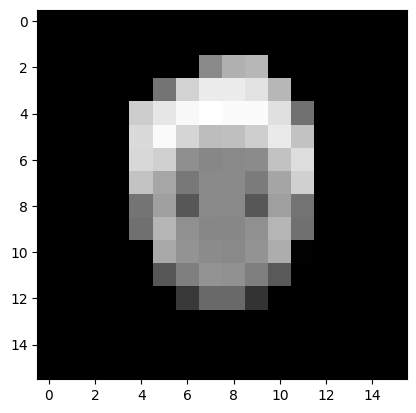

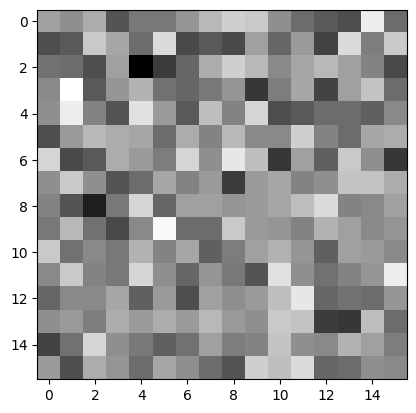

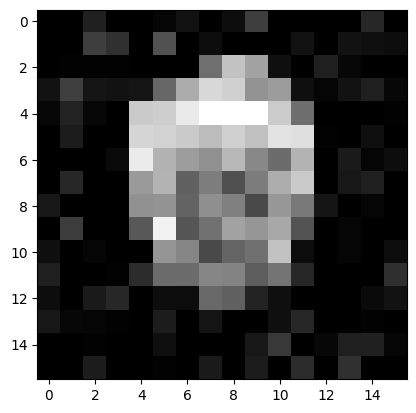

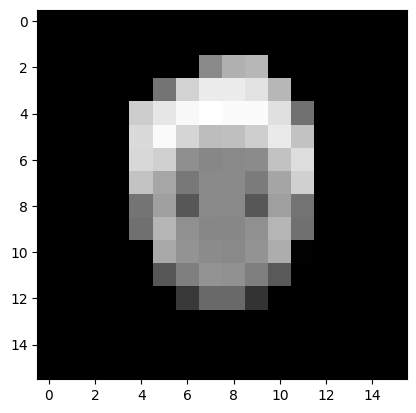

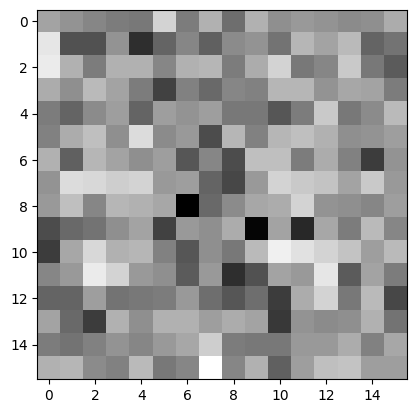

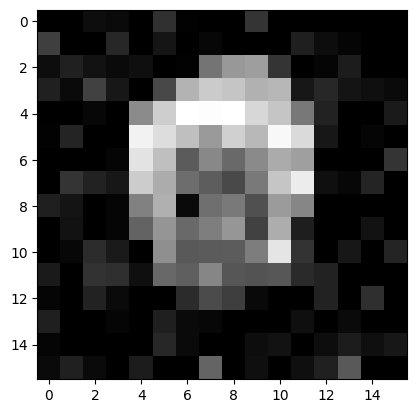

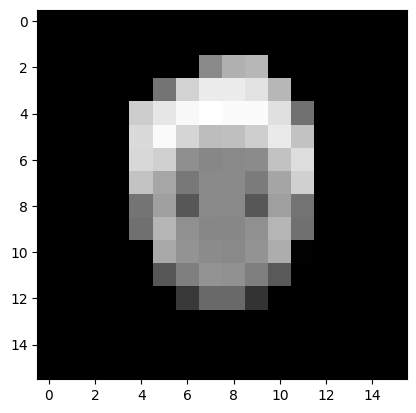

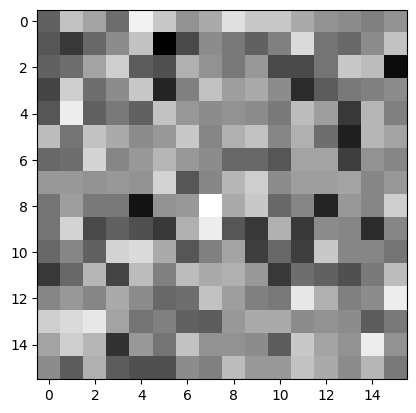

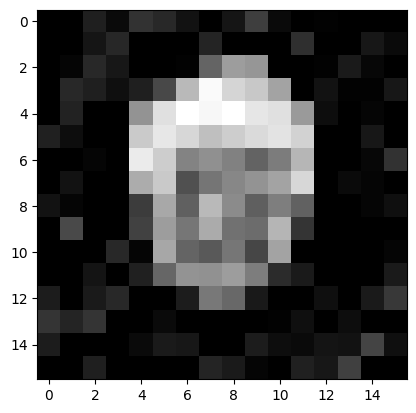

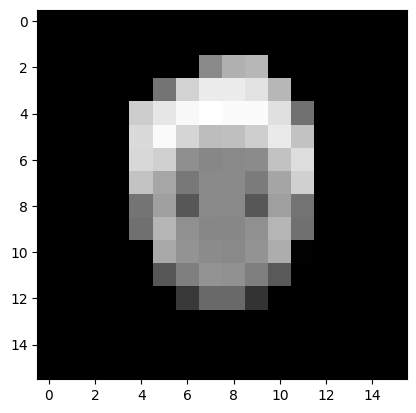

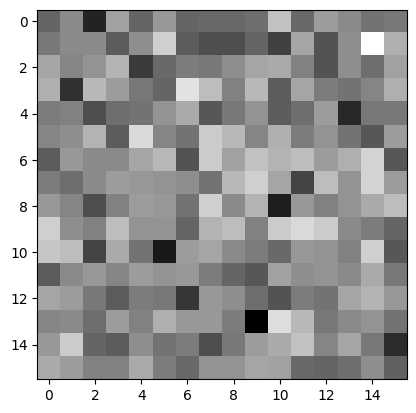

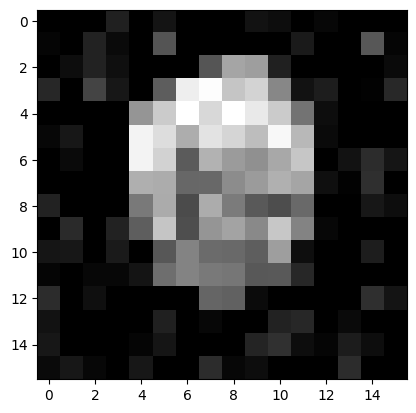

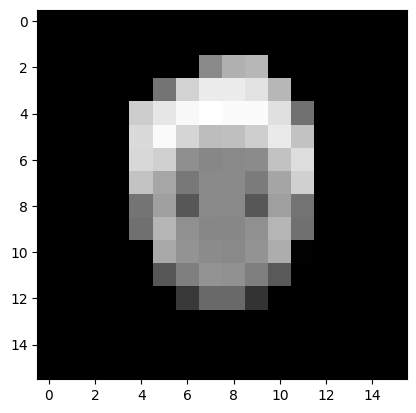

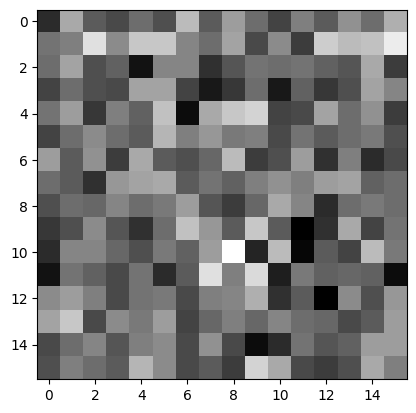

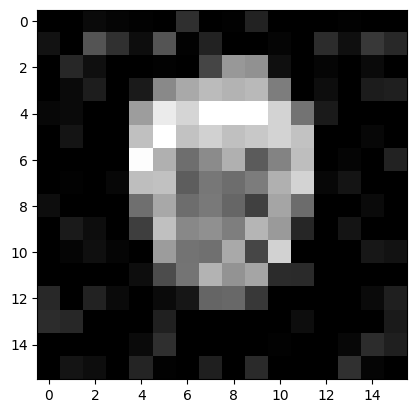

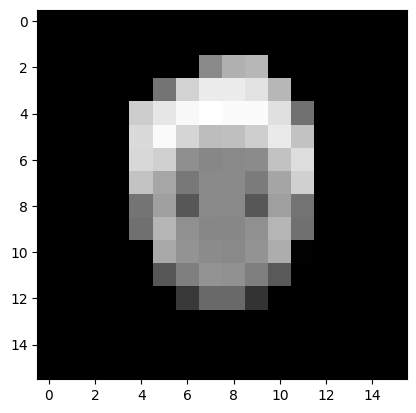

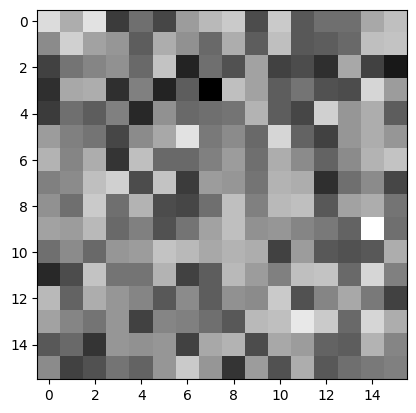

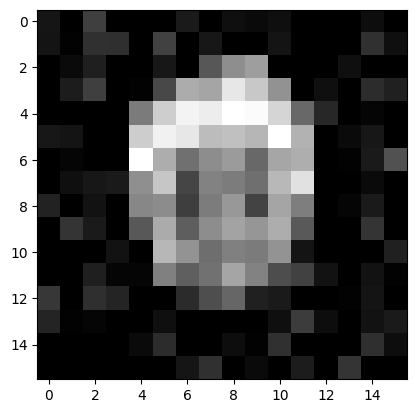

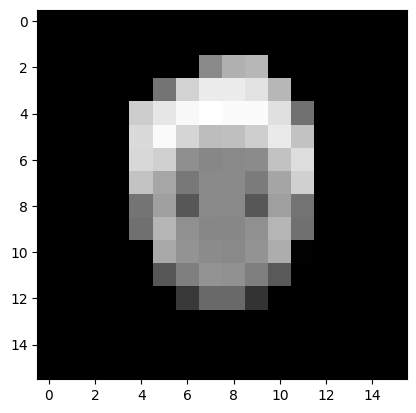

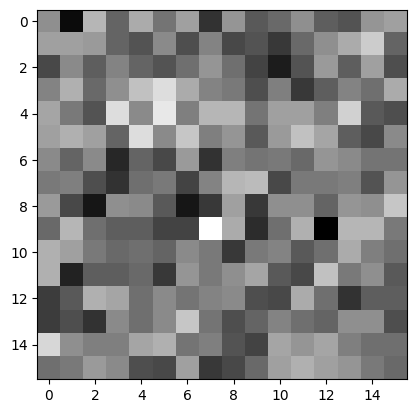

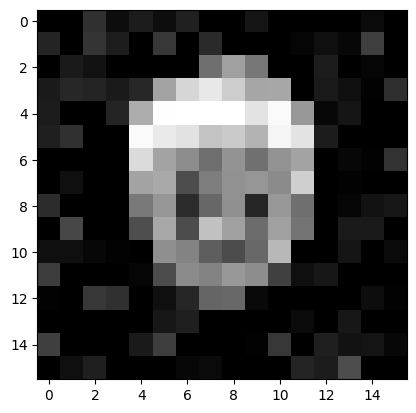

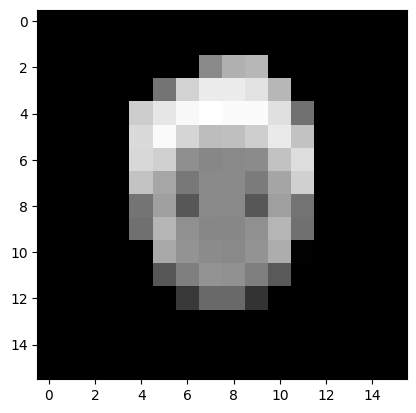

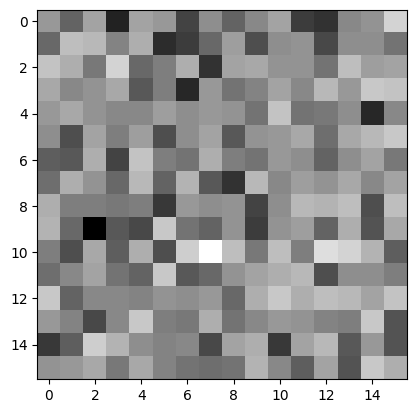

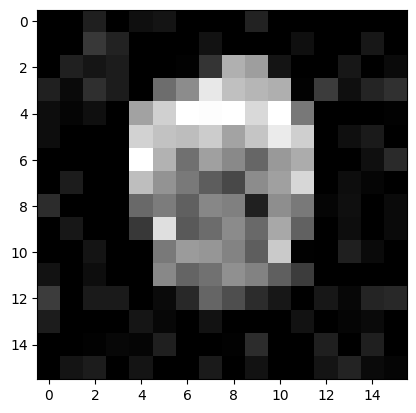

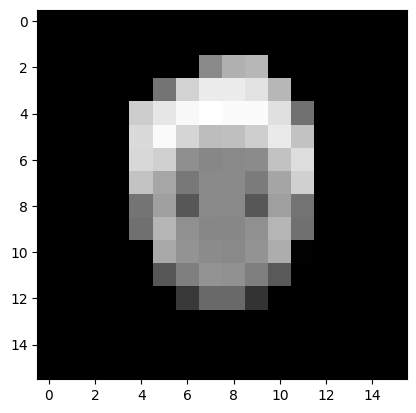

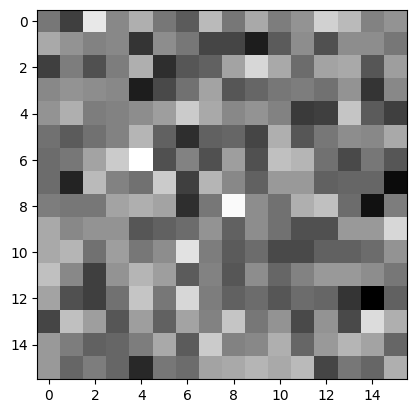

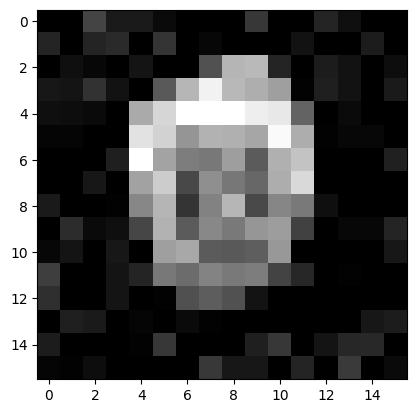

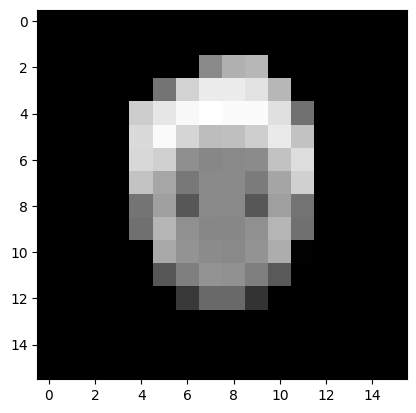

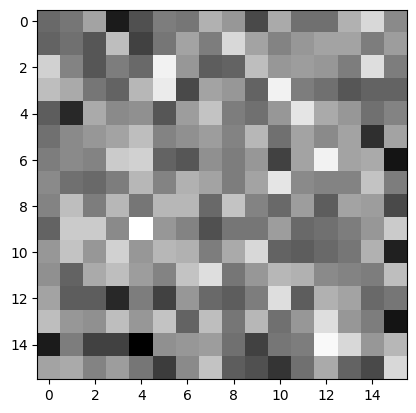

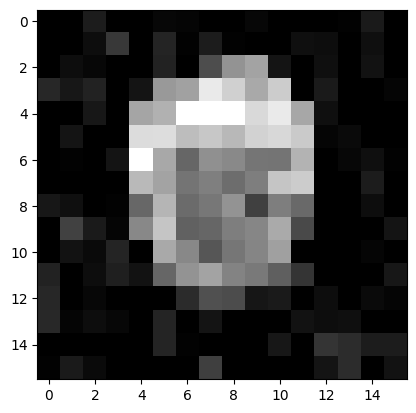

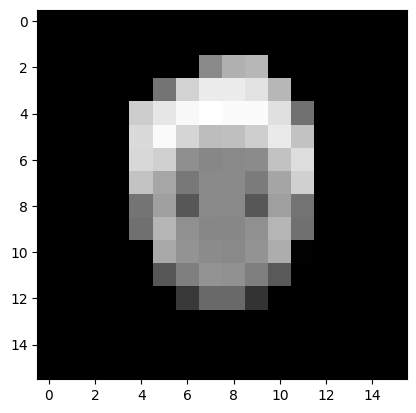

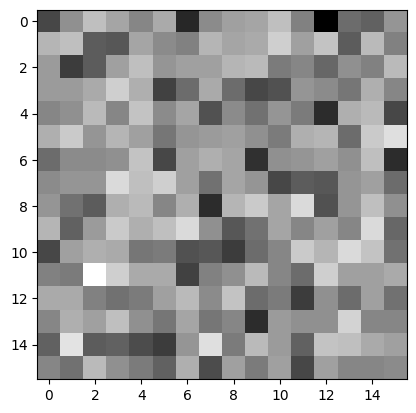

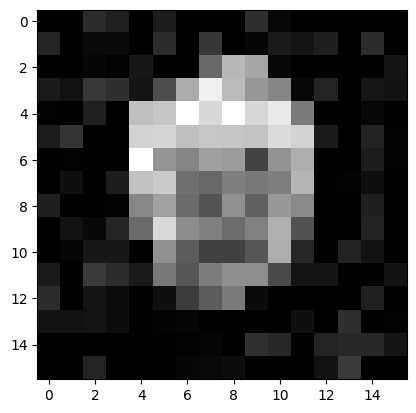

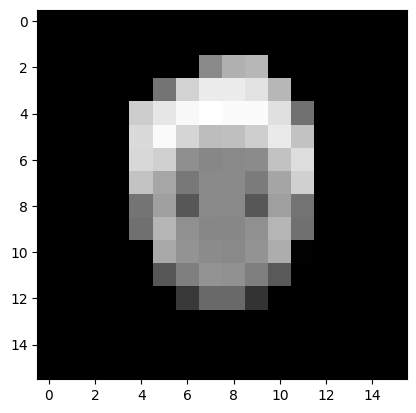

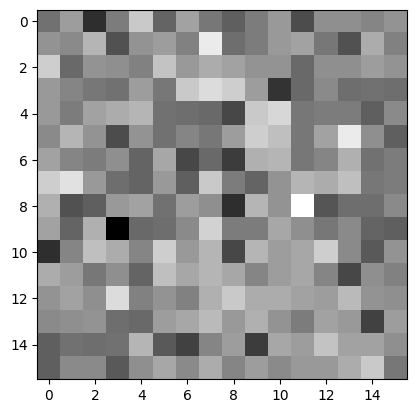

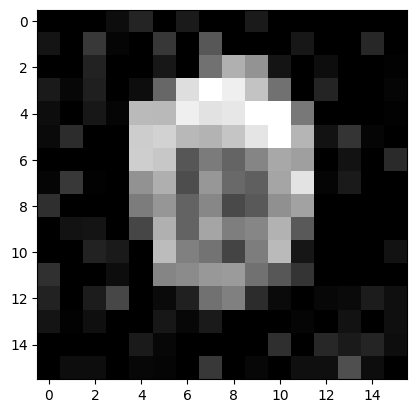

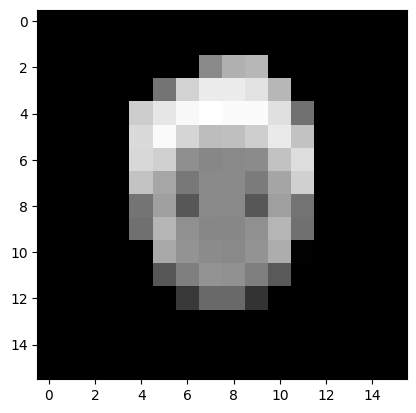

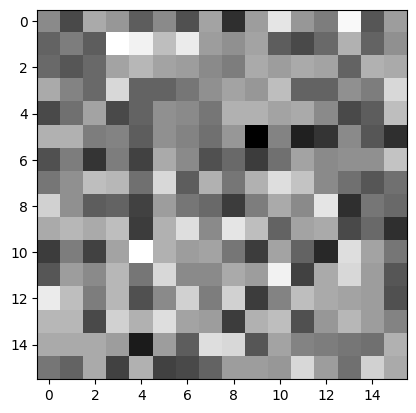

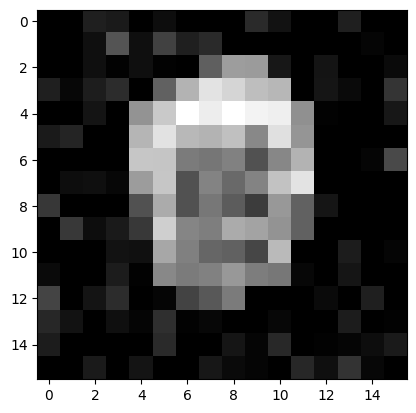

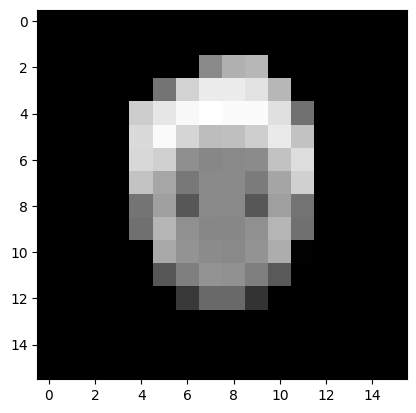

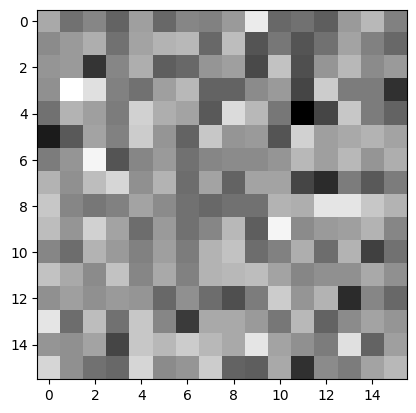

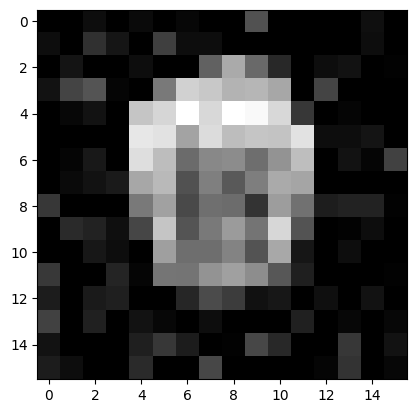

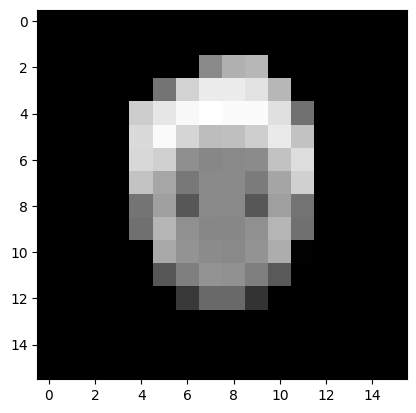

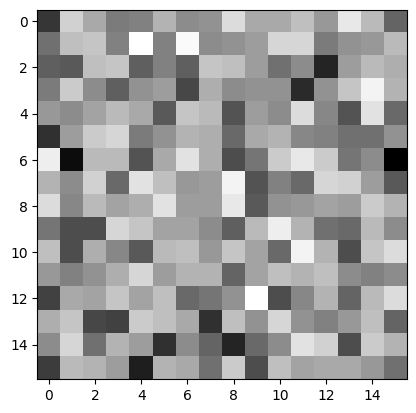

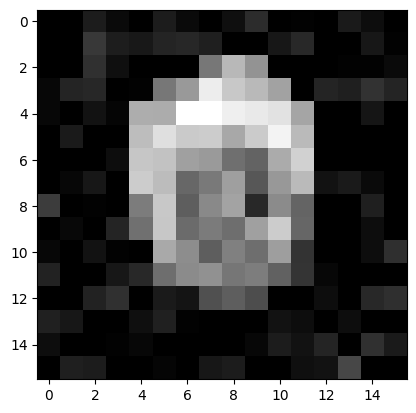

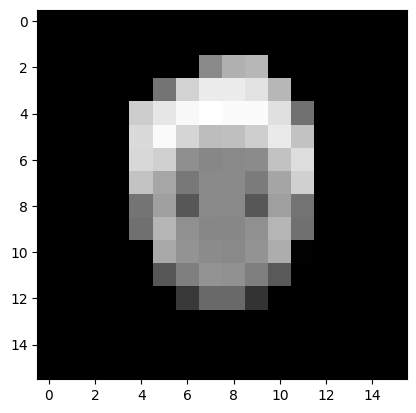

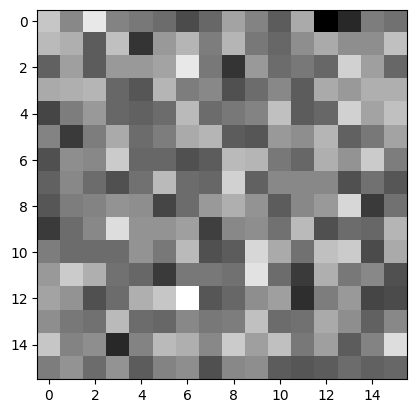

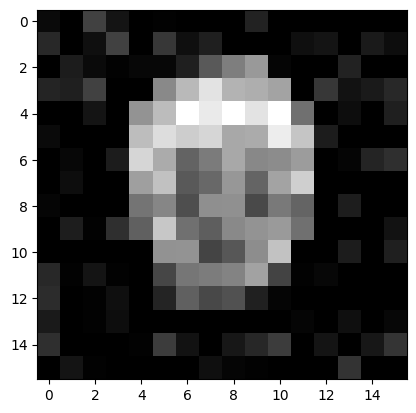

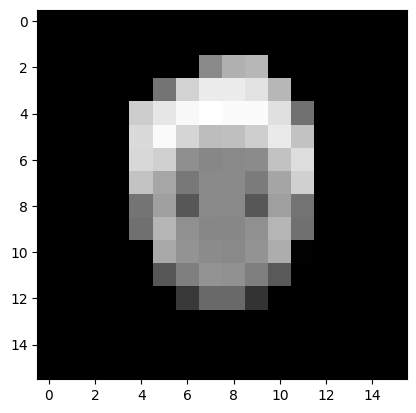

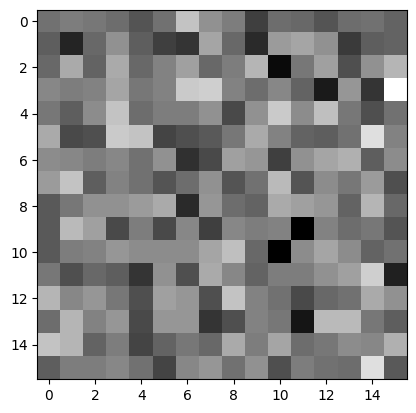

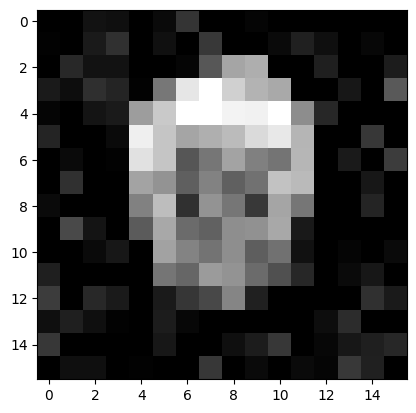

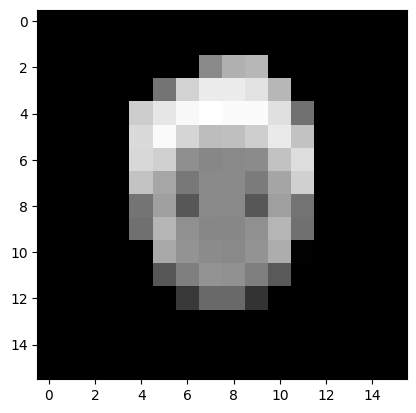

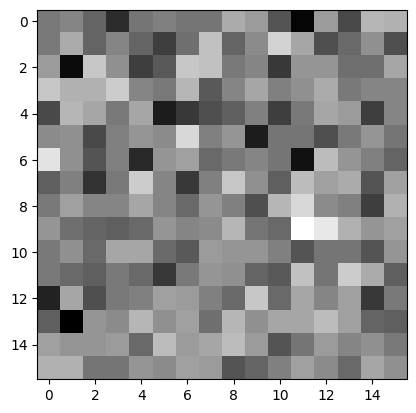

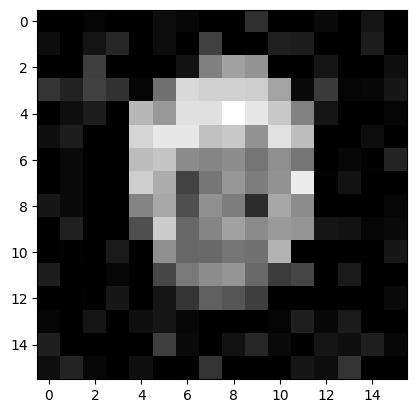

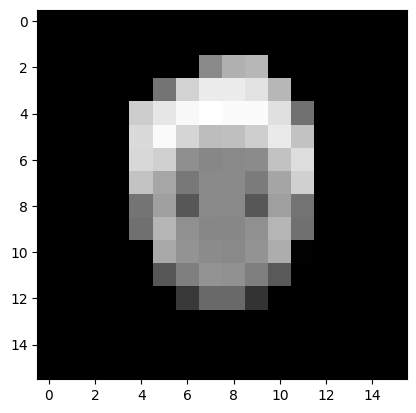

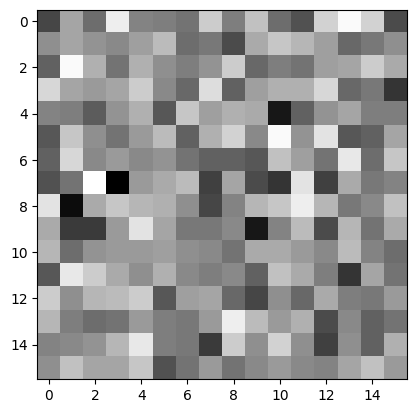

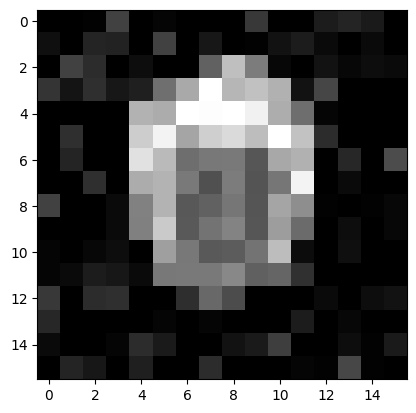

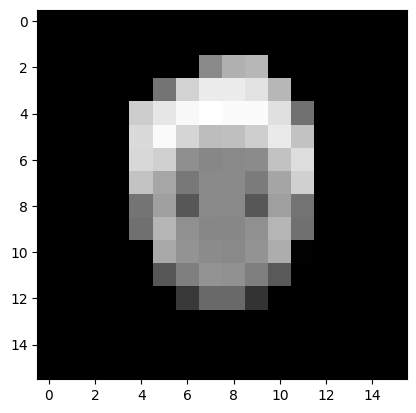

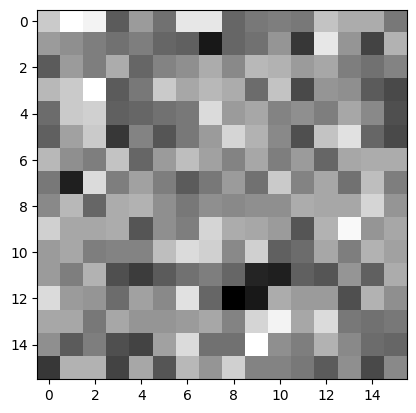

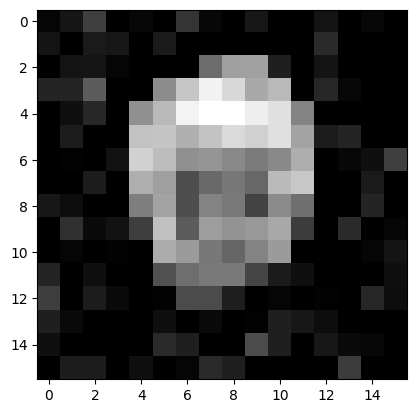

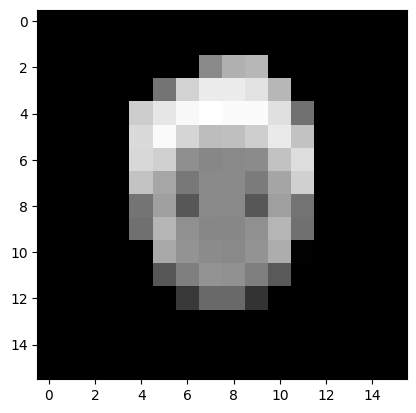

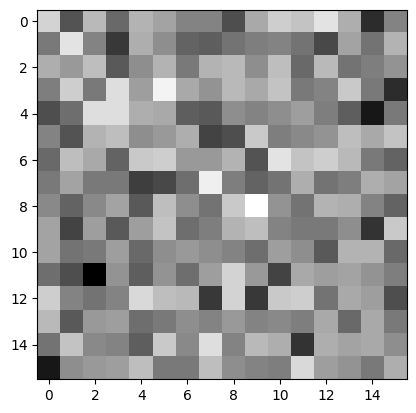

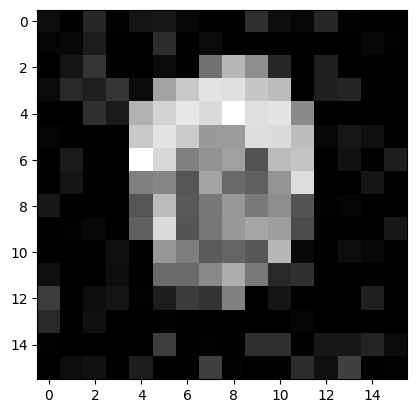

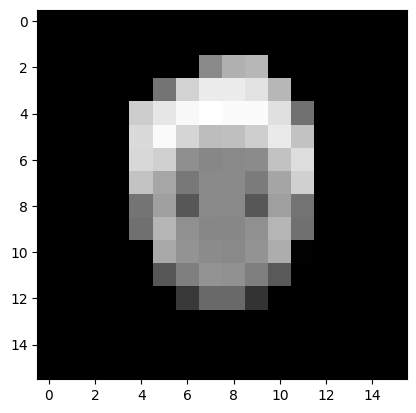

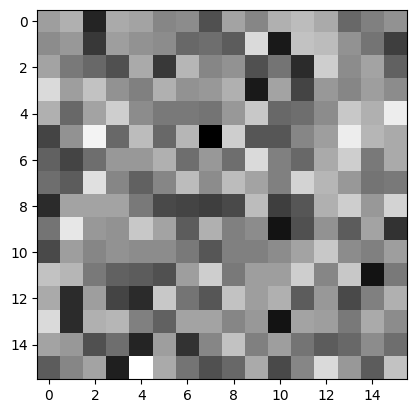

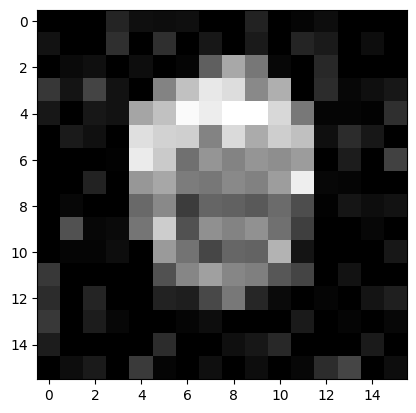

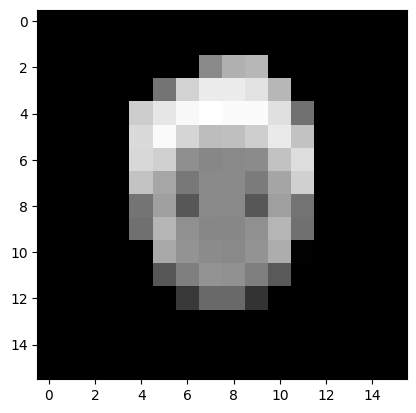

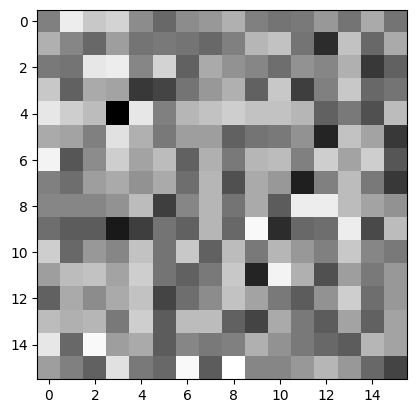

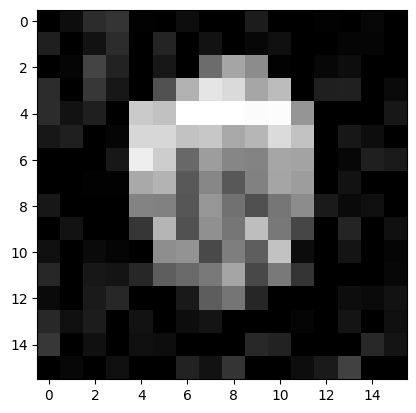

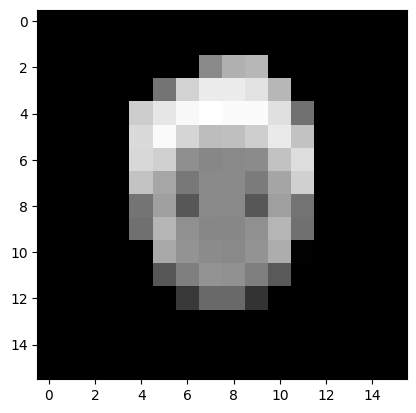

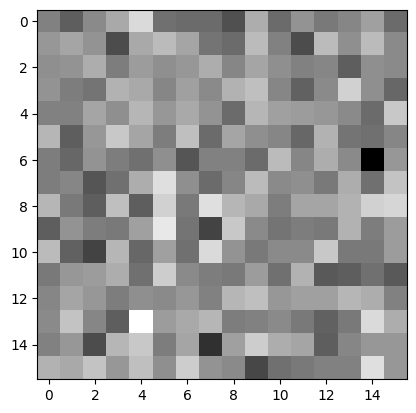

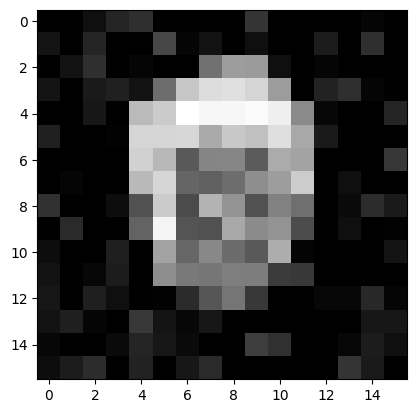

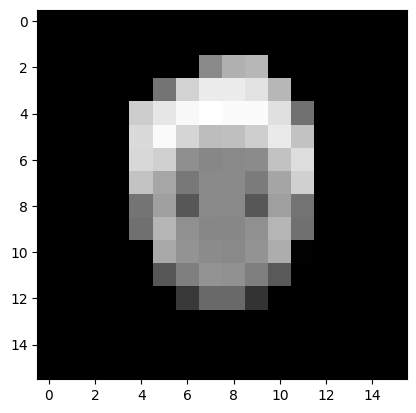

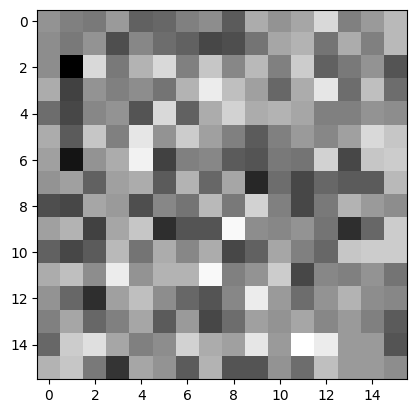

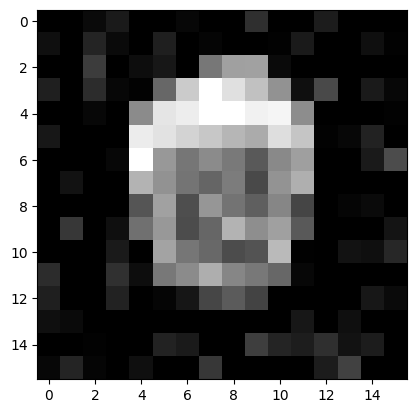

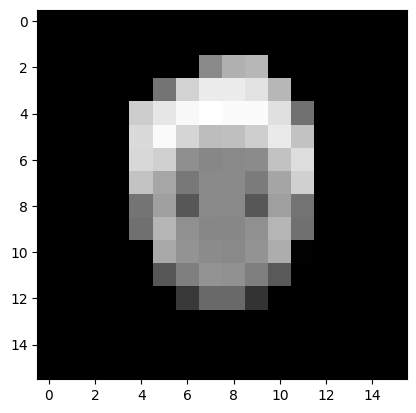

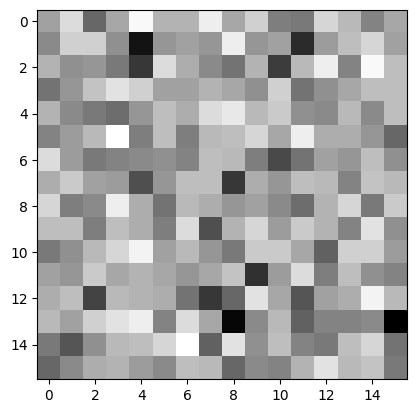

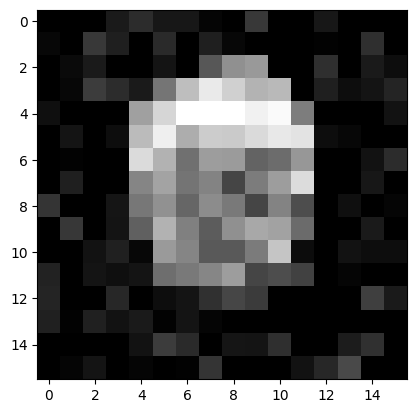

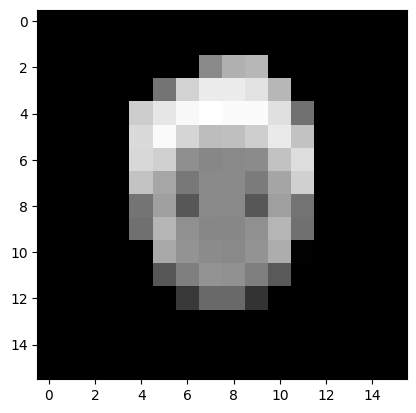

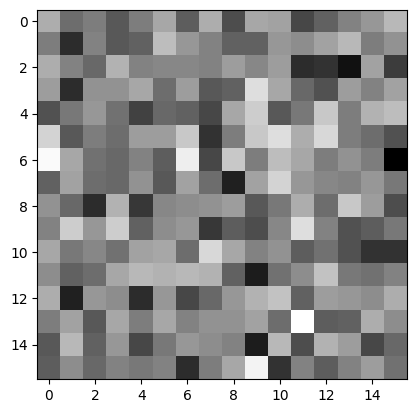

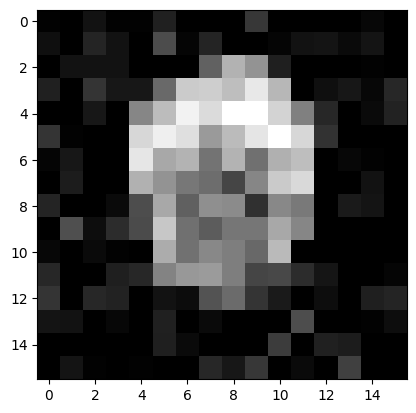

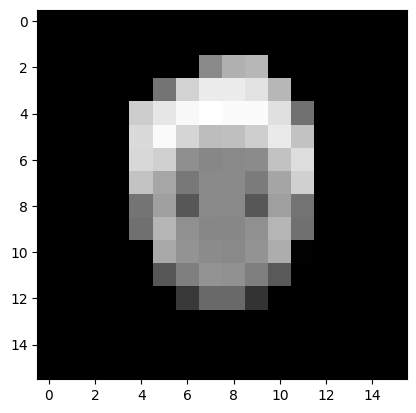

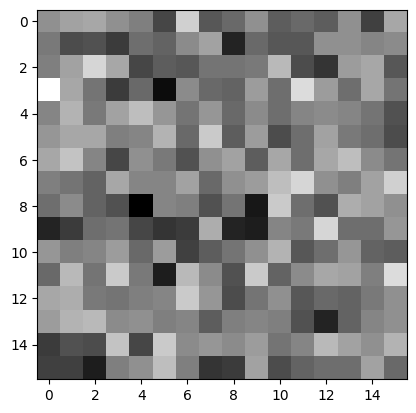

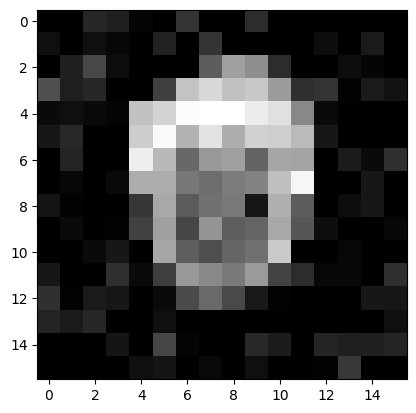

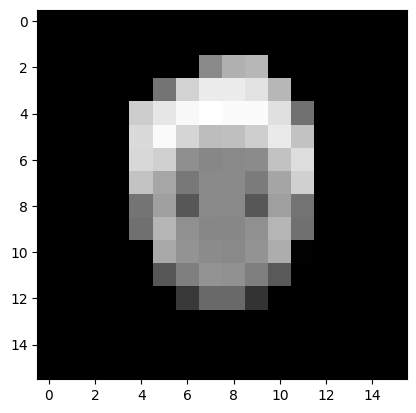

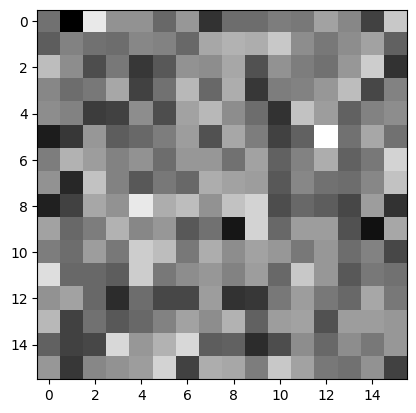

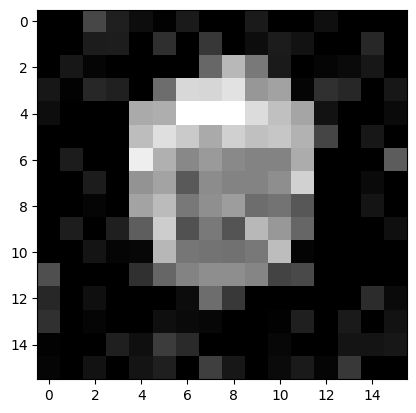

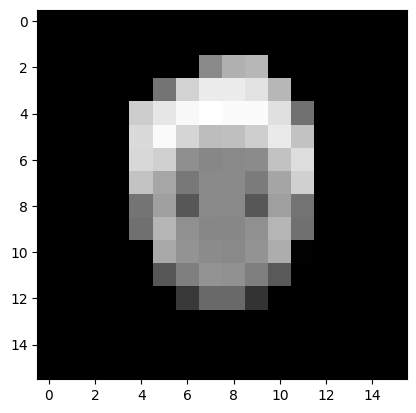

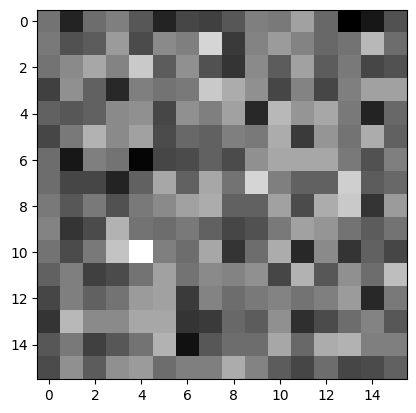

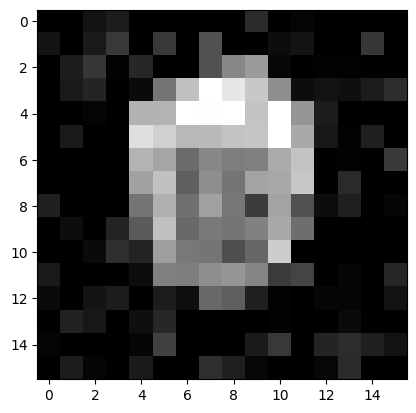

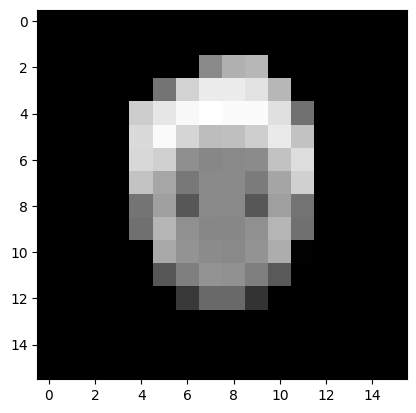

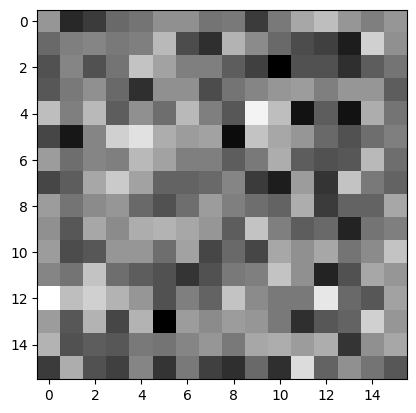

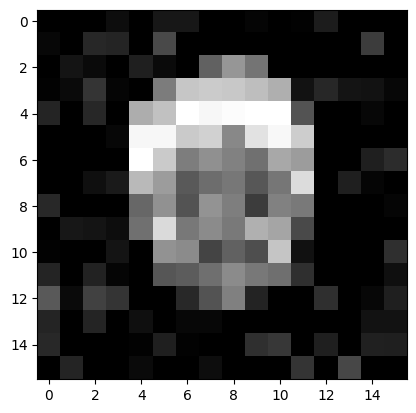

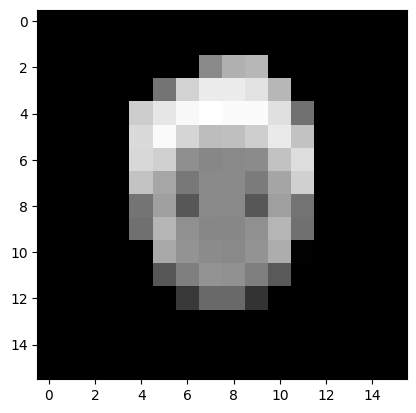

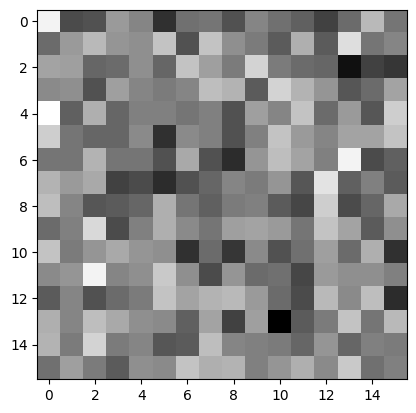

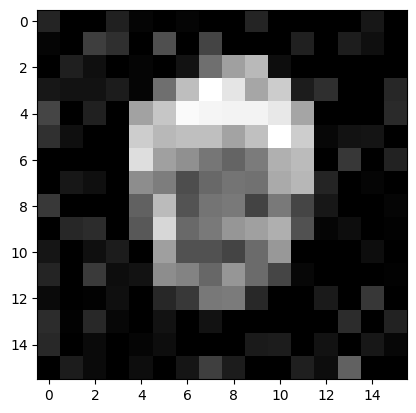

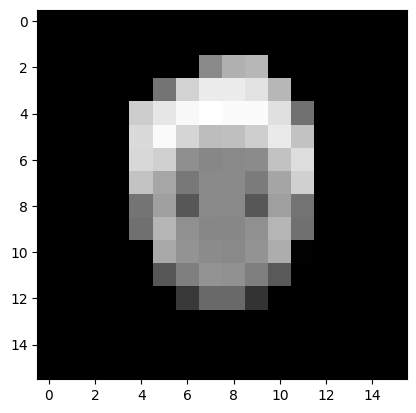

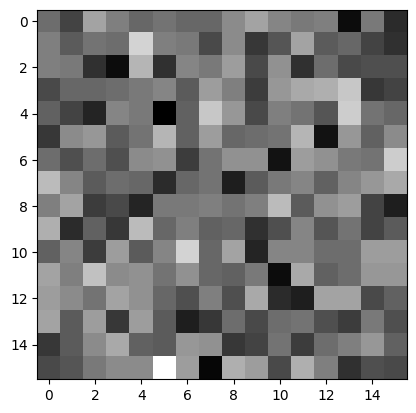

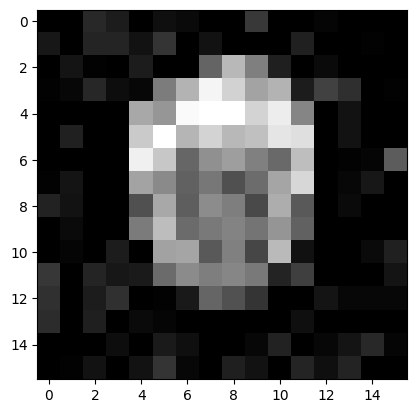

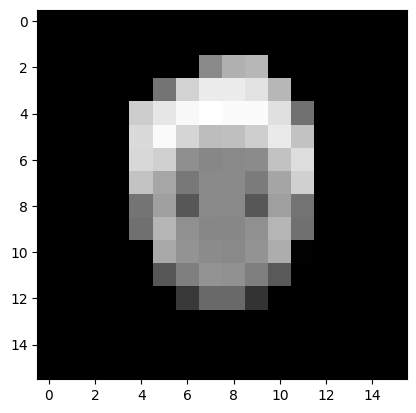

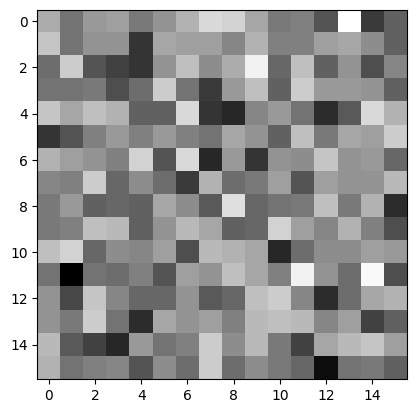

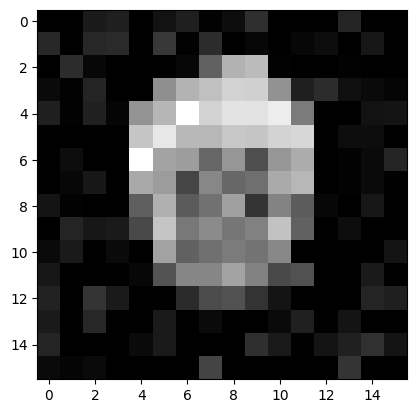

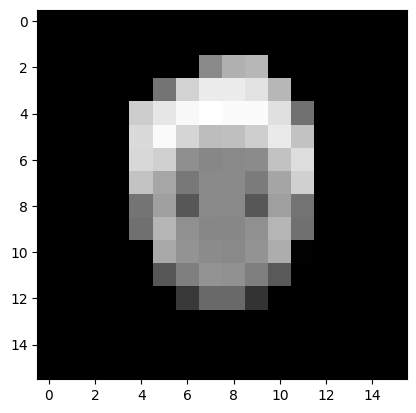

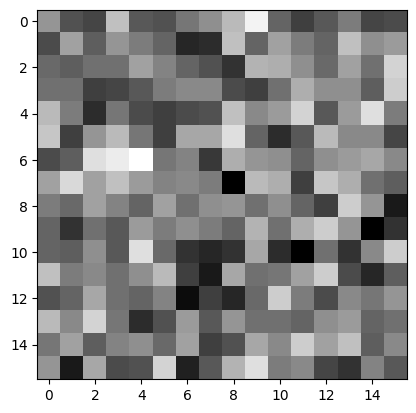

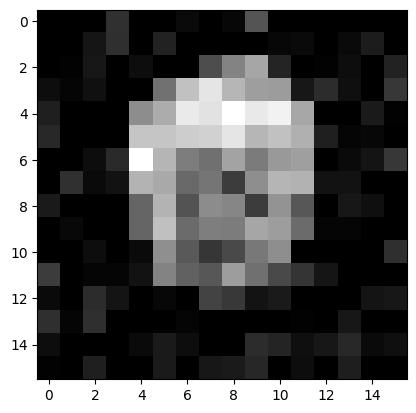

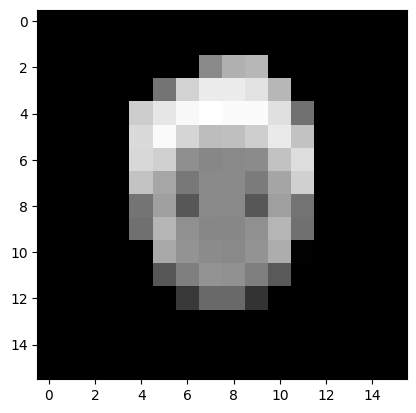

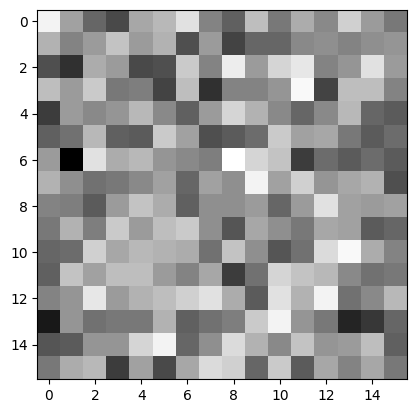

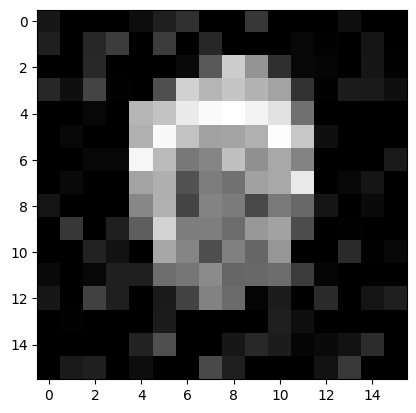

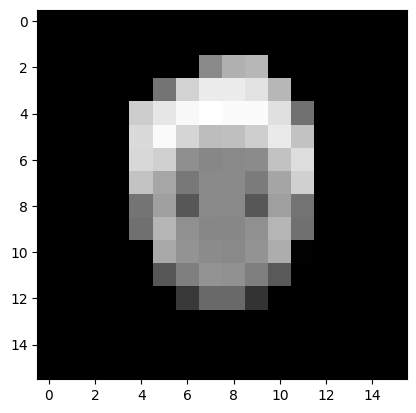

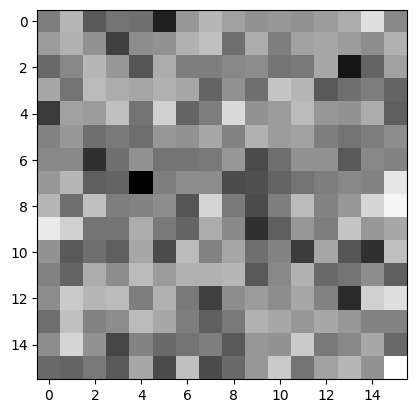

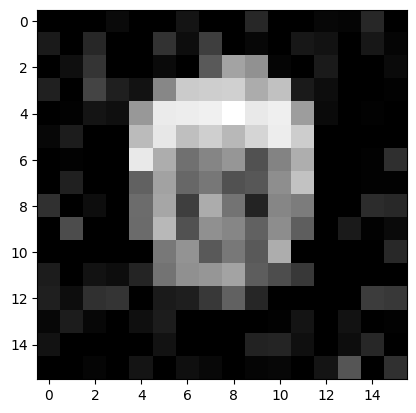

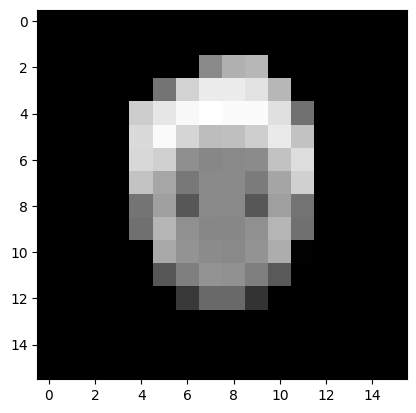

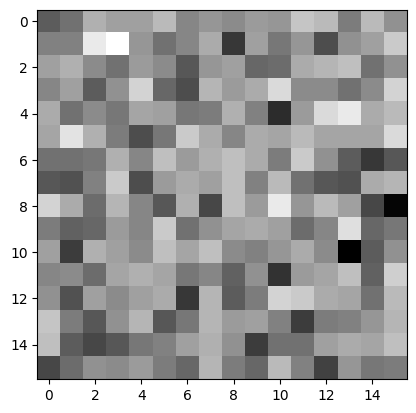

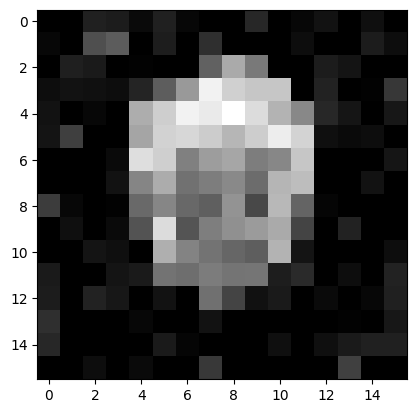

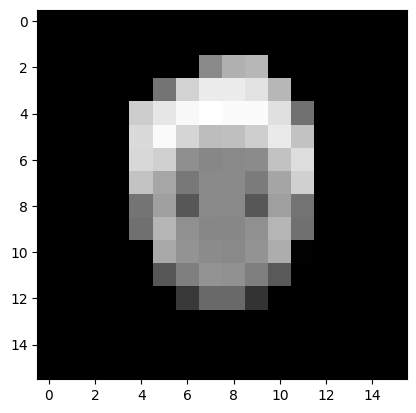

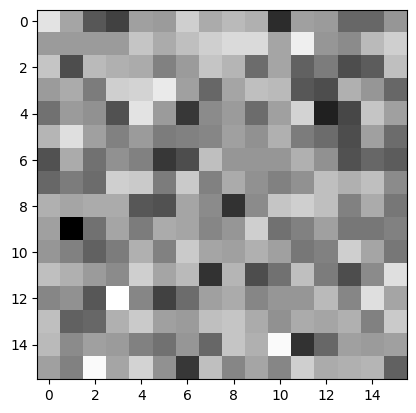

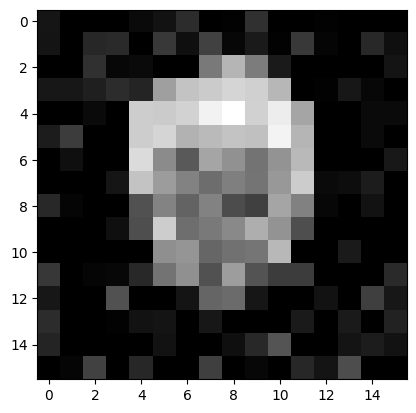

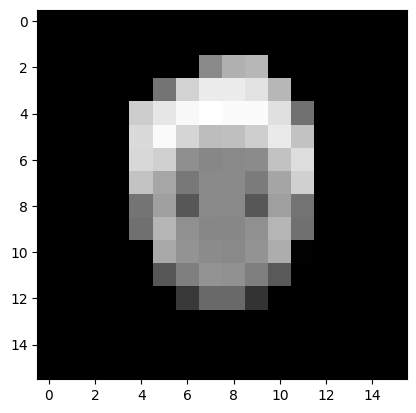

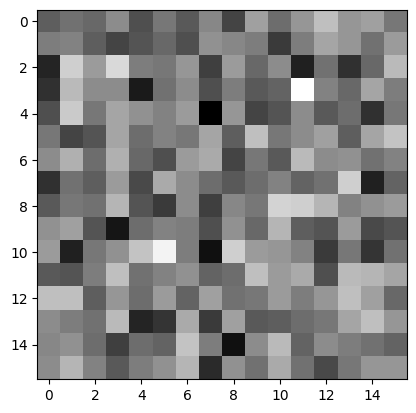

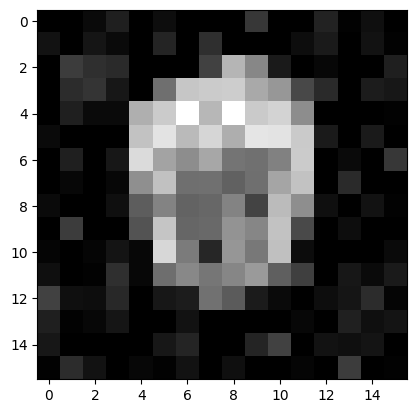

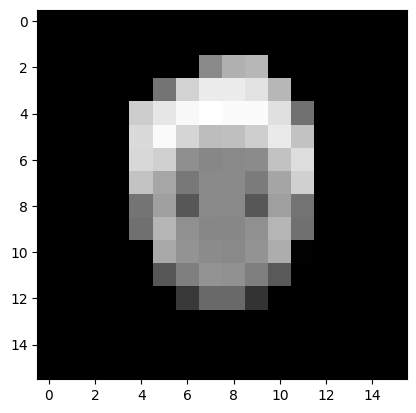

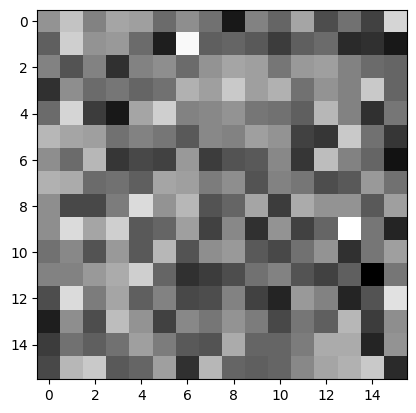

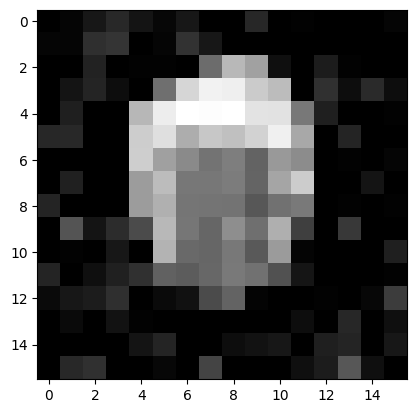

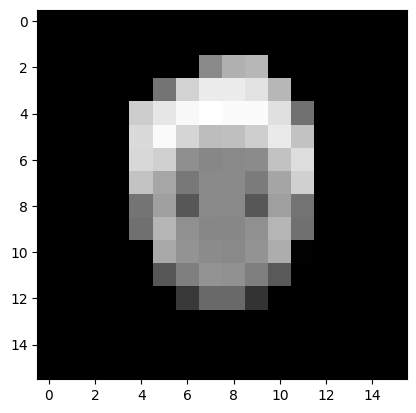

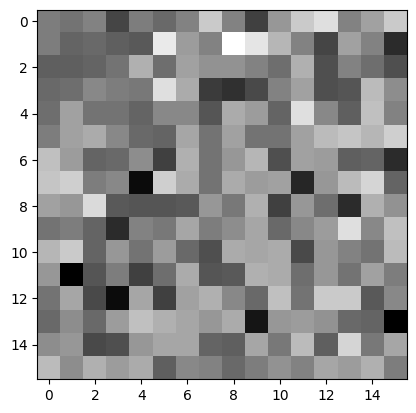

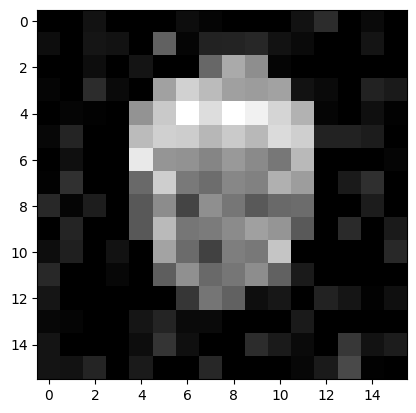

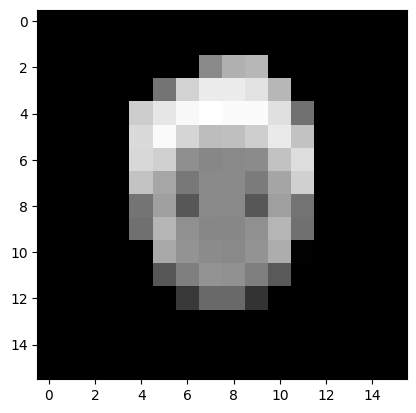

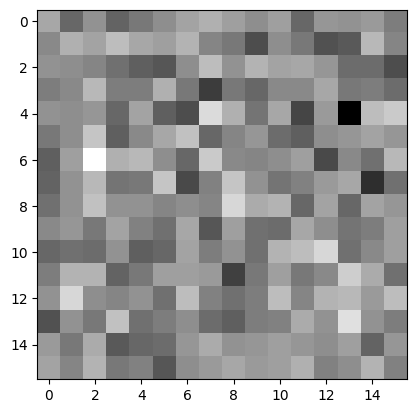

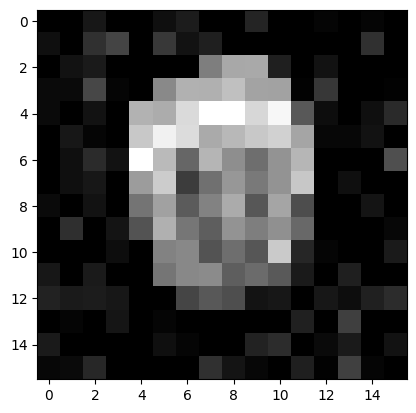

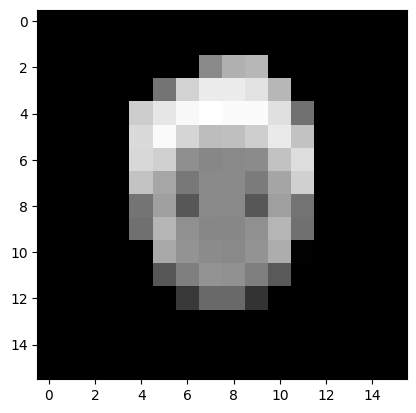

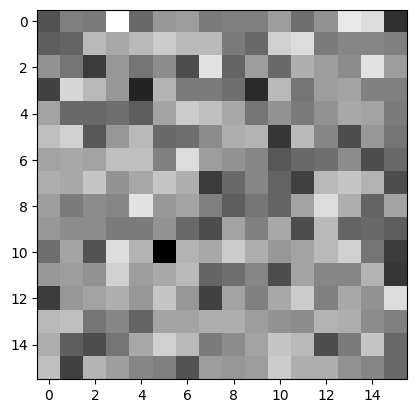

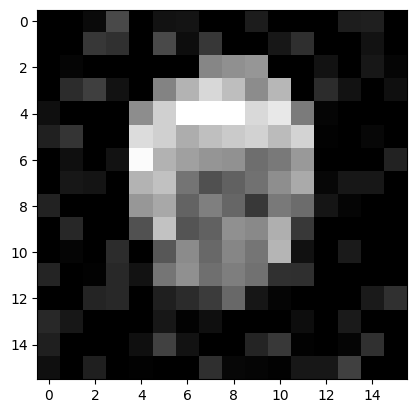

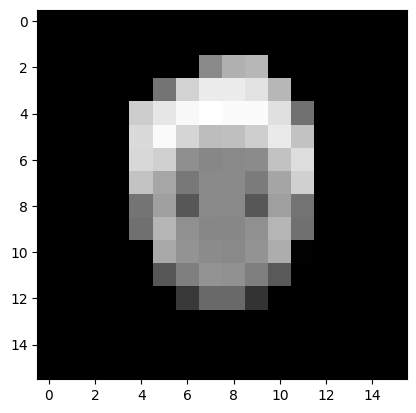

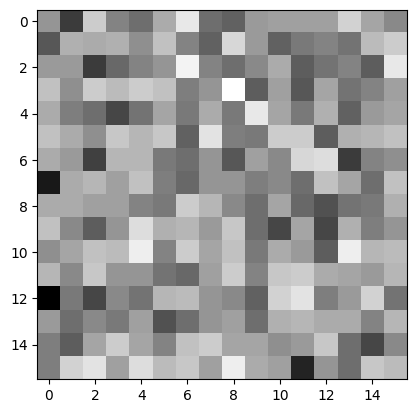

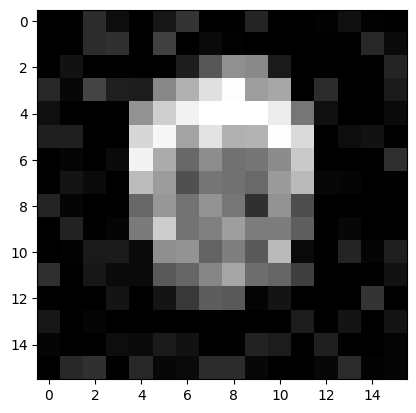

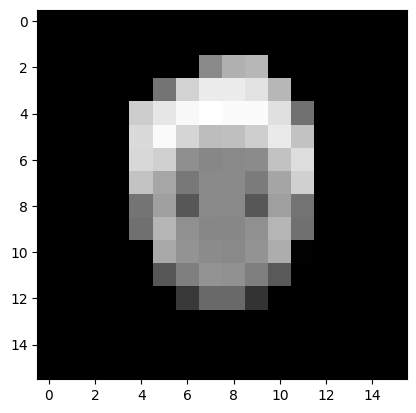

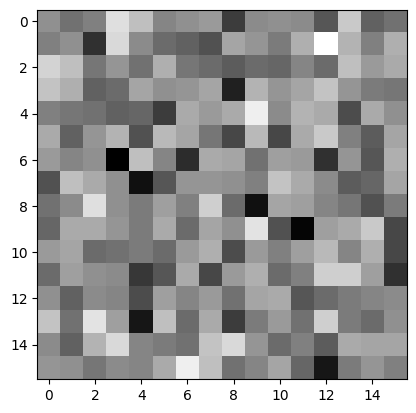

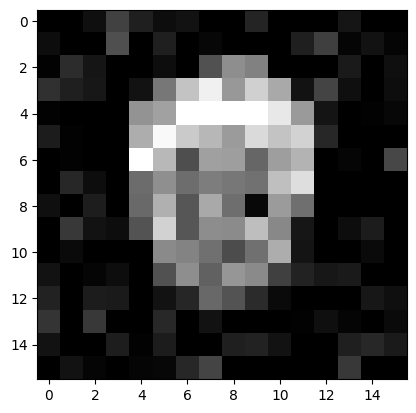

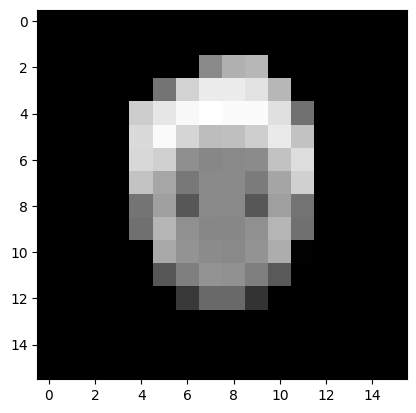

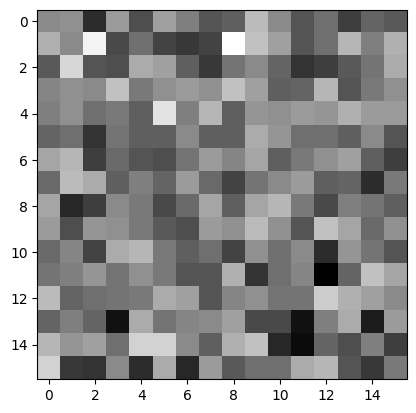

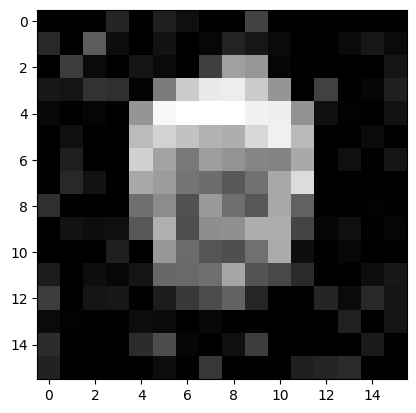

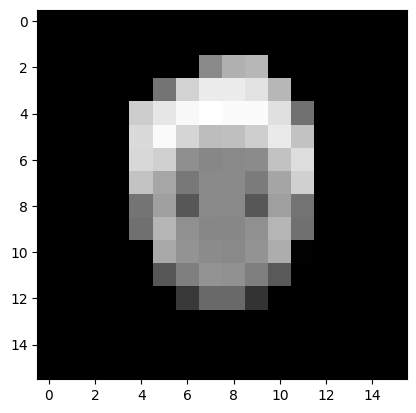

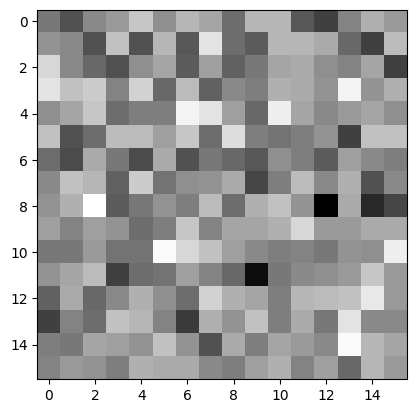

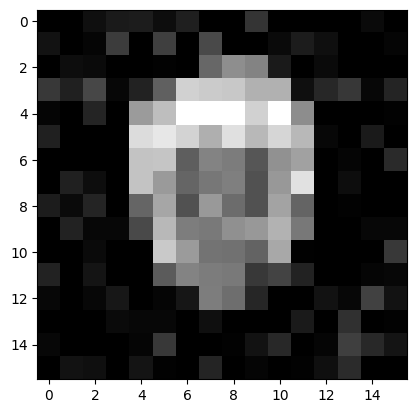

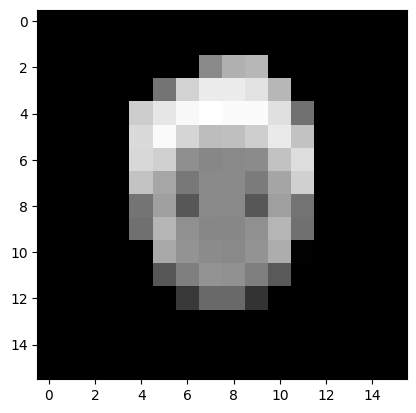

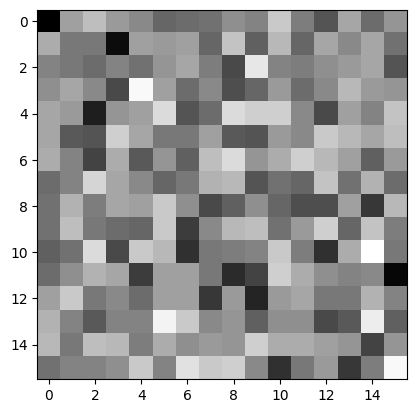

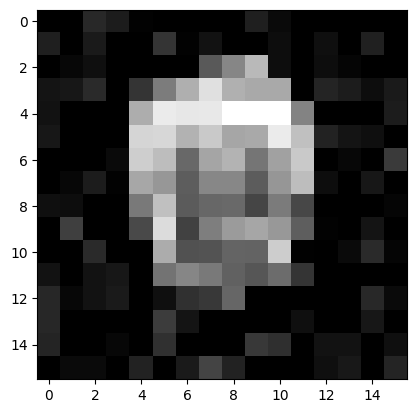

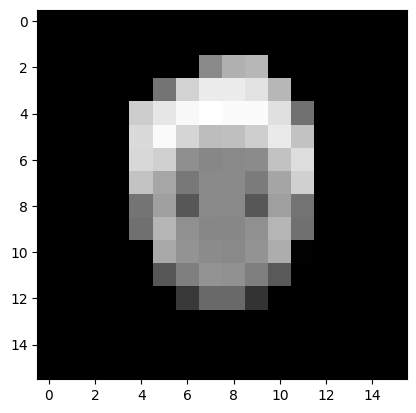

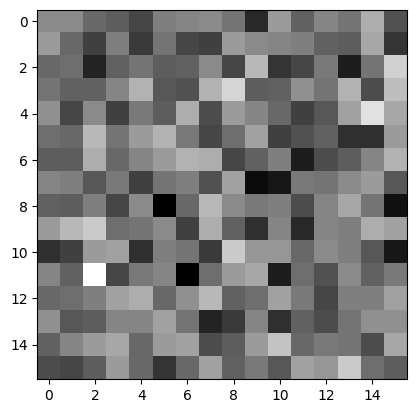

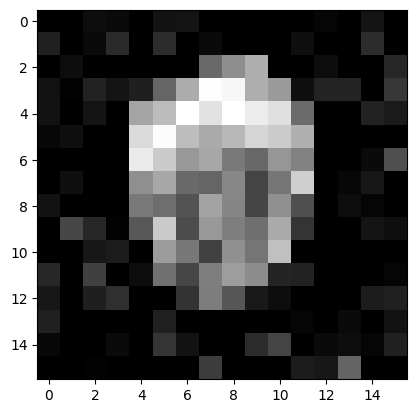

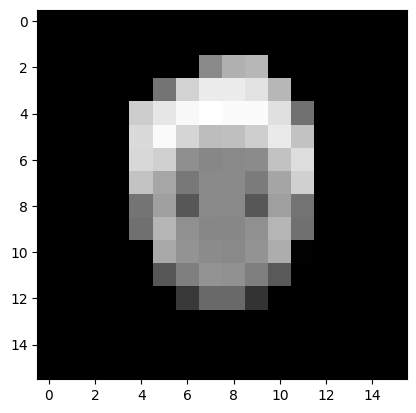

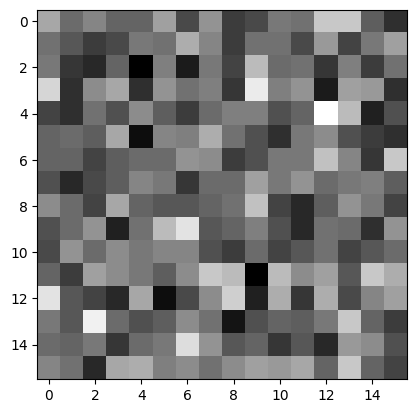

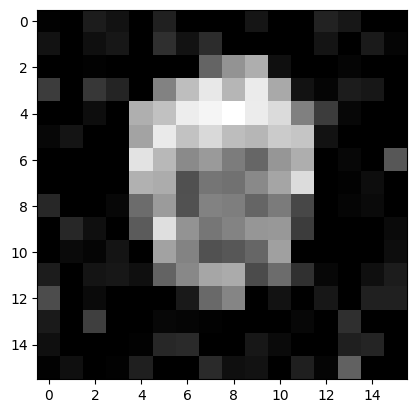

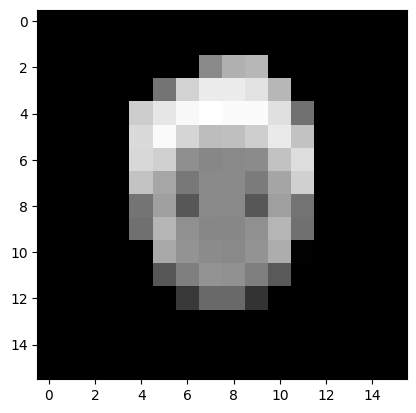

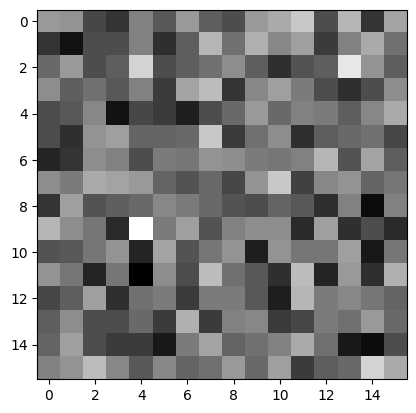

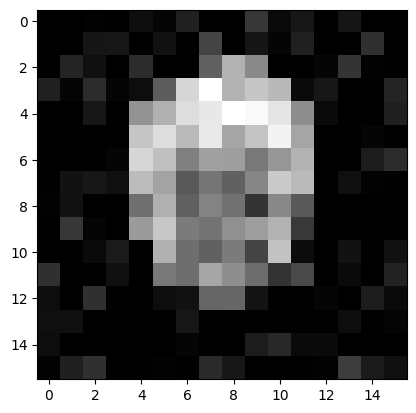

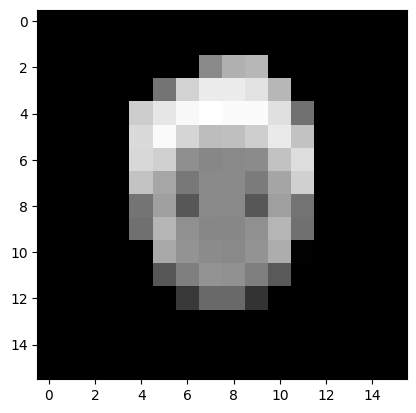

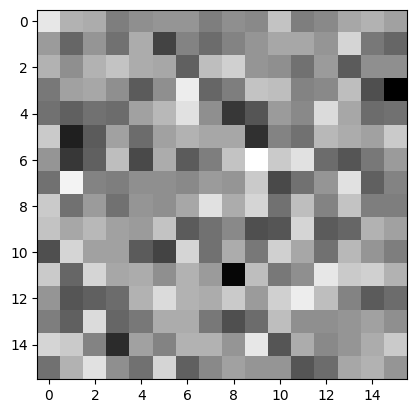

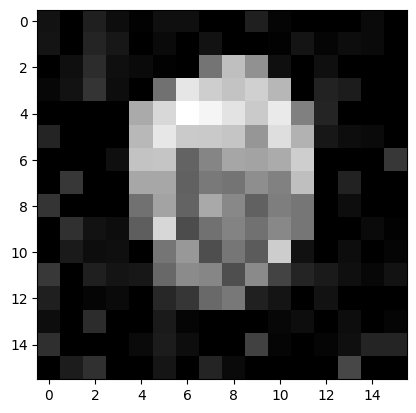

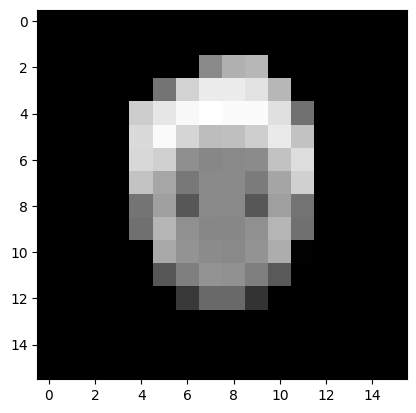

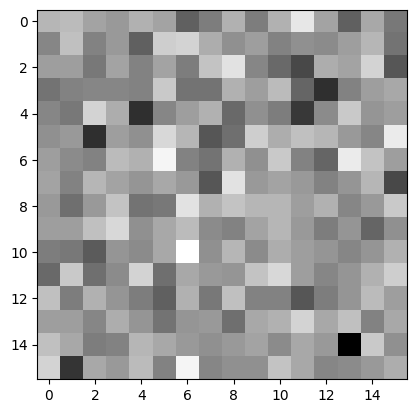

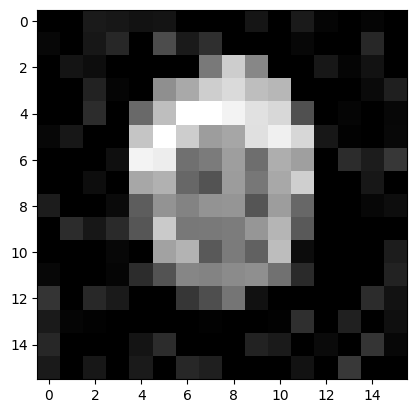

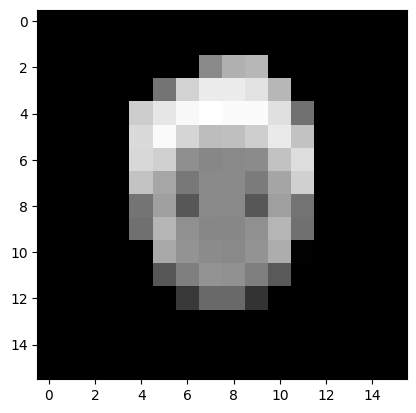

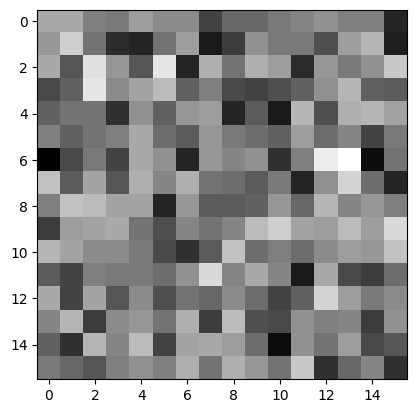

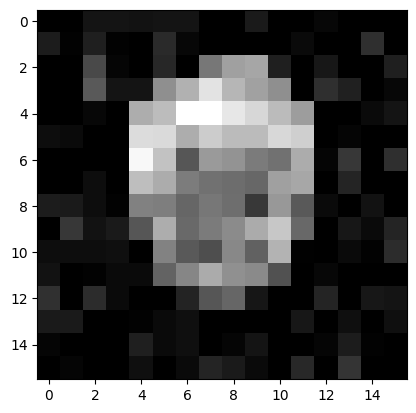

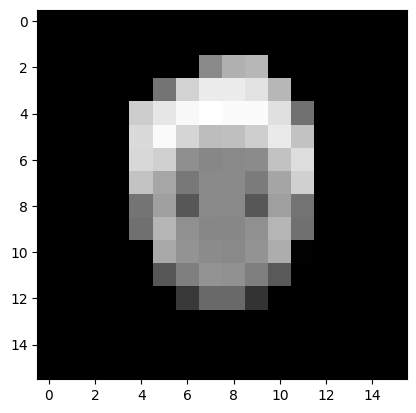

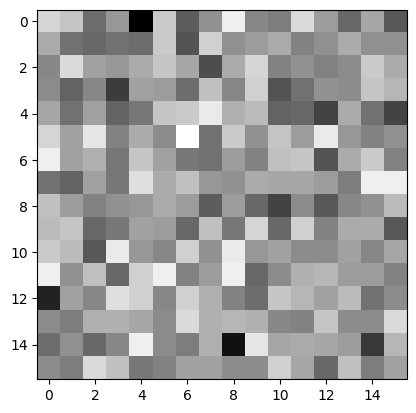

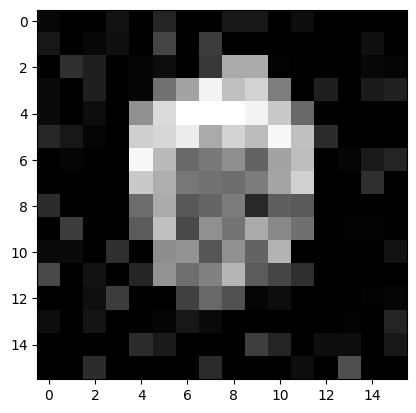

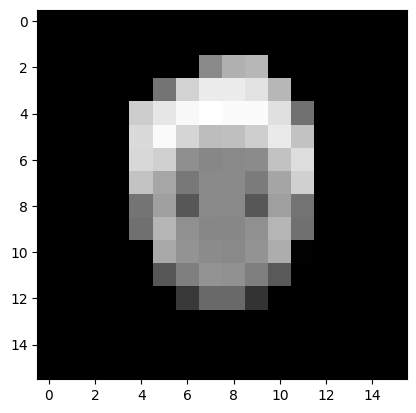

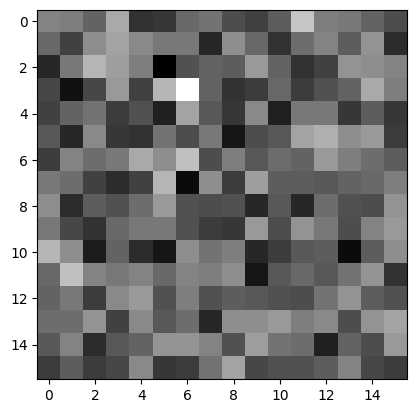

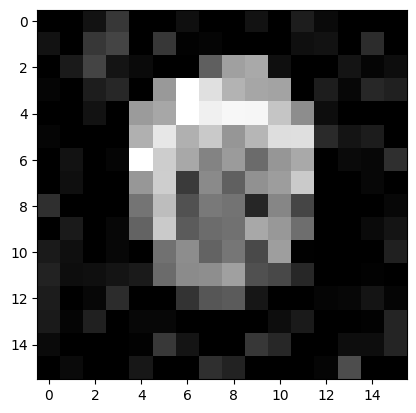

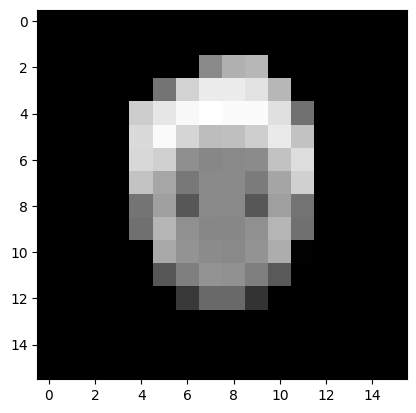

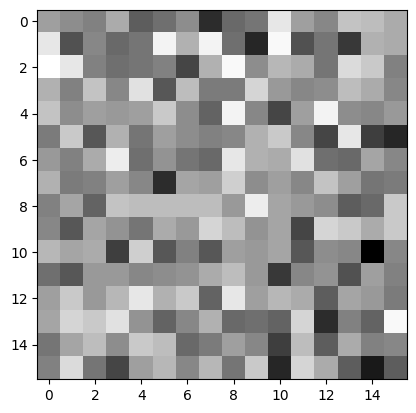

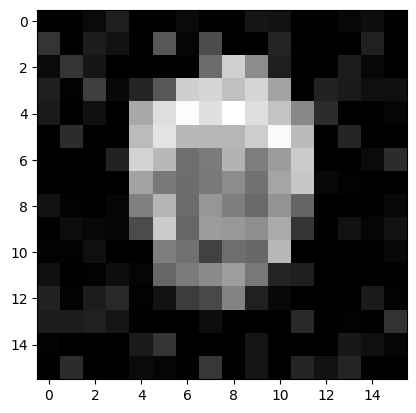

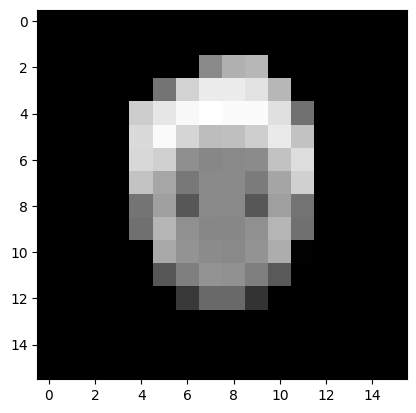

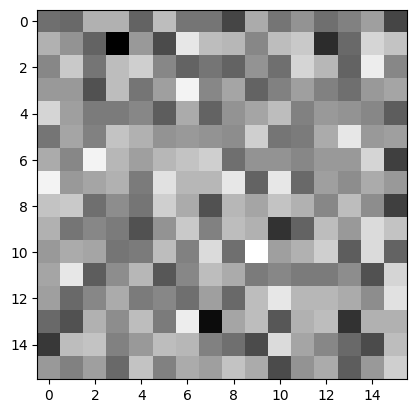

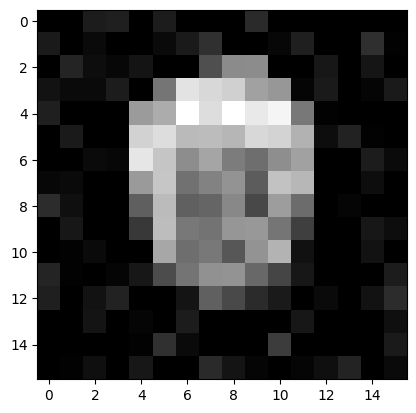

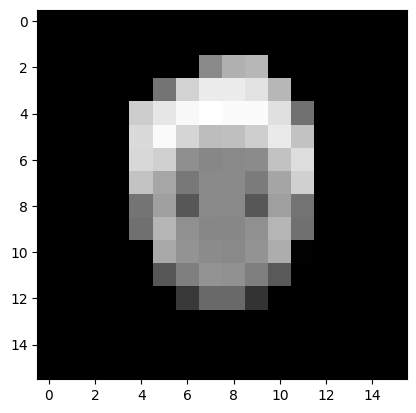

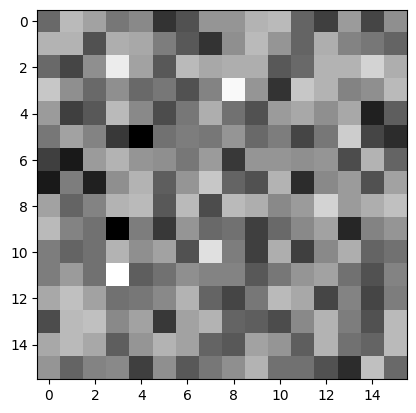

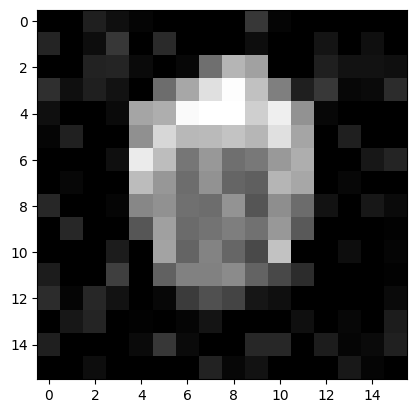

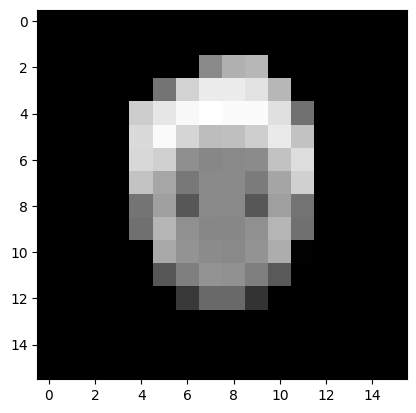

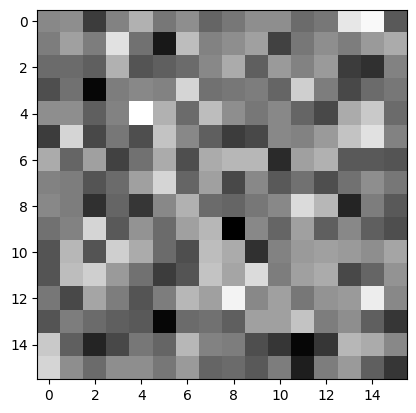

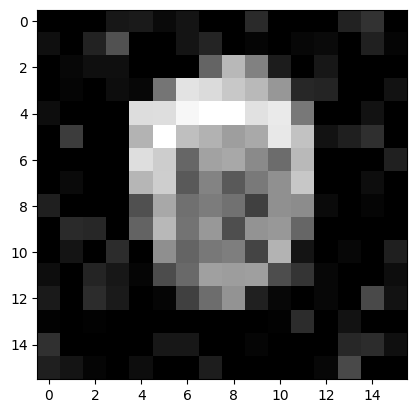

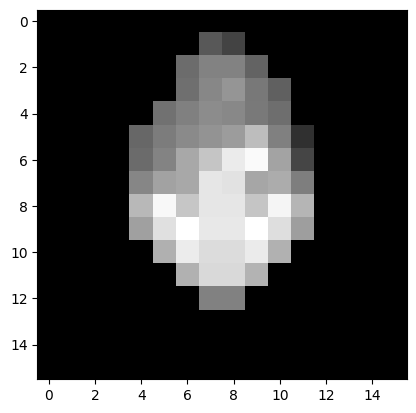

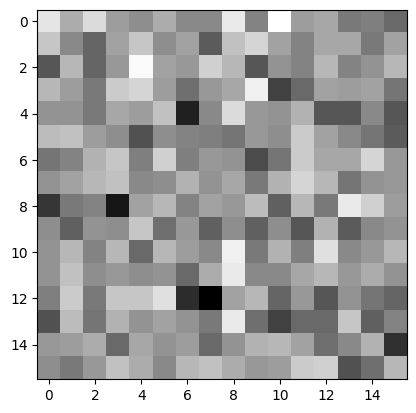

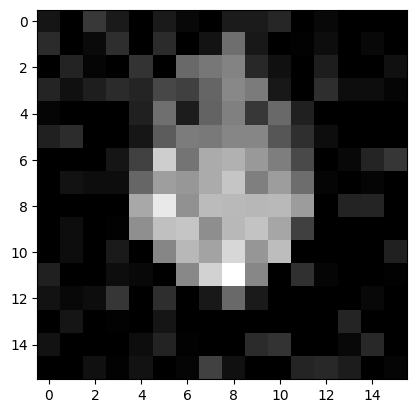

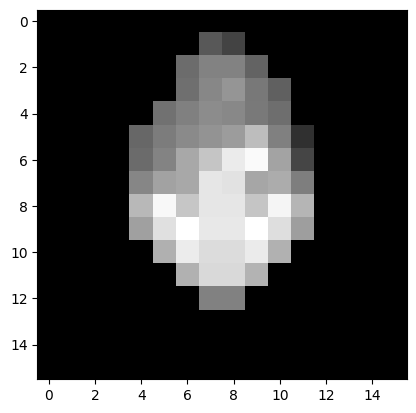

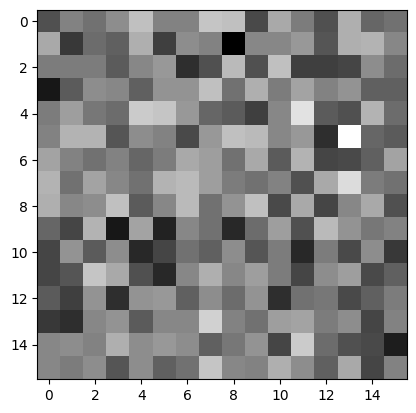

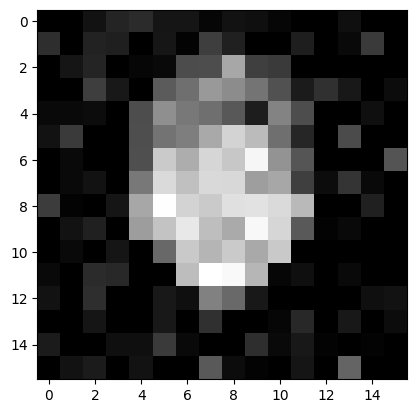

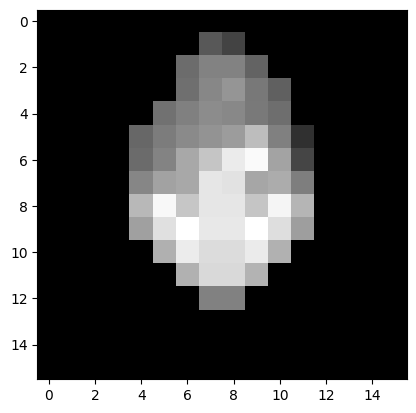

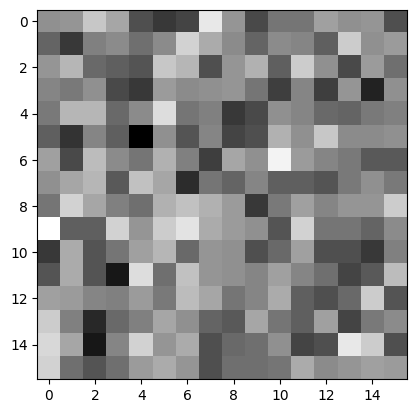

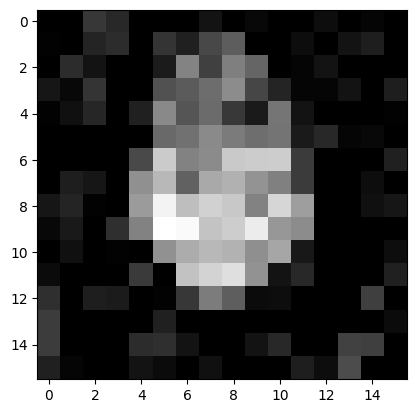

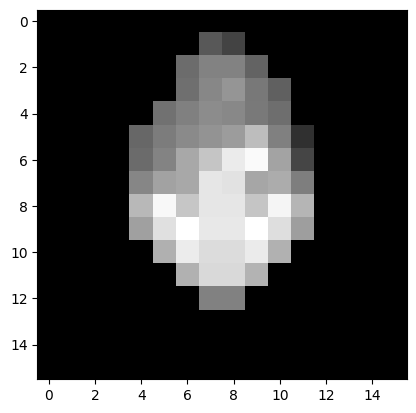

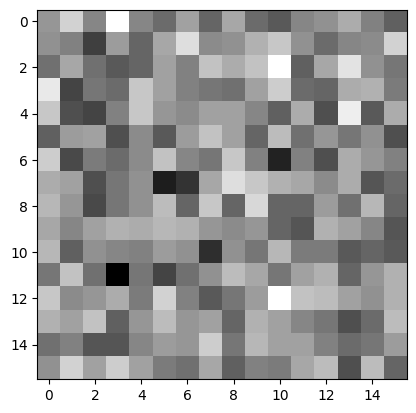

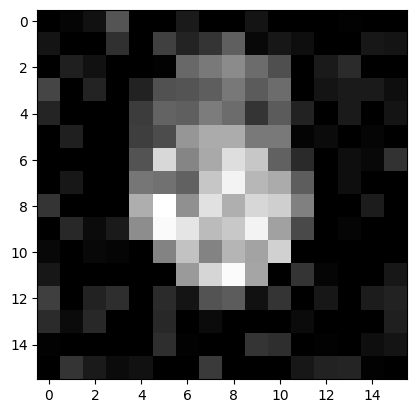

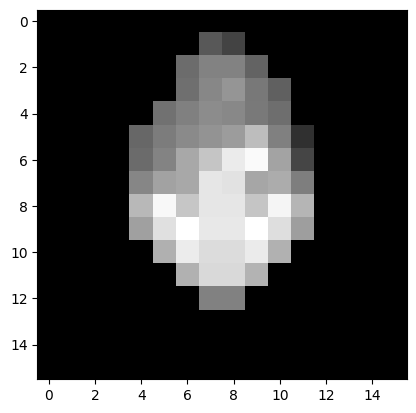

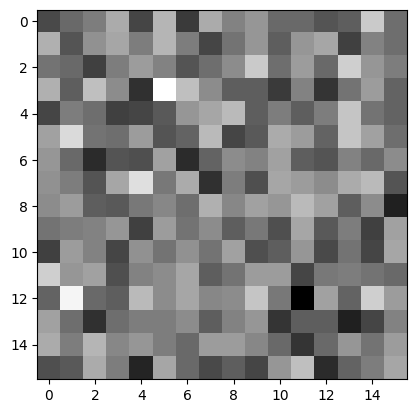

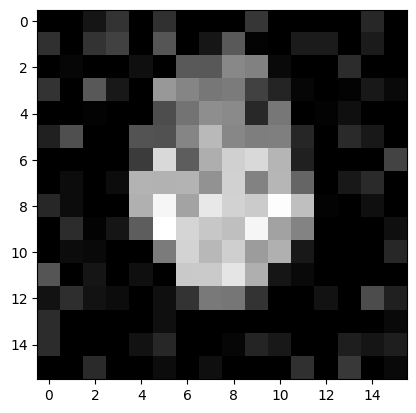

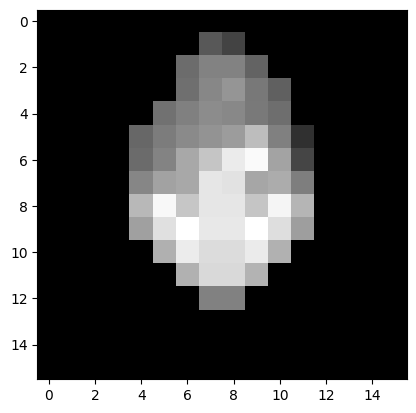

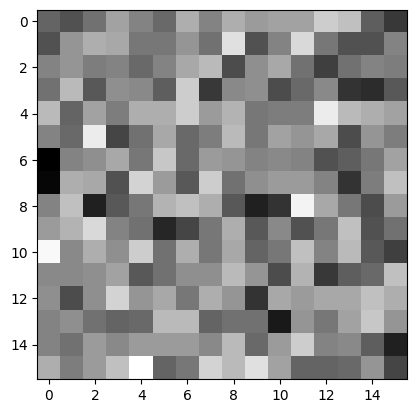

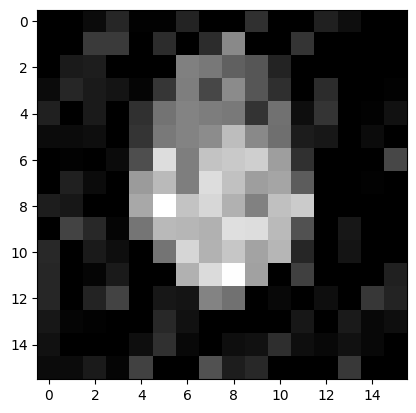

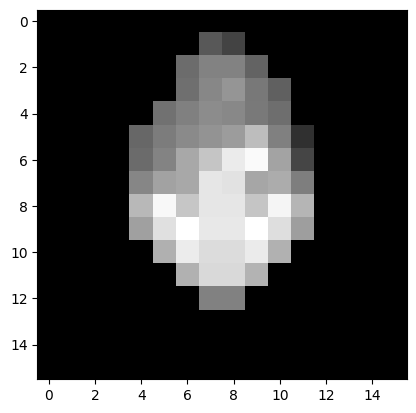

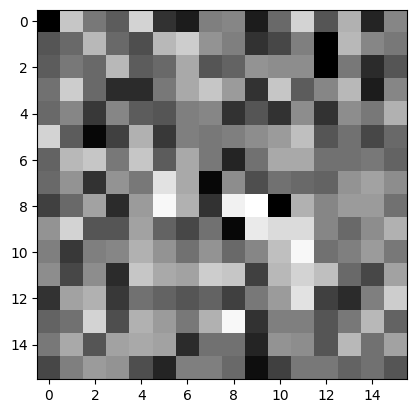

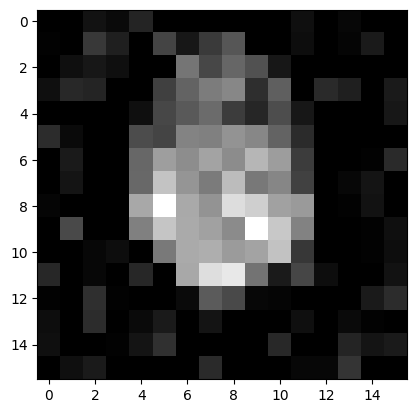

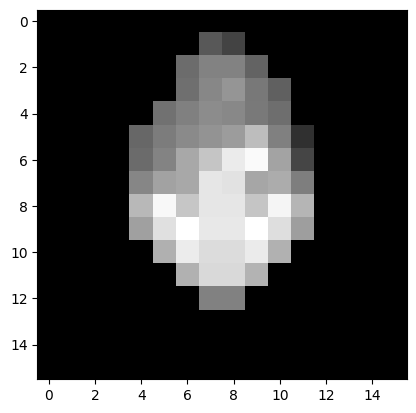

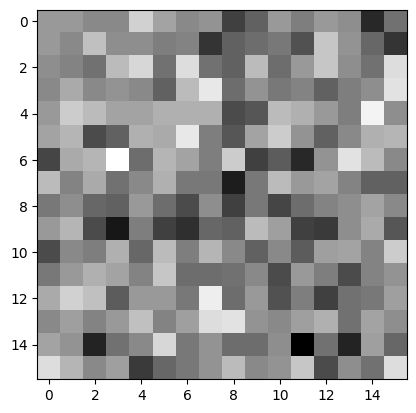

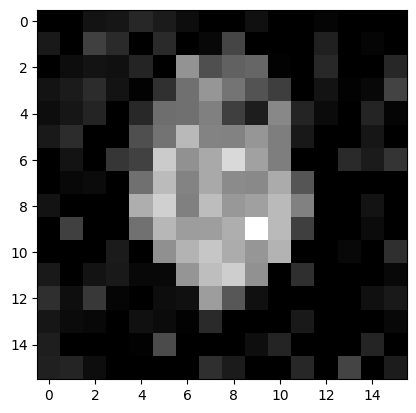

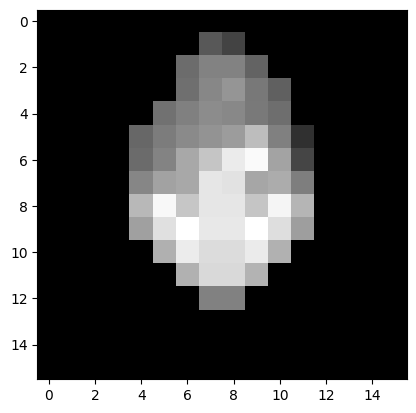

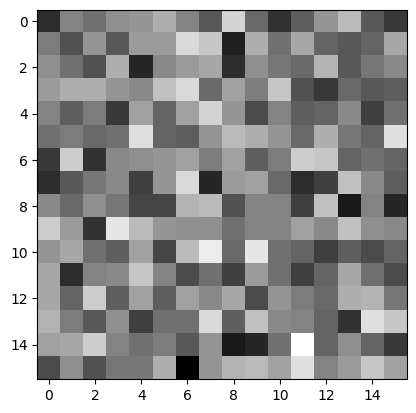

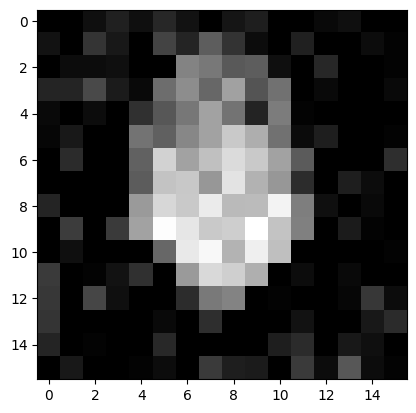

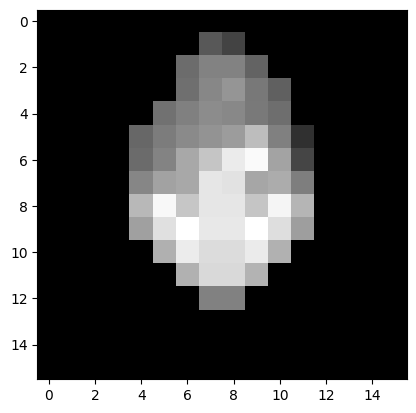

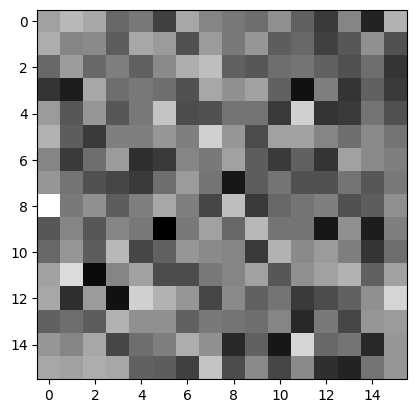

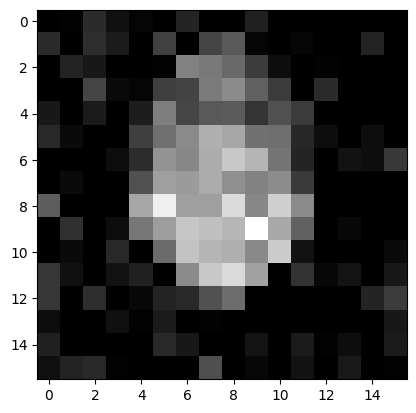

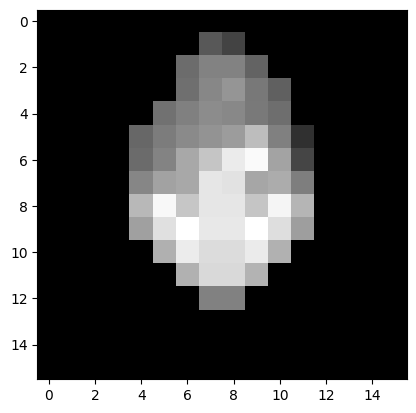

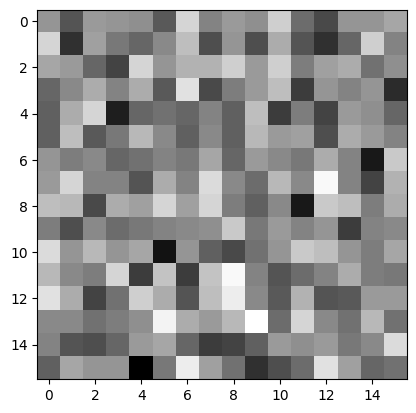

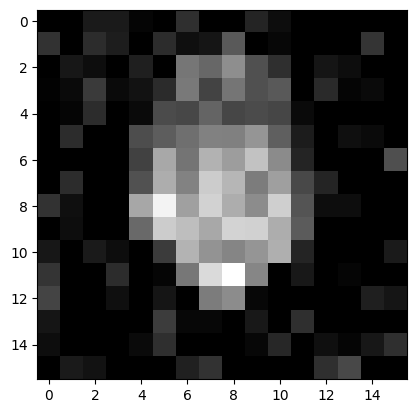

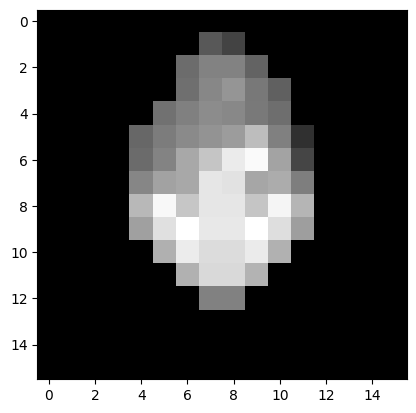

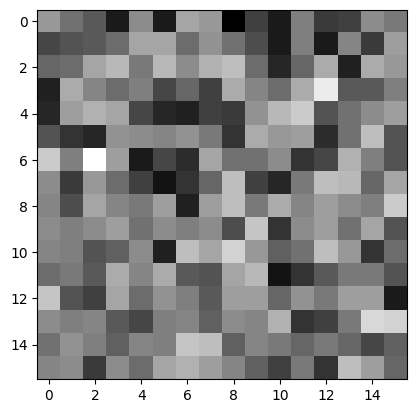

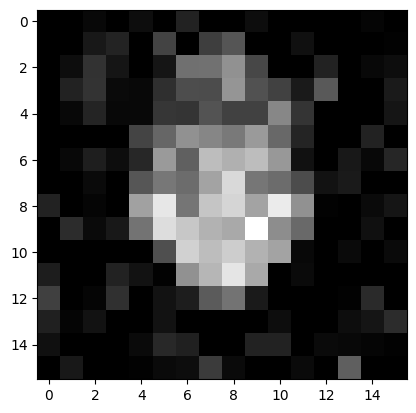

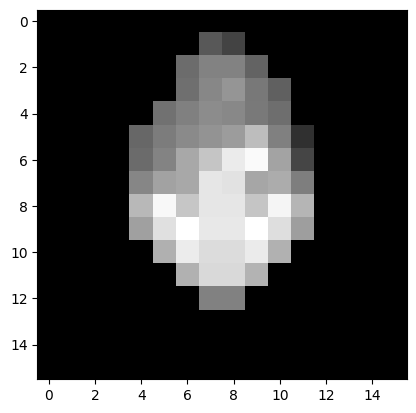

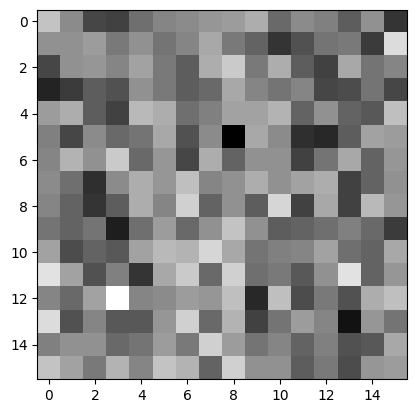

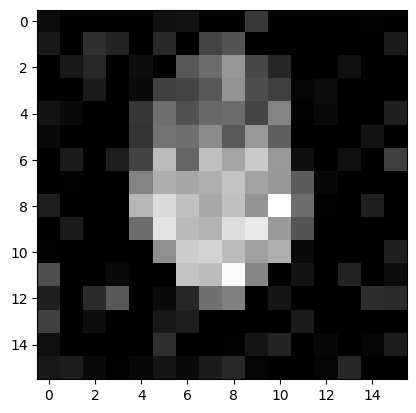

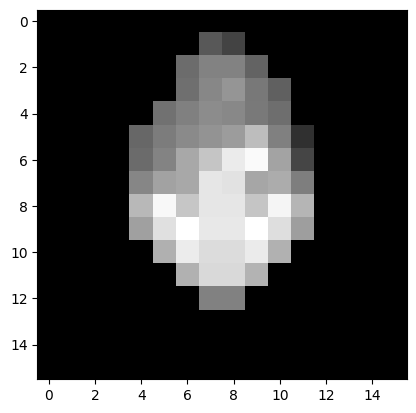

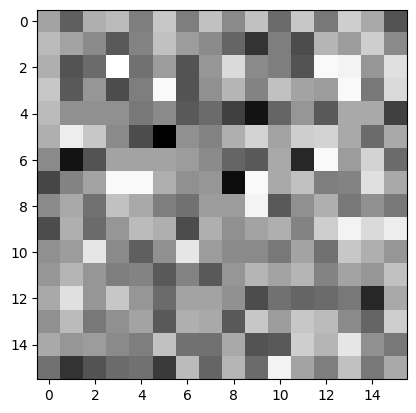

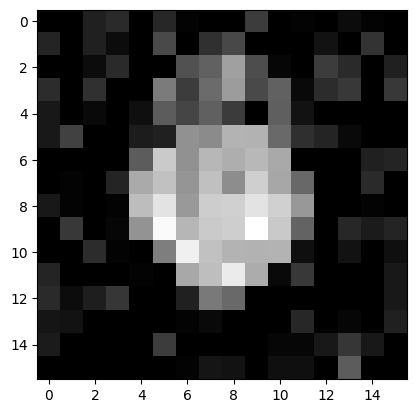

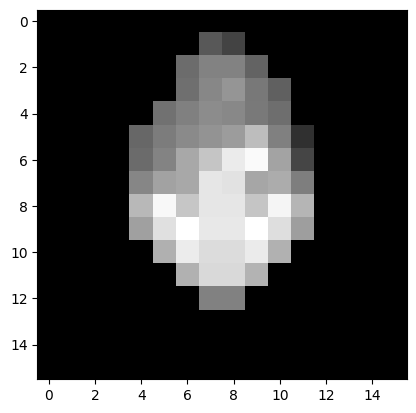

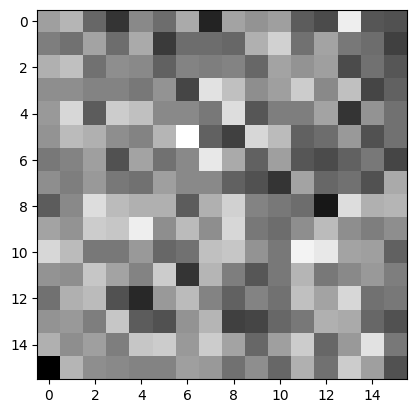

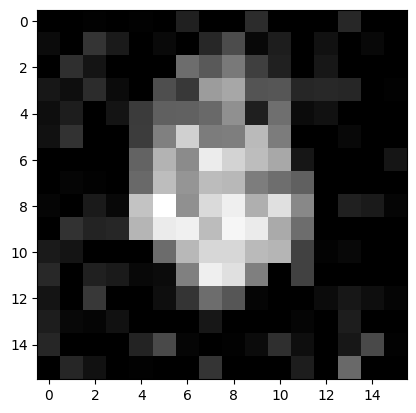

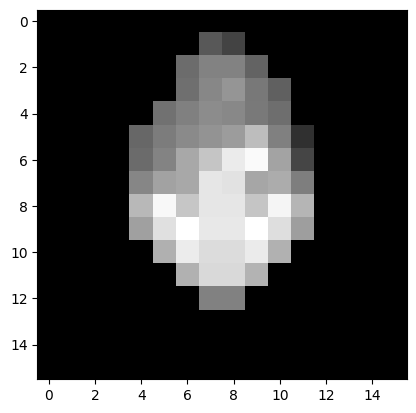

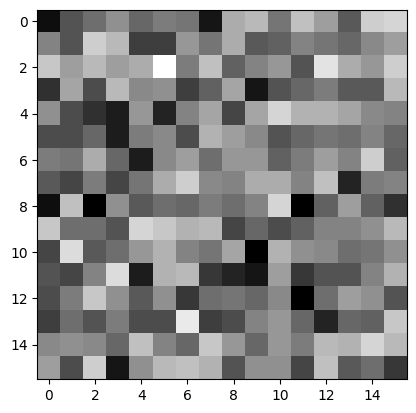

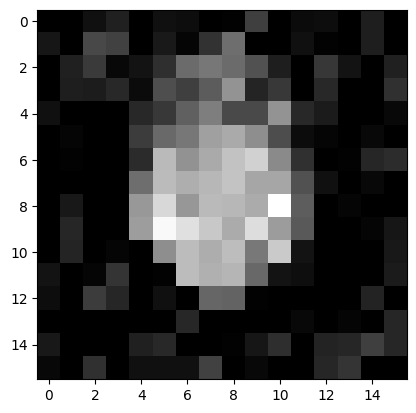

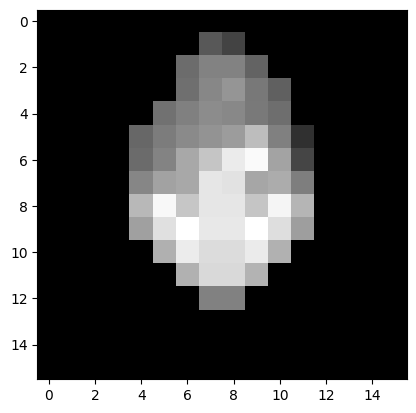

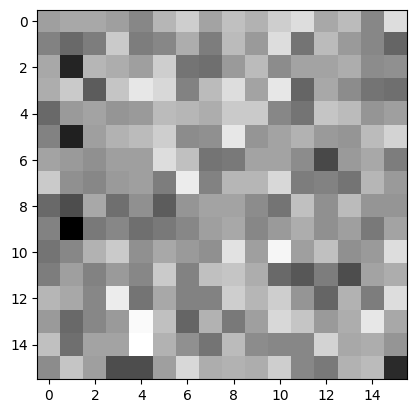

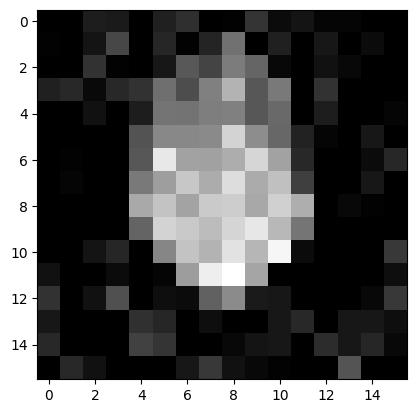

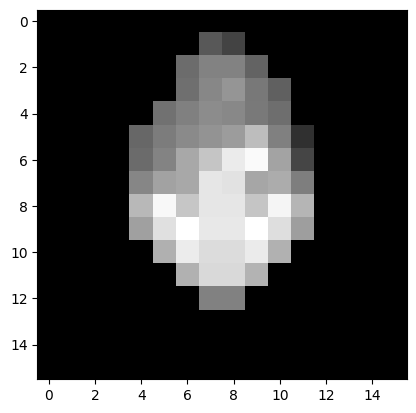

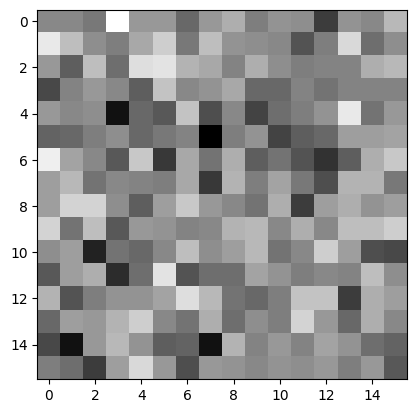

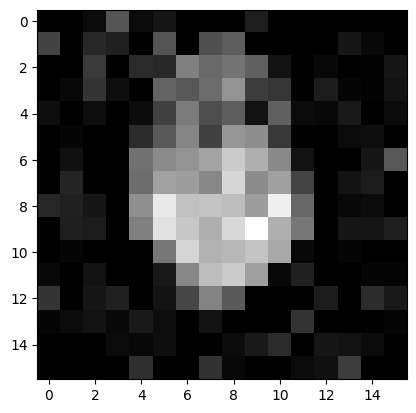

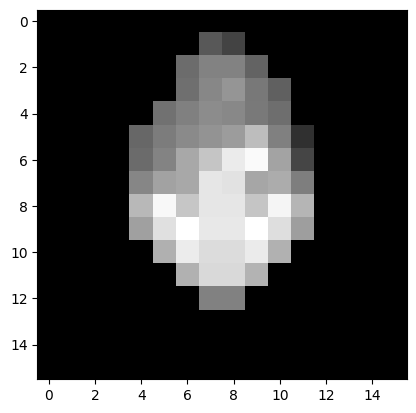

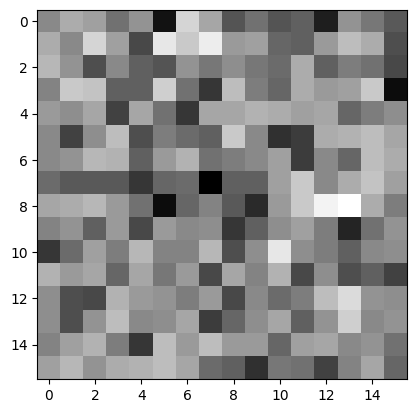

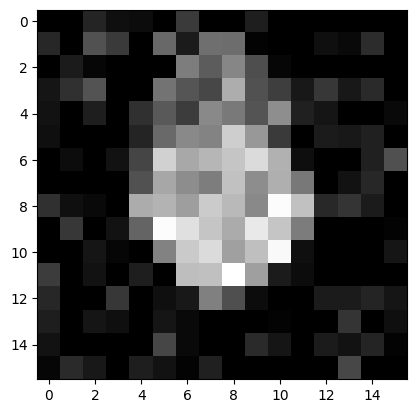

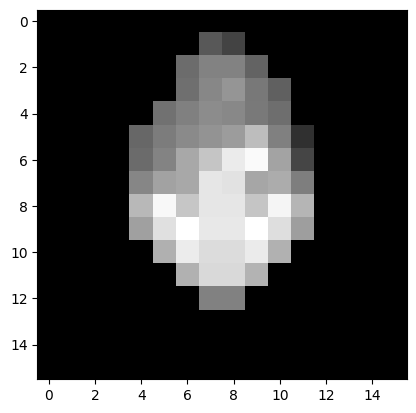

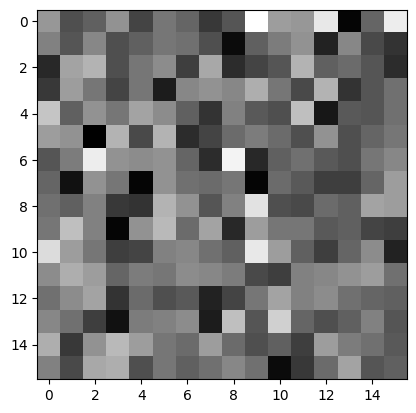

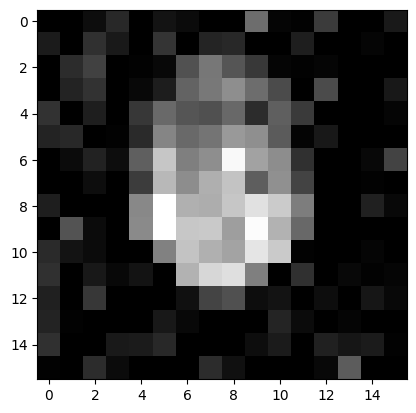

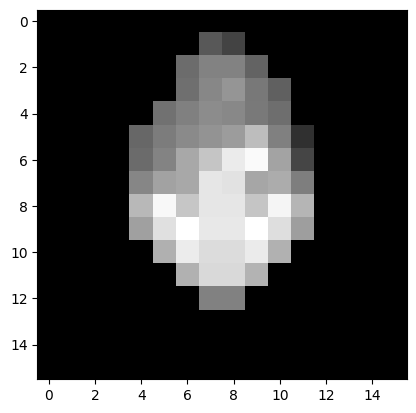

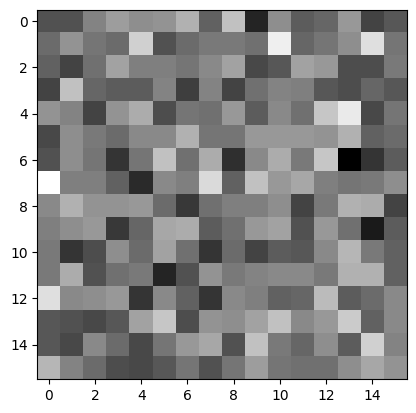

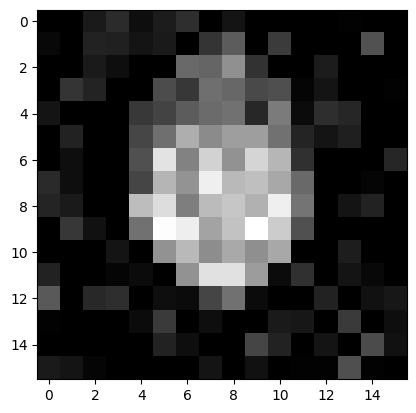

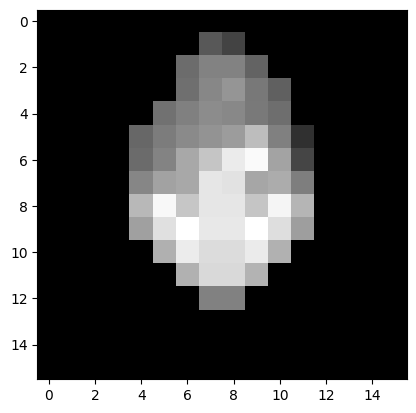

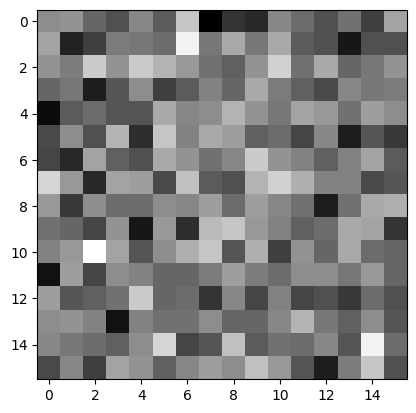

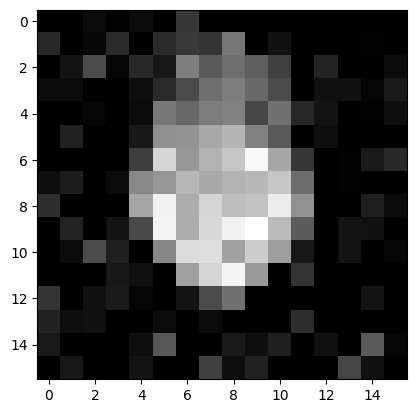

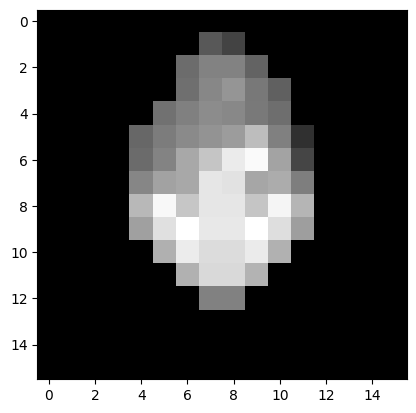

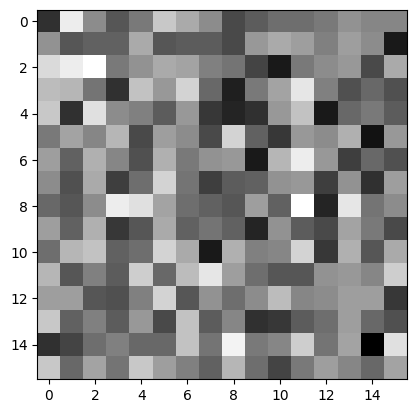

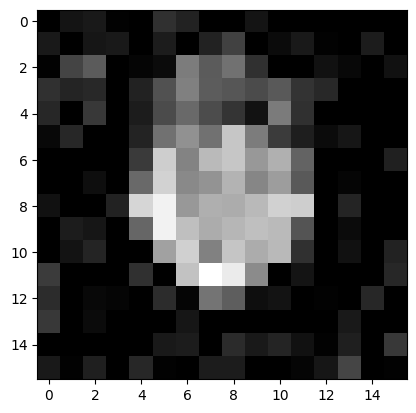

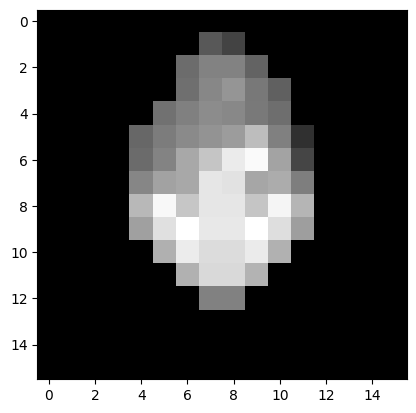

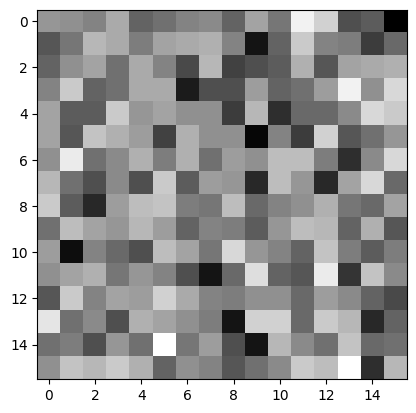

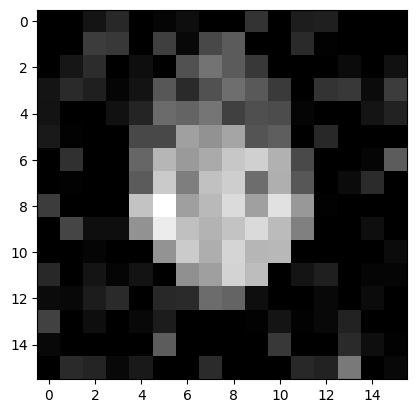

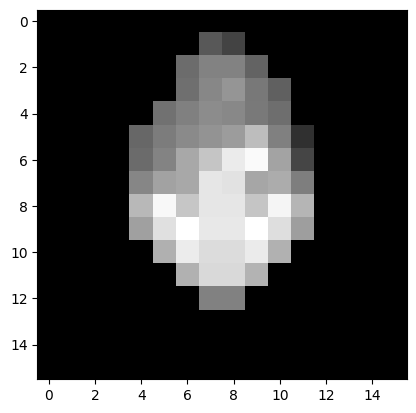

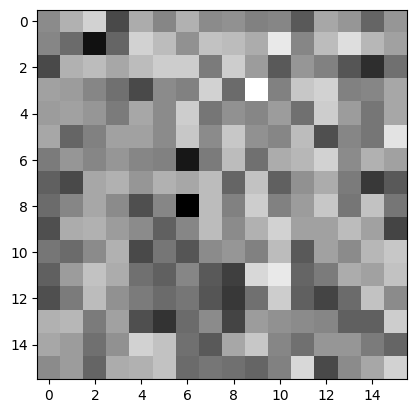

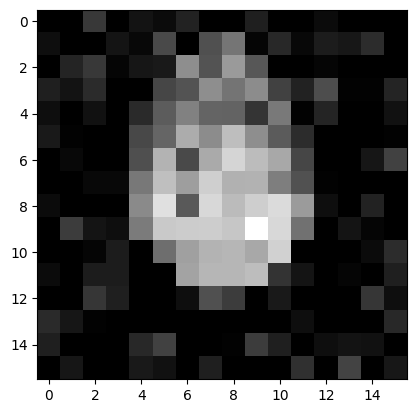

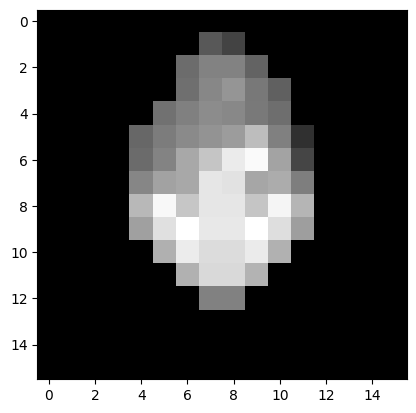

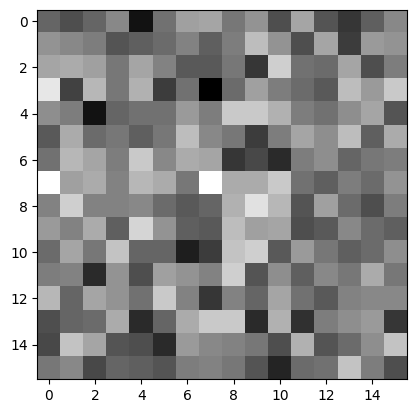

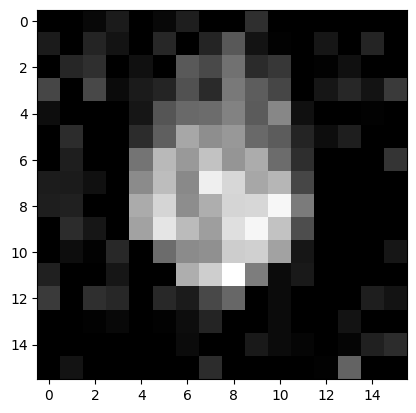

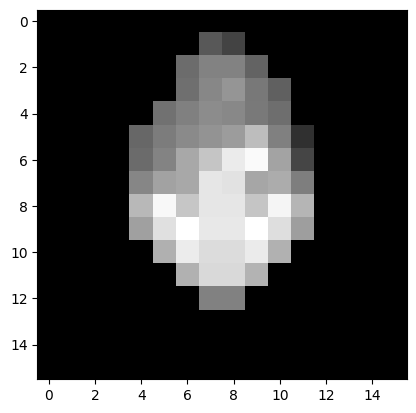

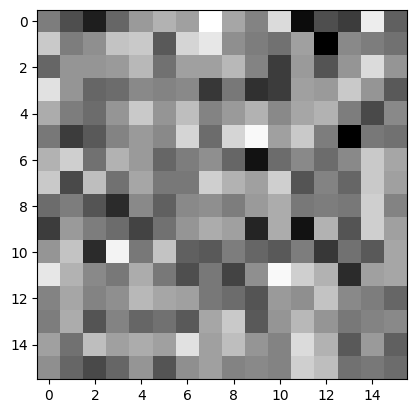

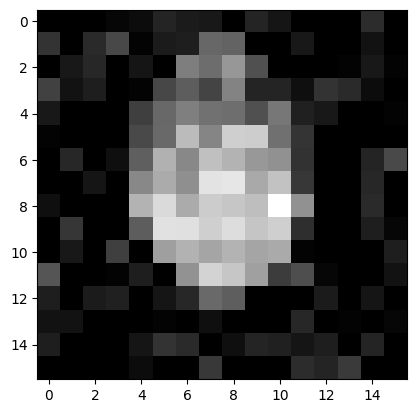

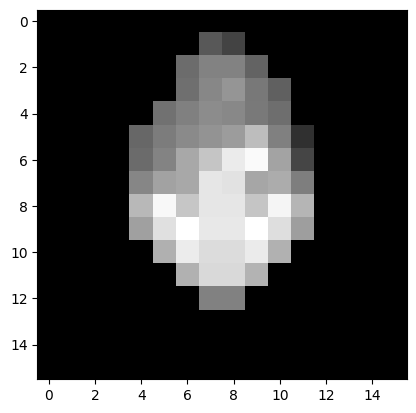

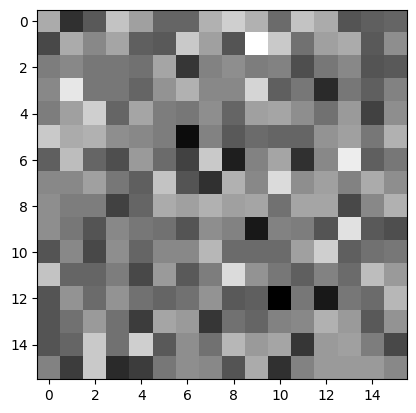

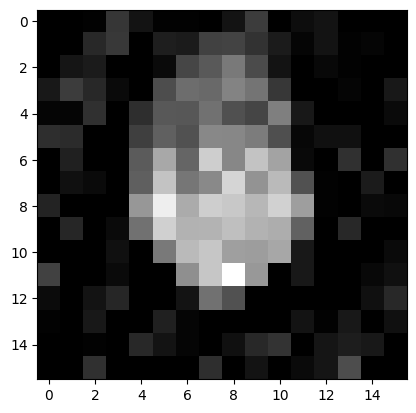

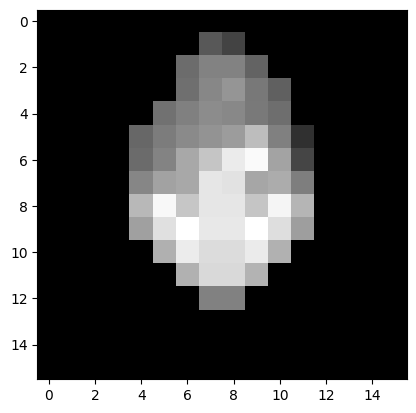

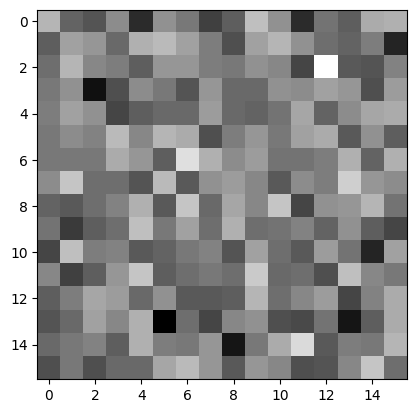

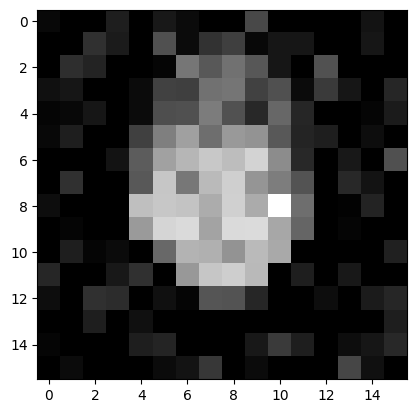

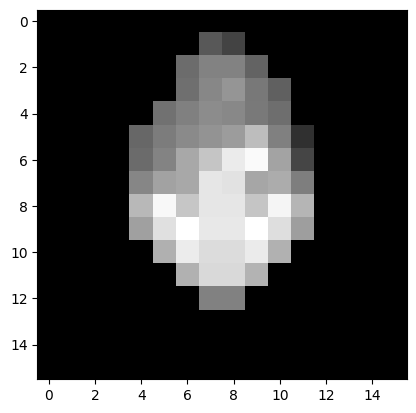

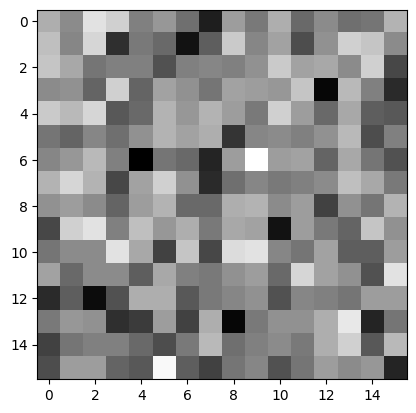

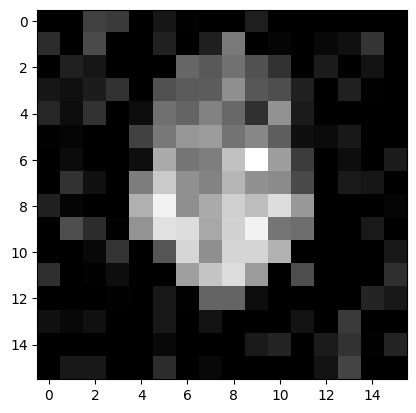

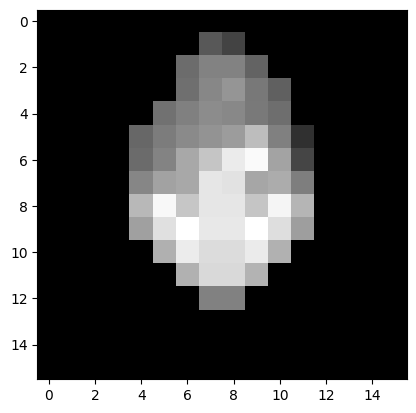

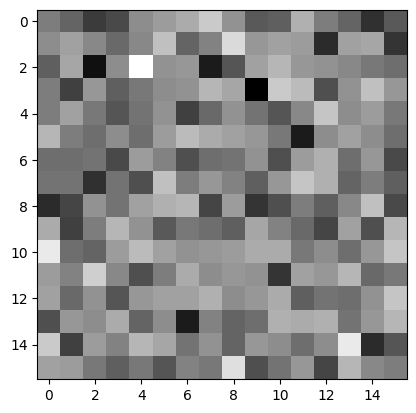

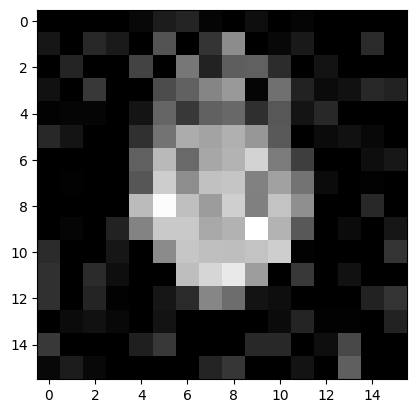

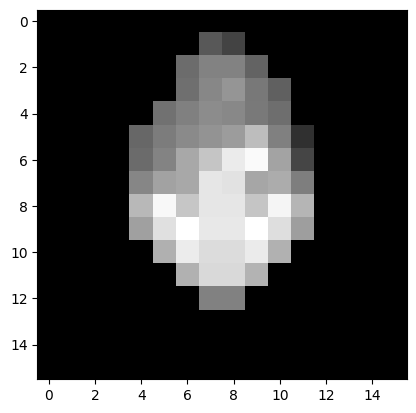

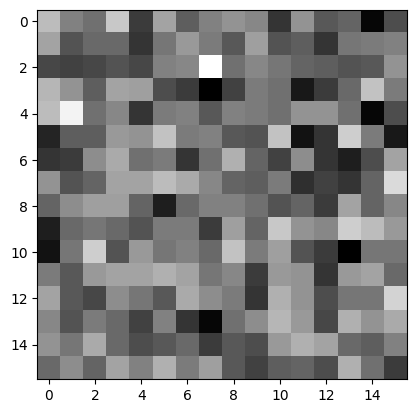

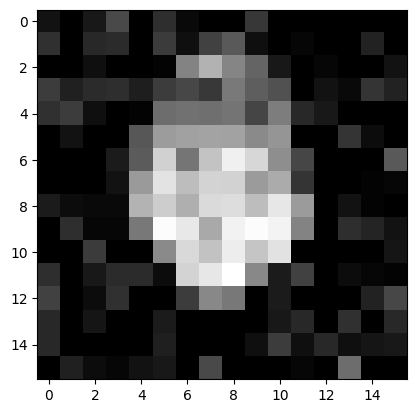

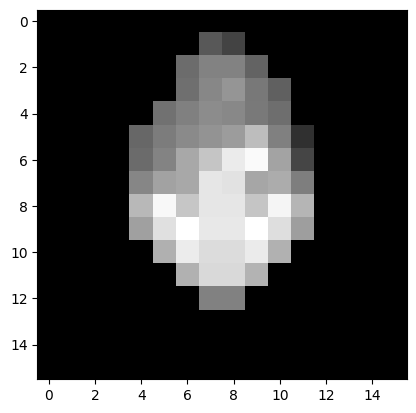

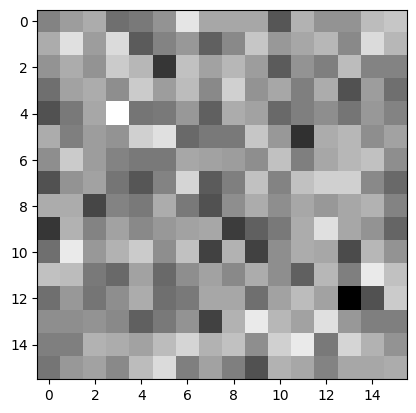

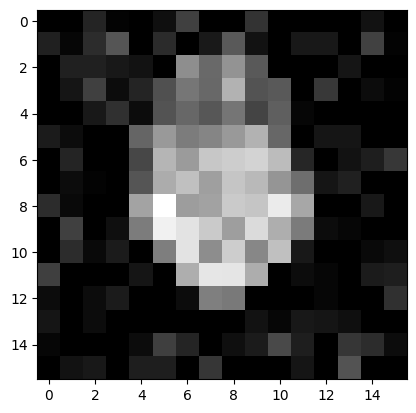

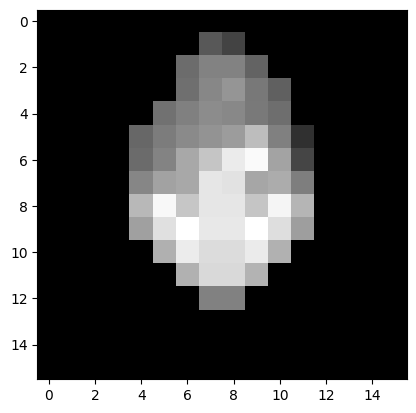

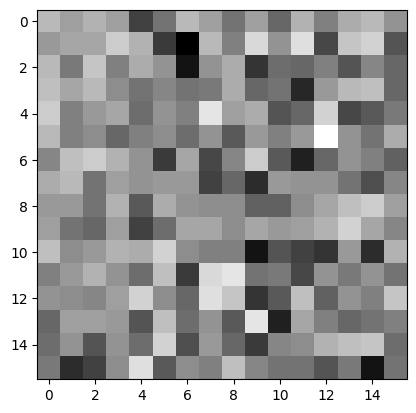

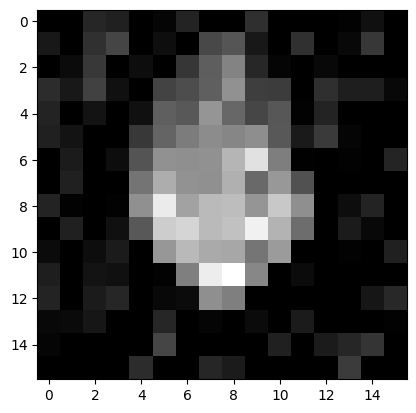

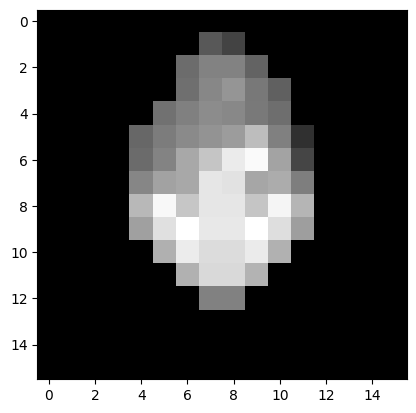

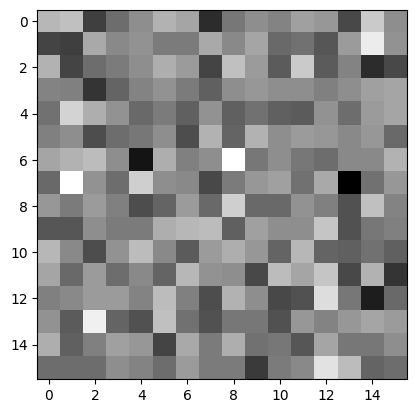

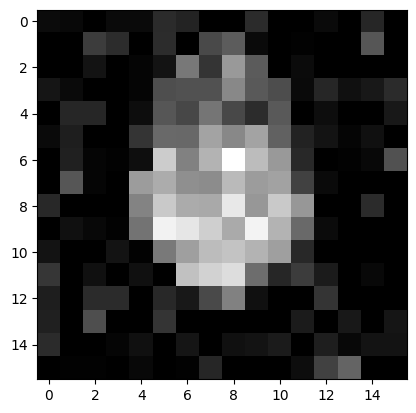

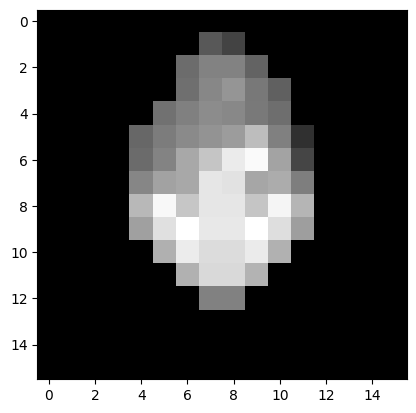

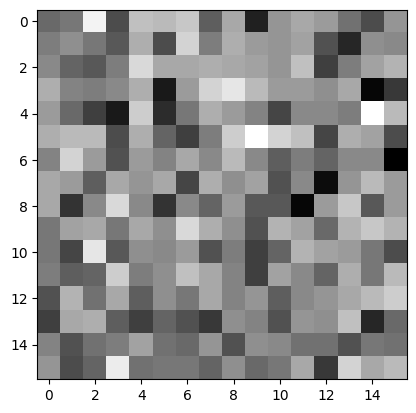

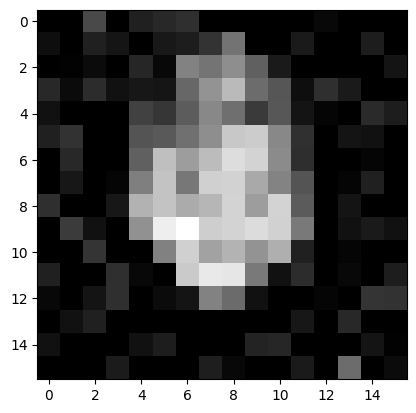

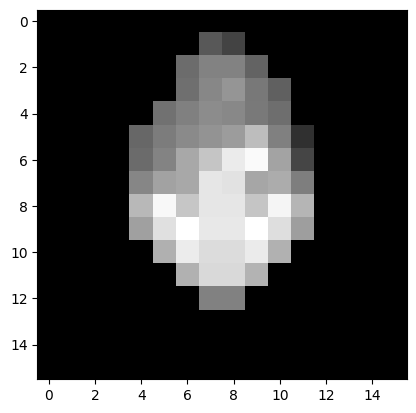

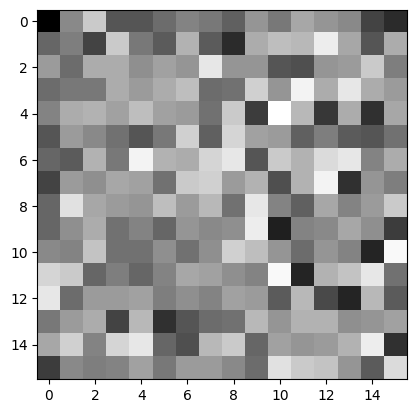

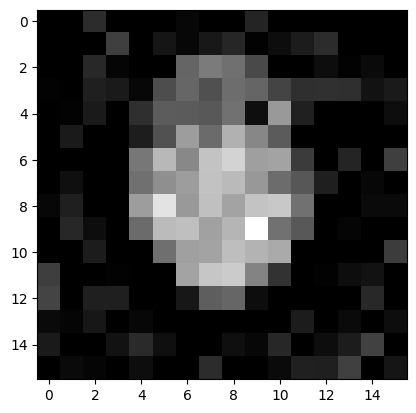

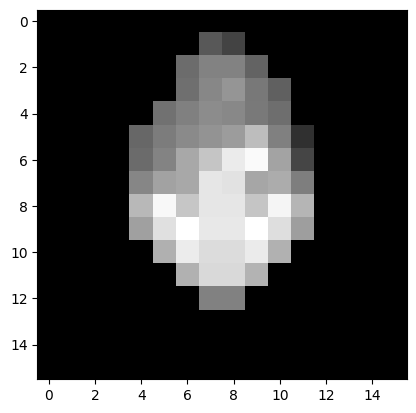

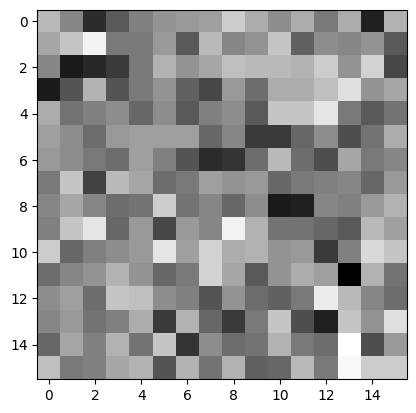

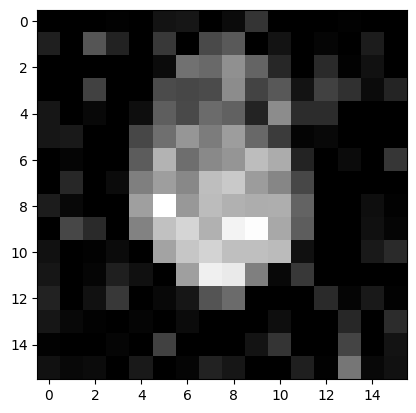

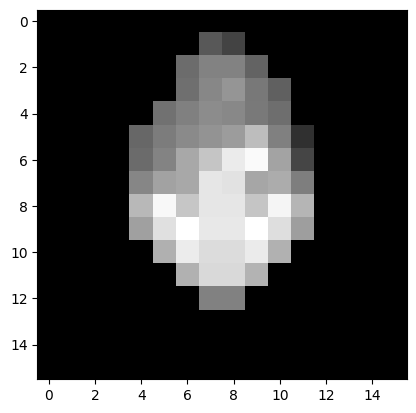

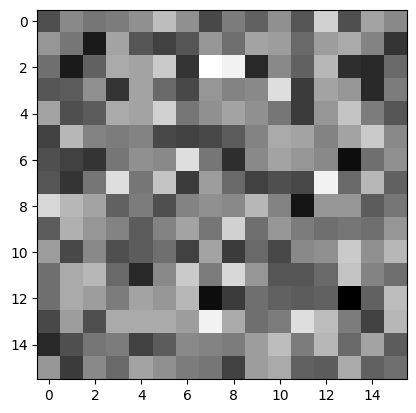

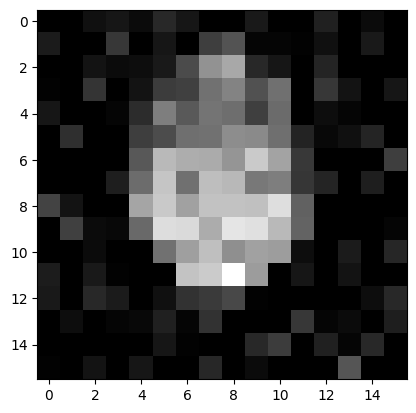

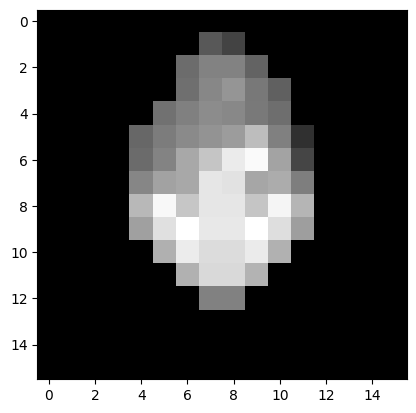

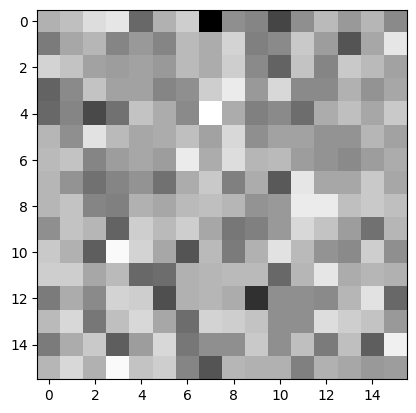

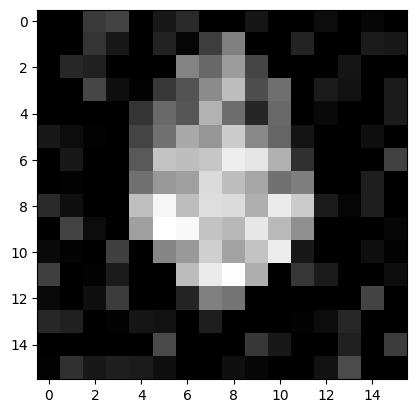

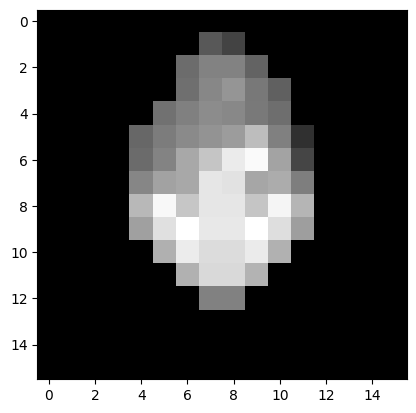

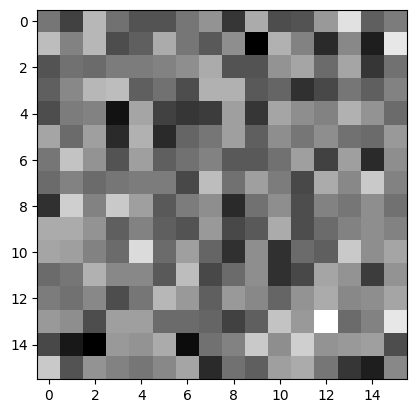

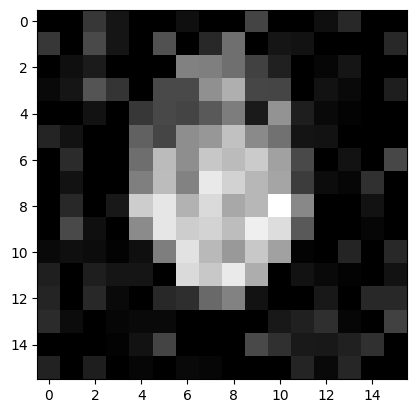

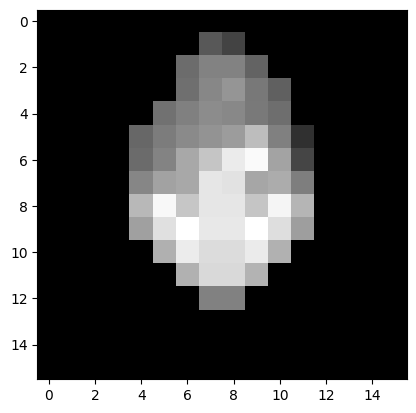

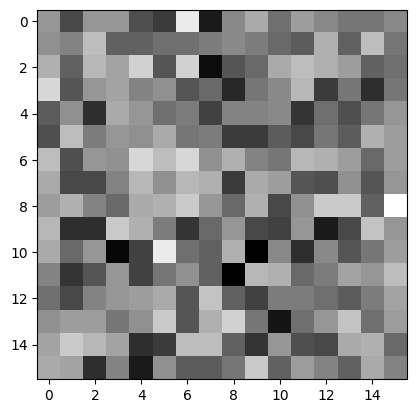

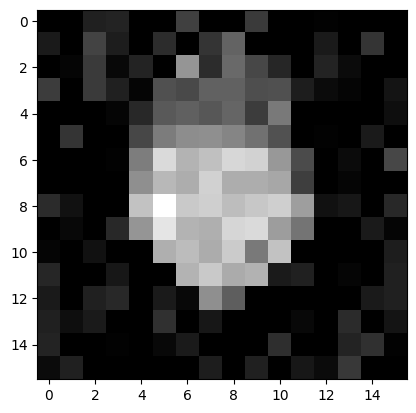

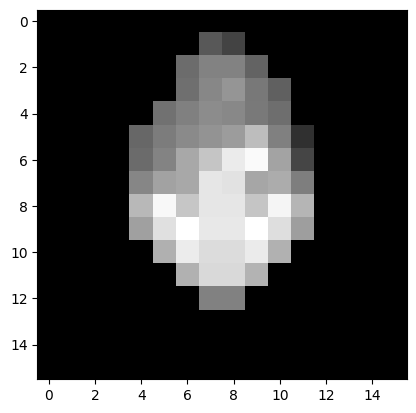

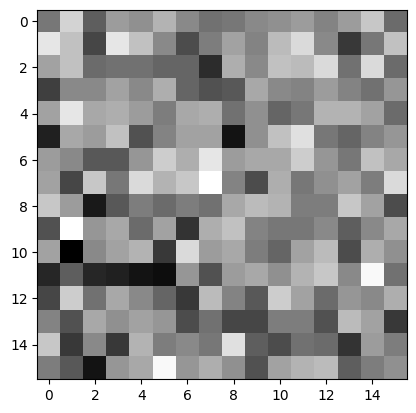

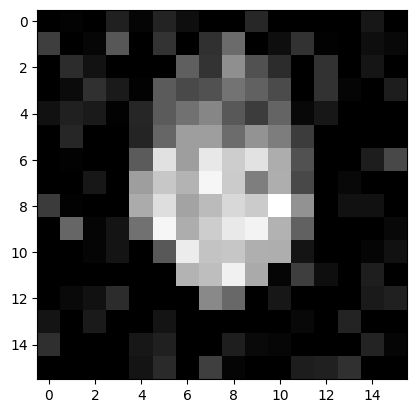

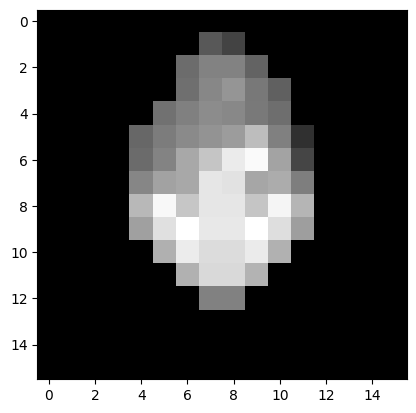

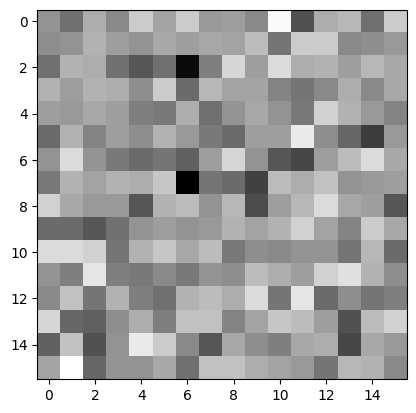

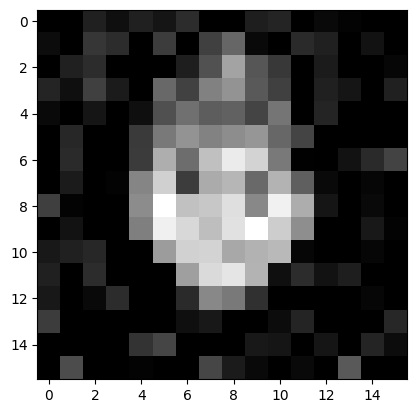

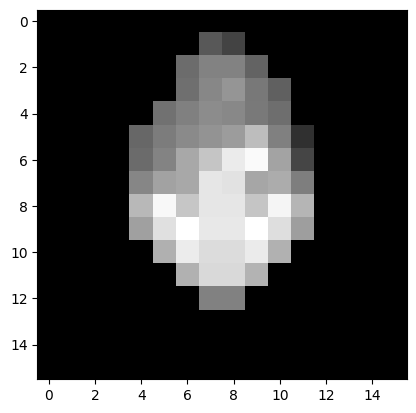

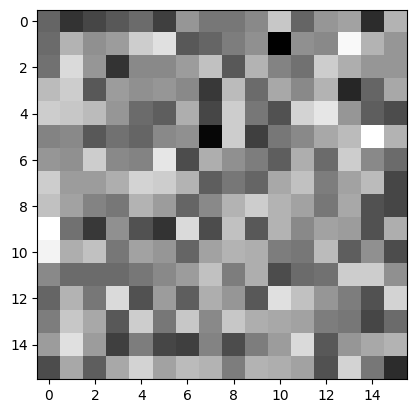

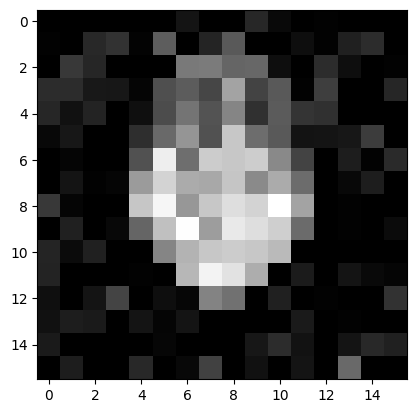

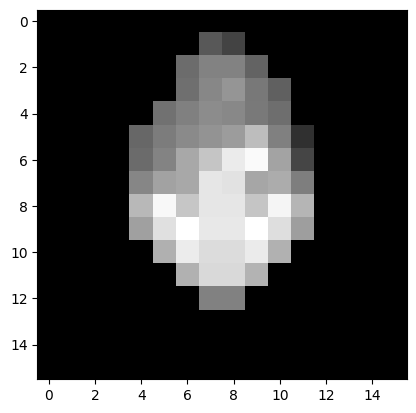

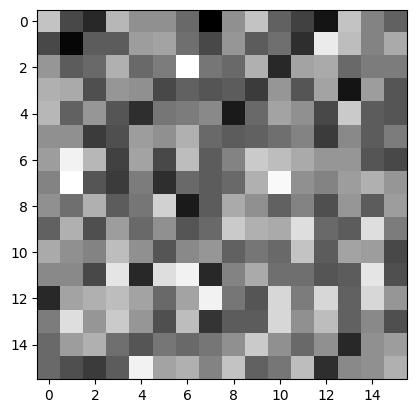

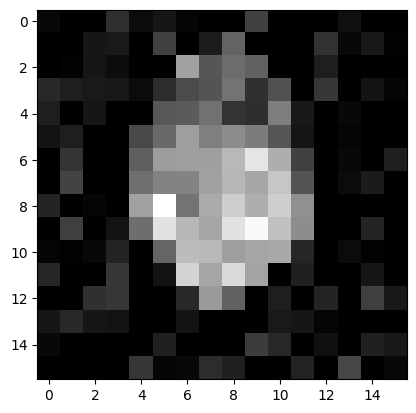

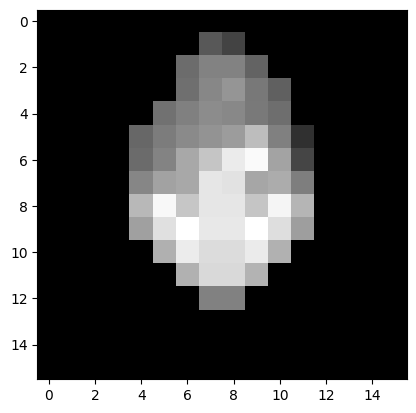

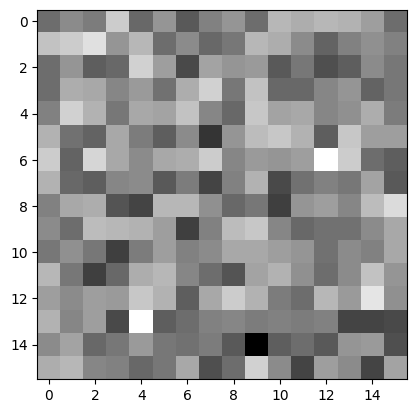

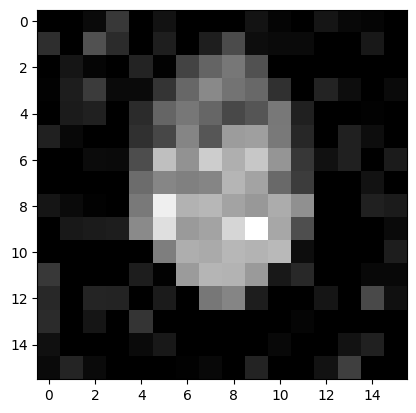

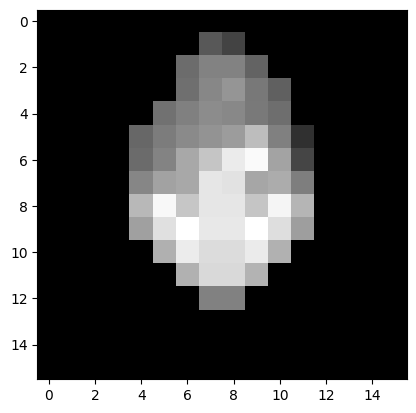

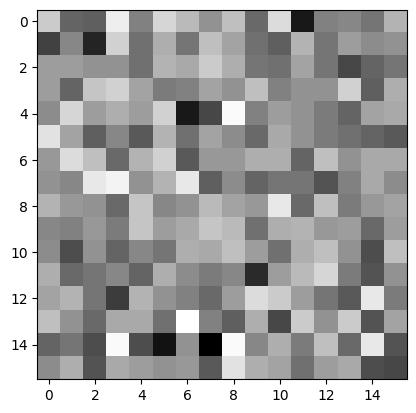

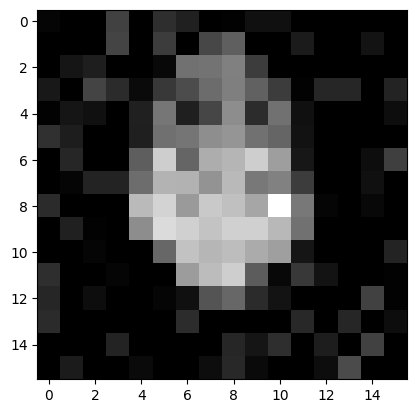

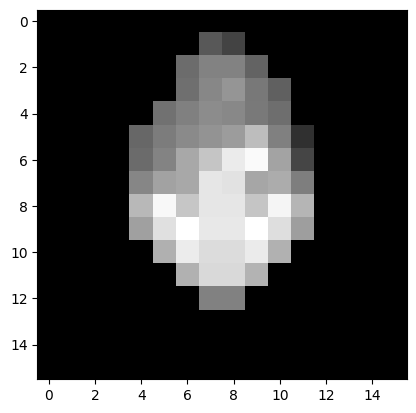

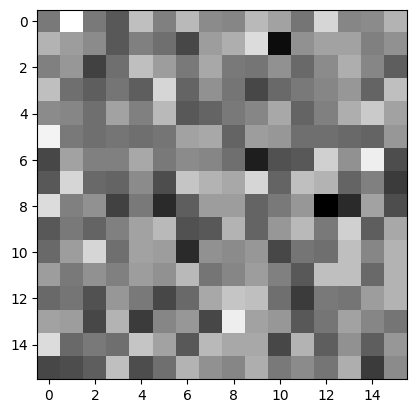

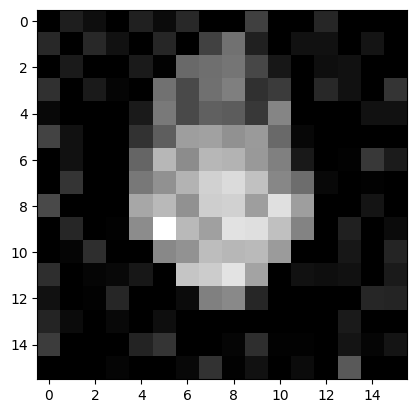

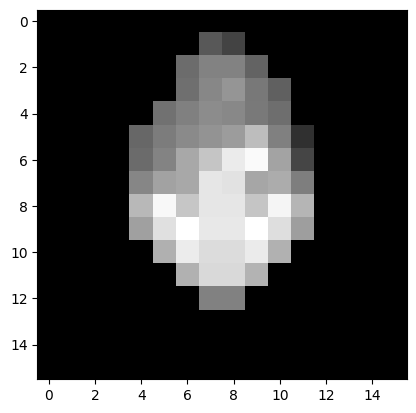

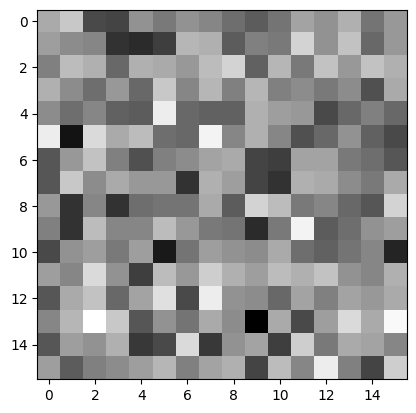

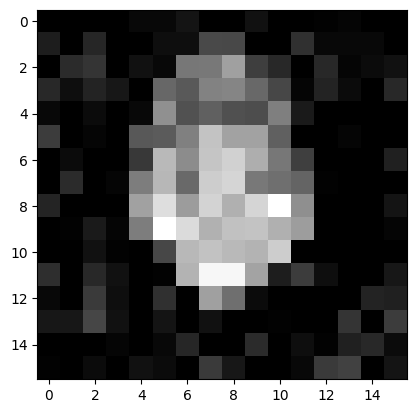

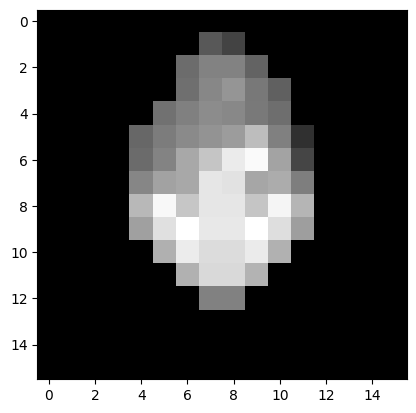

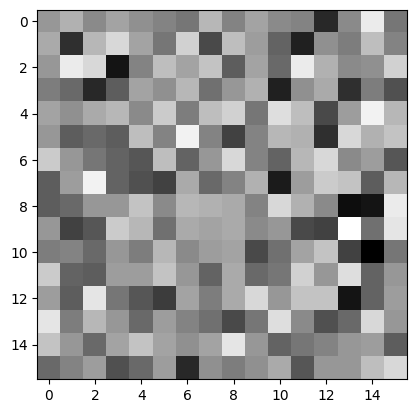

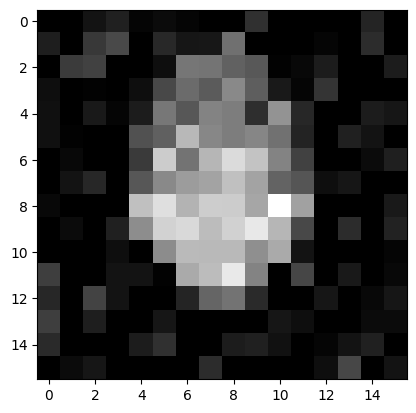

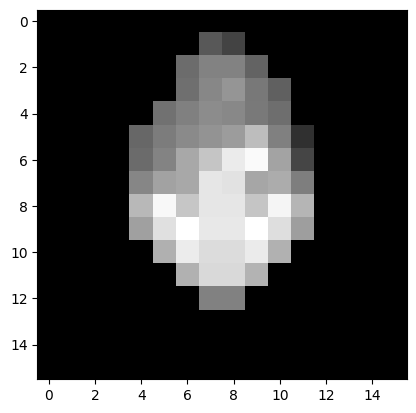

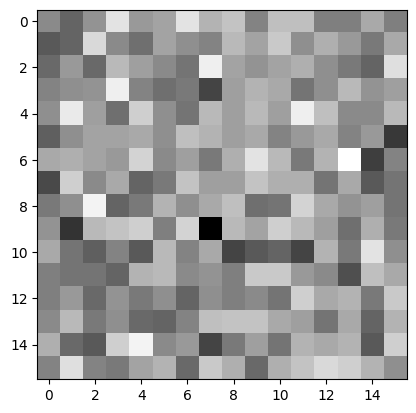

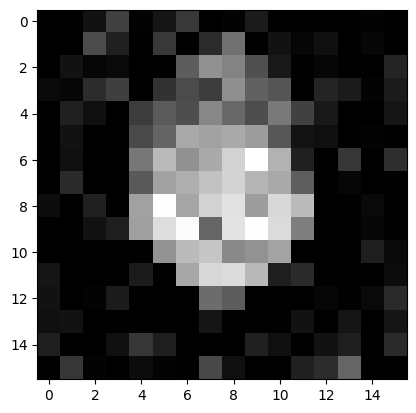

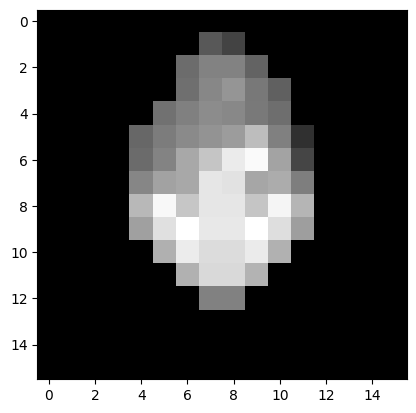

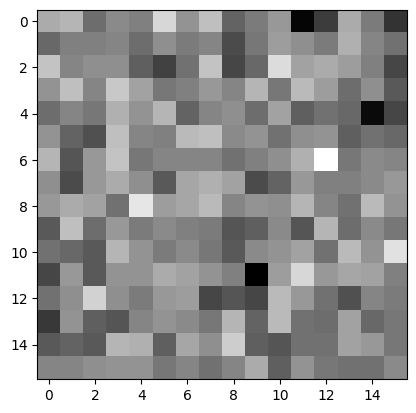

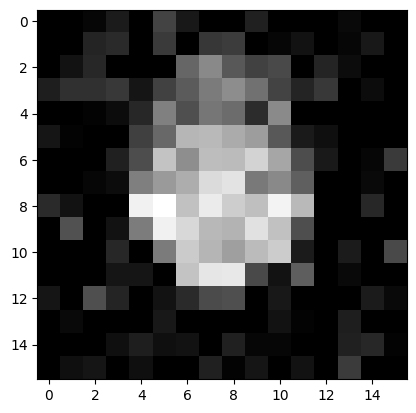

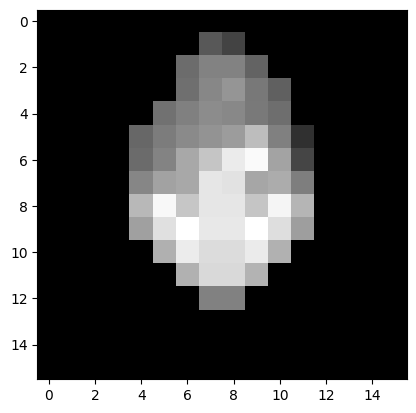

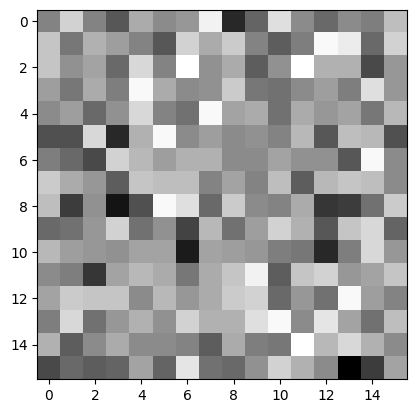

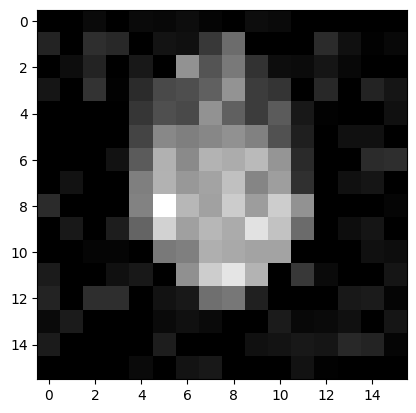

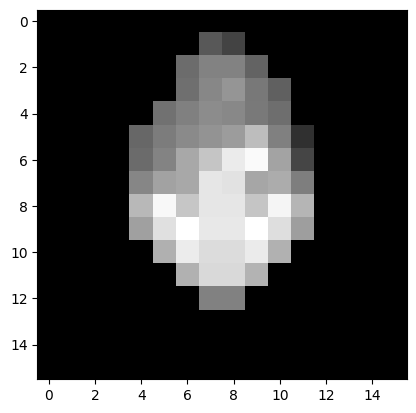

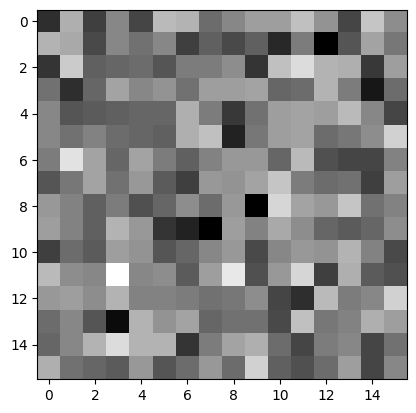

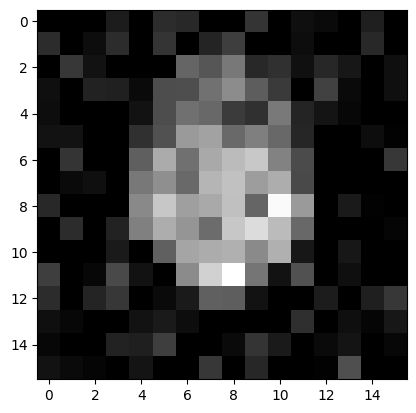

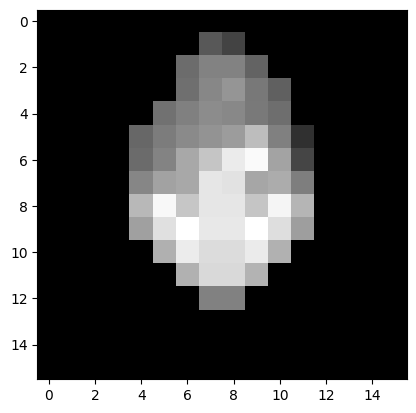

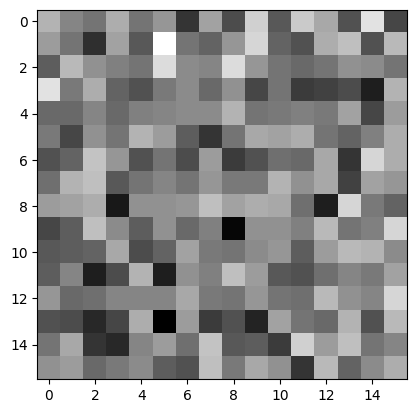

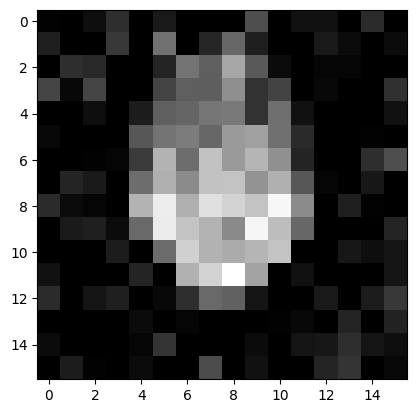

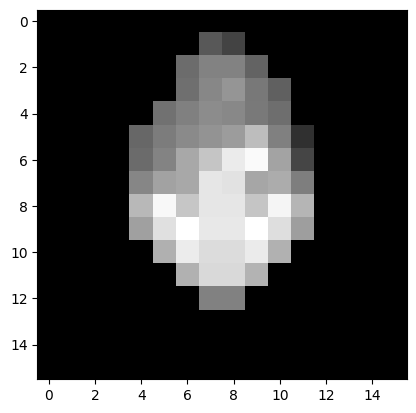

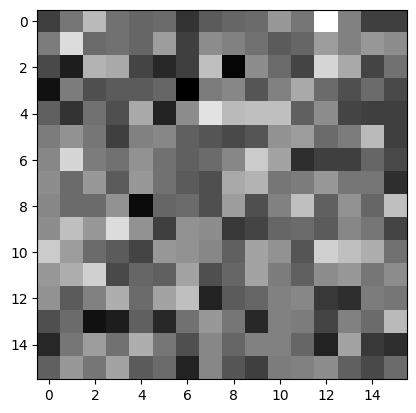

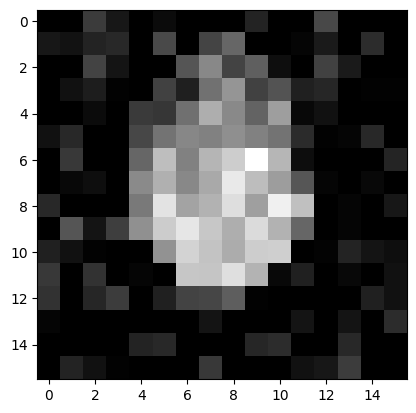

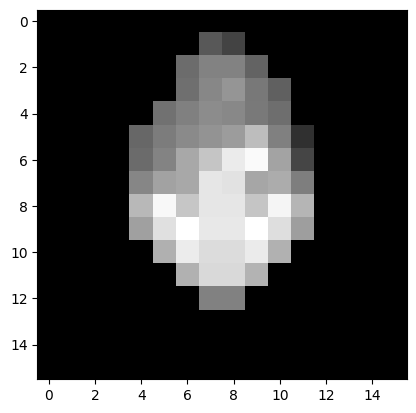

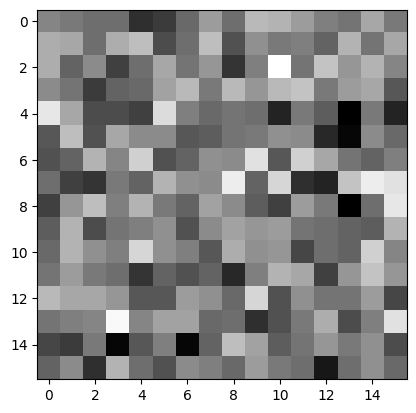

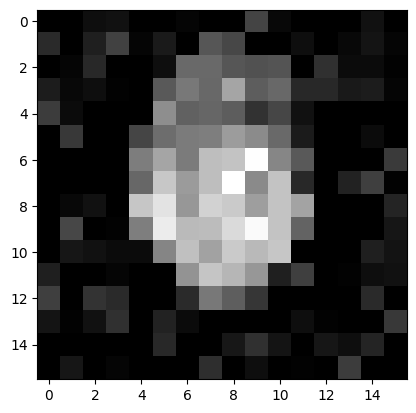

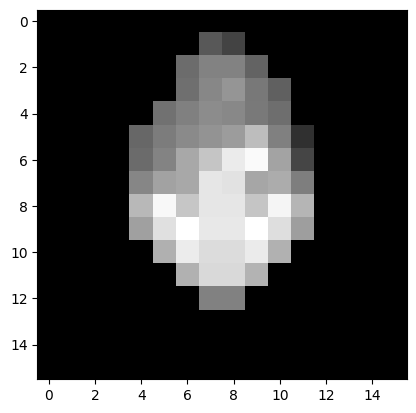

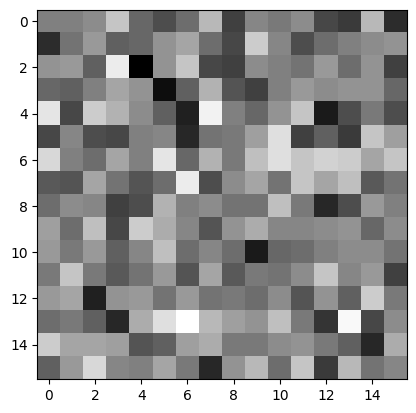

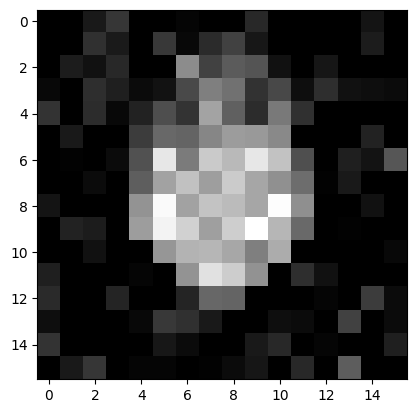

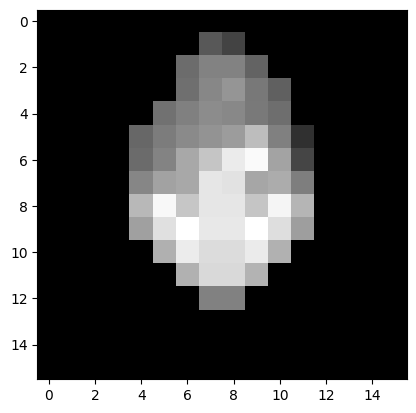

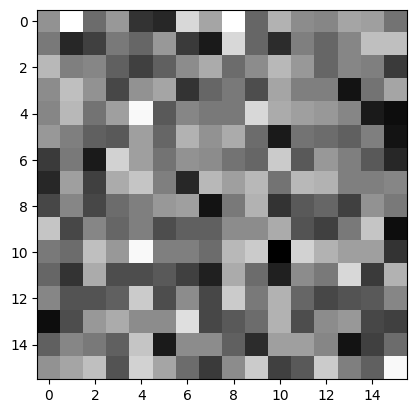

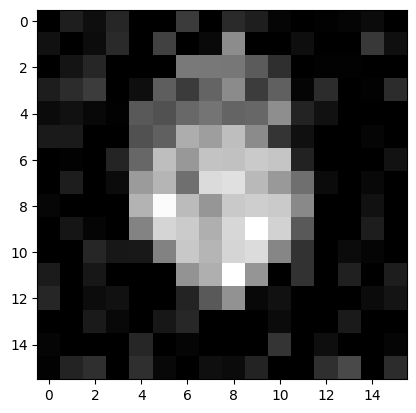

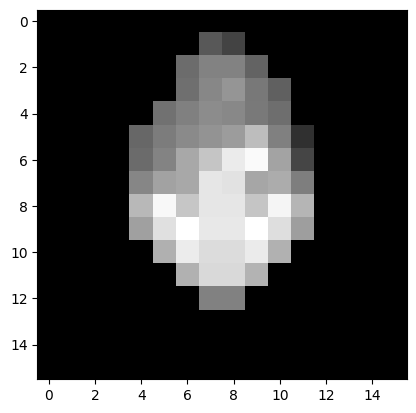

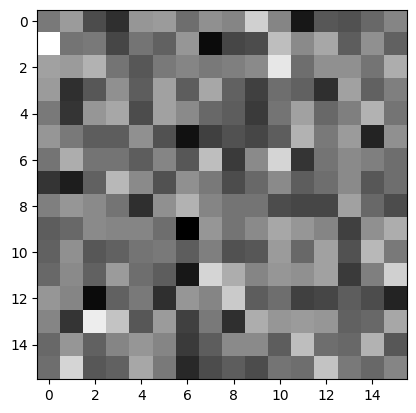

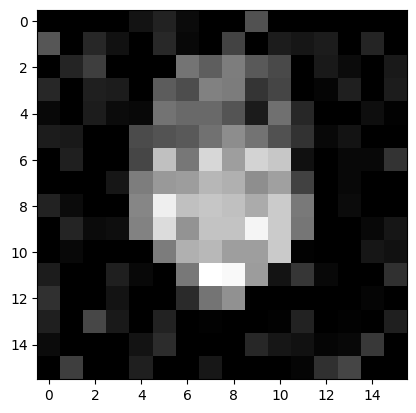

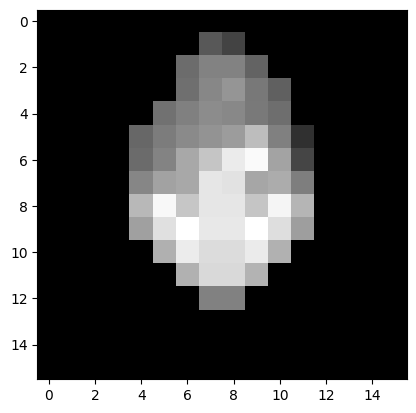

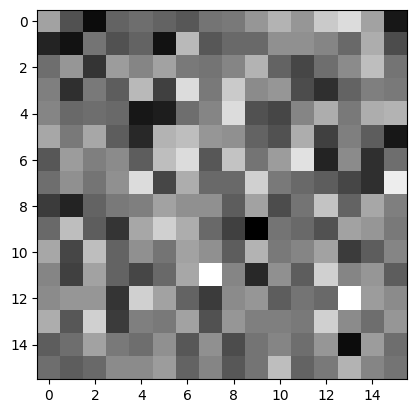

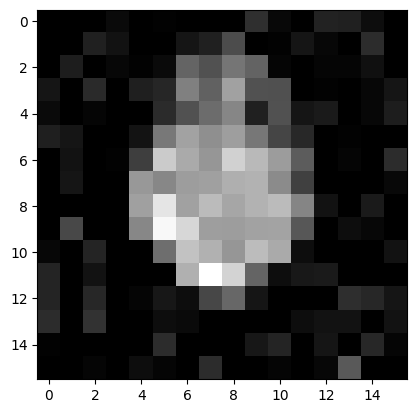

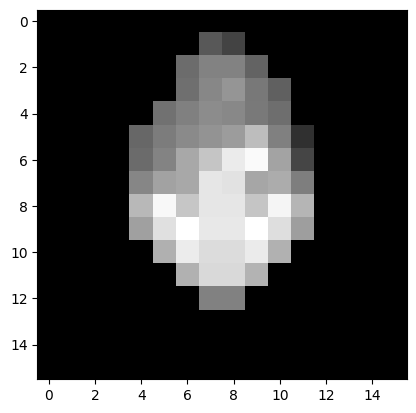

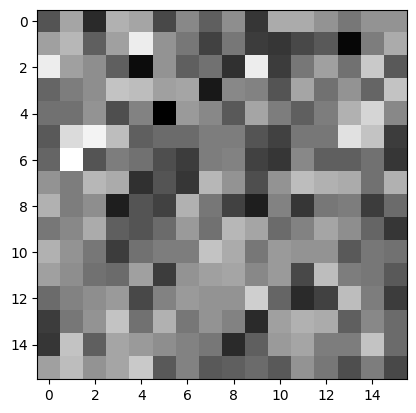

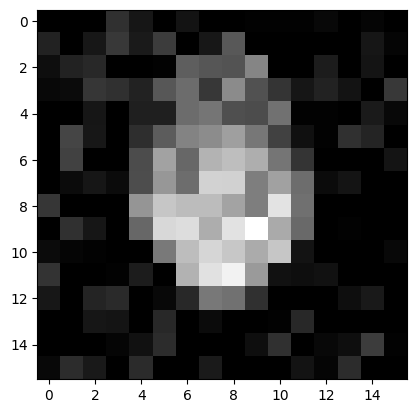

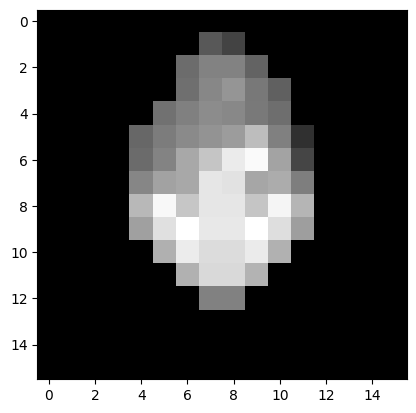

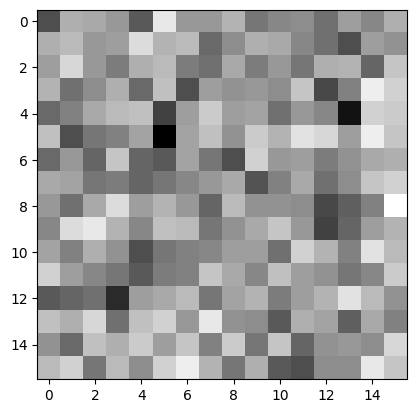

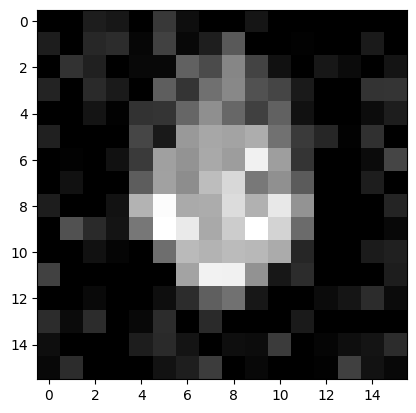

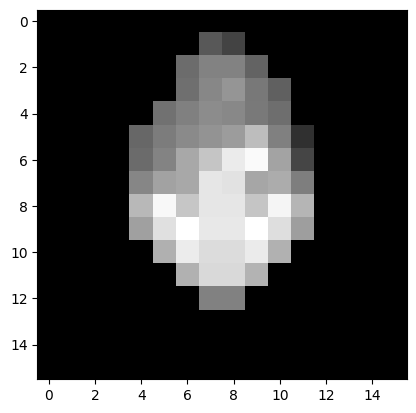

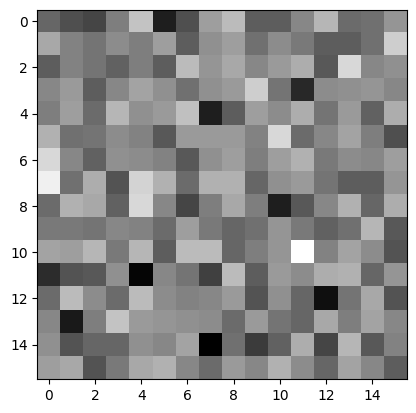

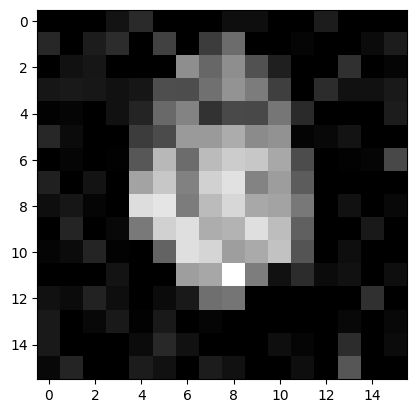

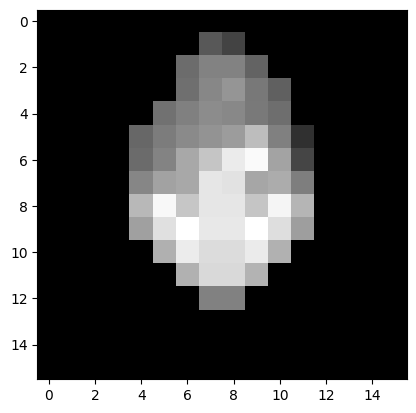

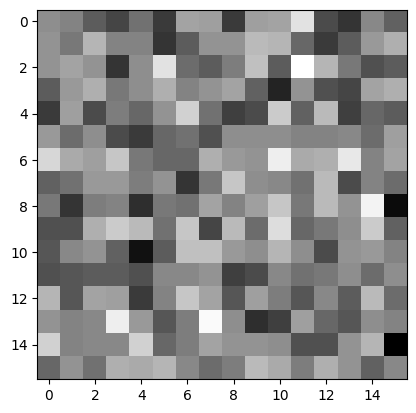

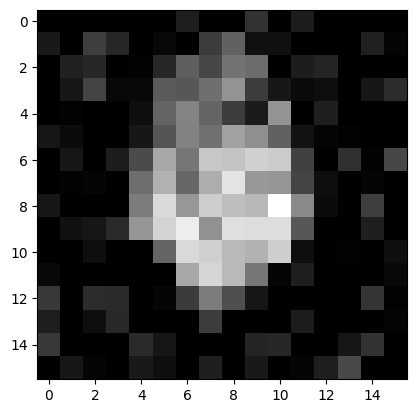

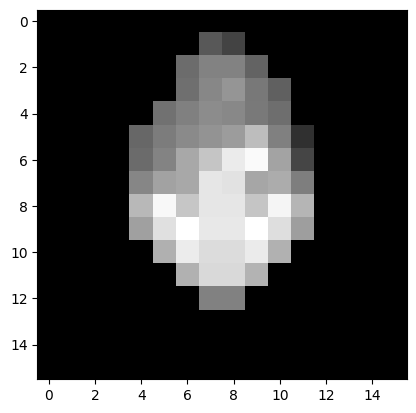

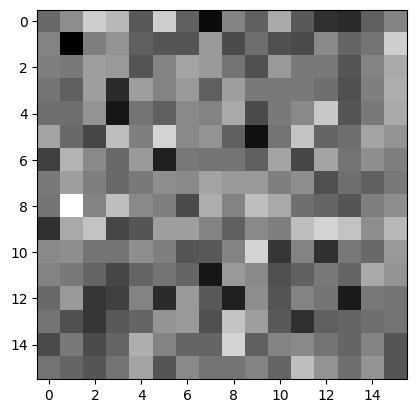

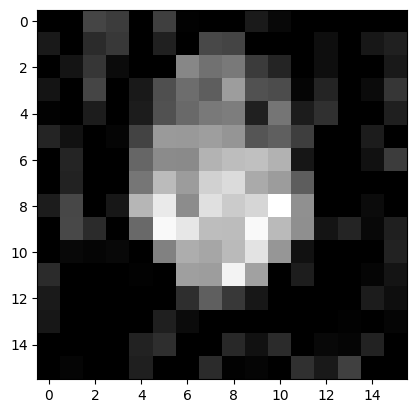

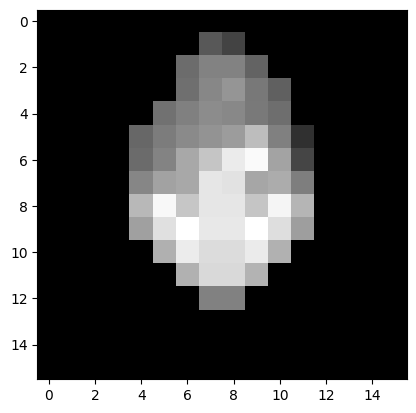

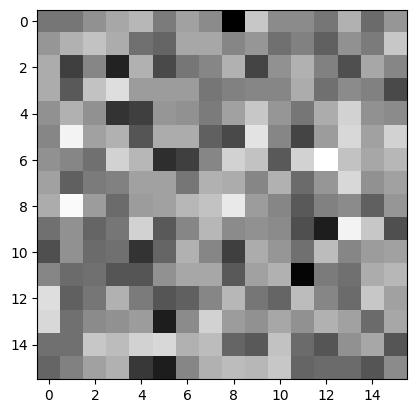

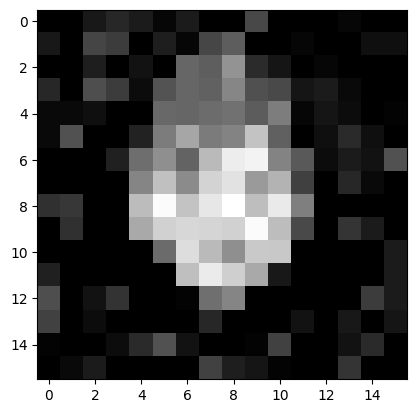

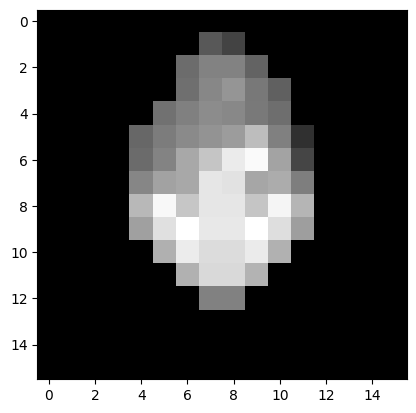

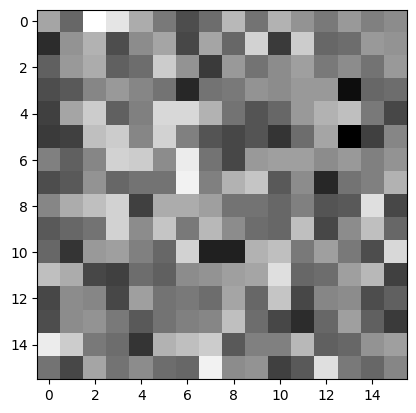

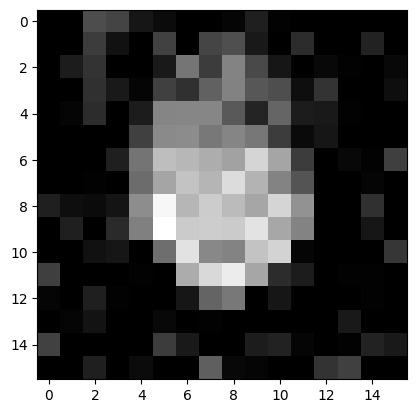

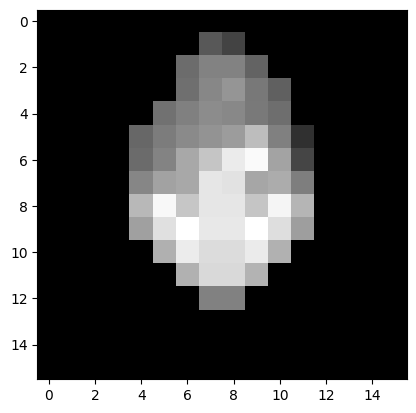

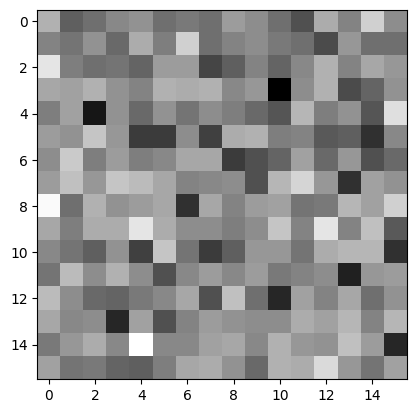

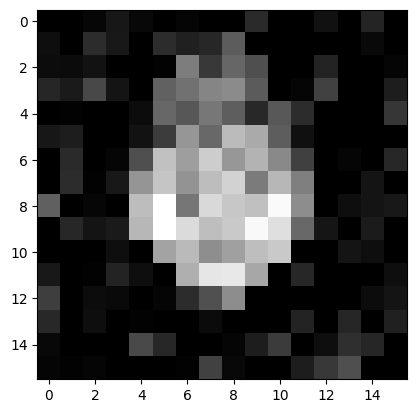

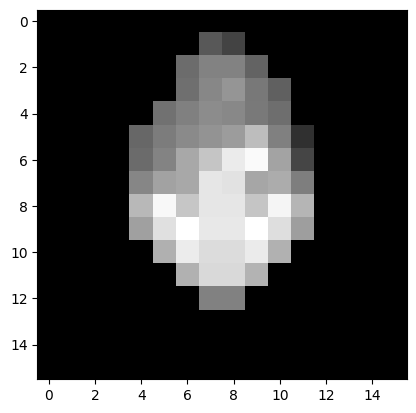

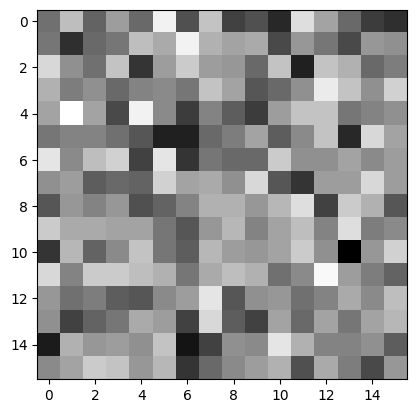

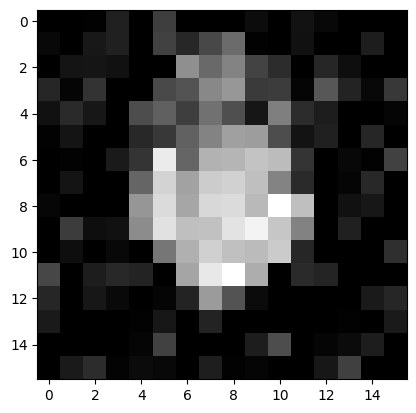

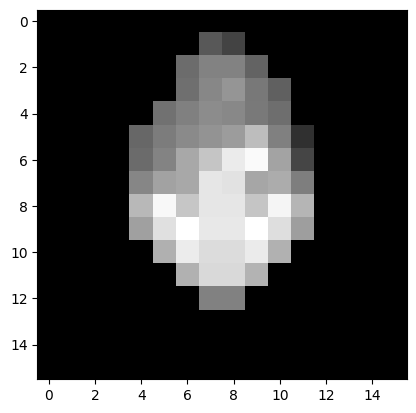

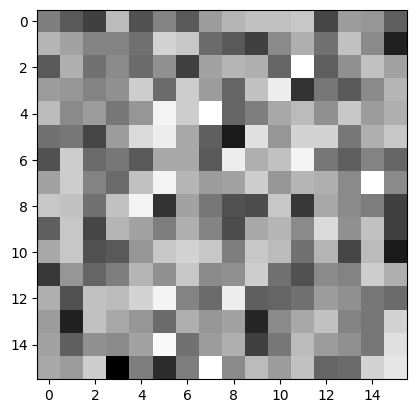

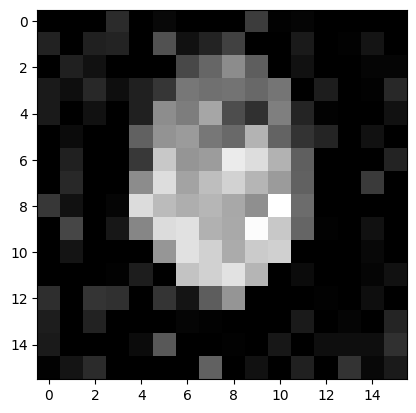

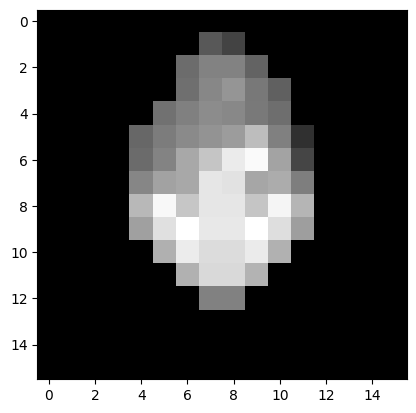

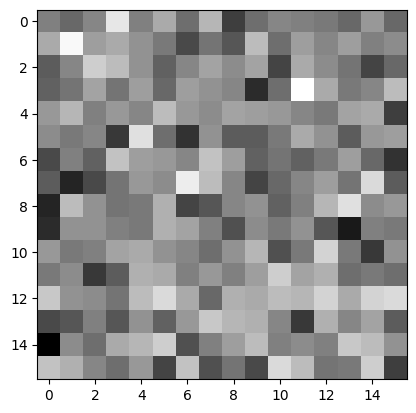

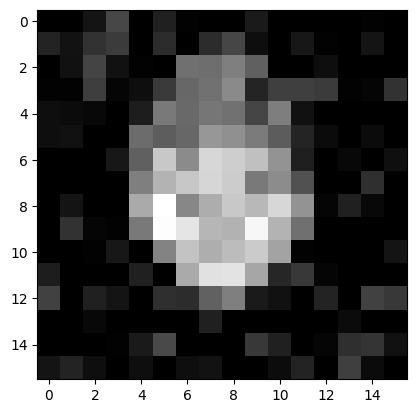

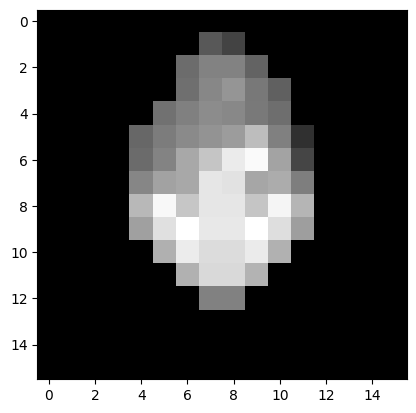

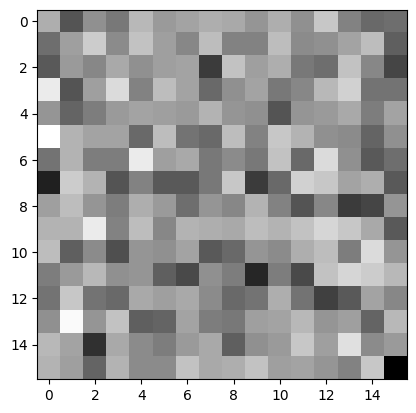

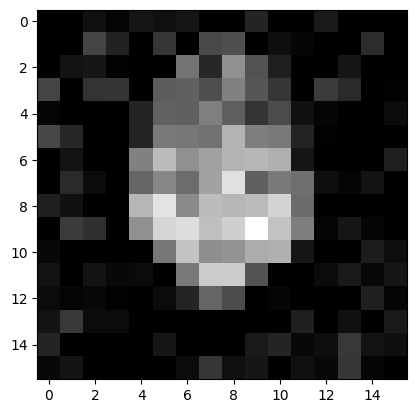

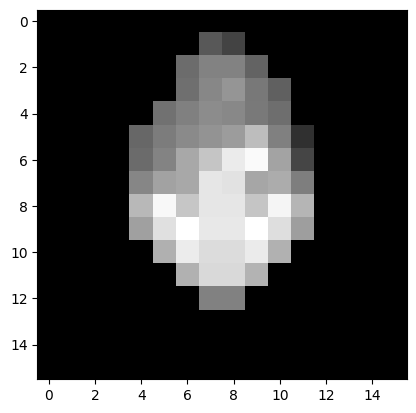

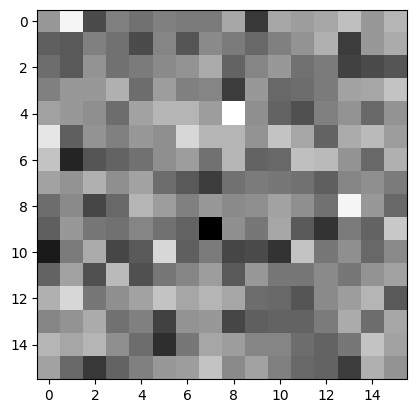

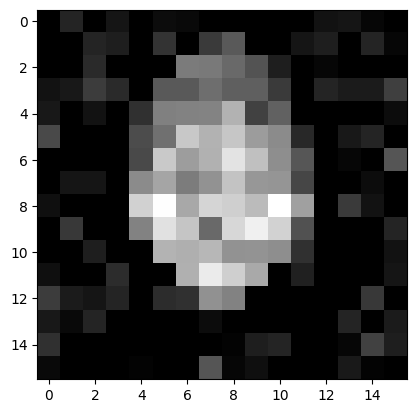

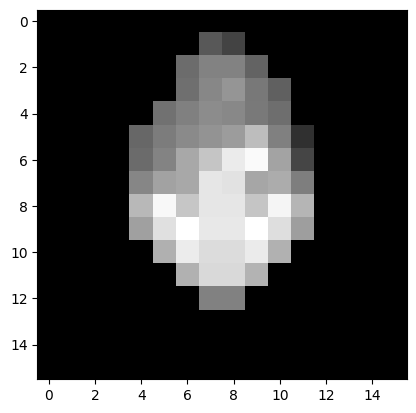

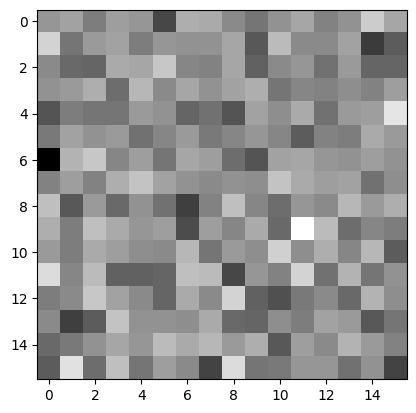

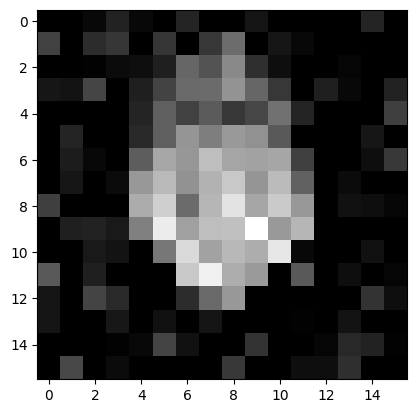

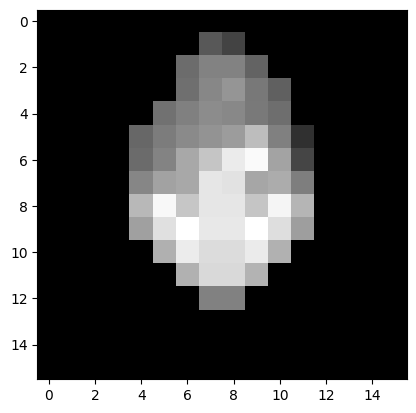

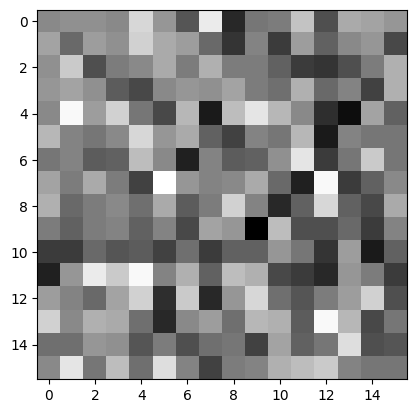

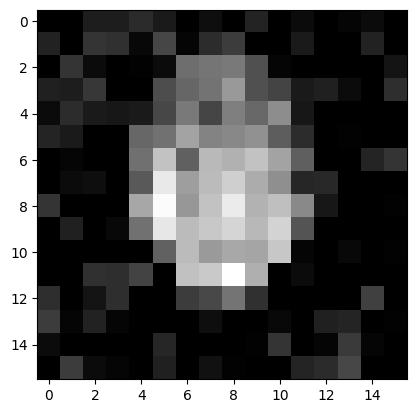

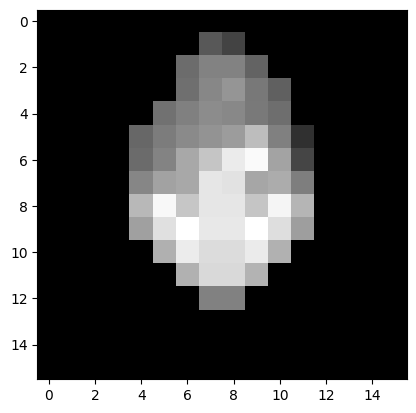

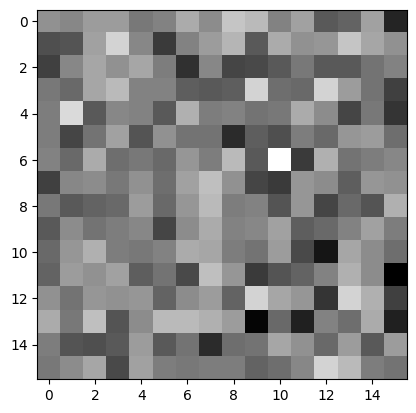

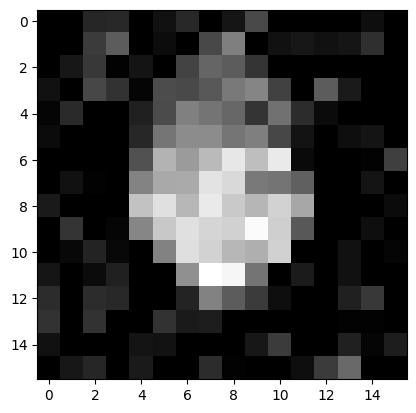

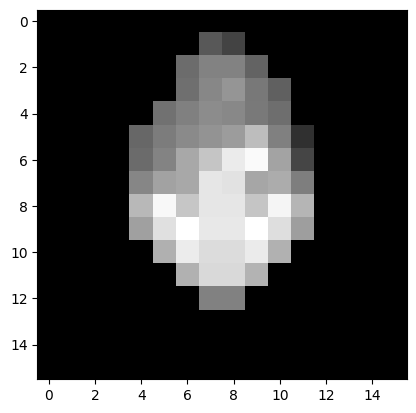

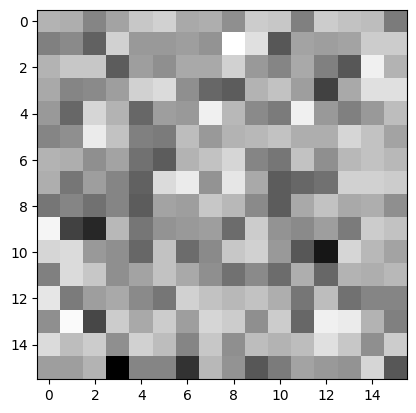

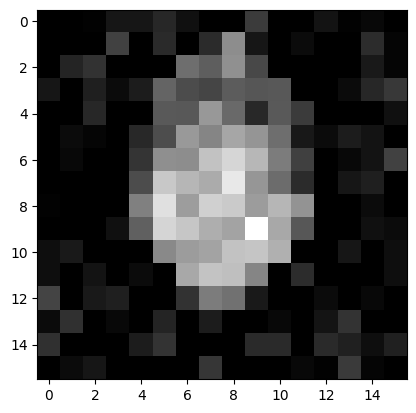

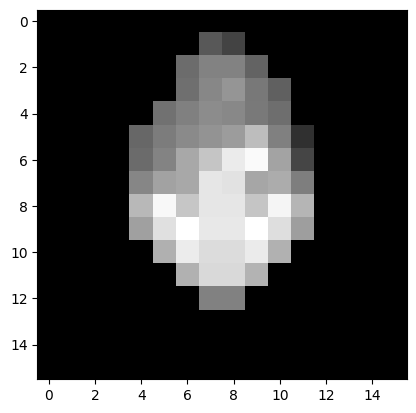

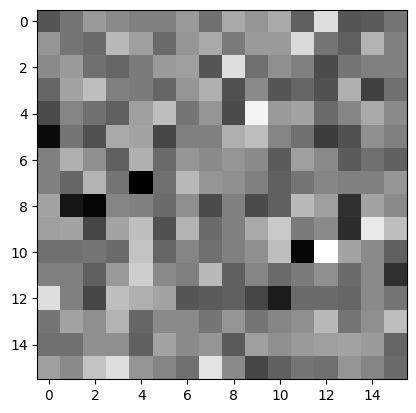

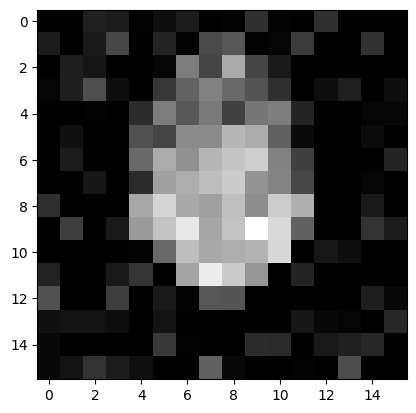

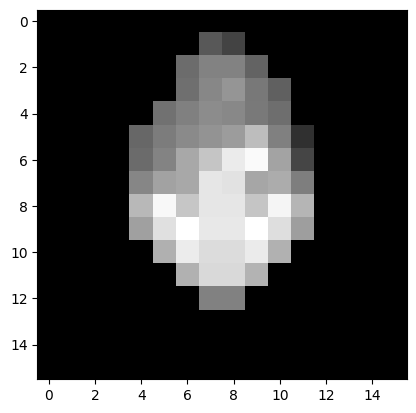

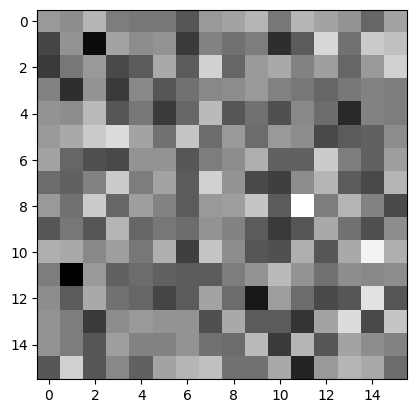

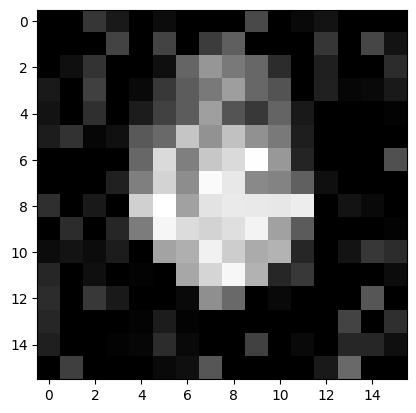

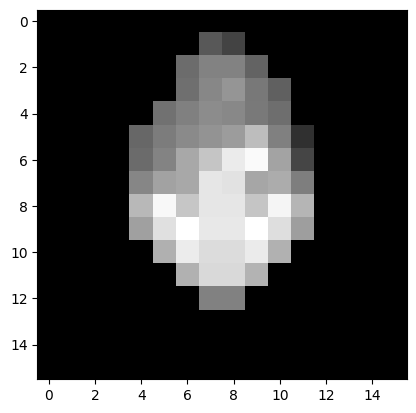

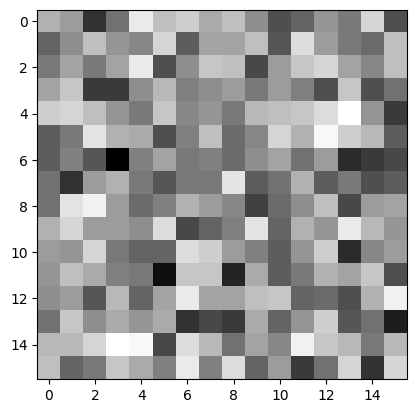

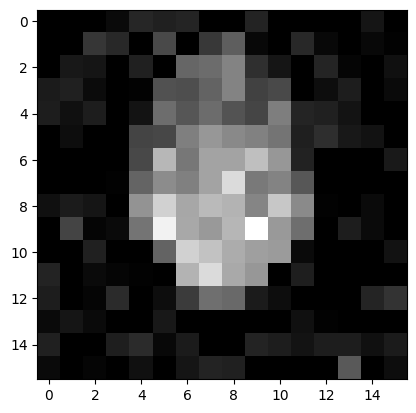

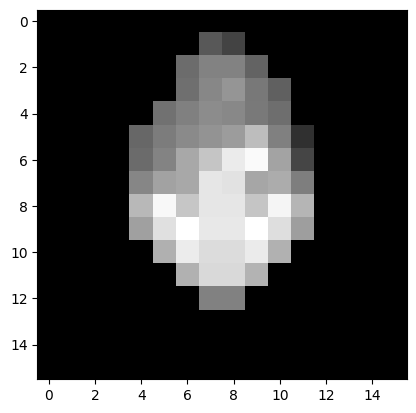

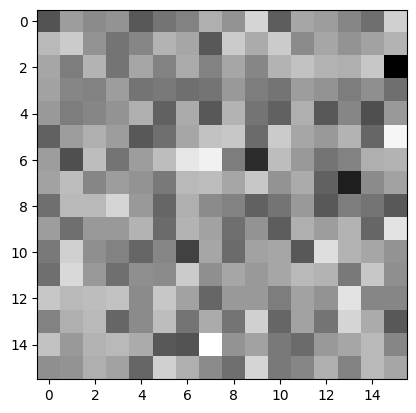

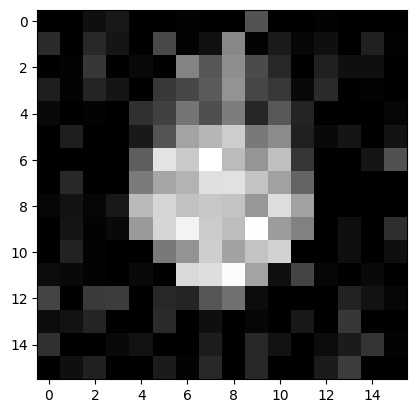

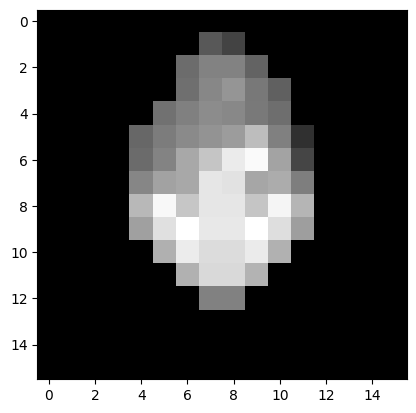

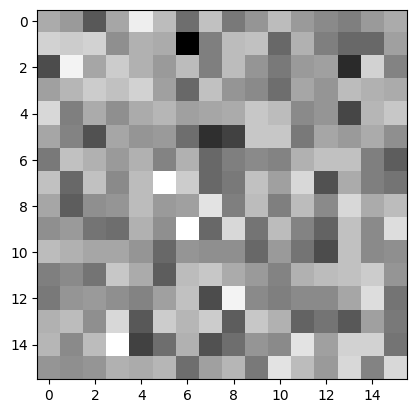

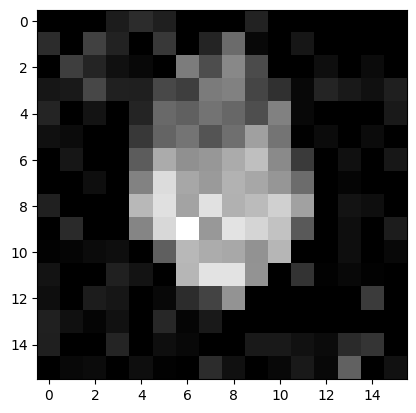

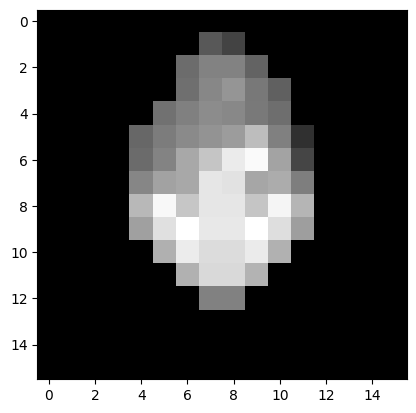

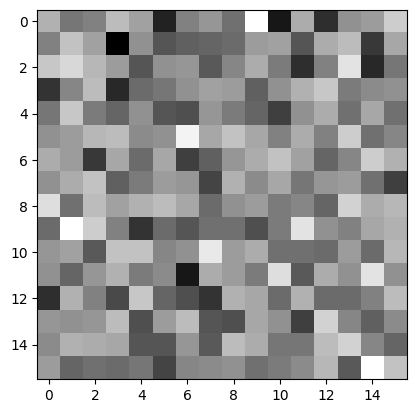

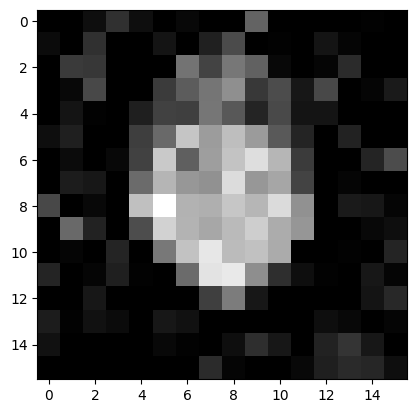

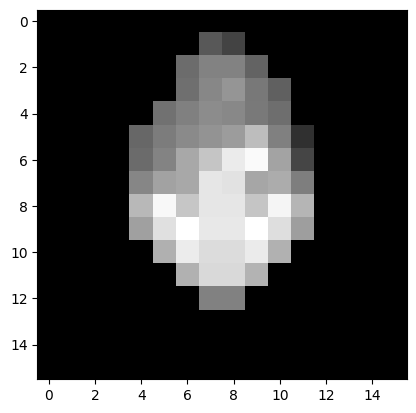

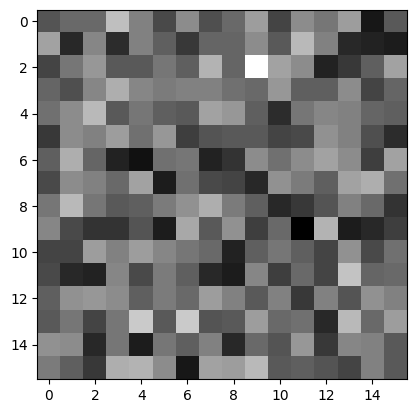

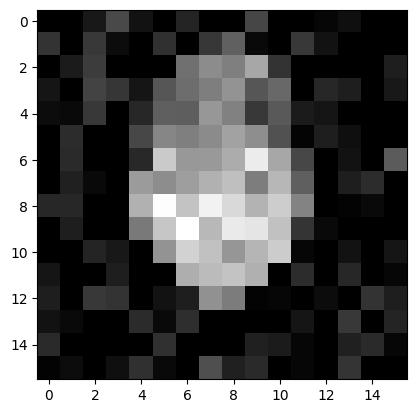

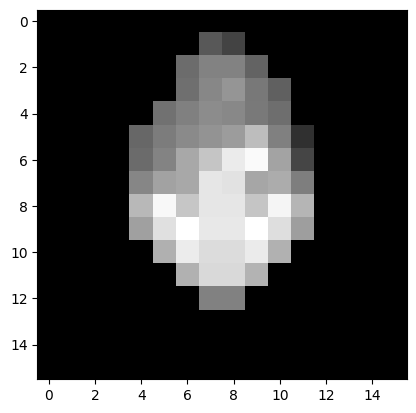

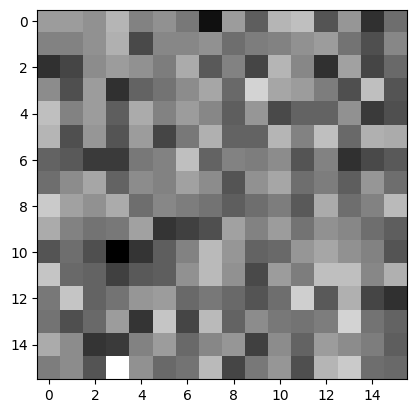

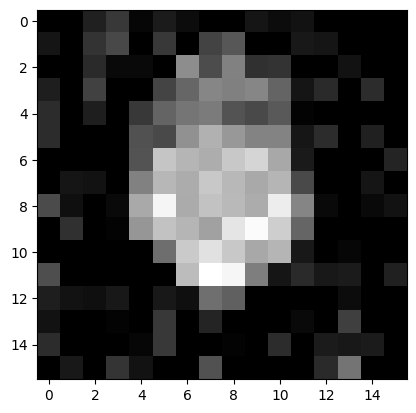

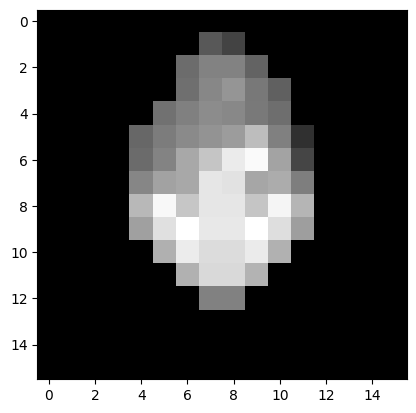

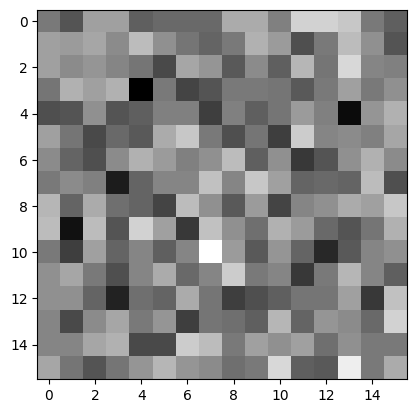

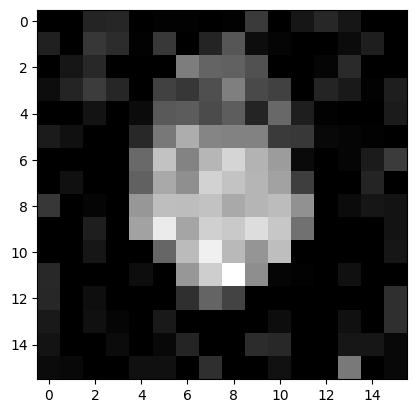

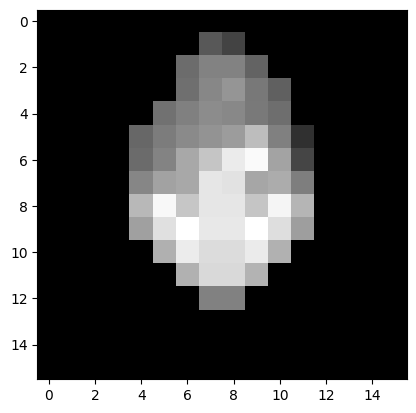

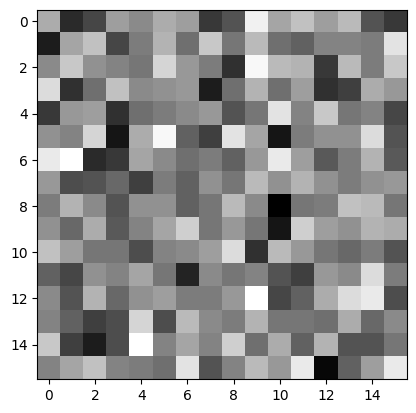

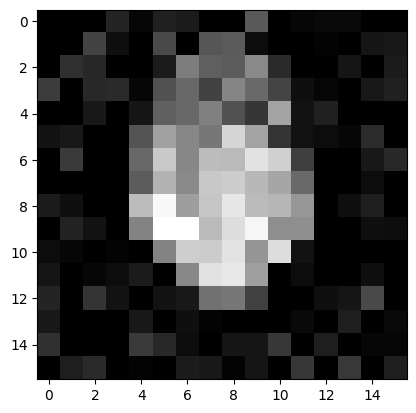

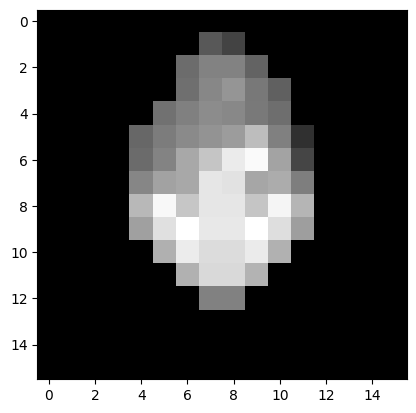

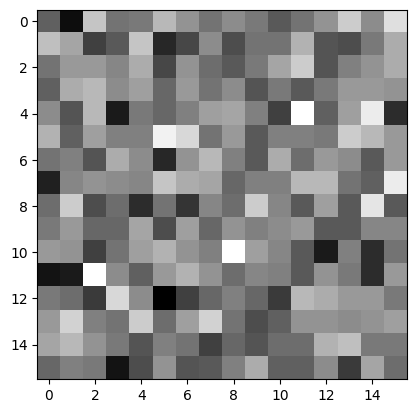

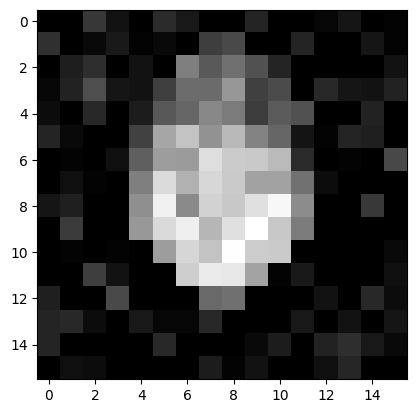

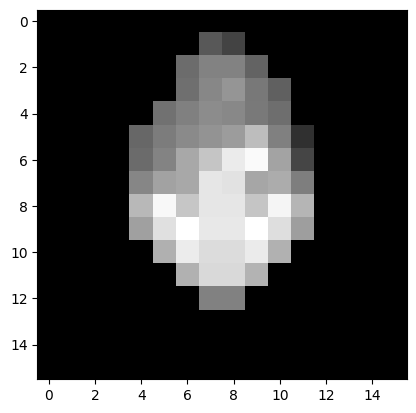

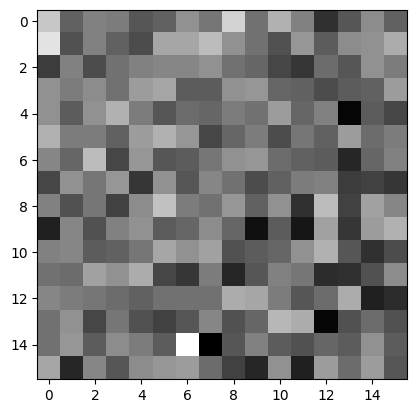

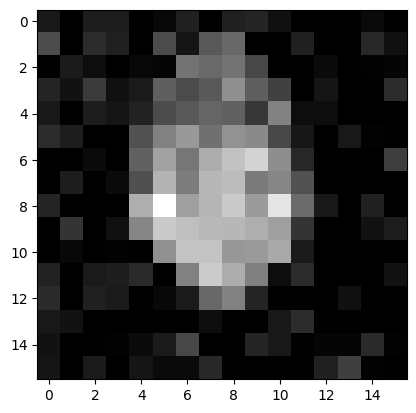

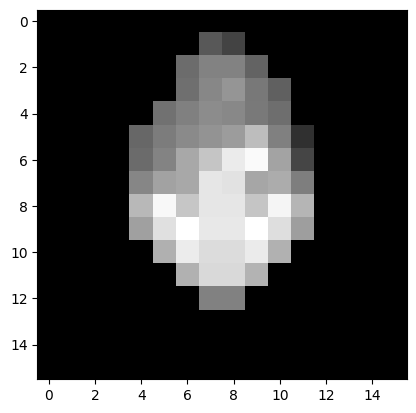

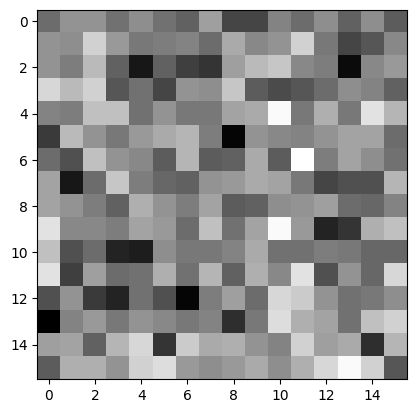

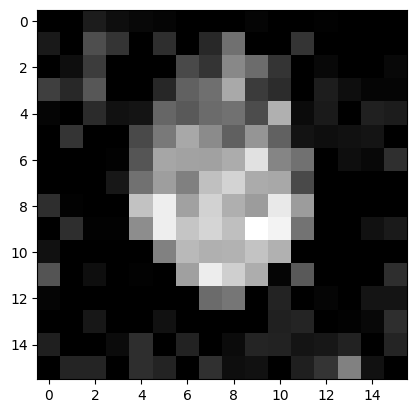

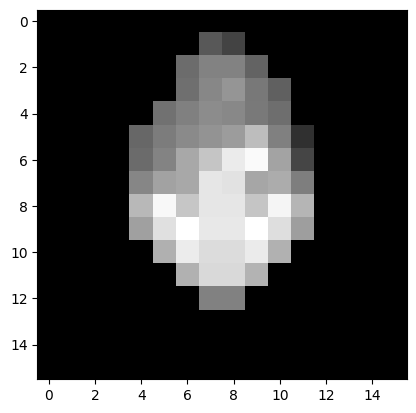

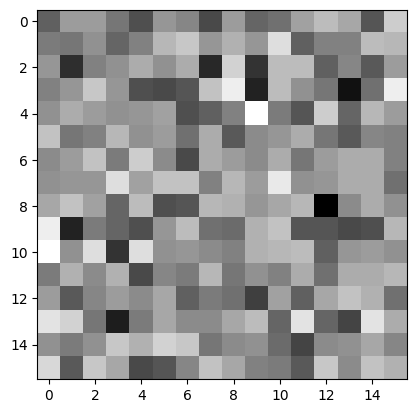

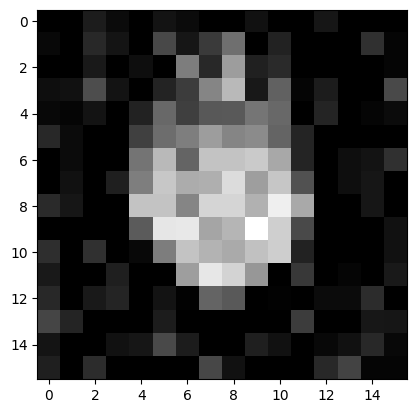

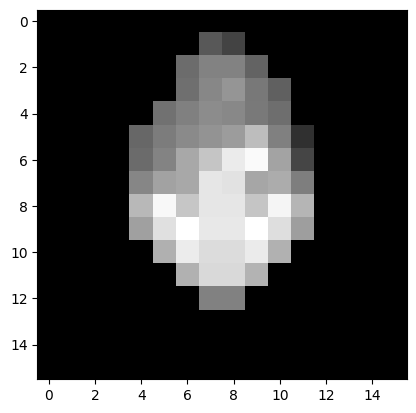

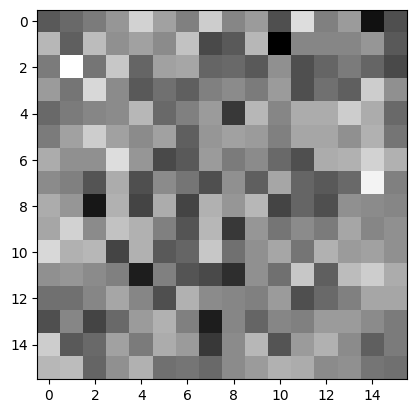

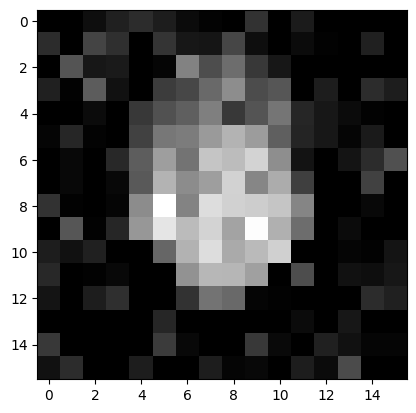

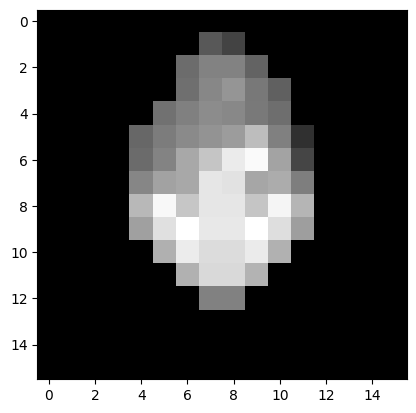

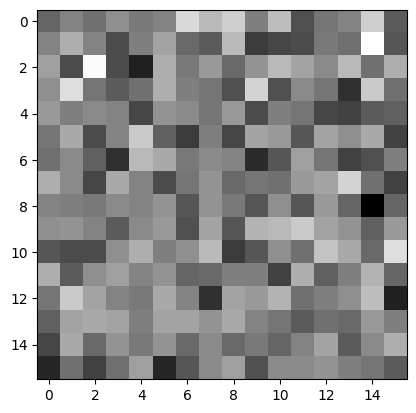

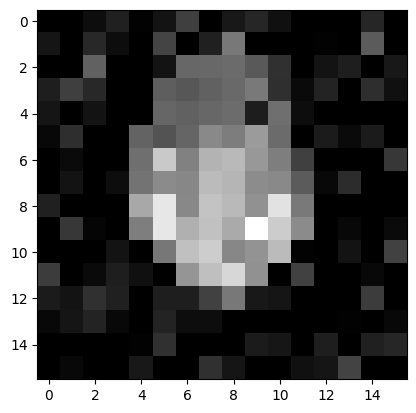

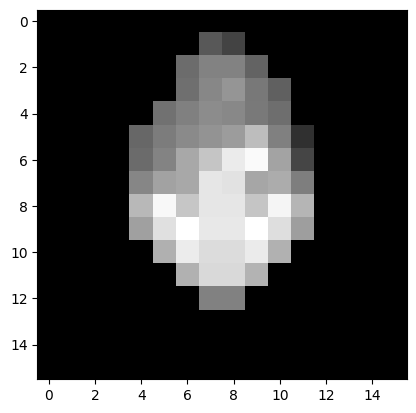

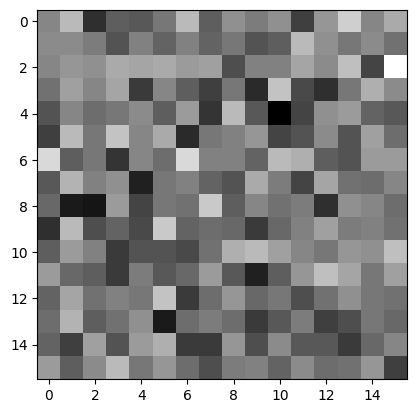

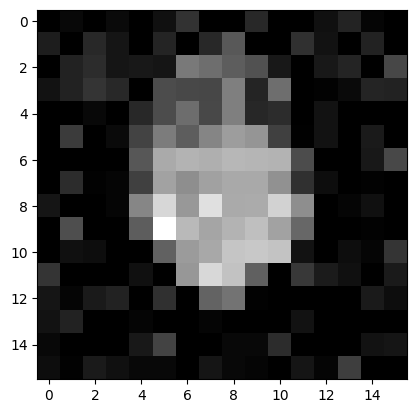

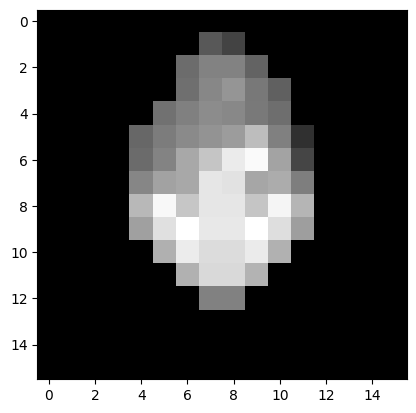

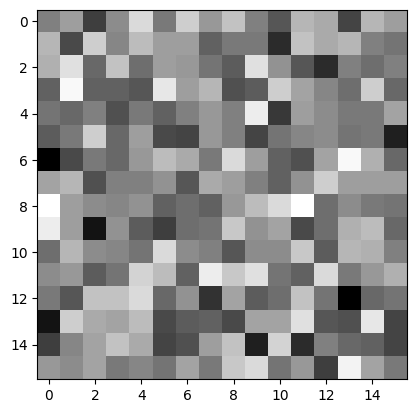

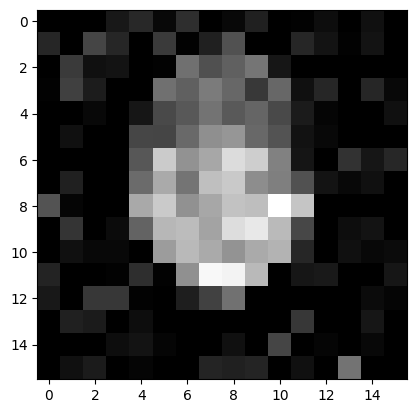

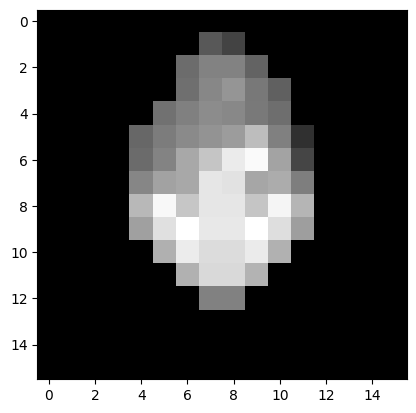

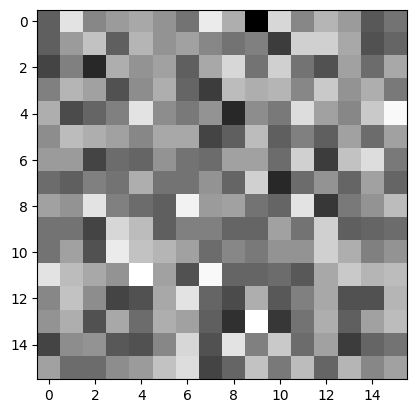

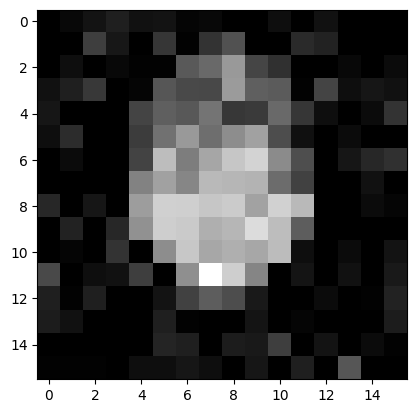

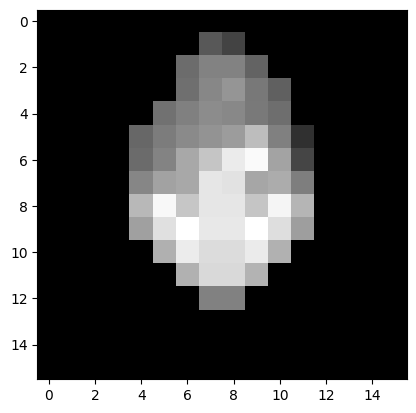

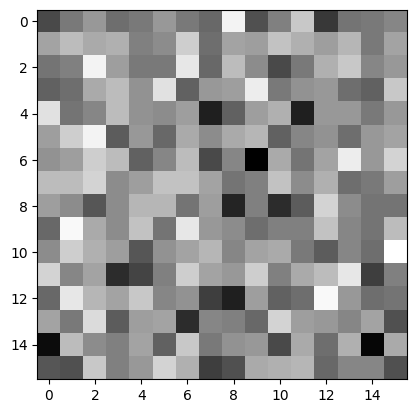

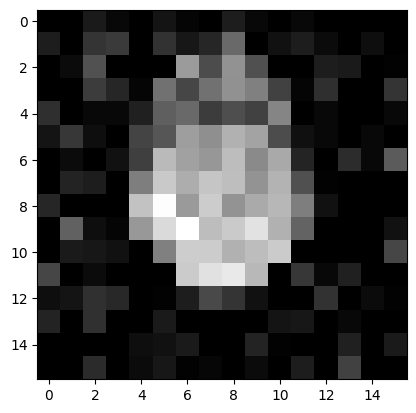

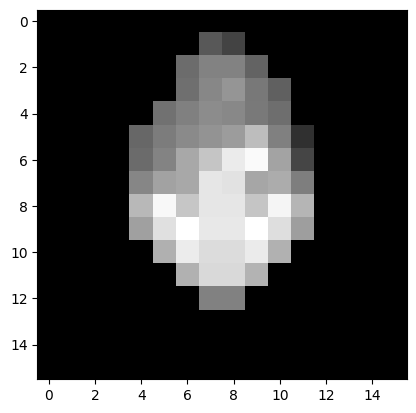

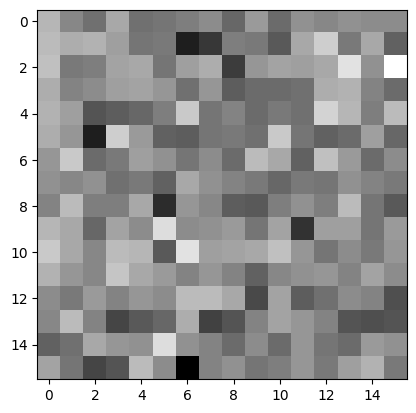

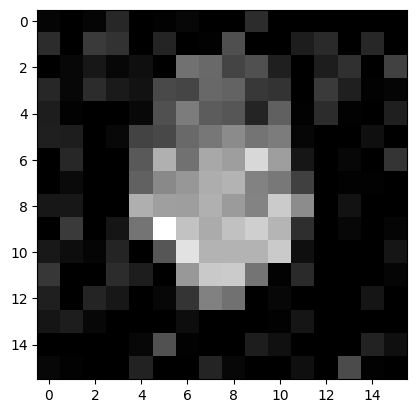

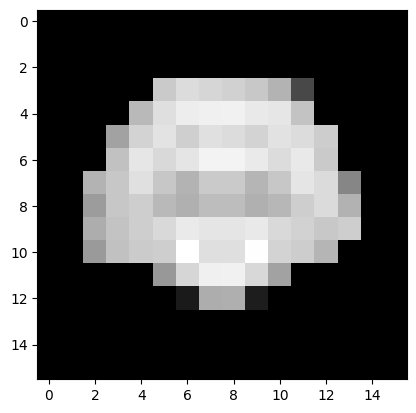

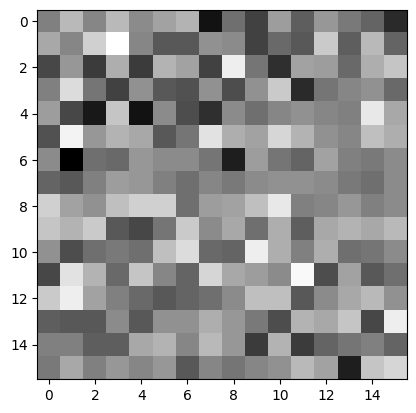

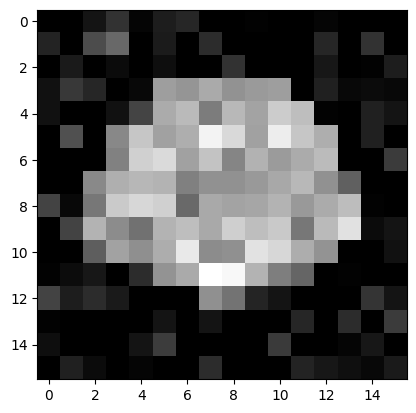

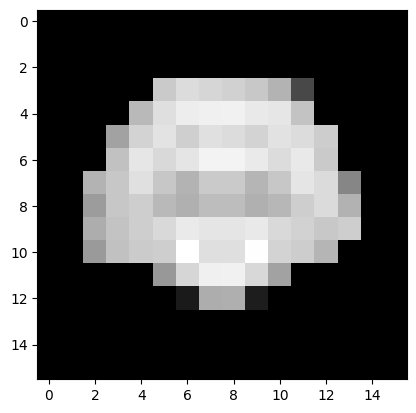

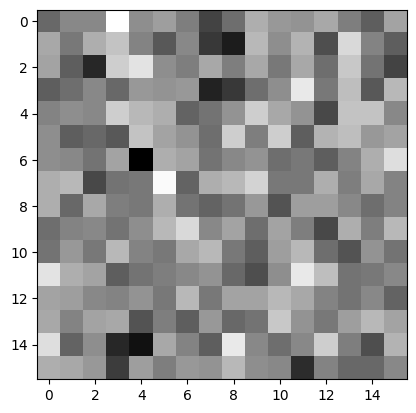

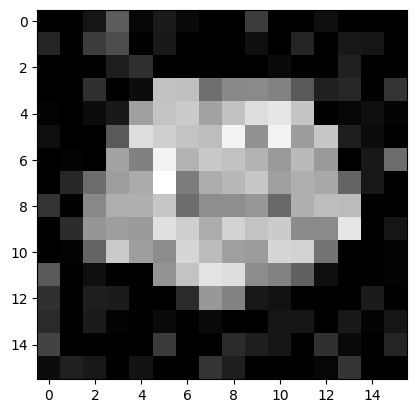

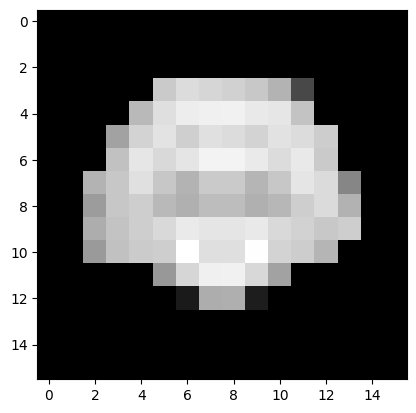

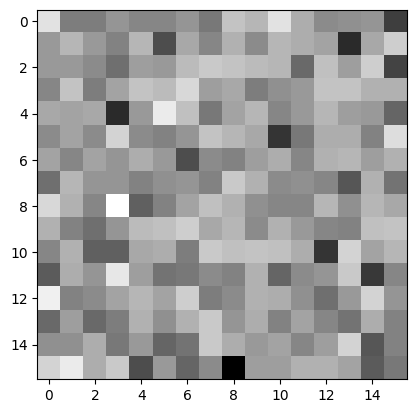

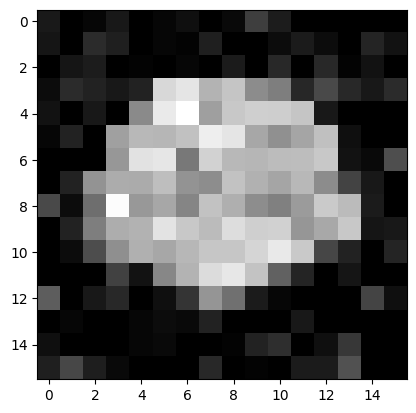

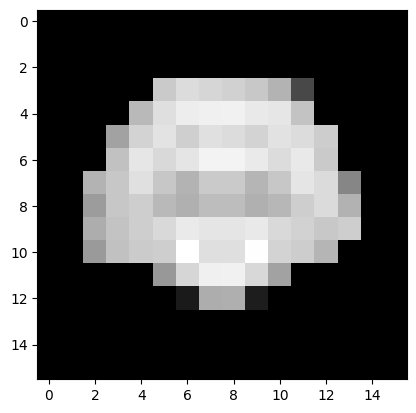

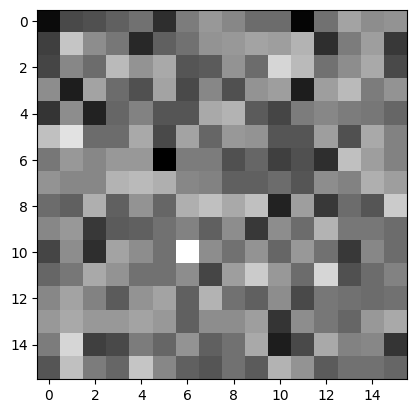

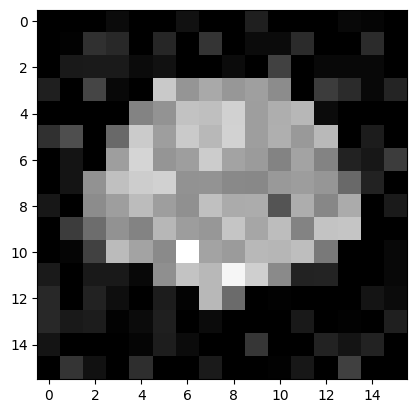

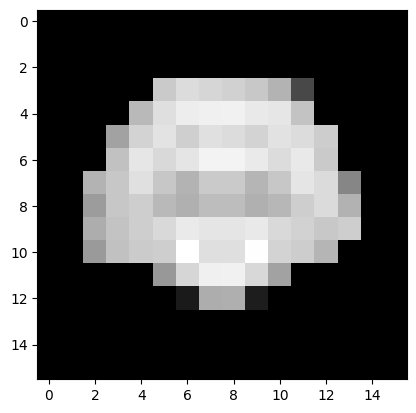

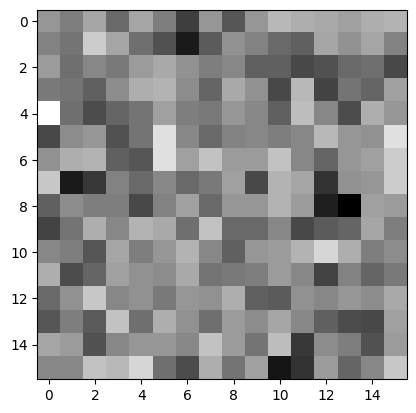

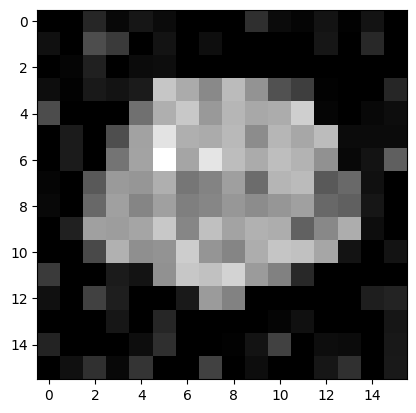

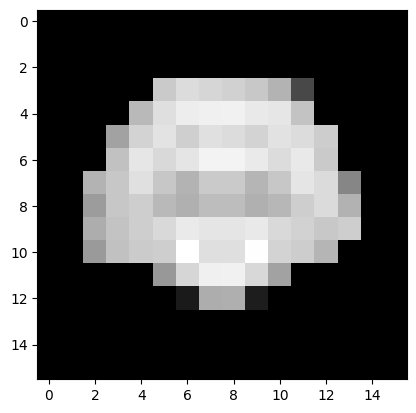

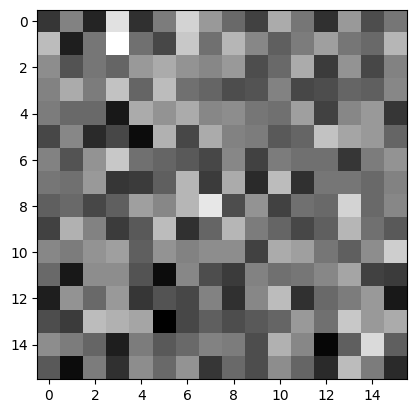

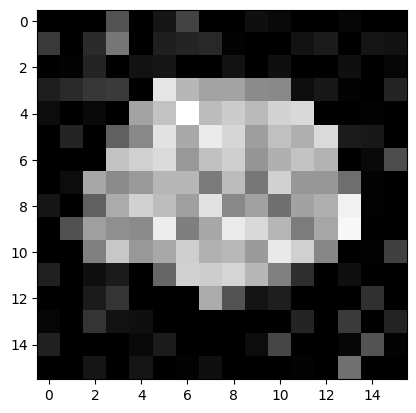

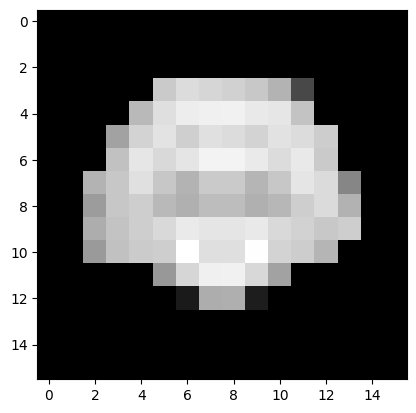

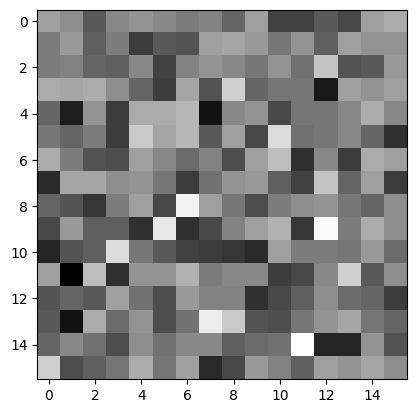

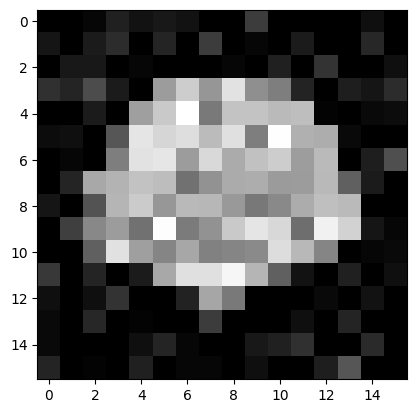

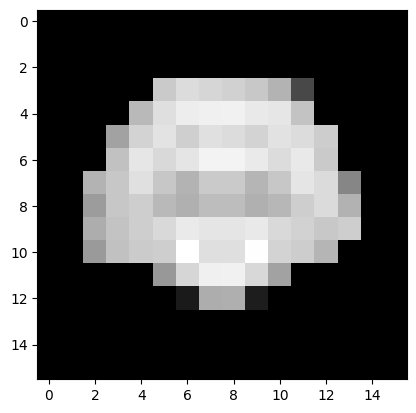

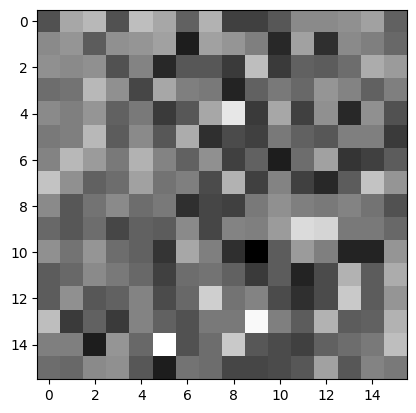

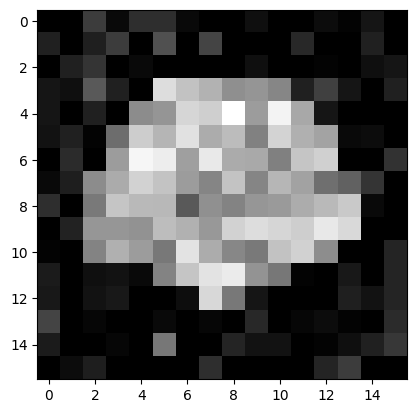

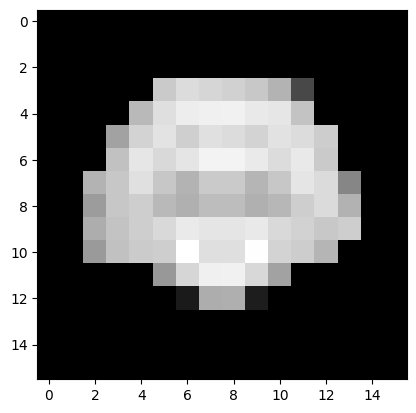

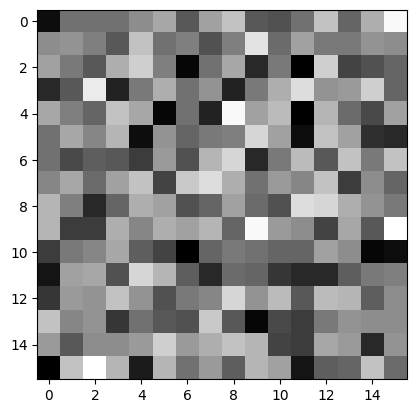

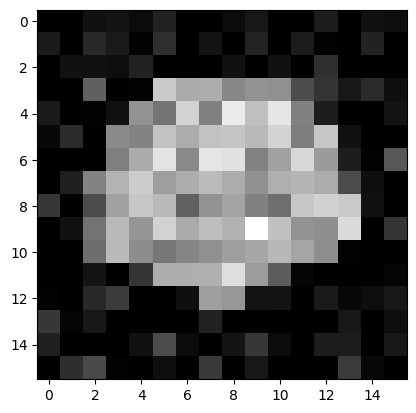

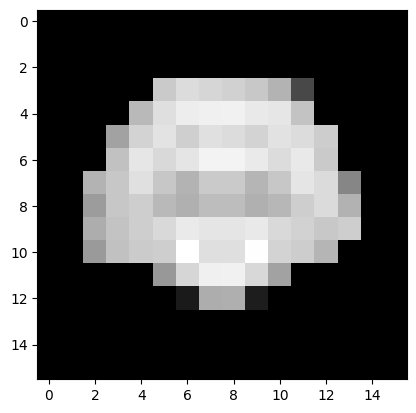

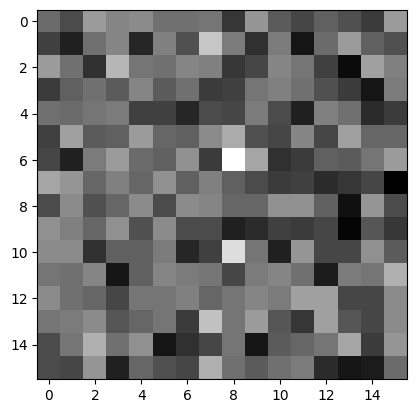

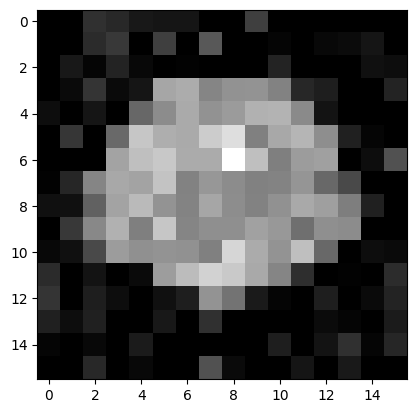

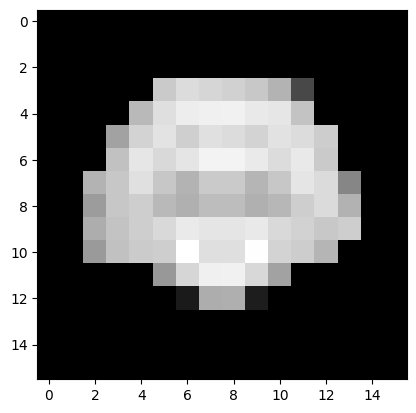

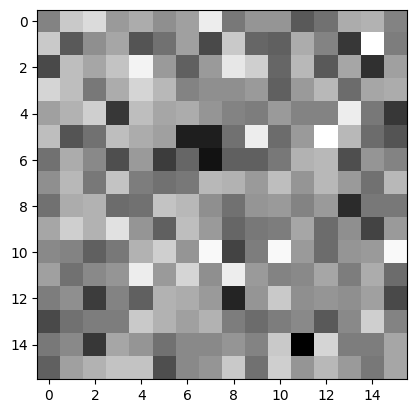

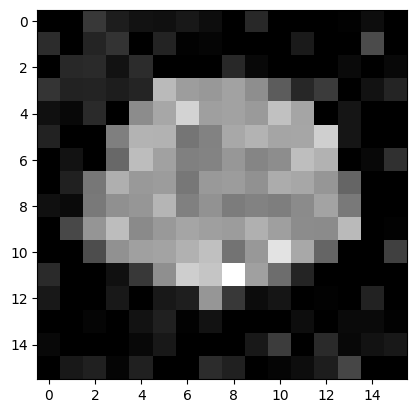

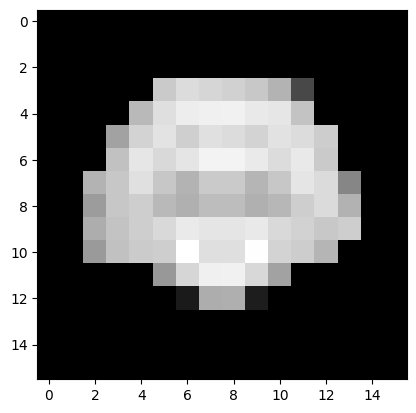

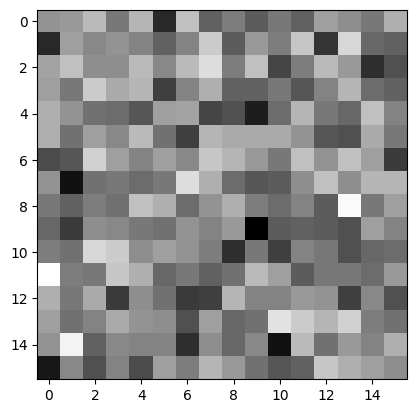

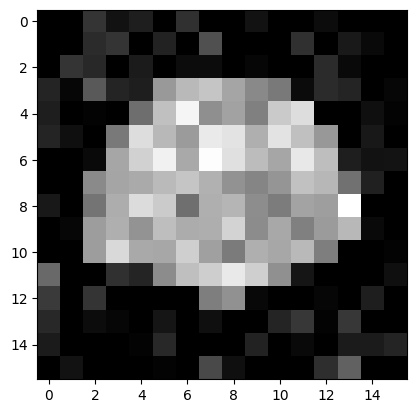

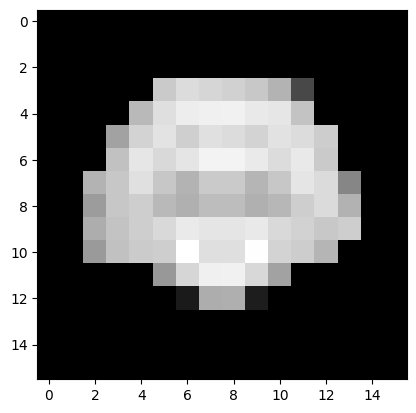

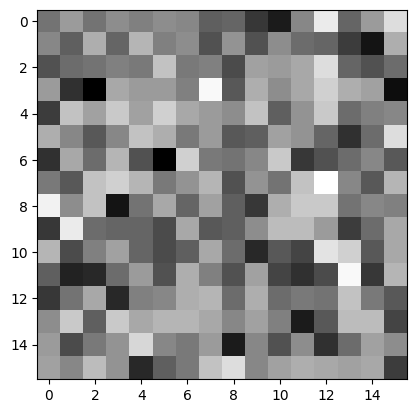

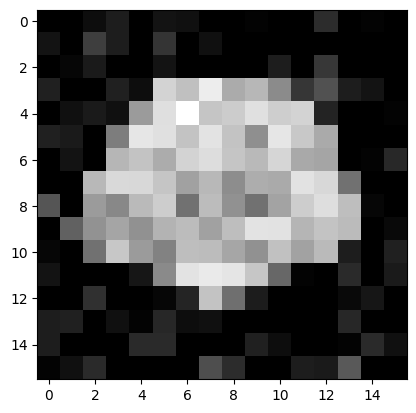

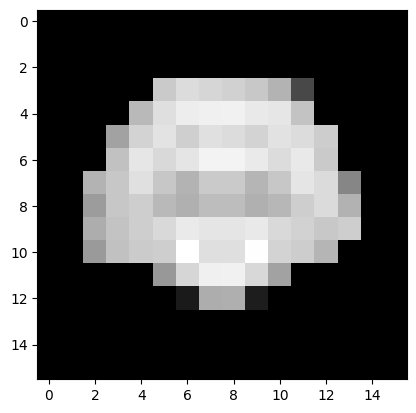

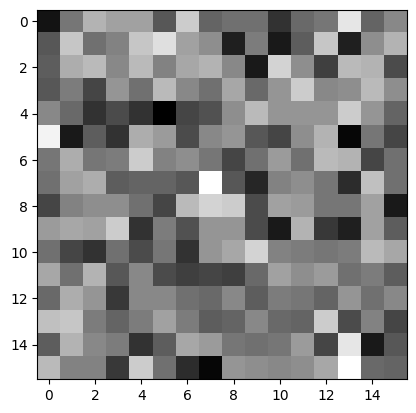

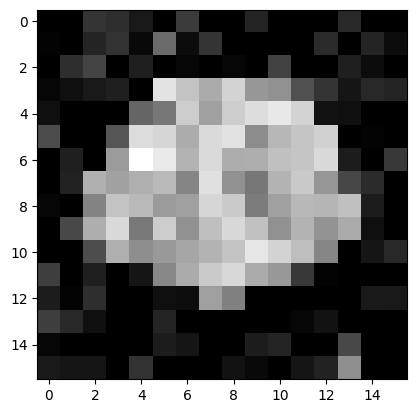

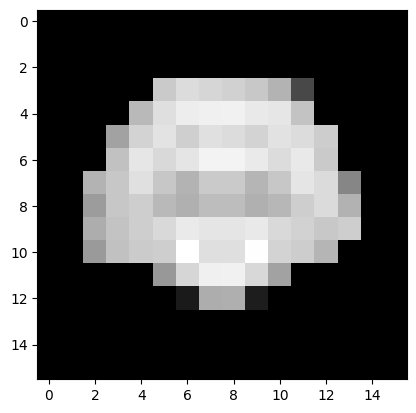

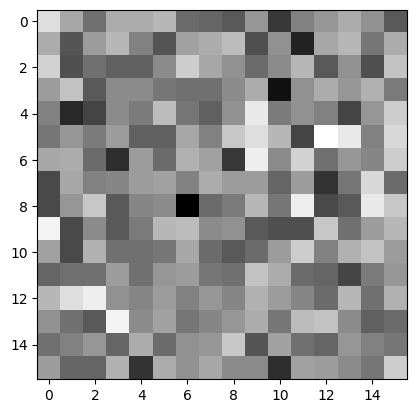

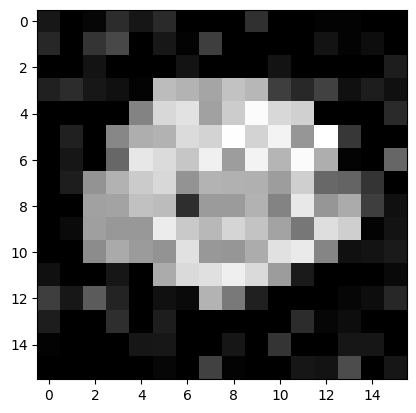

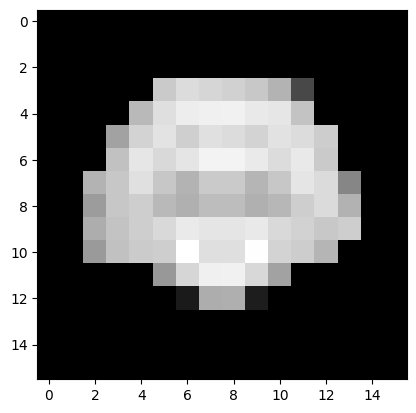

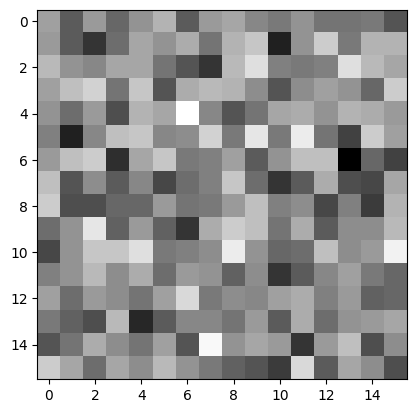

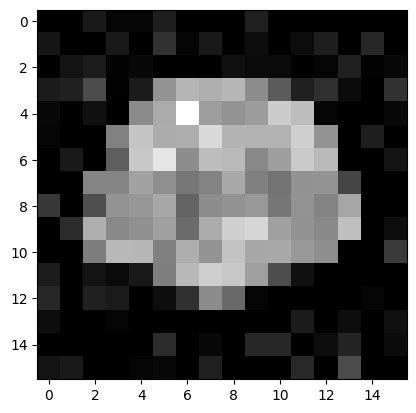

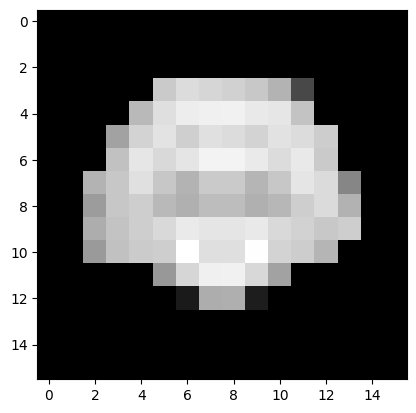

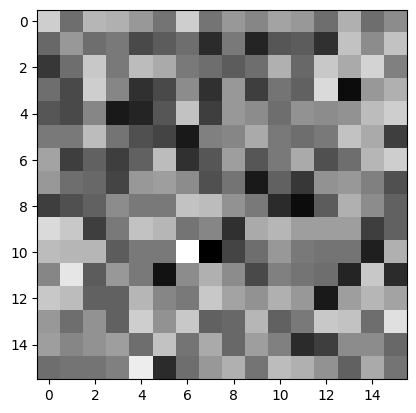

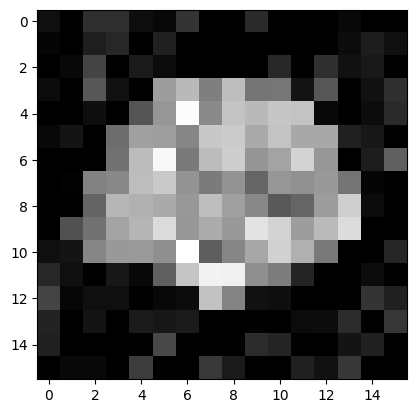

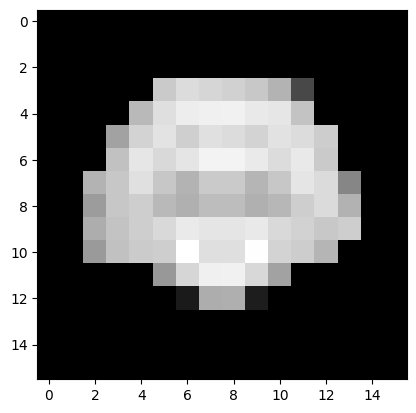

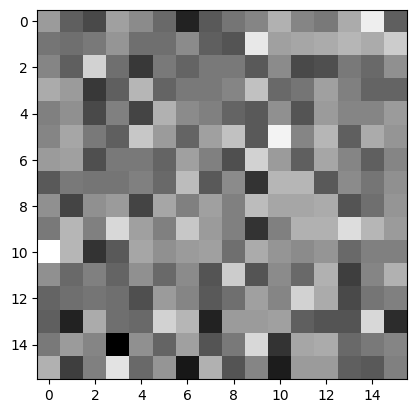

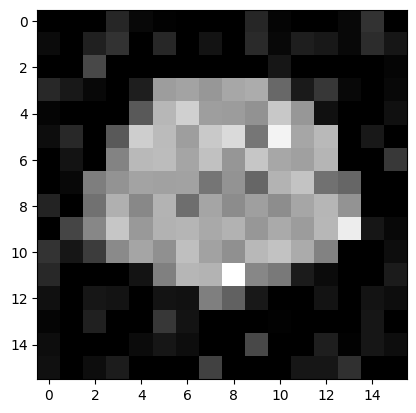

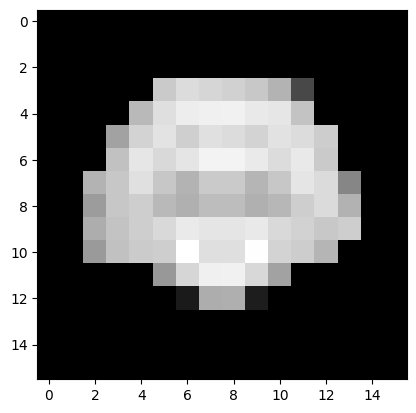

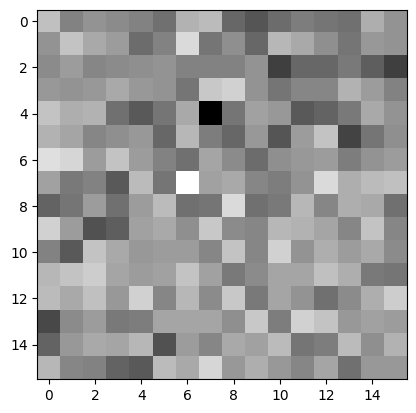

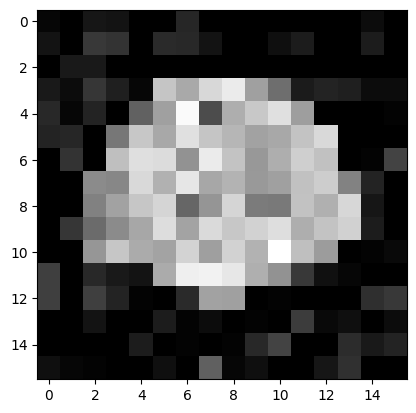

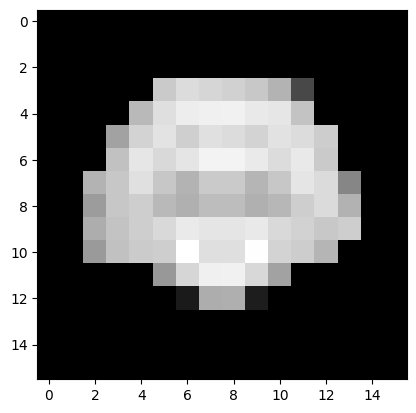

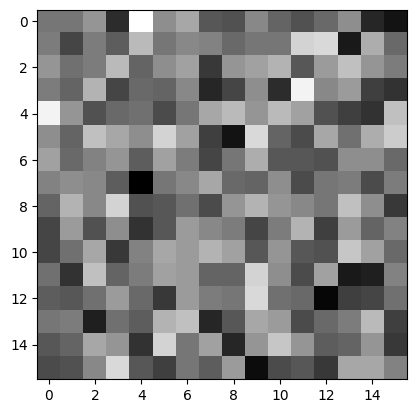

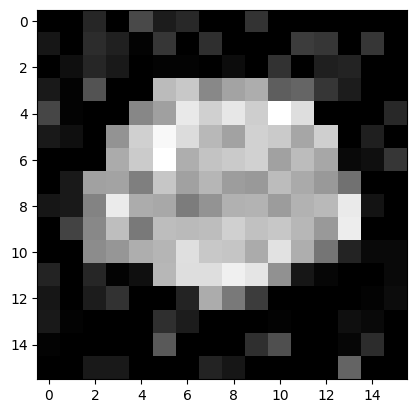

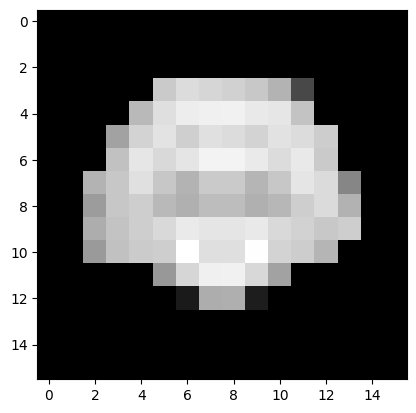

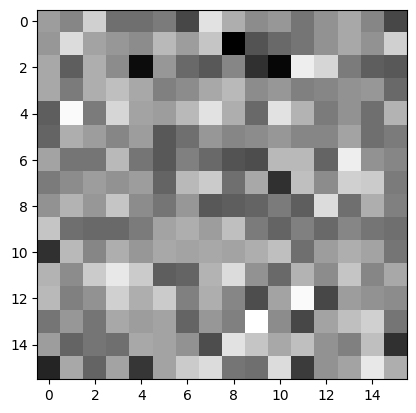

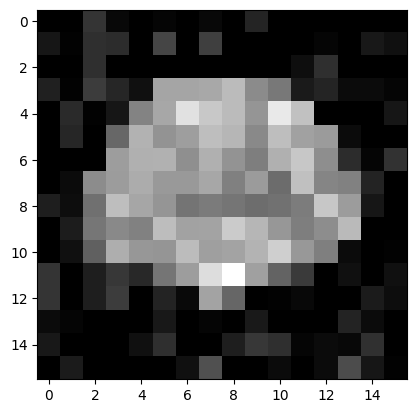

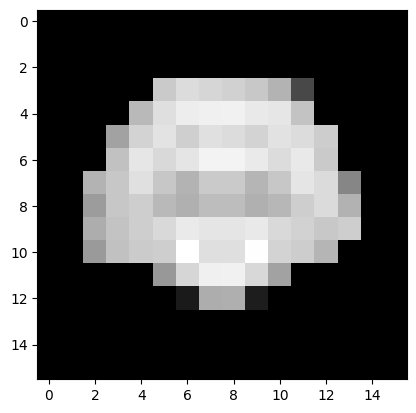

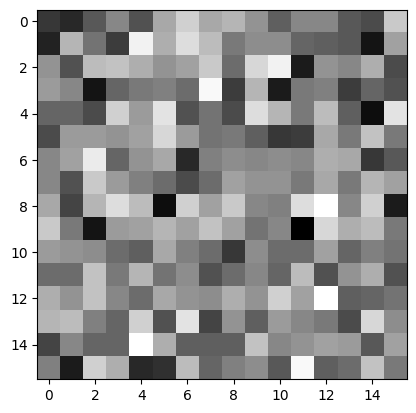

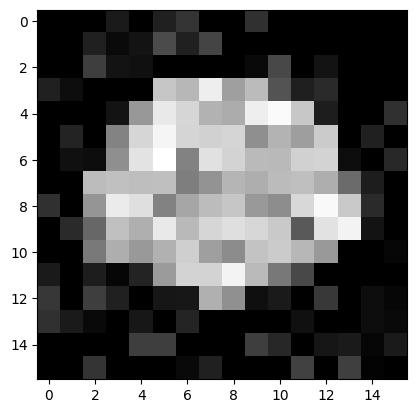

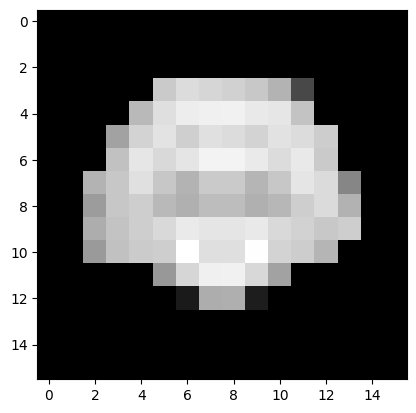

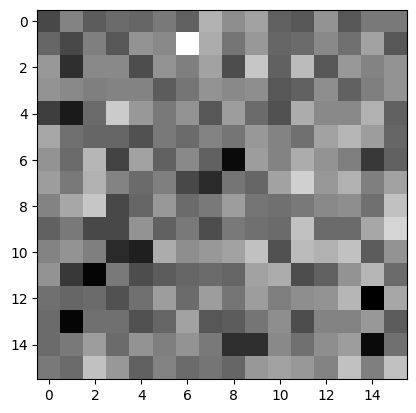

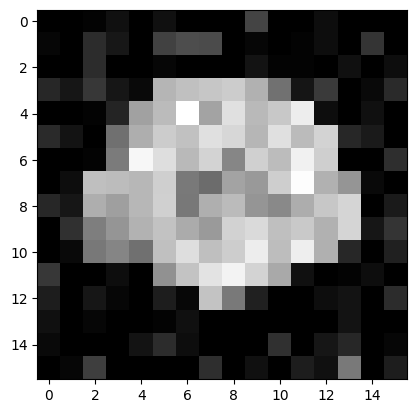

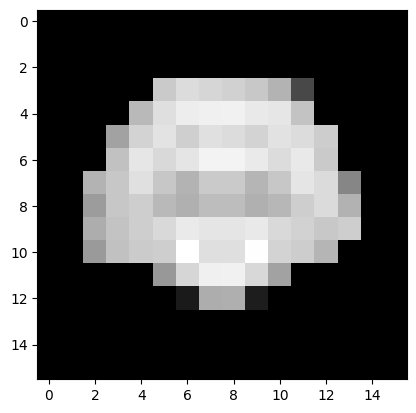

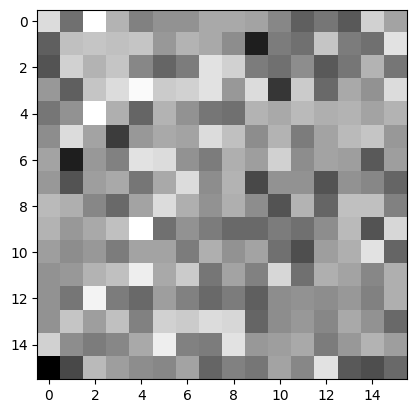

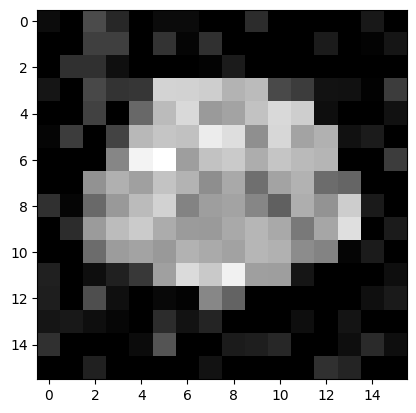

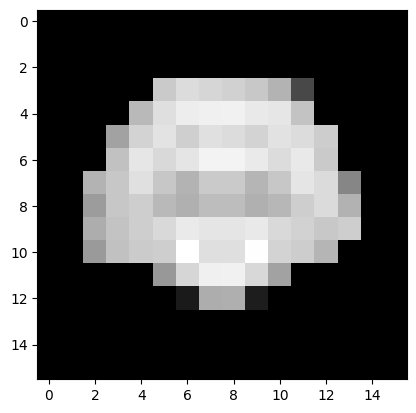

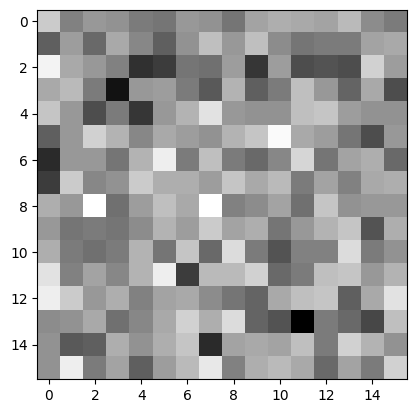

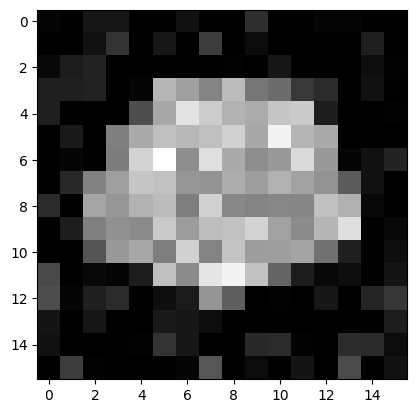

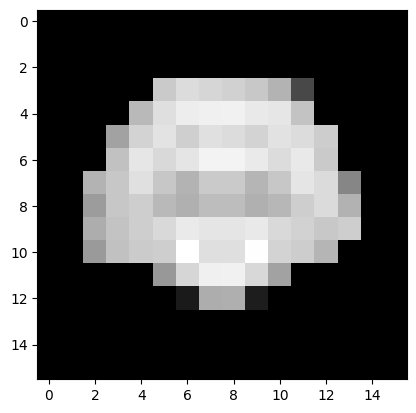

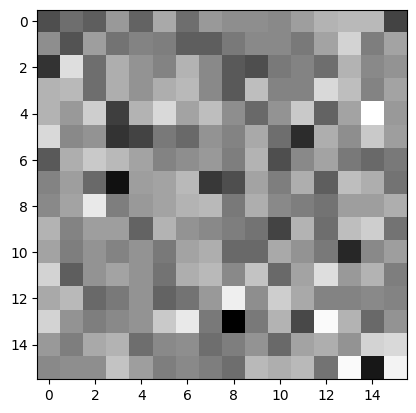

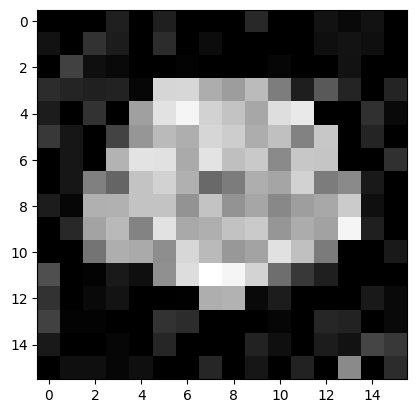

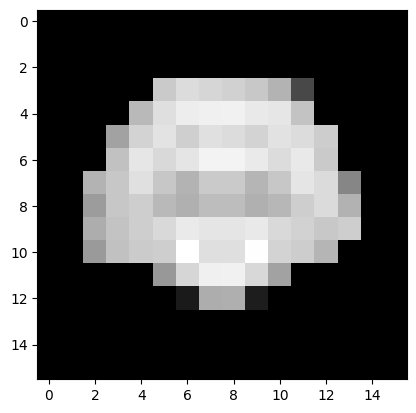

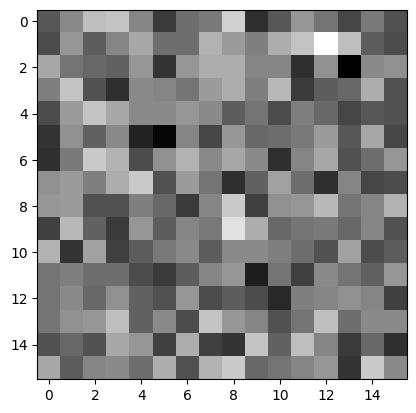

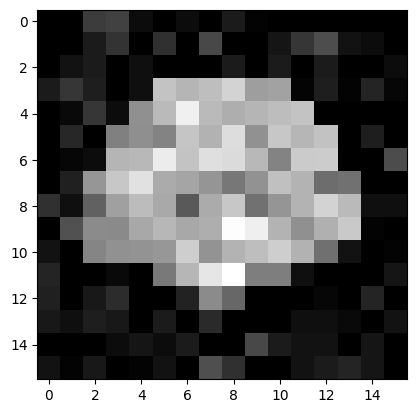

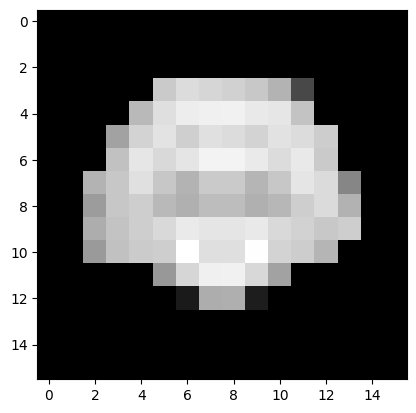

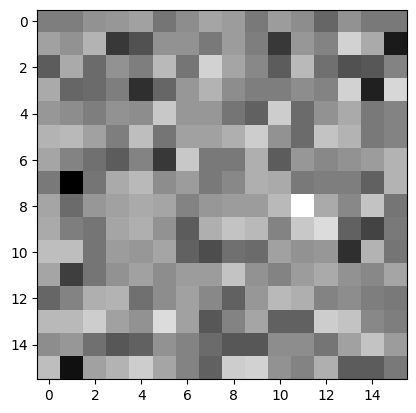

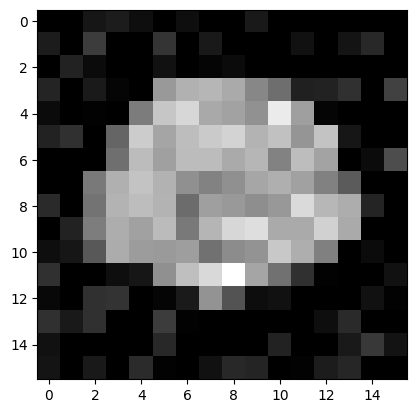

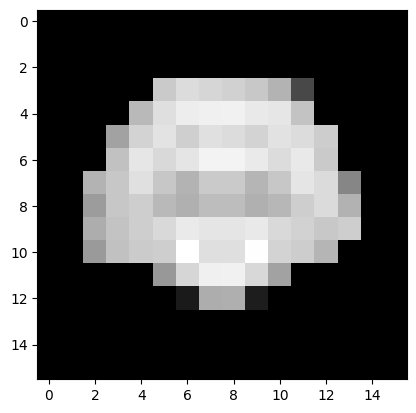

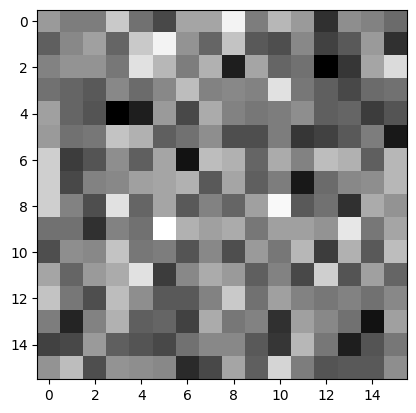

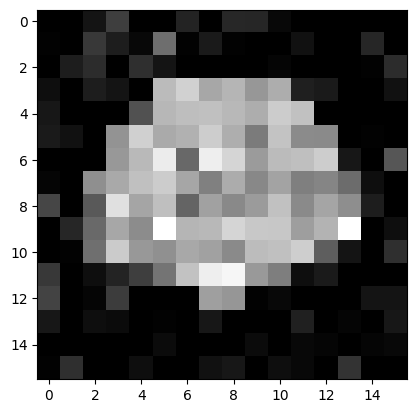

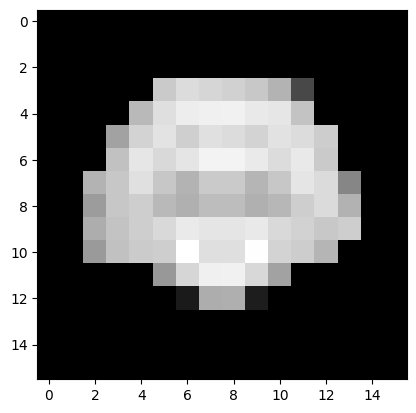

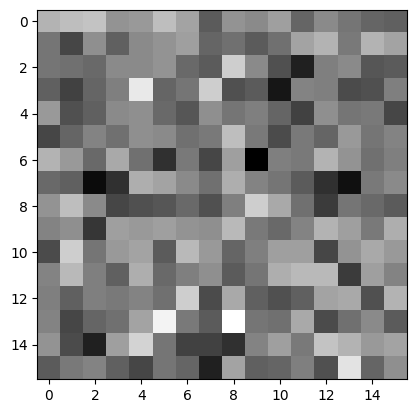

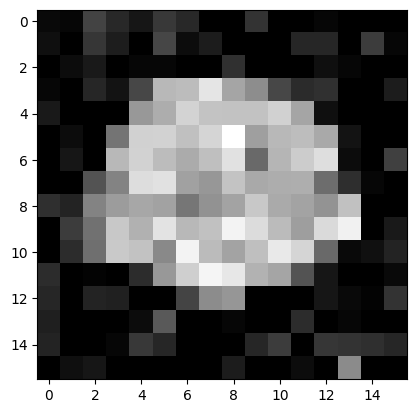

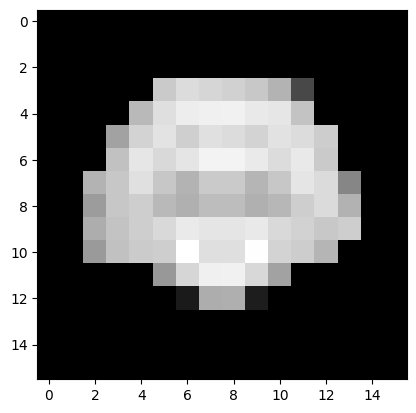

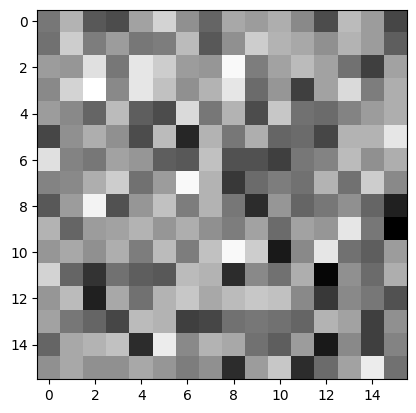

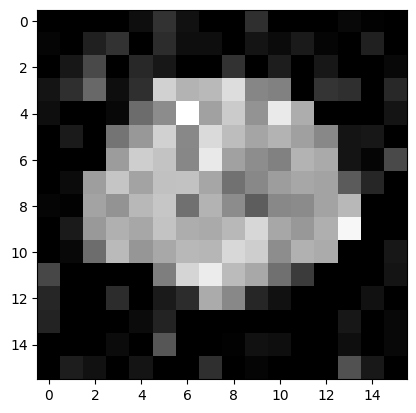

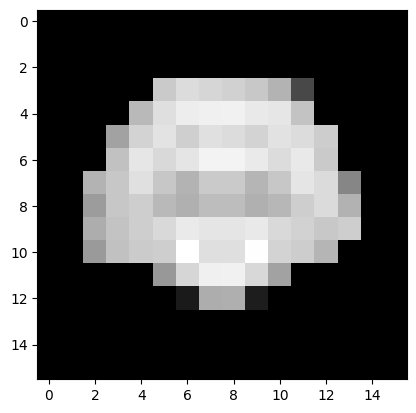

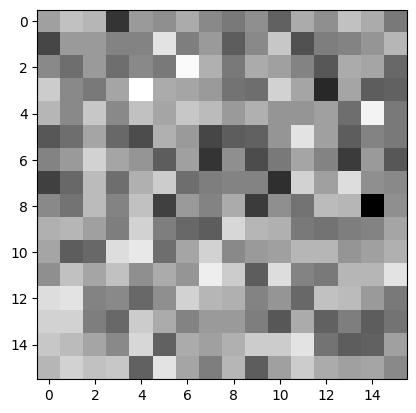

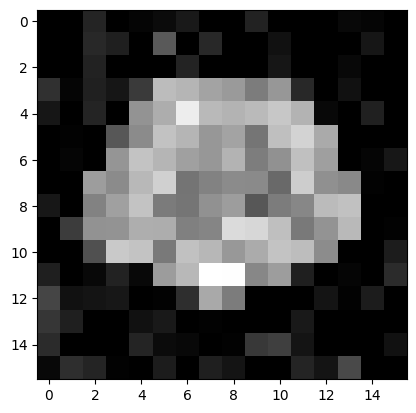

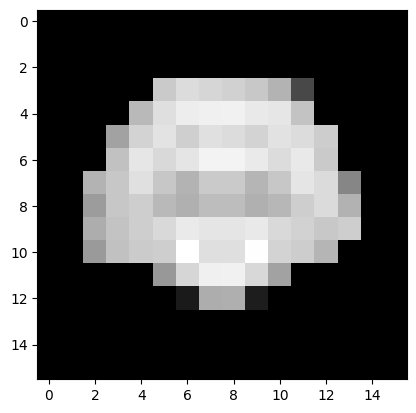

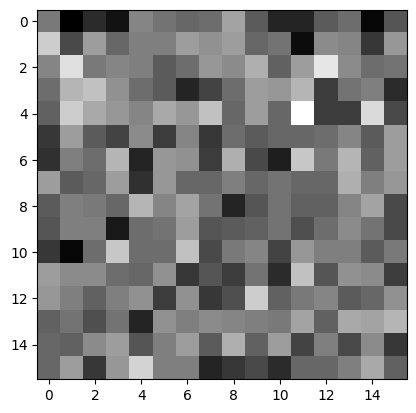

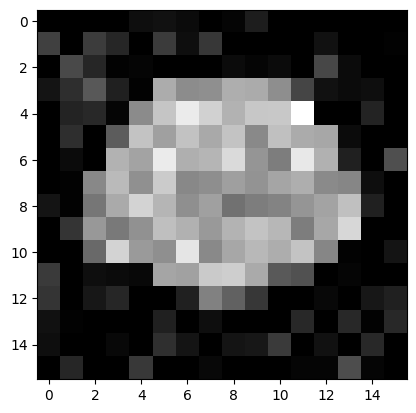

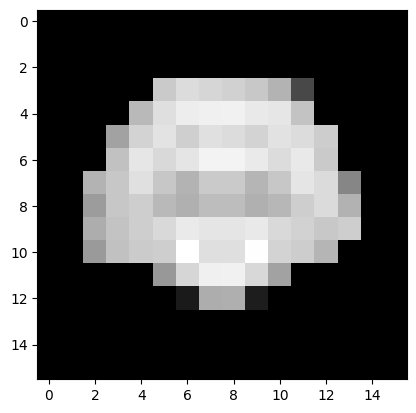

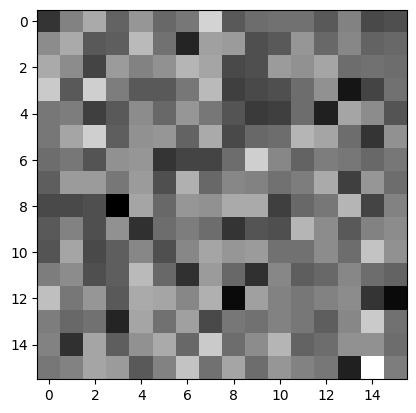

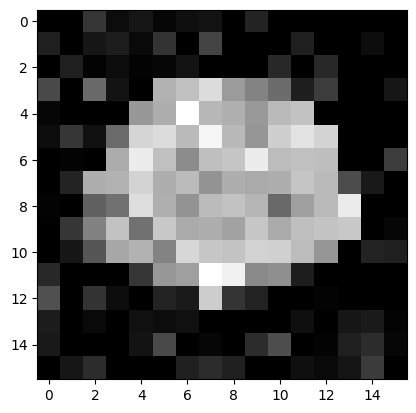

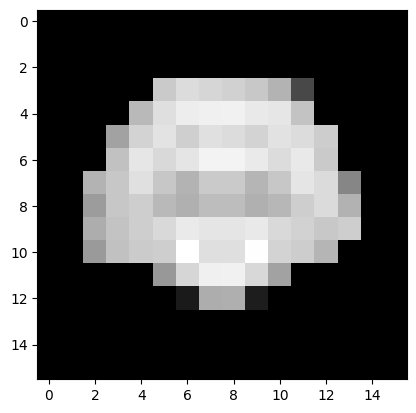

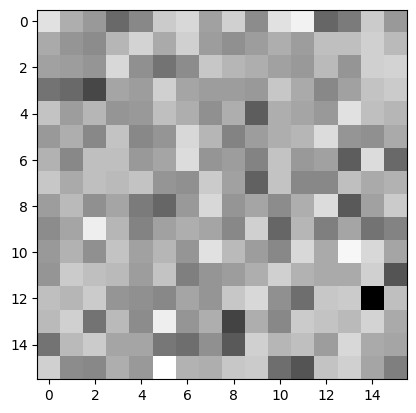

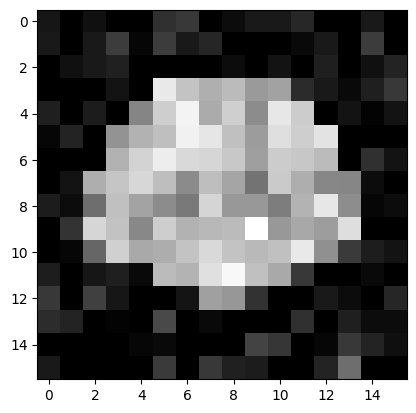

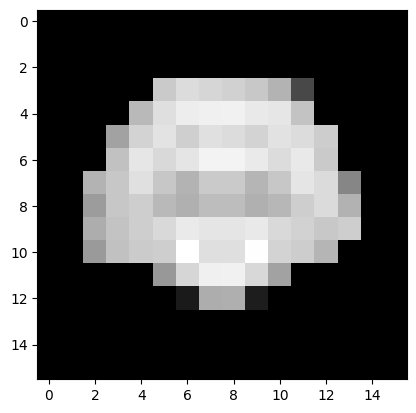

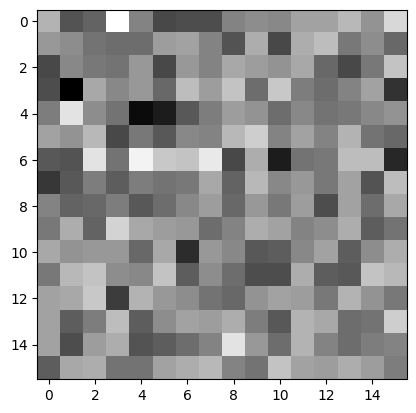

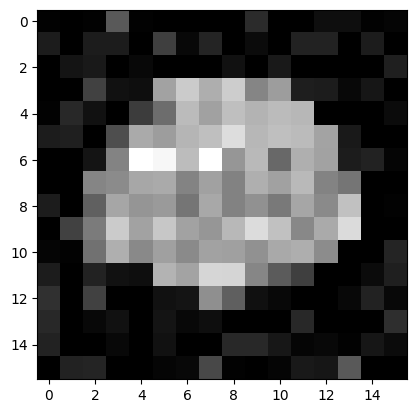

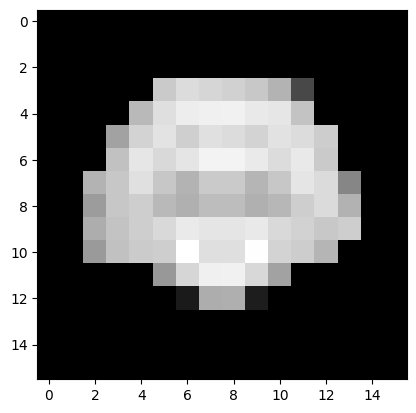

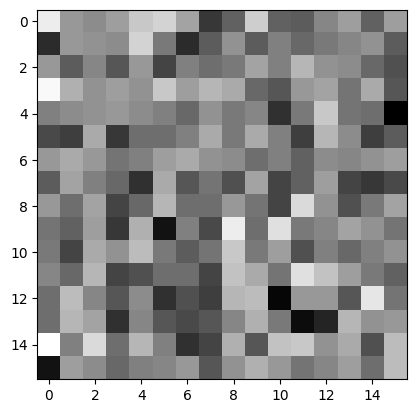

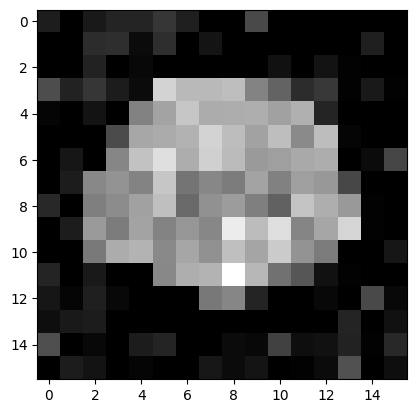

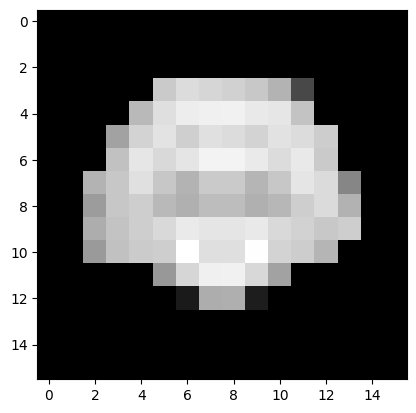

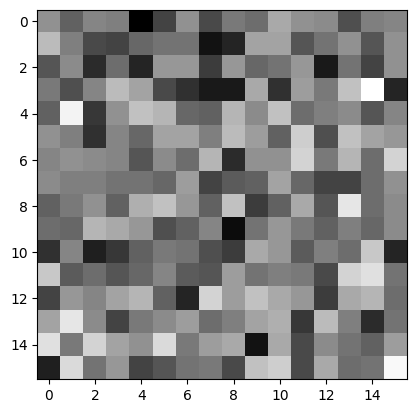

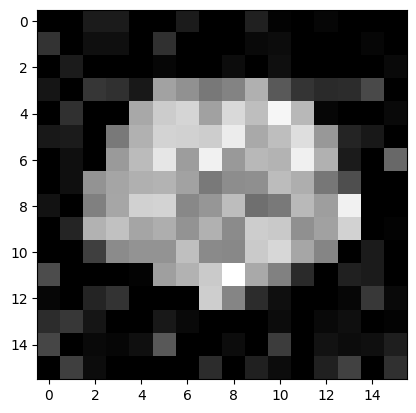

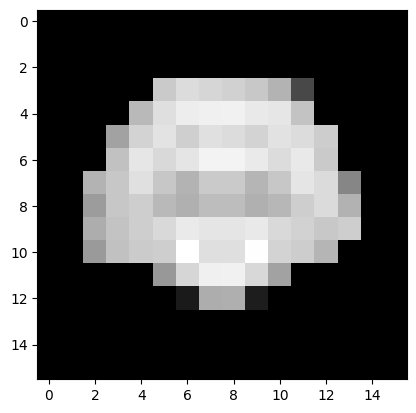

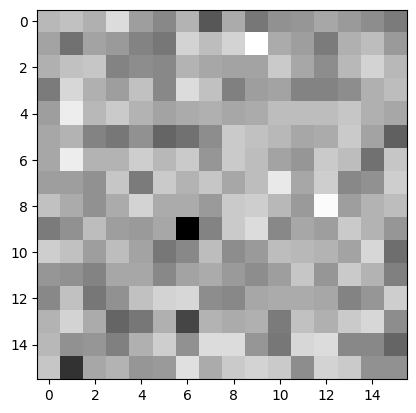

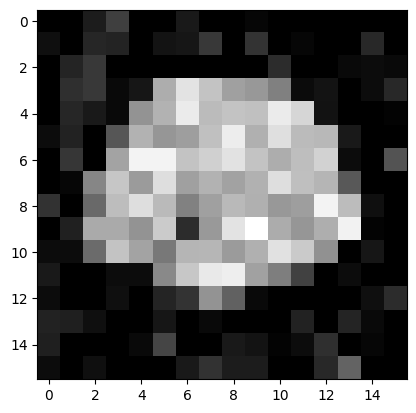

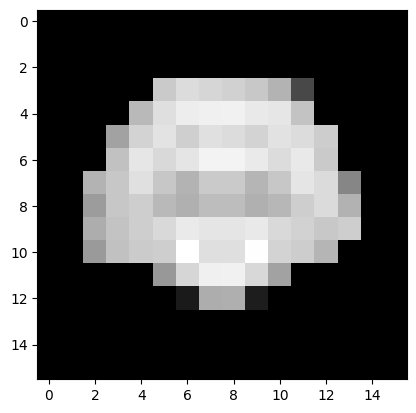

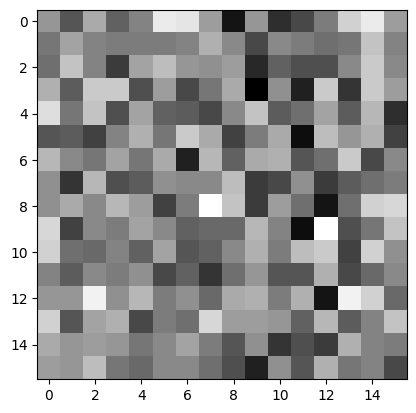

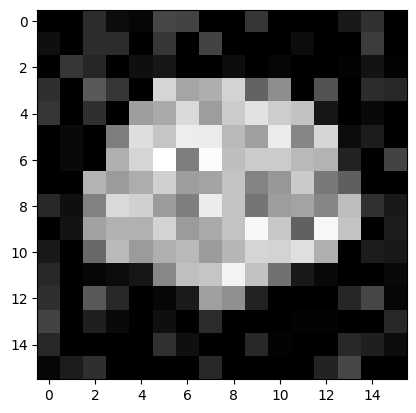

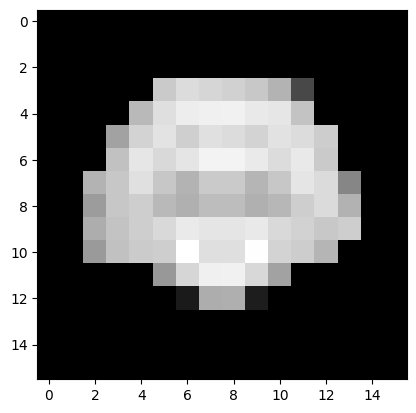

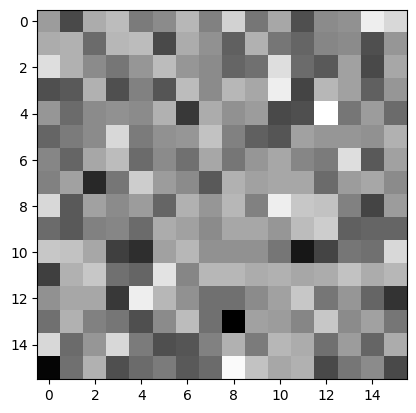

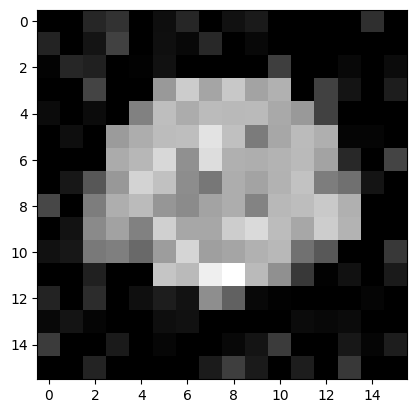

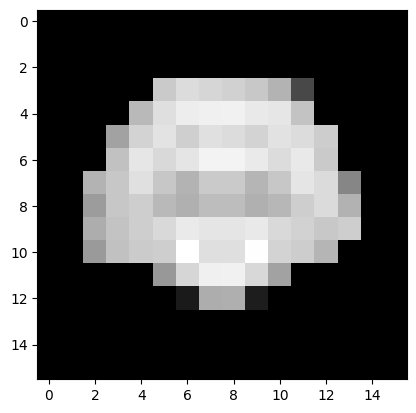

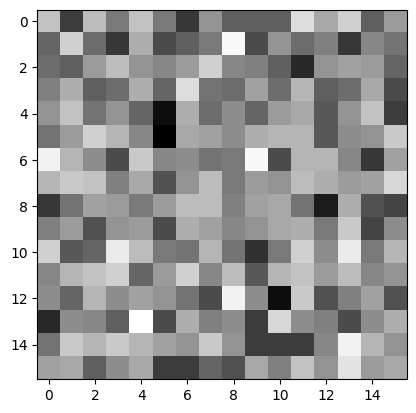

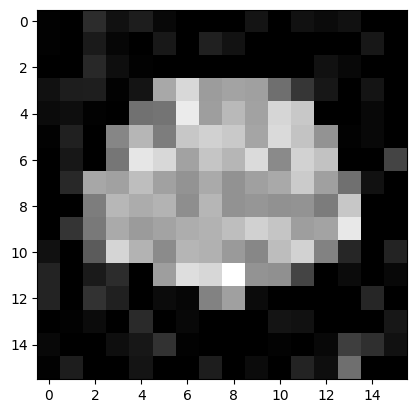

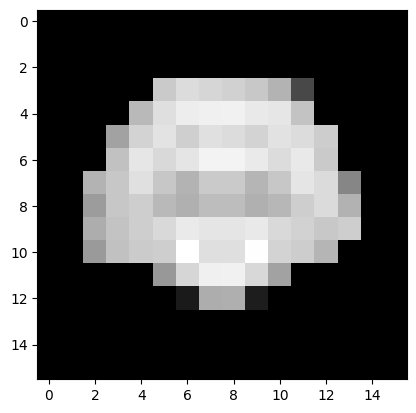

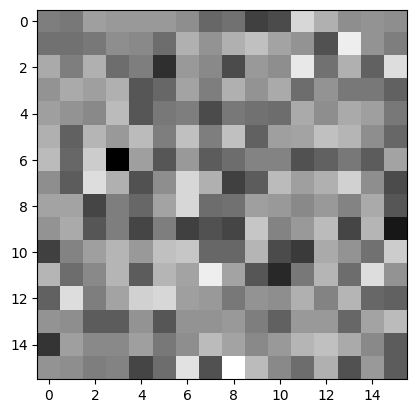

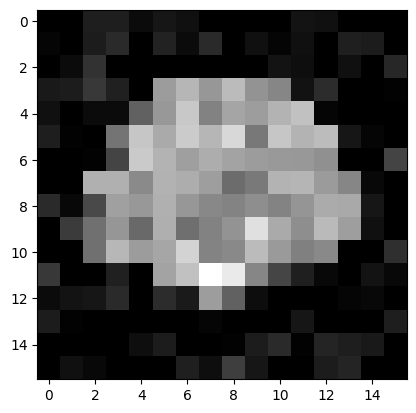

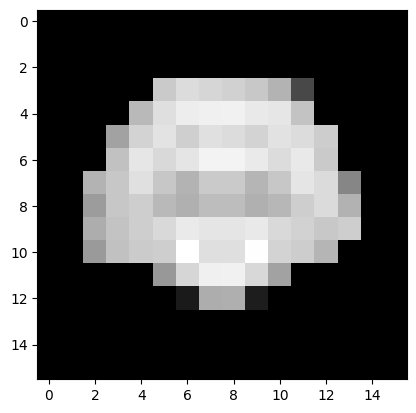

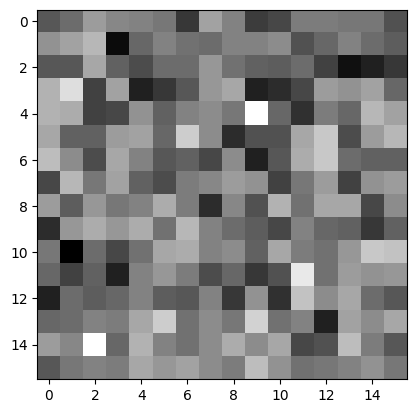

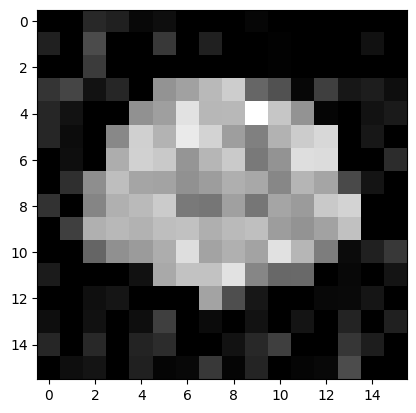

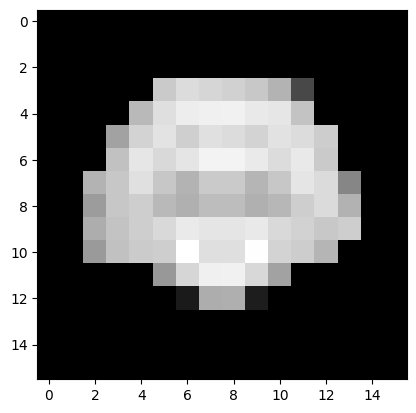

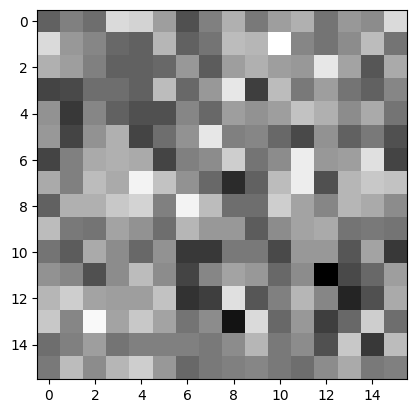

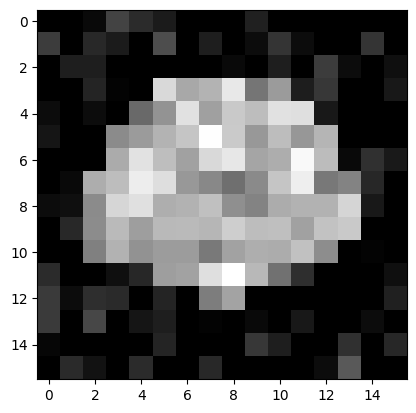

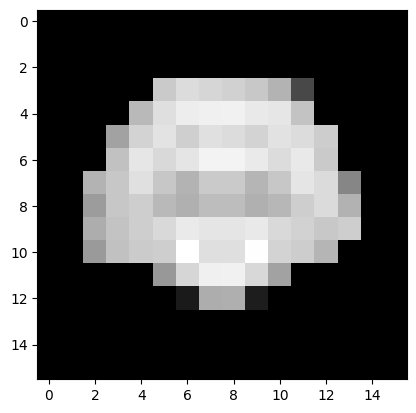

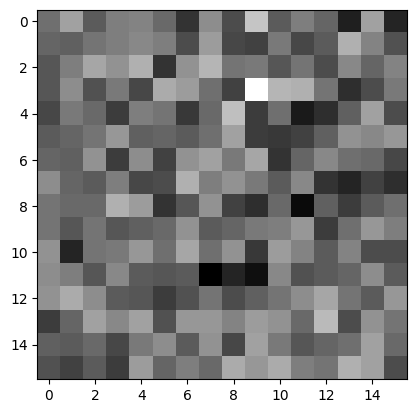

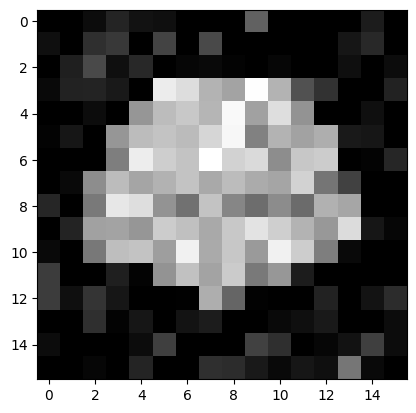

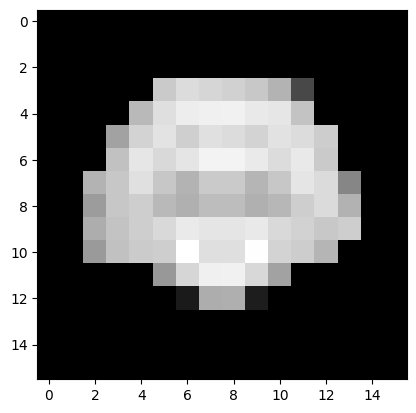

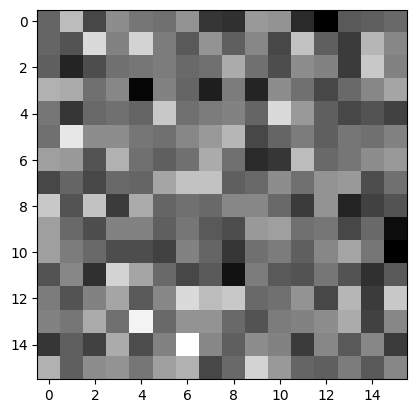

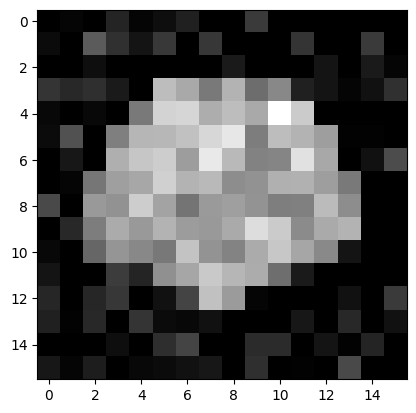

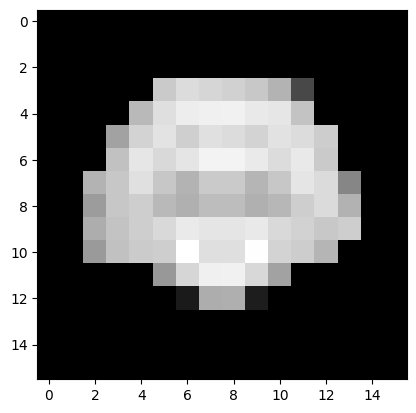

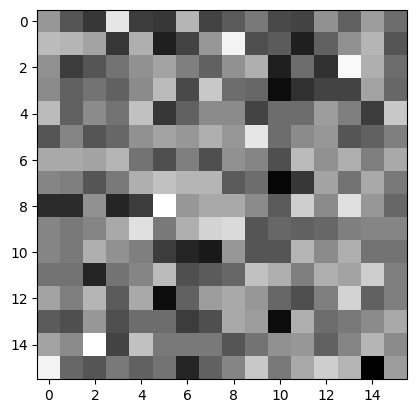

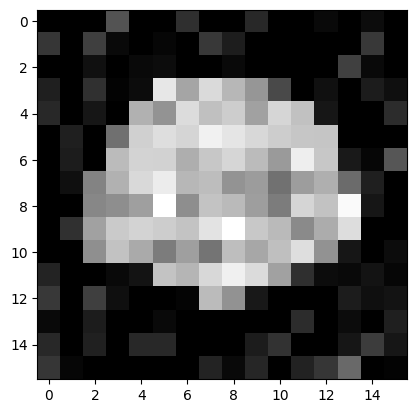

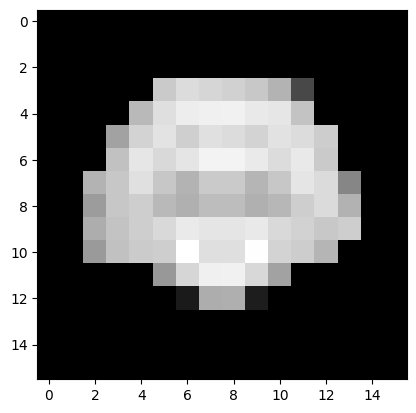

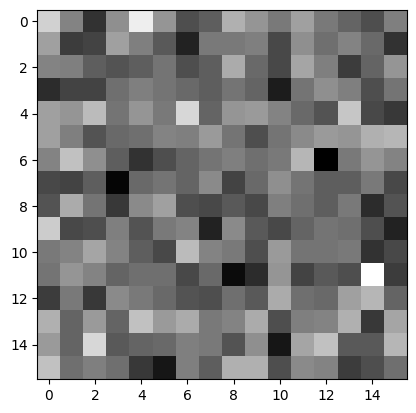

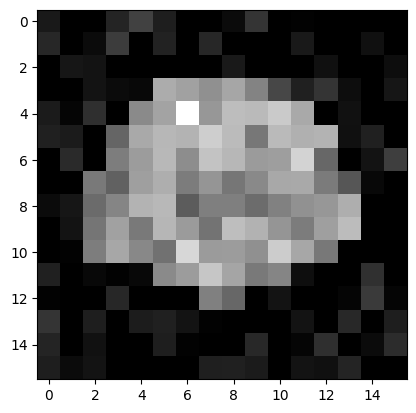

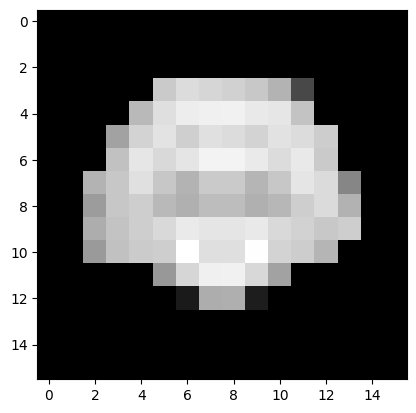

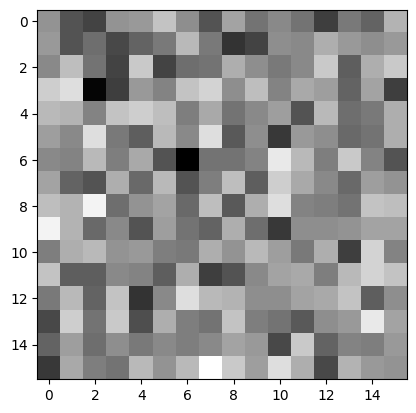

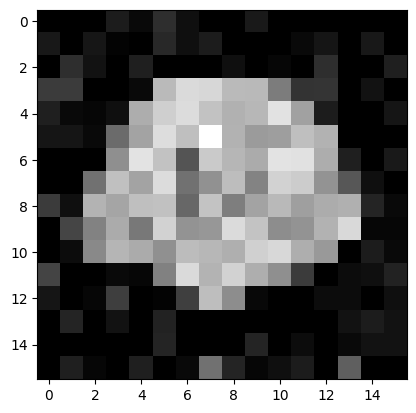

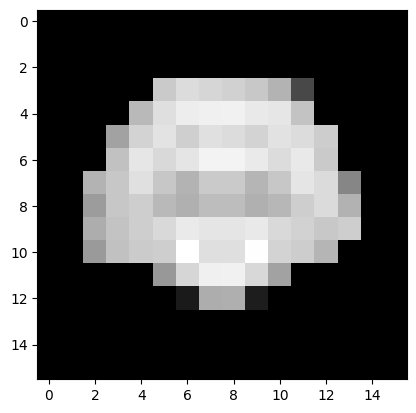

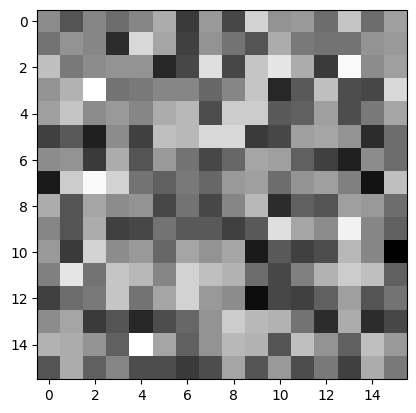

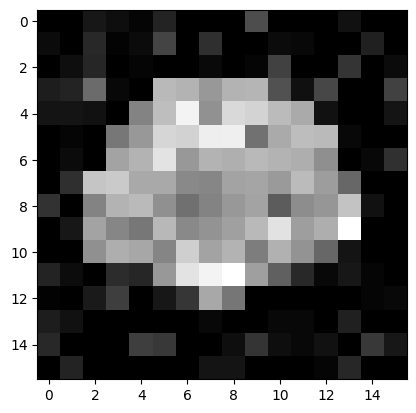

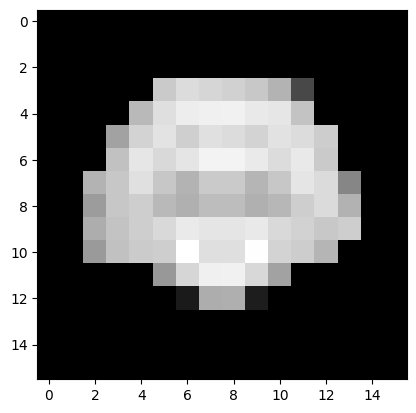

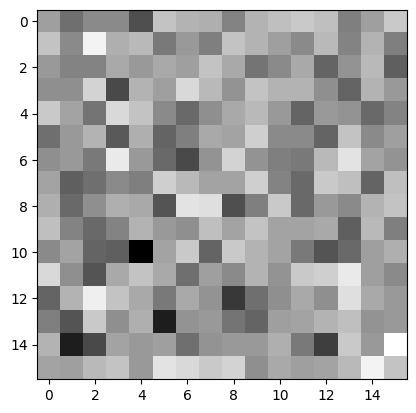

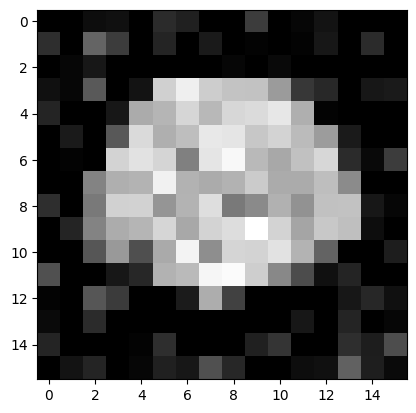

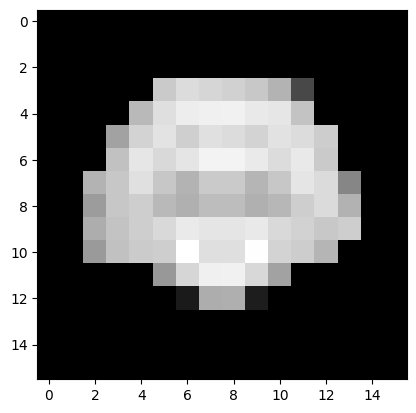

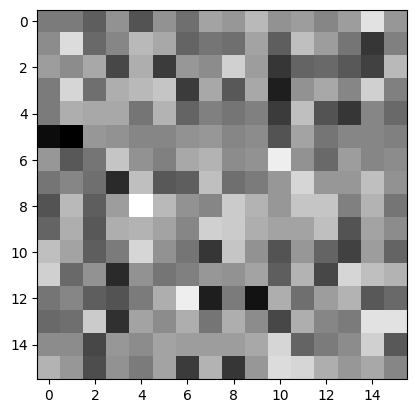

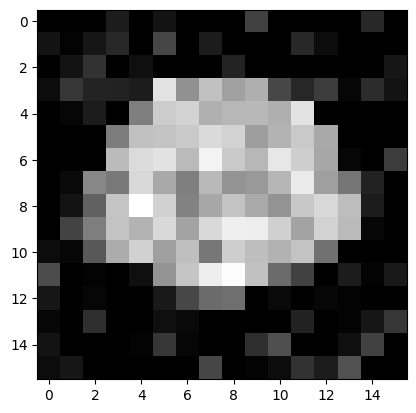

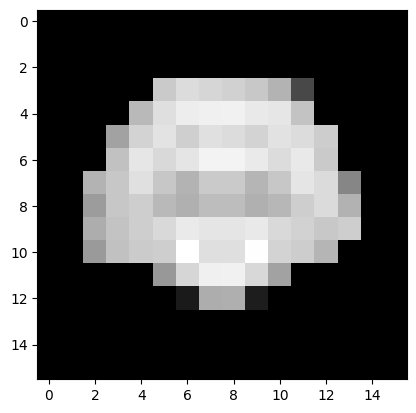

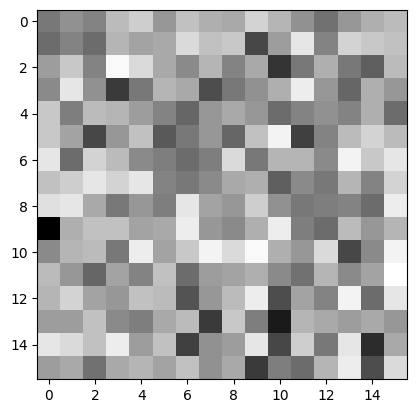

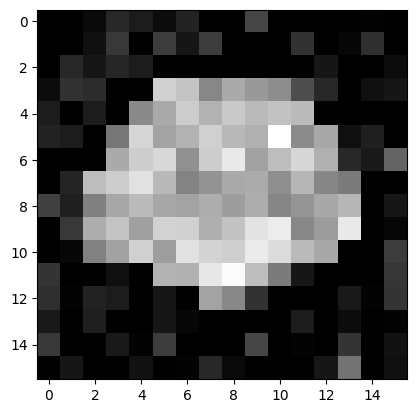

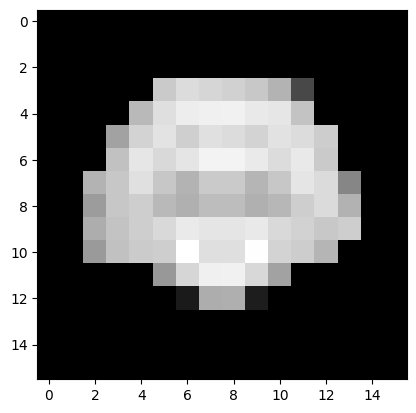

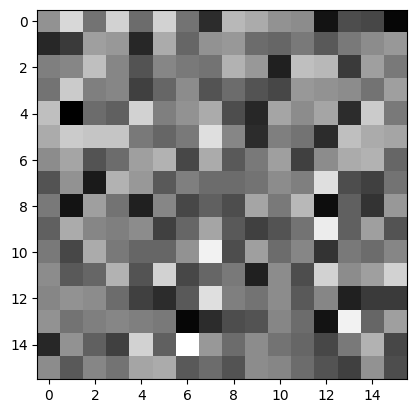

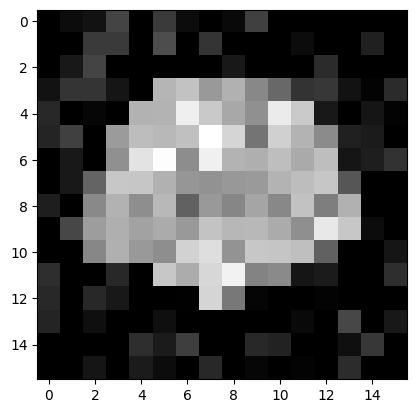

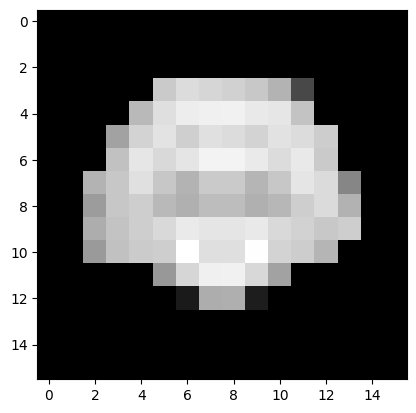

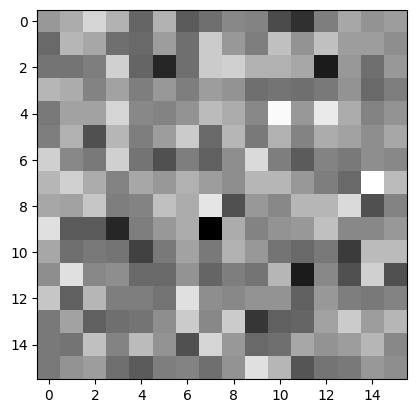

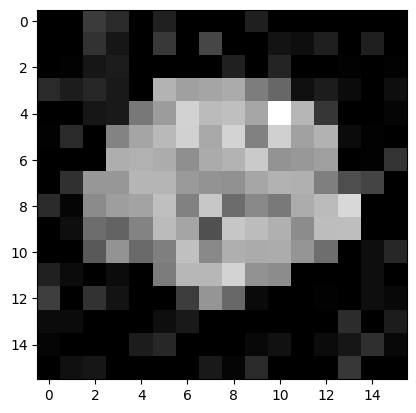

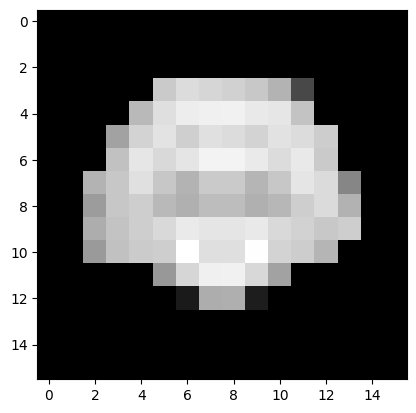

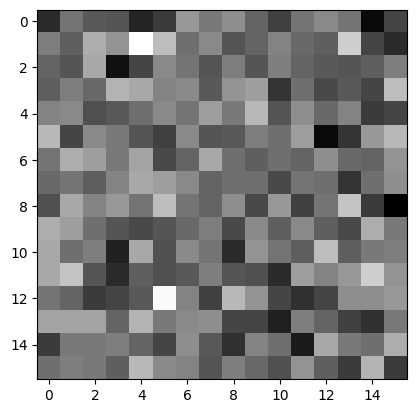

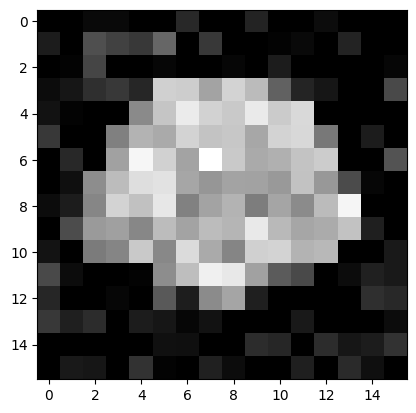

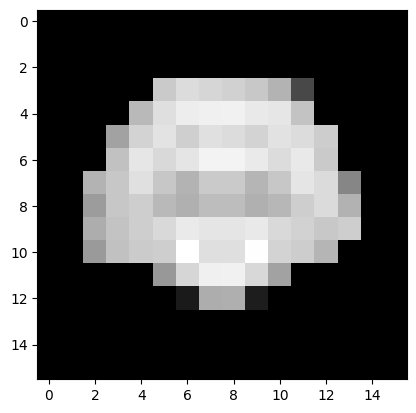

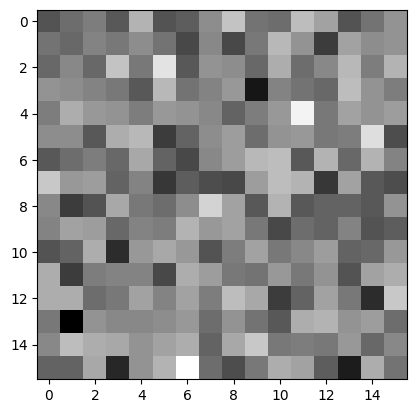

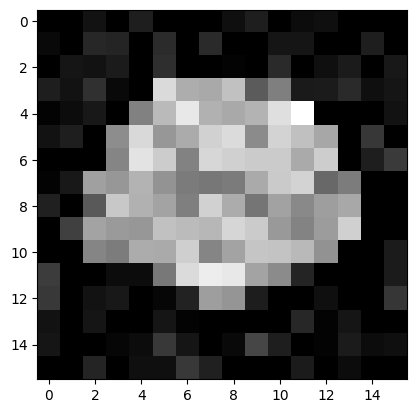

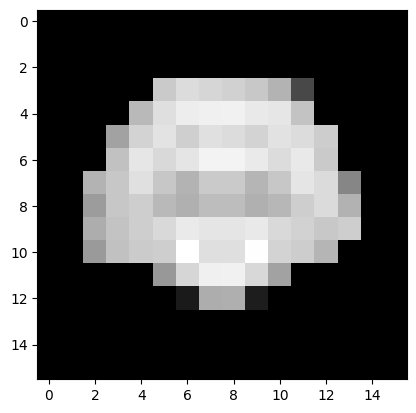

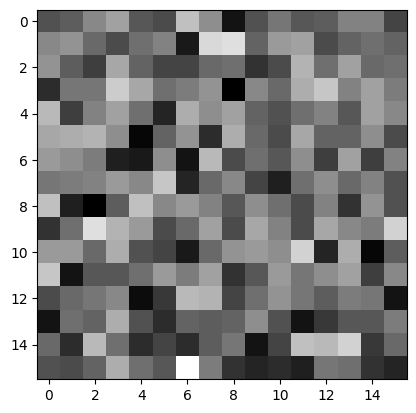

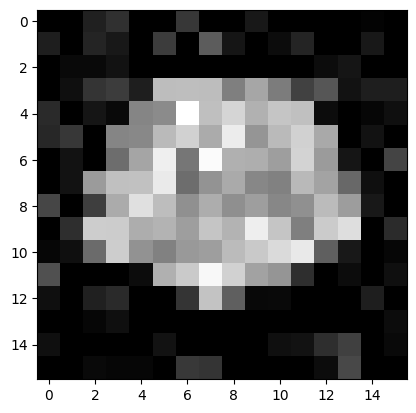

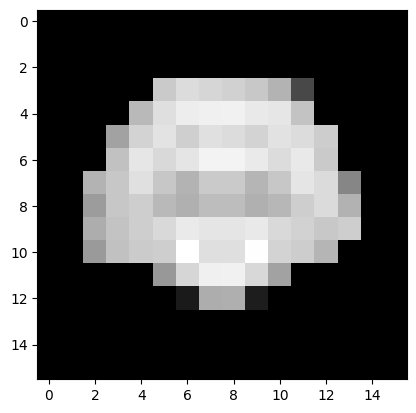

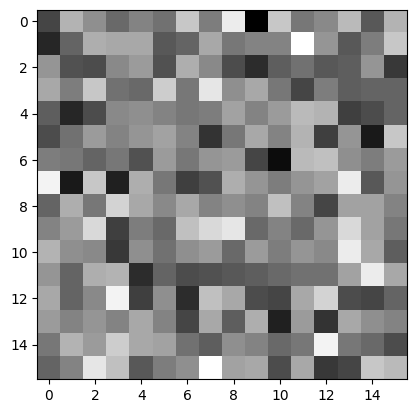

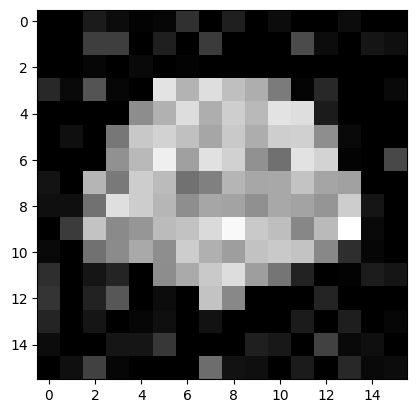

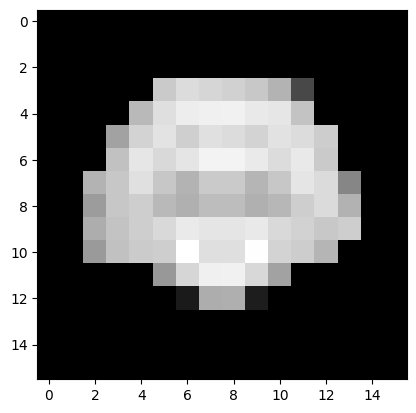

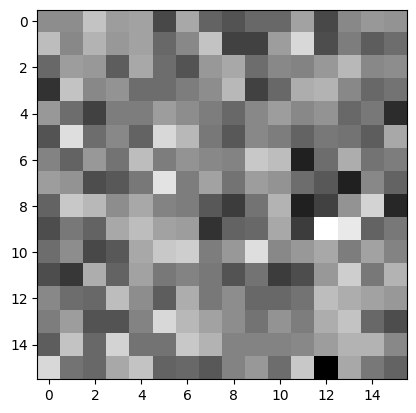

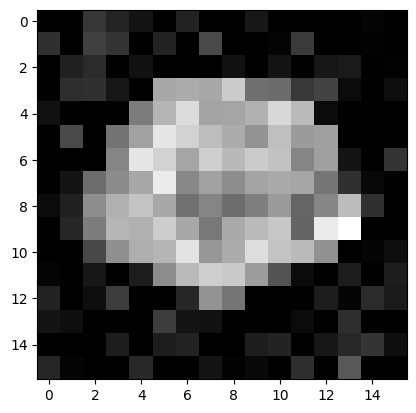

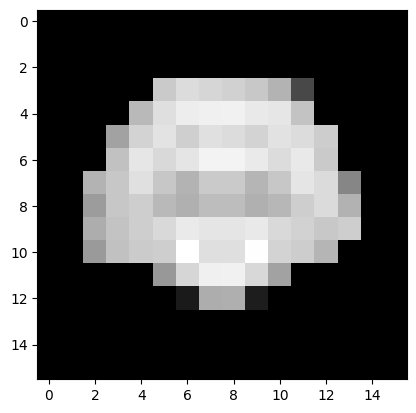

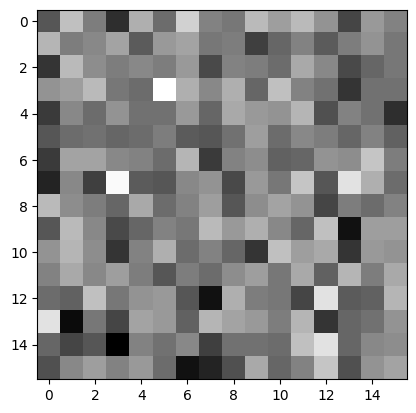

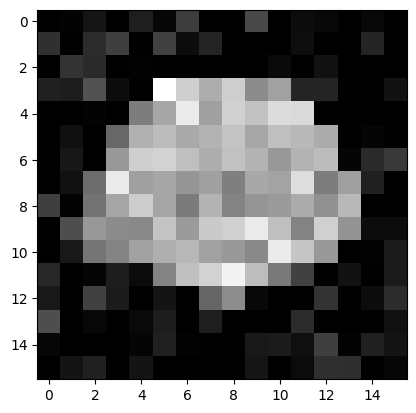

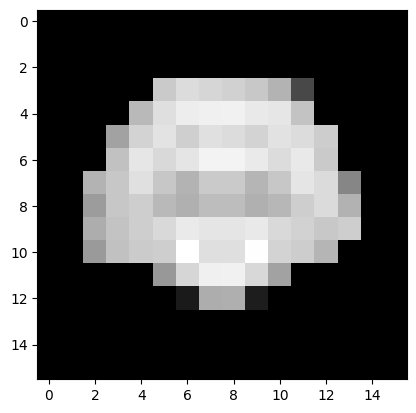

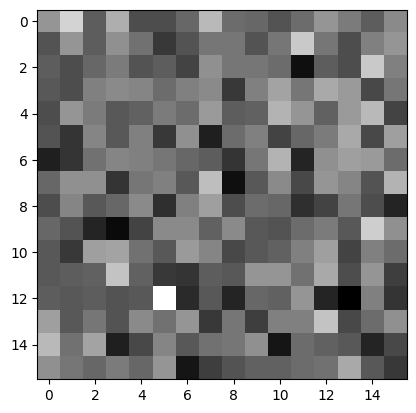

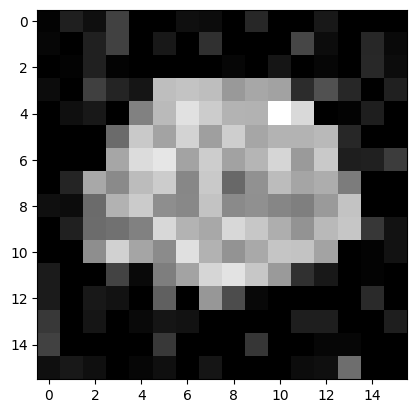

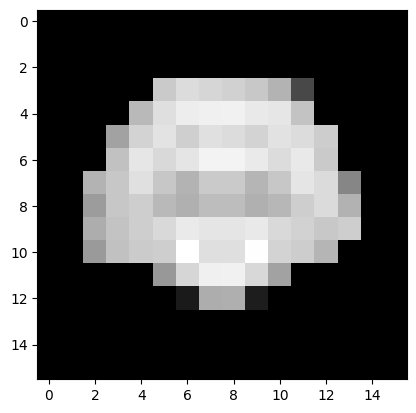

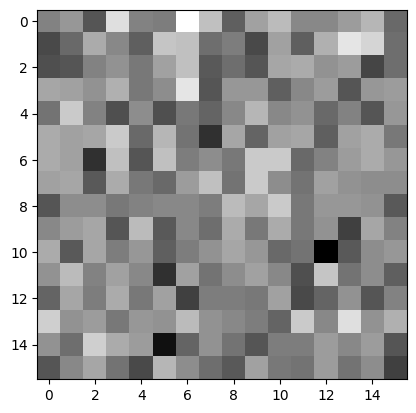

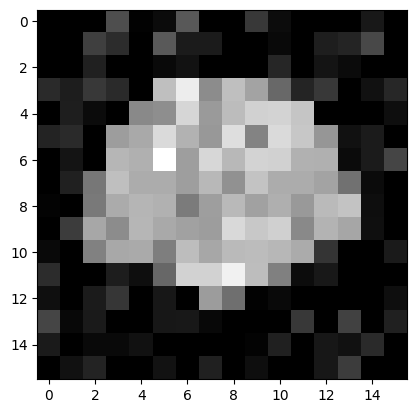

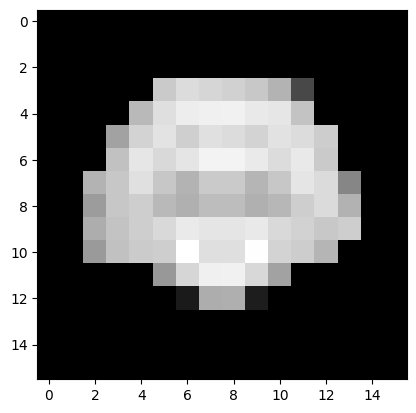

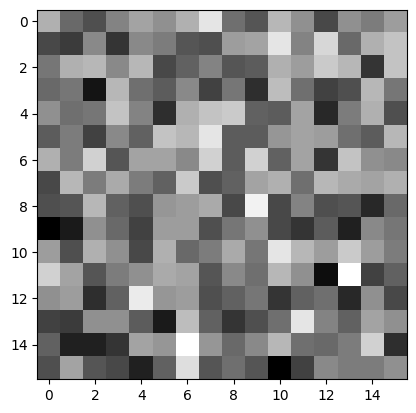

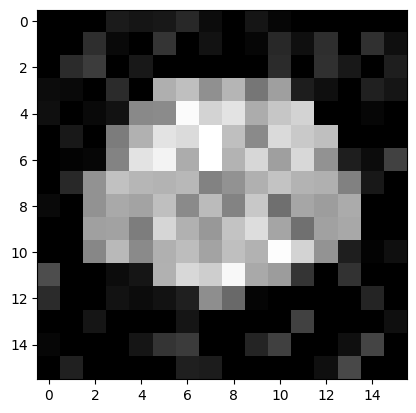

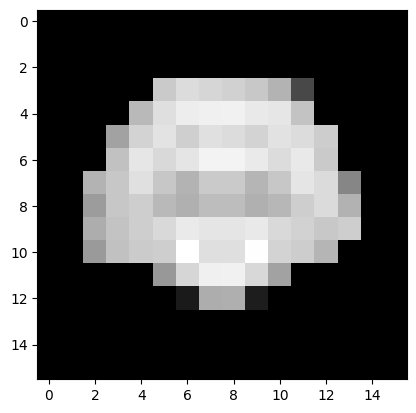

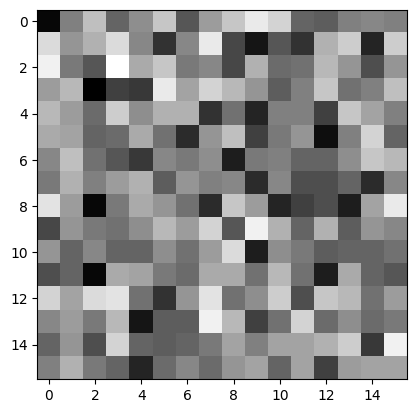

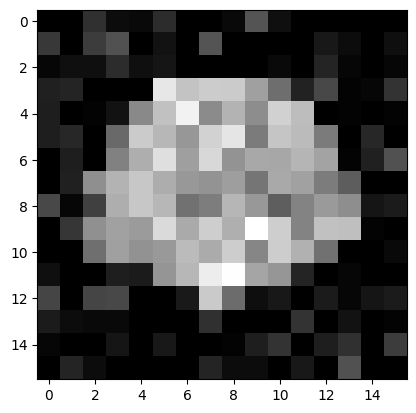

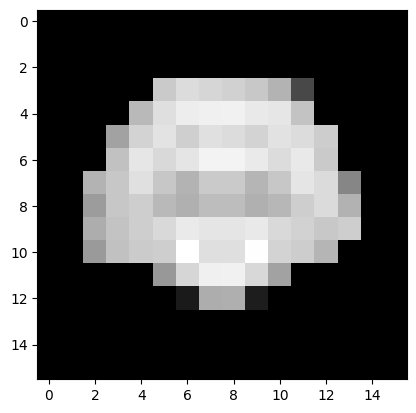

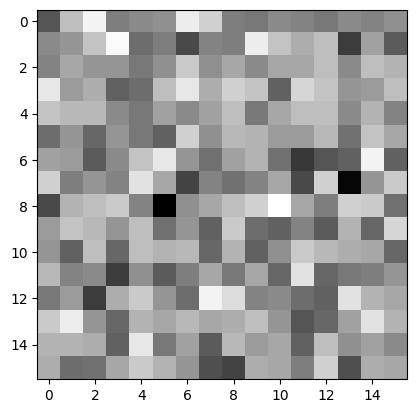

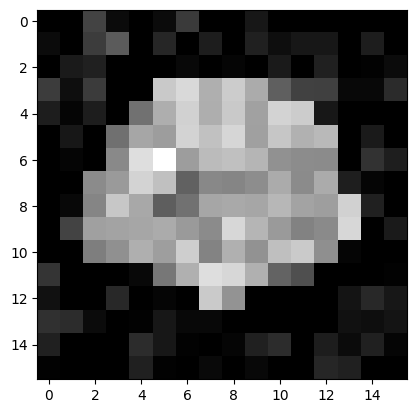

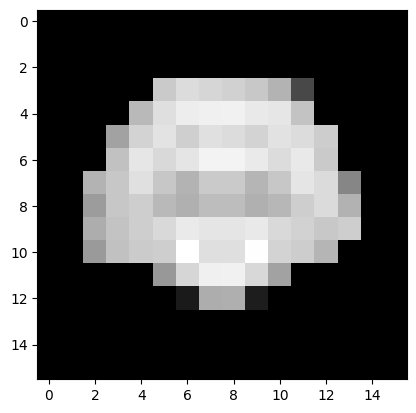

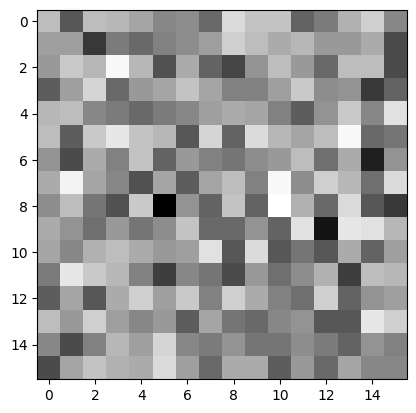

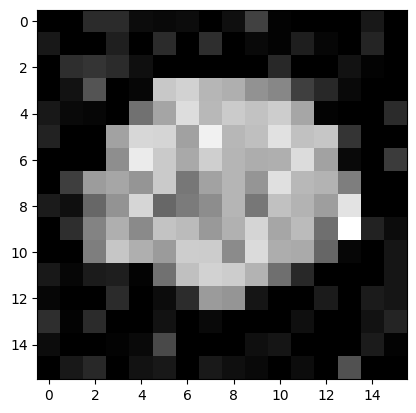

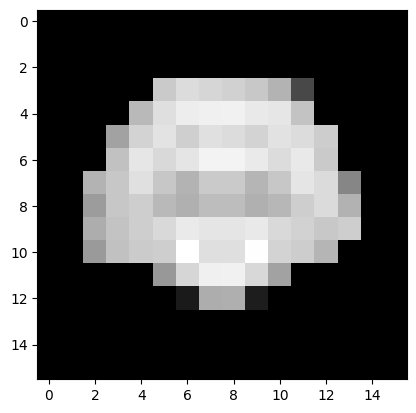

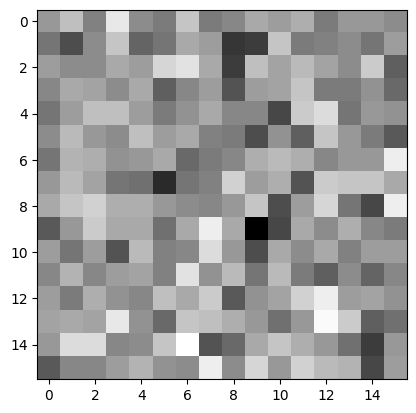

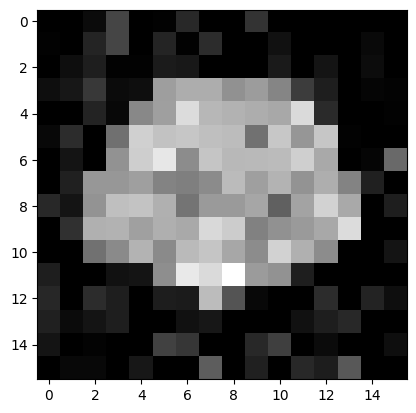

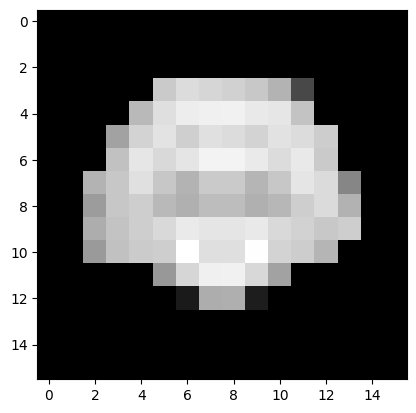

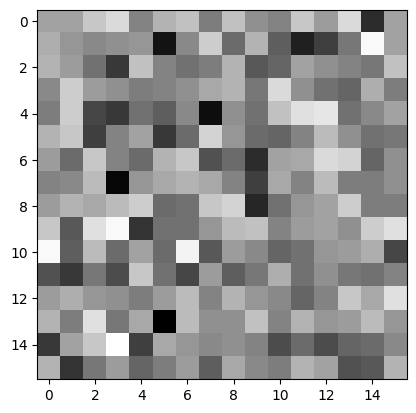

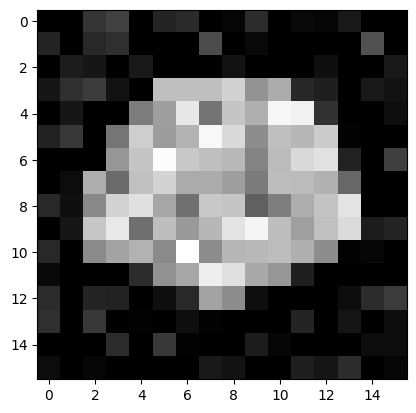

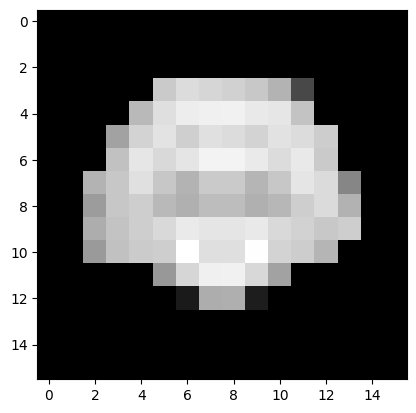

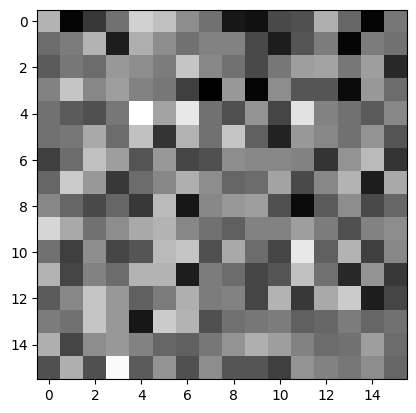

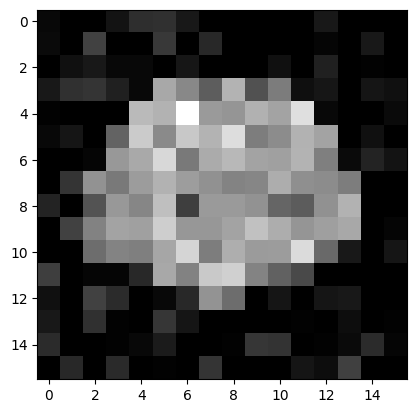

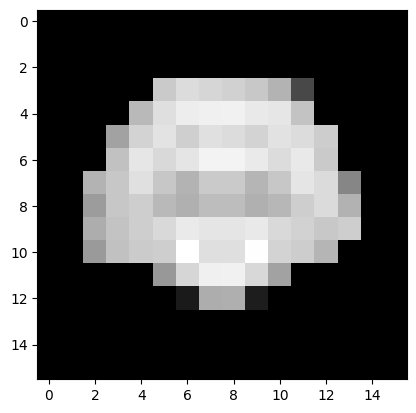

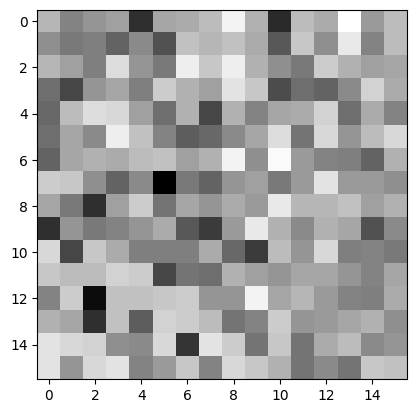

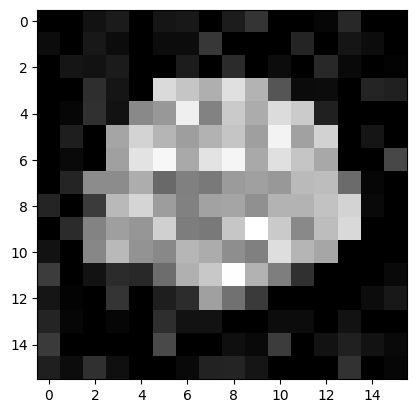

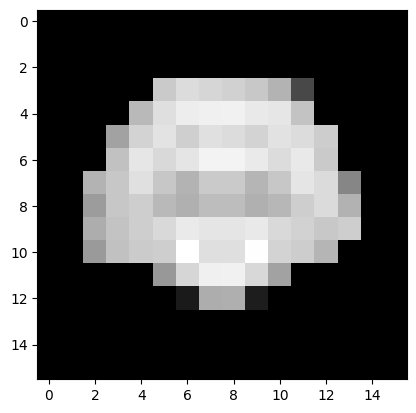

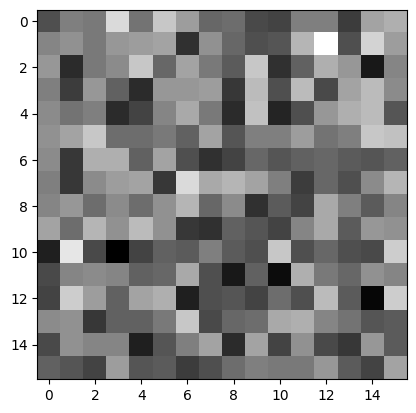

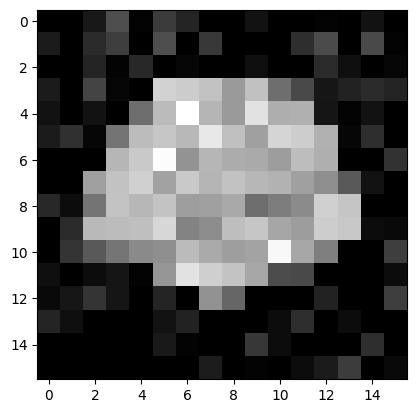

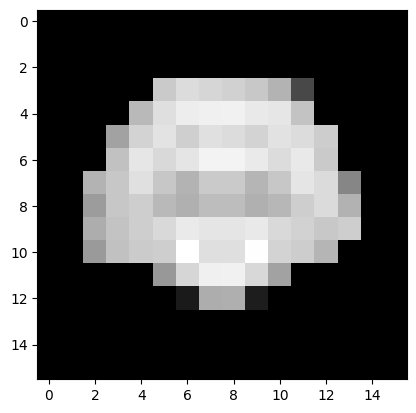

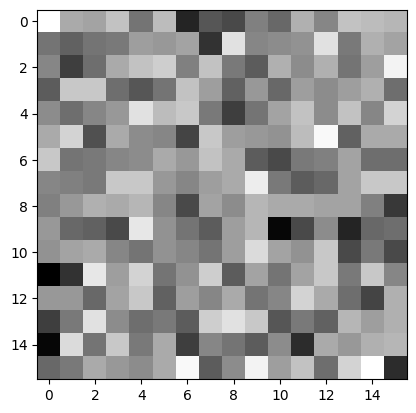

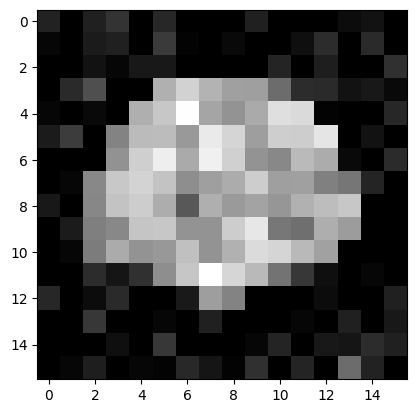

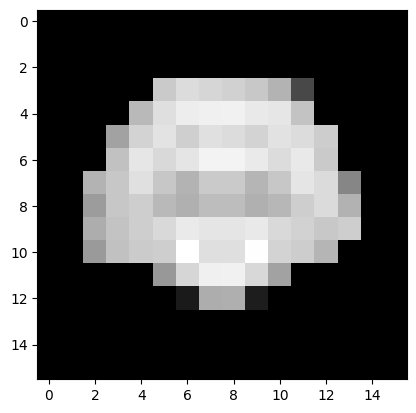

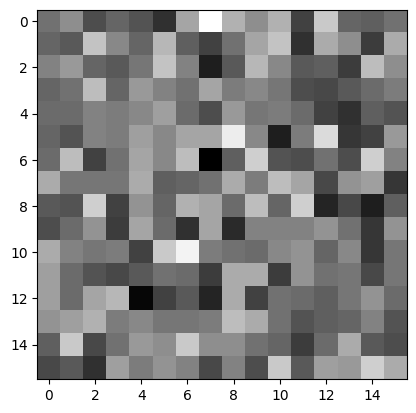

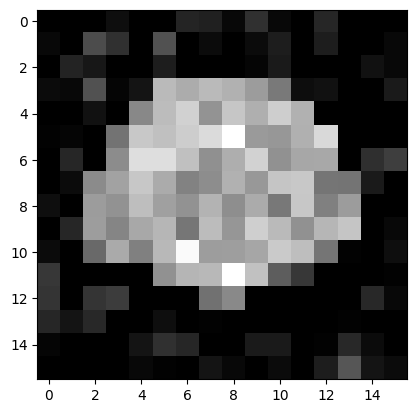

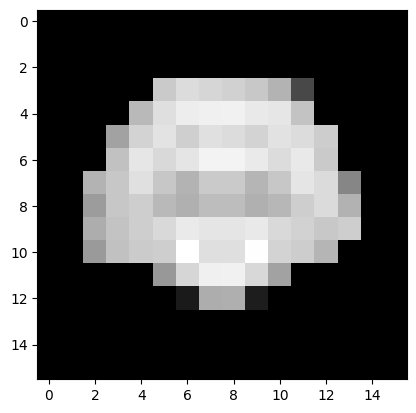

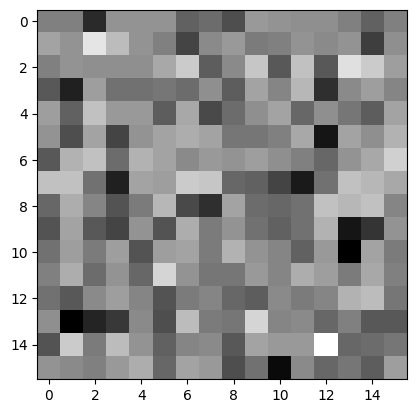

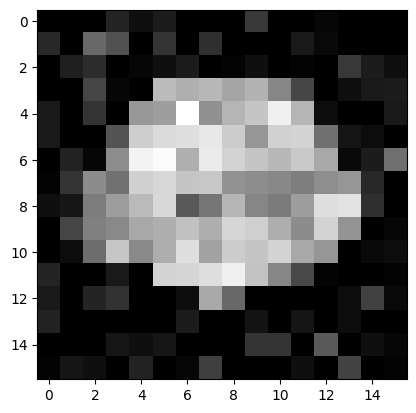

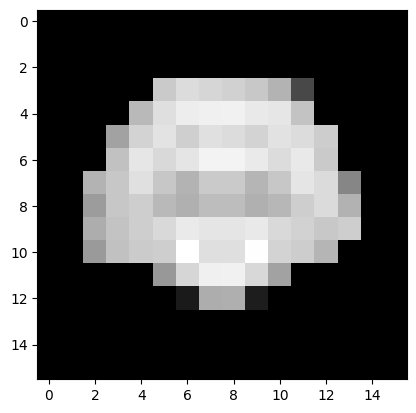

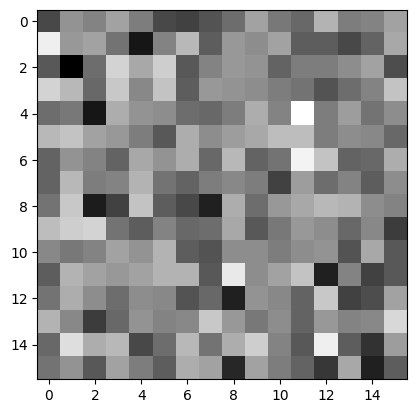

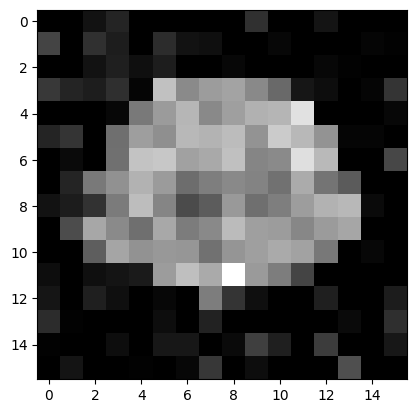

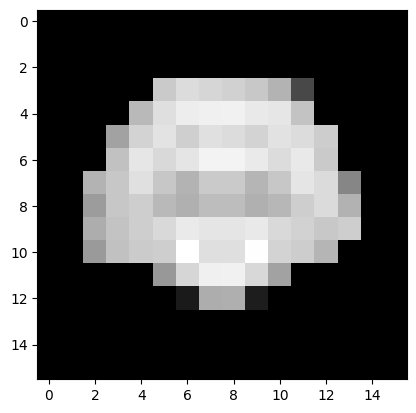

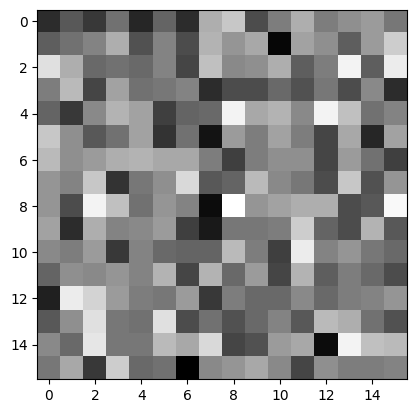

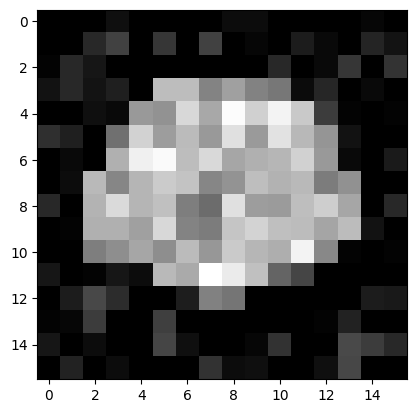

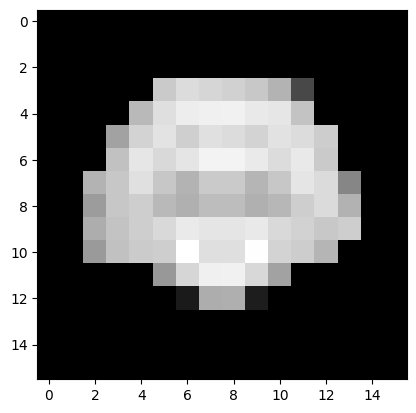

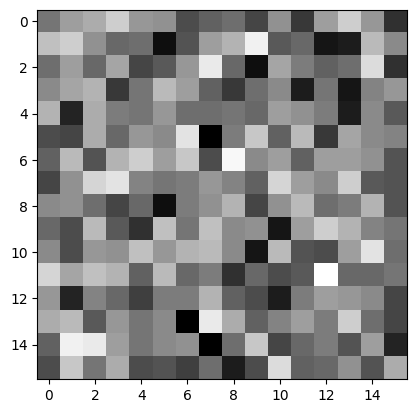

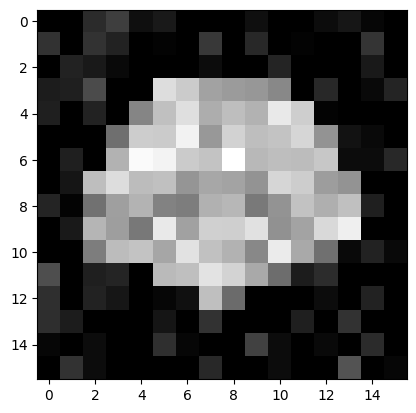

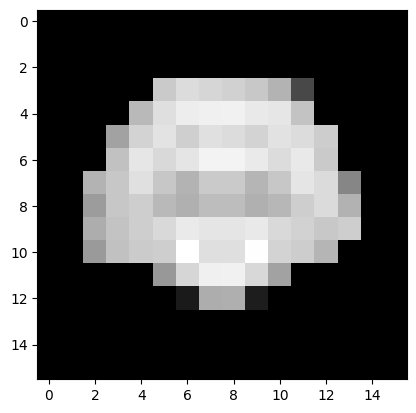

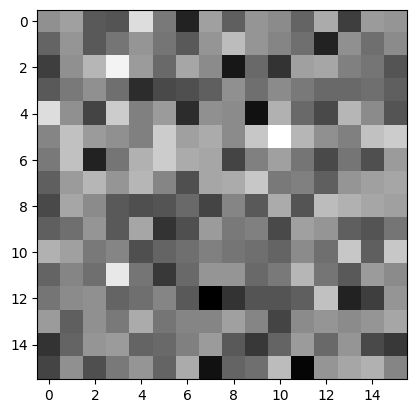

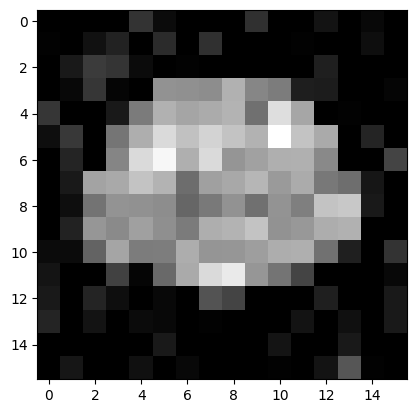

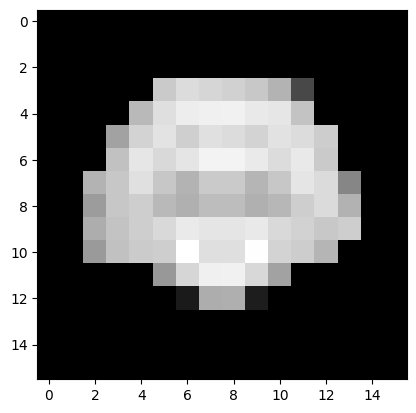

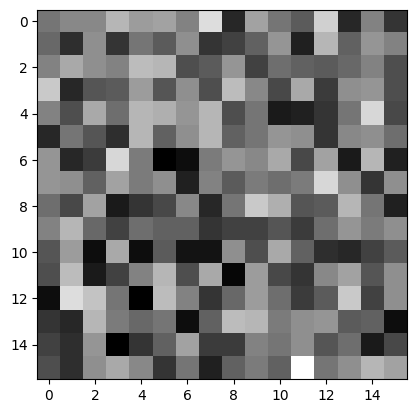

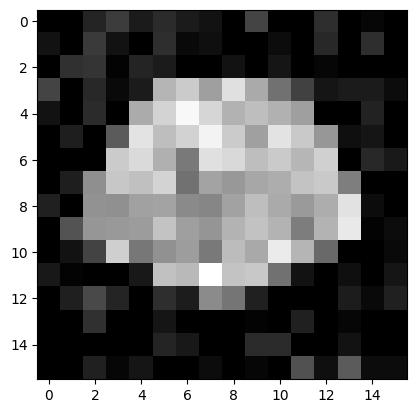

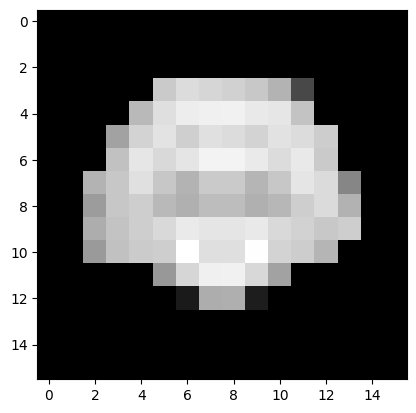

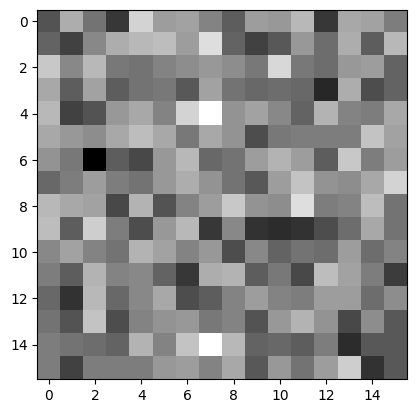

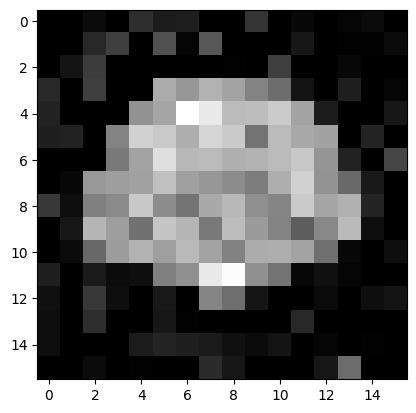

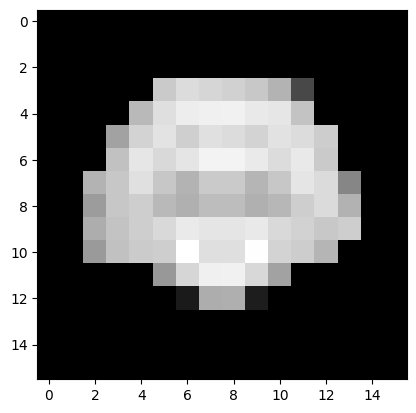

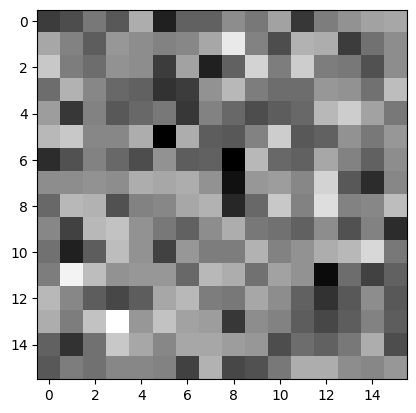

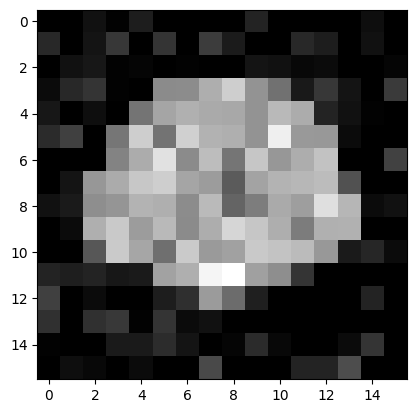

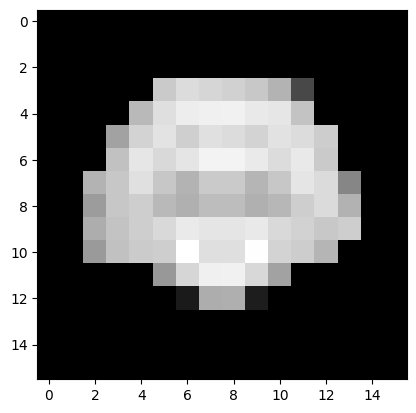

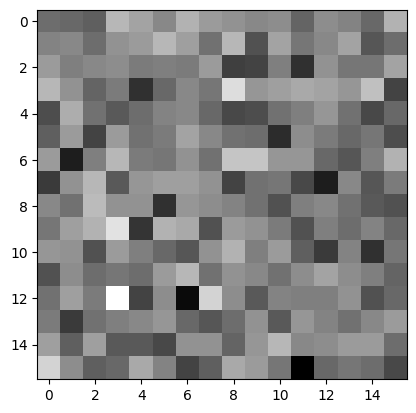

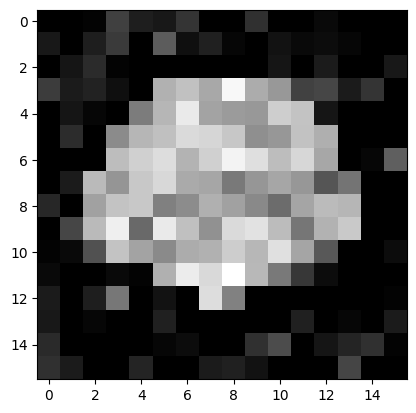

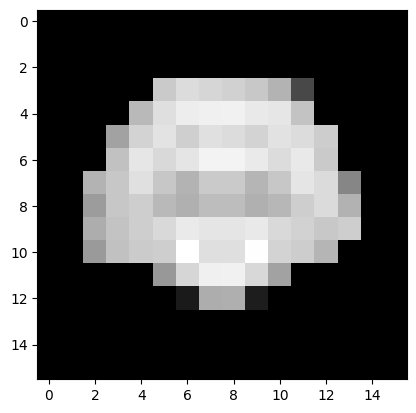

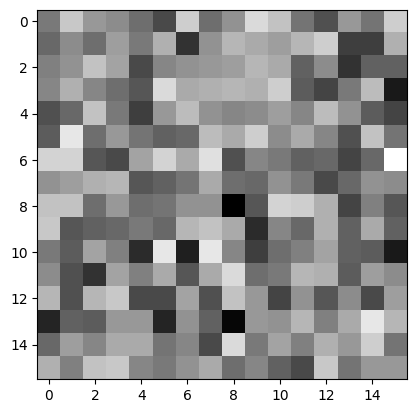

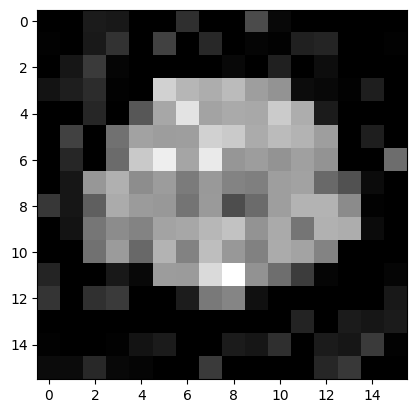

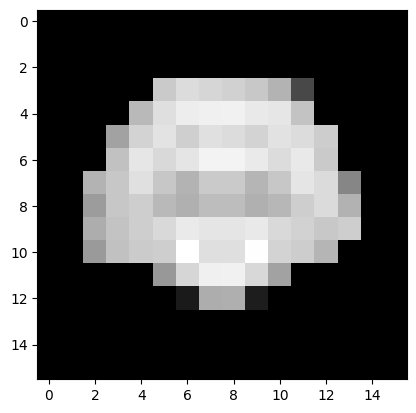

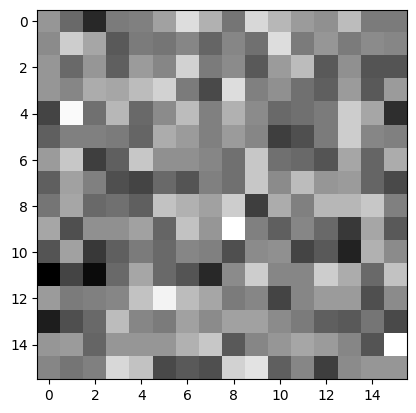

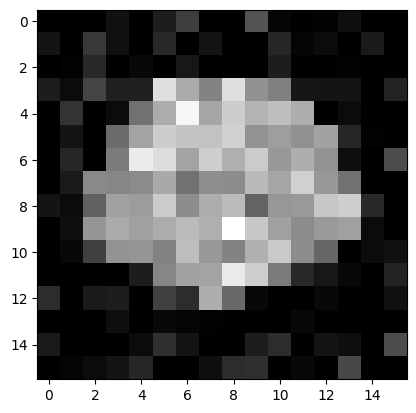

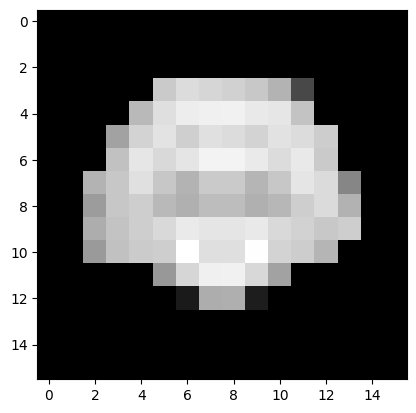

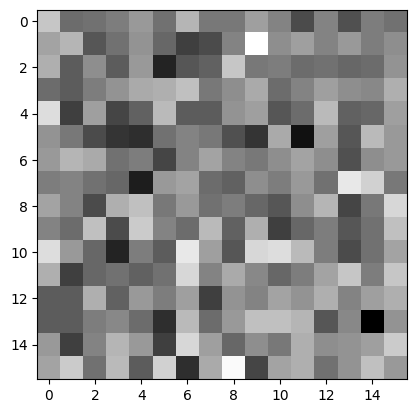

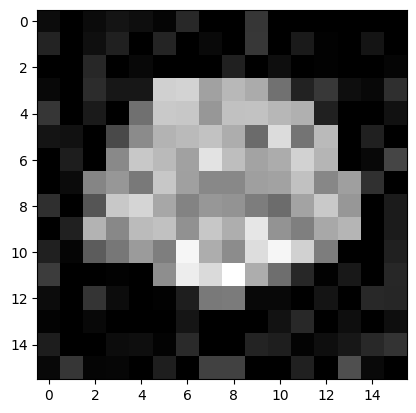

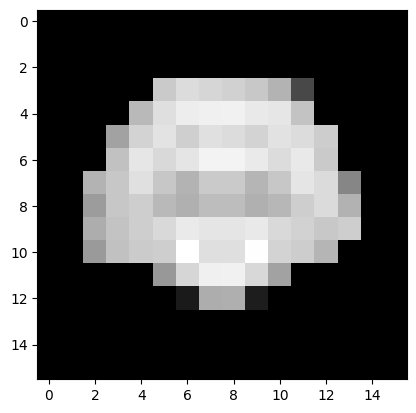

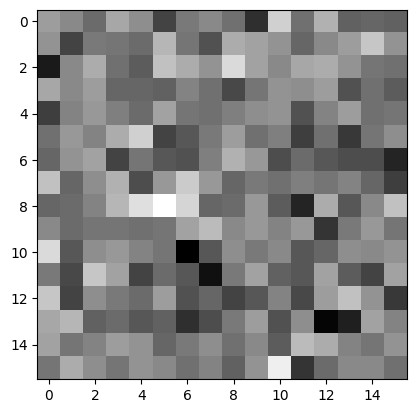

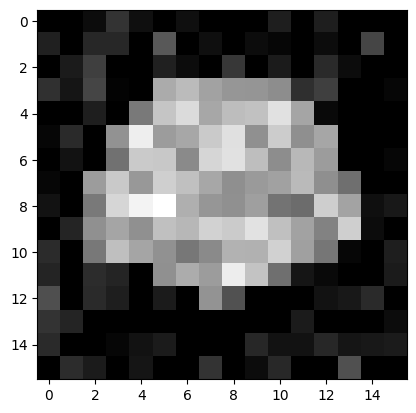

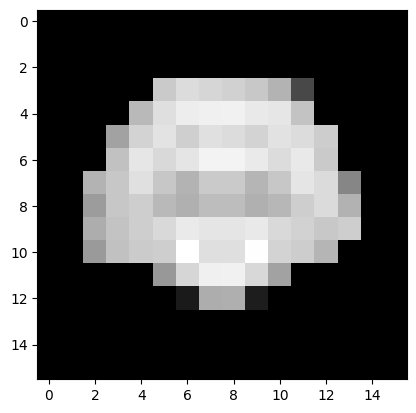

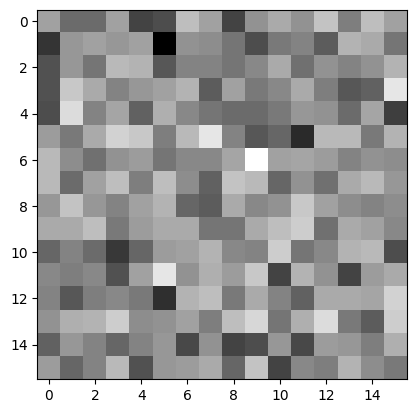

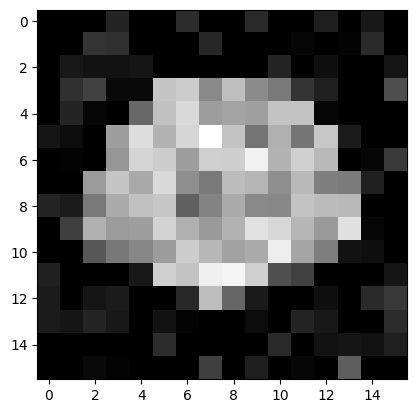

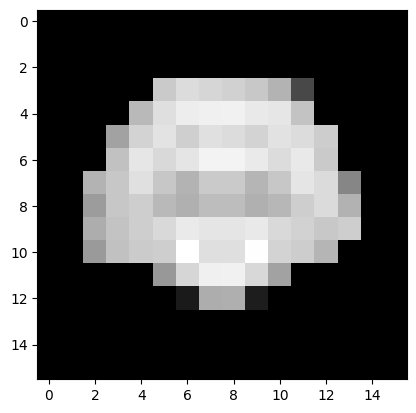

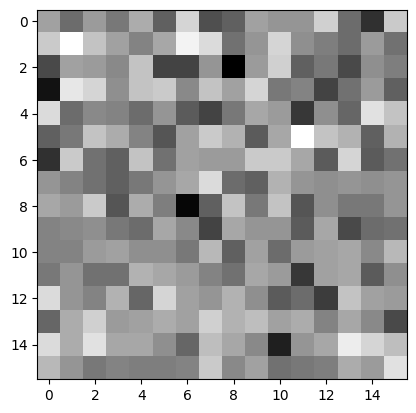

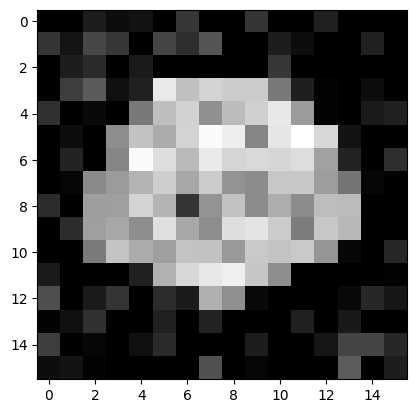

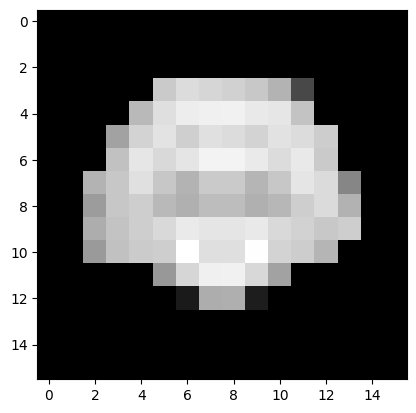

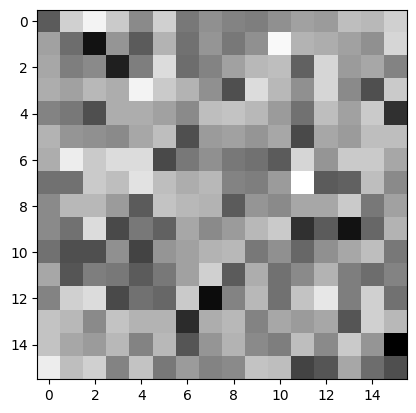

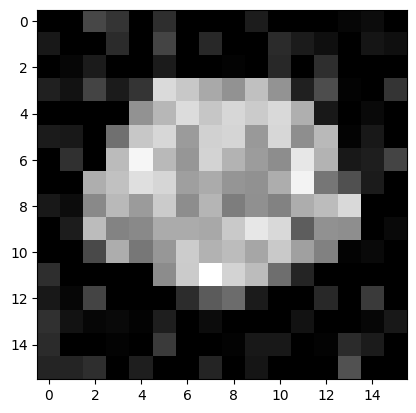

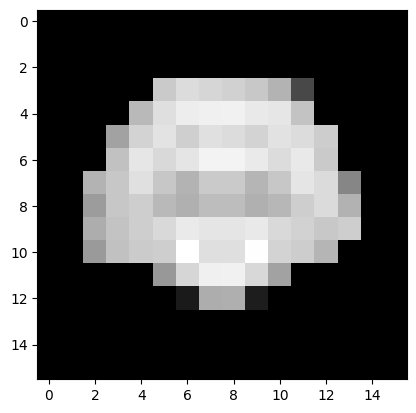

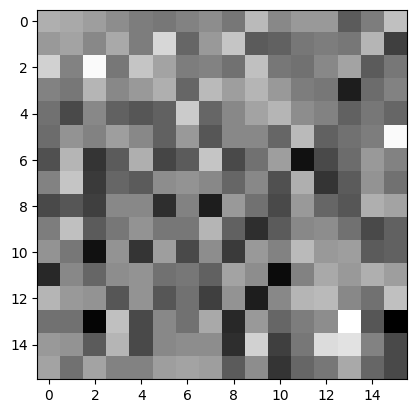

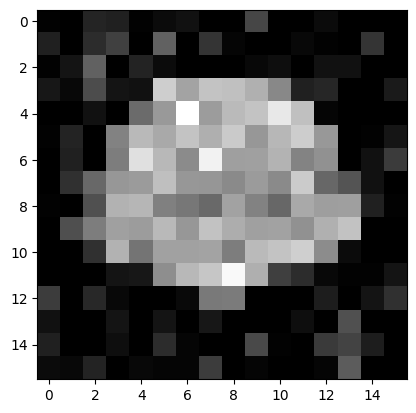

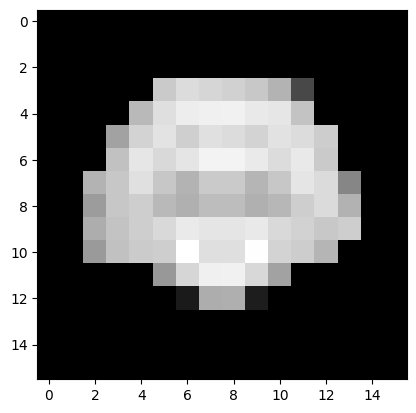

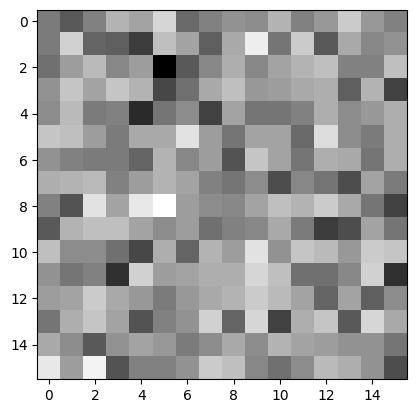

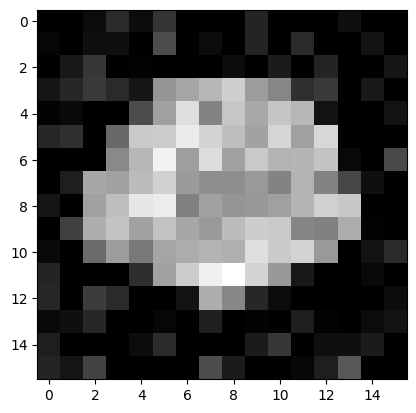

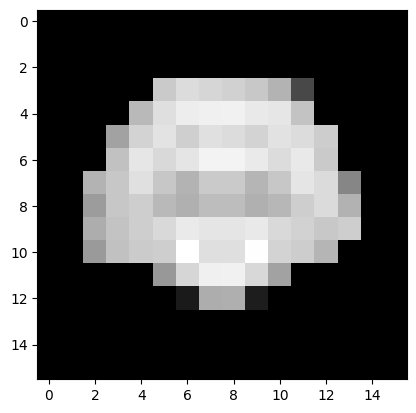

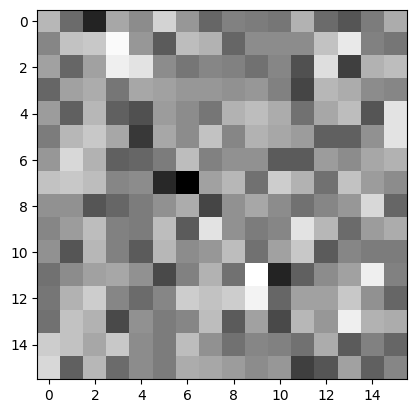

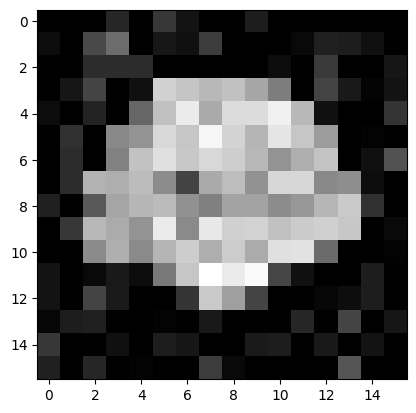

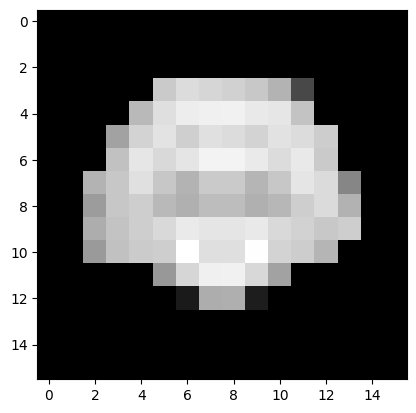

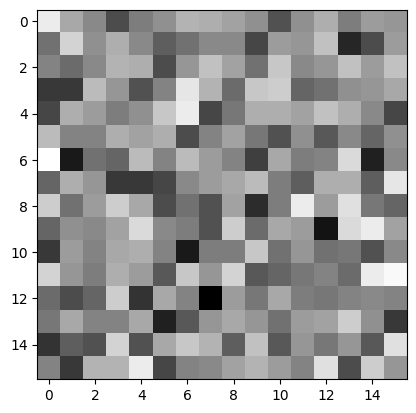

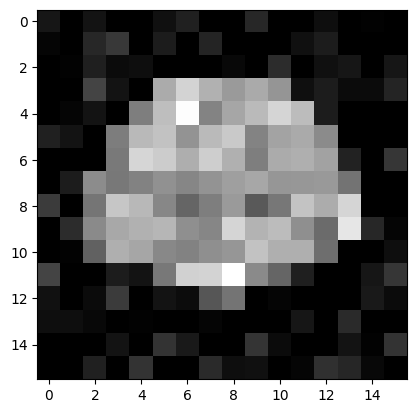

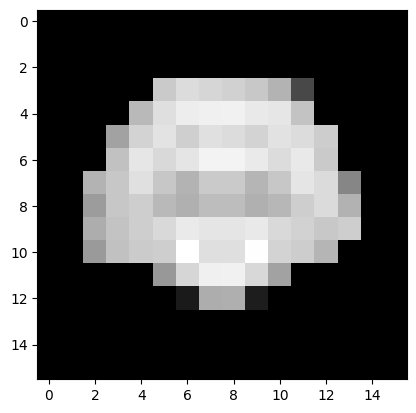

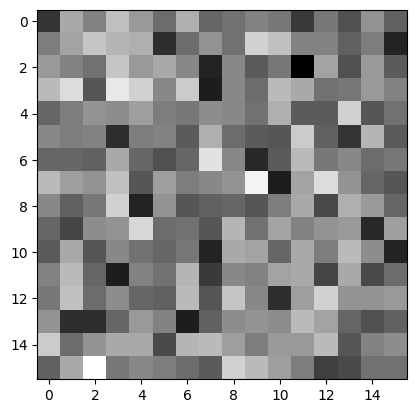

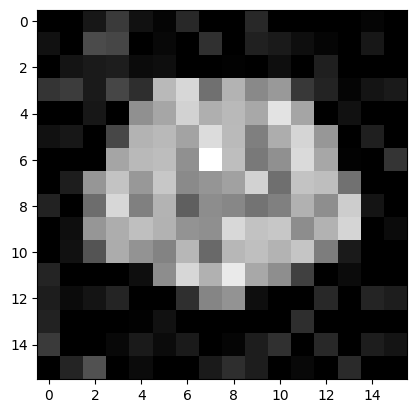

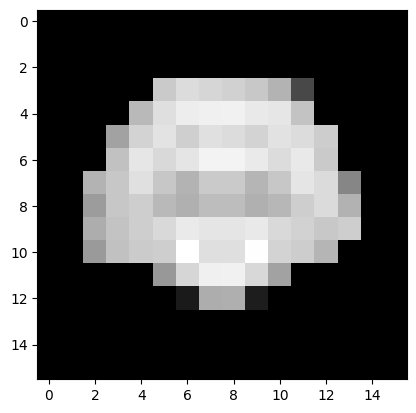

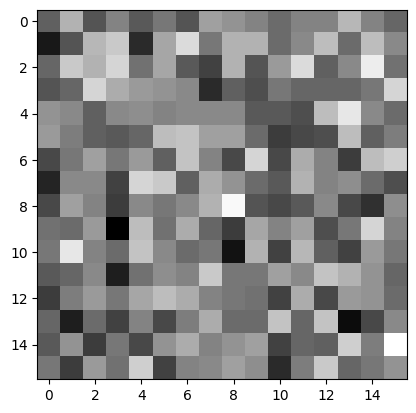

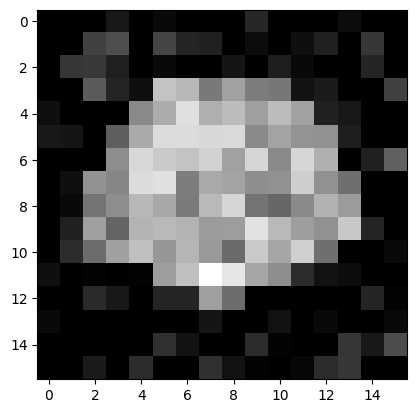

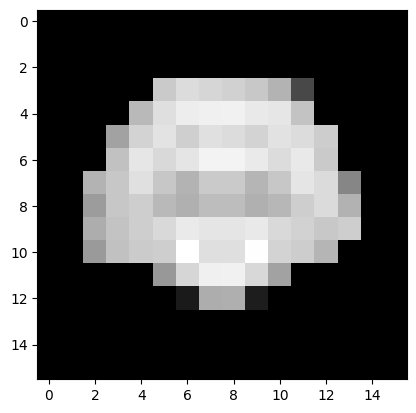

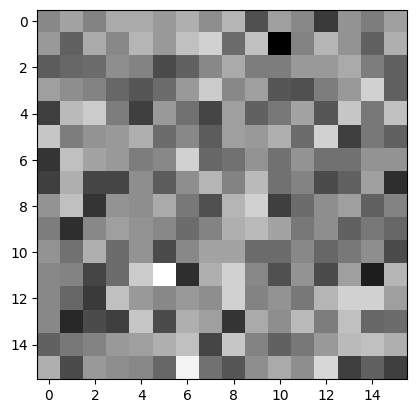

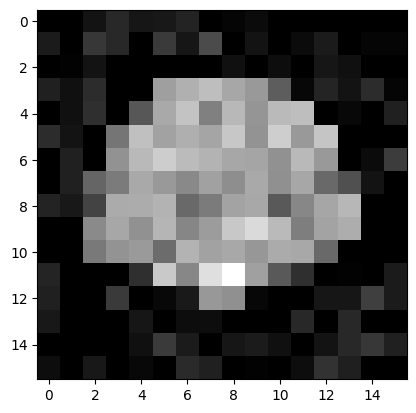

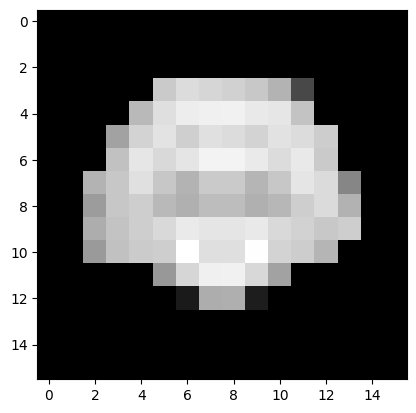

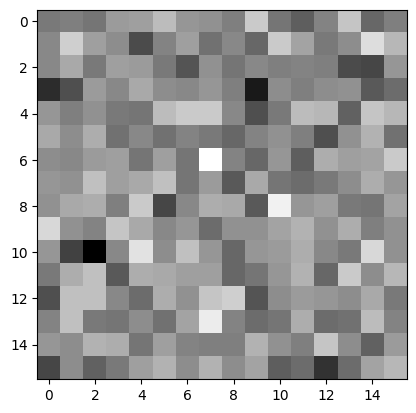

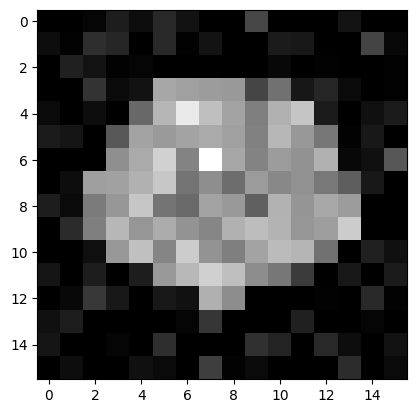

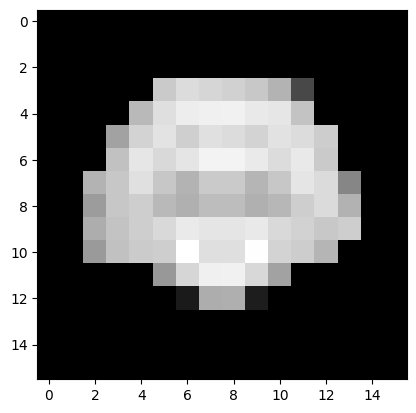

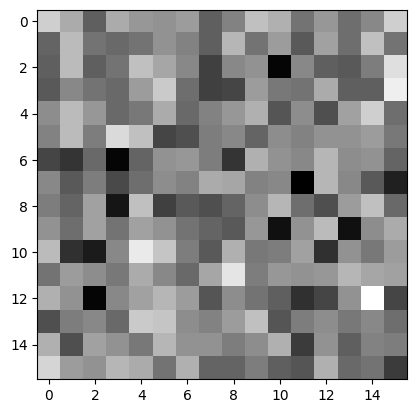

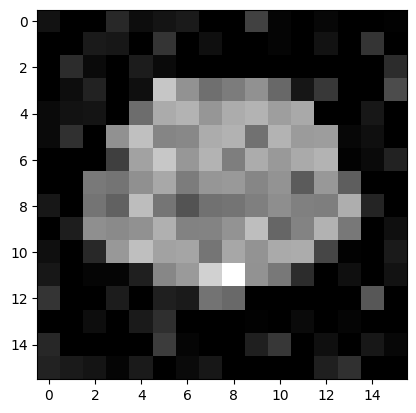

In [26]:
images_run_uuid = uuid.uuid4()
for image in range(1, 4):
    group_uuid = str(uuid.uuid4())
    for i in range(100):
        img_name = str(image) + '_original'
        img_path = 'original_images/' + img_name + ".png"
        make_experiment(img_path, img_name)